# Pr-YBCO version Fit modes

In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from alris_functions2 import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from itertools import chain
from matplotlib.markers import MarkerStyle
from tqdm import tqdm
from time import time

tf.keras.utils.set_random_seed(1)

%config InlineBackend.figure_format = 'svg' # make figures appears in .svg style

num_threads = 2  

# Configure TensorFlow to use multiple threads
tf.config.threading.set_intra_op_parallelism_threads(num_threads)
tf.config.threading.set_inter_op_parallelism_threads(num_threads)

print(f"Using {num_threads} threads for intra-op and inter-op parallelism.")

Using 2 threads for intra-op and inter-op parallelism.


Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [8]:
SRC = r'''
    res = [
        ['Pr','59',[0.94444 + Pr1_1_dx,0.16667 + Pr1_1_dy,0.05556 + Pr1_1_dz]],
        ['Pr','59',[0.05556 + Pr1_1_dx,0.83333 + Pr1_1_dy,0.05556 + Pr1_1_dz]],
        ['Pr','59',[0.05556 + Pr1_1_dx,0.16667 + Pr1_1_dy,0.94444 + Pr1_1_dz]],
        ['Pr','59',[0.94444 + Pr1_1_dx,0.83333 + Pr1_1_dy,0.94444 + Pr1_1_dz]],
        ['Pr','59',[0.05556 + Pr1_1_dx,0.83333 + Pr1_1_dy,0.94444 + Pr1_1_dz]],
        ['Pr','59',[0.94444 + Pr1_1_dx,0.16667 + Pr1_1_dy,0.94444 + Pr1_1_dz]],
        ['Pr','59',[0.94444 + Pr1_1_dx,0.83333 + Pr1_1_dy,0.05556 + Pr1_1_dz]],
        ['Pr','59',[0.05556 + Pr1_1_dx,0.16667 + Pr1_1_dy,0.05556 + Pr1_1_dz]],
        ['Pr','59',[0.94444 + Pr1_2_dx,0.16667 + Pr1_2_dy,0.16667 + Pr1_2_dz]],
        ['Pr','59',[0.05556 + Pr1_2_dx,0.83333 + Pr1_2_dy,0.16667 + Pr1_2_dz]],
        ['Pr','59',[0.05556 + Pr1_2_dx,0.16667 + Pr1_2_dy,0.83333 + Pr1_2_dz]],
        ['Pr','59',[0.94444 + Pr1_2_dx,0.83333 + Pr1_2_dy,0.83333 + Pr1_2_dz]],
        ['Pr','59',[0.05556 + Pr1_2_dx,0.83333 + Pr1_2_dy,0.83333 + Pr1_2_dz]],
        ['Pr','59',[0.94444 + Pr1_2_dx,0.16667 + Pr1_2_dy,0.83333 + Pr1_2_dz]],
        ['Pr','59',[0.94444 + Pr1_2_dx,0.83333 + Pr1_2_dy,0.16667 + Pr1_2_dz]],
        ['Pr','59',[0.05556 + Pr1_2_dx,0.16667 + Pr1_2_dy,0.16667 + Pr1_2_dz]],
        ['Pr','59',[0.94444 + Pr1_3_dx,0.16667 + Pr1_3_dy,0.27778 + Pr1_3_dz]],
        ['Pr','59',[0.05556 + Pr1_3_dx,0.83333 + Pr1_3_dy,0.27778 + Pr1_3_dz]],
        ['Pr','59',[0.05556 + Pr1_3_dx,0.16667 + Pr1_3_dy,0.72222 + Pr1_3_dz]],
        ['Pr','59',[0.94444 + Pr1_3_dx,0.83333 + Pr1_3_dy,0.72222 + Pr1_3_dz]],
        ['Pr','59',[0.05556 + Pr1_3_dx,0.83333 + Pr1_3_dy,0.72222 + Pr1_3_dz]],
        ['Pr','59',[0.94444 + Pr1_3_dx,0.16667 + Pr1_3_dy,0.72222 + Pr1_3_dz]],
        ['Pr','59',[0.94444 + Pr1_3_dx,0.83333 + Pr1_3_dy,0.27778 + Pr1_3_dz]],
        ['Pr','59',[0.05556 + Pr1_3_dx,0.16667 + Pr1_3_dy,0.27778 + Pr1_3_dz]],
        ['Pr','59',[0.94444 + Pr1_4_dx,0.16667 + Pr1_4_dy,0.38889 + Pr1_4_dz]],
        ['Pr','59',[0.05556 + Pr1_4_dx,0.83333 + Pr1_4_dy,0.38889 + Pr1_4_dz]],
        ['Pr','59',[0.05556 + Pr1_4_dx,0.16667 + Pr1_4_dy,0.61111 + Pr1_4_dz]],
        ['Pr','59',[0.94444 + Pr1_4_dx,0.83333 + Pr1_4_dy,0.61111 + Pr1_4_dz]],
        ['Pr','59',[0.05556 + Pr1_4_dx,0.83333 + Pr1_4_dy,0.61111 + Pr1_4_dz]],
        ['Pr','59',[0.94444 + Pr1_4_dx,0.16667 + Pr1_4_dy,0.61111 + Pr1_4_dz]],
        ['Pr','59',[0.94444 + Pr1_4_dx,0.83333 + Pr1_4_dy,0.38889 + Pr1_4_dz]],
        ['Pr','59',[0.05556 + Pr1_4_dx,0.16667 + Pr1_4_dy,0.38889 + Pr1_4_dz]],
        ['Pr','59',[0.94444 + Pr1_5_dx,0.16667 + Pr1_5_dy,0.5]],
        ['Pr','59',[0.05556 + Pr1_5_dx,0.83333 + Pr1_5_dy,0.5]],
        ['Pr','59',[0.05556 + Pr1_5_dx,0.16667 + Pr1_5_dy,0.5]],
        ['Pr','59',[0.94444 + Pr1_5_dx,0.83333 + Pr1_5_dy,0.5]],
        ['Pr','59',[0.94444 + Pr1_6_dx,0.5,0.05556 + Pr1_6_dz]],
        ['Pr','59',[0.05556 + Pr1_6_dx,0.5,0.05556 + Pr1_6_dz]],
        ['Pr','59',[0.05556 + Pr1_6_dx,0.5,0.94444 + Pr1_6_dz]],
        ['Pr','59',[0.94444 + Pr1_6_dx,0.5,0.94444 + Pr1_6_dz]],
        ['Pr','59',[0.94444 + Pr1_7_dx,0.5,0.16667 + Pr1_7_dz]],
        ['Pr','59',[0.05556 + Pr1_7_dx,0.5,0.16667 + Pr1_7_dz]],
        ['Pr','59',[0.05556 + Pr1_7_dx,0.5,0.83333 + Pr1_7_dz]],
        ['Pr','59',[0.94444 + Pr1_7_dx,0.5,0.83333 + Pr1_7_dz]],
        ['Pr','59',[0.94444 + Pr1_8_dx,0.5,0.27778 + Pr1_8_dz]],
        ['Pr','59',[0.05556 + Pr1_8_dx,0.5,0.27778 + Pr1_8_dz]],
        ['Pr','59',[0.05556 + Pr1_8_dx,0.5,0.72222 + Pr1_8_dz]],
        ['Pr','59',[0.94444 + Pr1_8_dx,0.5,0.72222 + Pr1_8_dz]],
        ['Pr','59',[0.94444 + Pr1_9_dx,0.5,0.38889 + Pr1_9_dz]],
        ['Pr','59',[0.05556 + Pr1_9_dx,0.5,0.38889 + Pr1_9_dz]],
        ['Pr','59',[0.05556 + Pr1_9_dx,0.5,0.61111 + Pr1_9_dz]],
        ['Pr','59',[0.94444 + Pr1_9_dx,0.5,0.61111 + Pr1_9_dz]],
        ['Pr','59',[0.94444 + Pr1_10_dx,0.5,0.5]],
        ['Pr','59',[0.05556 + Pr1_10_dx,0.5,0.5]],
        ['Pr','59',[0.16667 + Pr1_11_dx,0.16667 + Pr1_11_dy,0.05556 + Pr1_11_dz]],
        ['Pr','59',[0.83333 + Pr1_11_dx,0.83333 + Pr1_11_dy,0.05556 + Pr1_11_dz]],
        ['Pr','59',[0.83333 + Pr1_11_dx,0.16667 + Pr1_11_dy,0.94444 + Pr1_11_dz]],
        ['Pr','59',[0.16667 + Pr1_11_dx,0.83333 + Pr1_11_dy,0.94444 + Pr1_11_dz]],
        ['Pr','59',[0.83333 + Pr1_11_dx,0.83333 + Pr1_11_dy,0.94444 + Pr1_11_dz]],
        ['Pr','59',[0.16667 + Pr1_11_dx,0.16667 + Pr1_11_dy,0.94444 + Pr1_11_dz]],
        ['Pr','59',[0.16667 + Pr1_11_dx,0.83333 + Pr1_11_dy,0.05556 + Pr1_11_dz]],
        ['Pr','59',[0.83333 + Pr1_11_dx,0.16667 + Pr1_11_dy,0.05556 + Pr1_11_dz]],
        ['Pr','59',[0.16667 + Pr1_12_dx,0.16667 + Pr1_12_dy,0.16667 + Pr1_12_dz]],
        ['Pr','59',[0.83333 + Pr1_12_dx,0.83333 + Pr1_12_dy,0.16667 + Pr1_12_dz]],
        ['Pr','59',[0.83333 + Pr1_12_dx,0.16667 + Pr1_12_dy,0.83333 + Pr1_12_dz]],
        ['Pr','59',[0.16667 + Pr1_12_dx,0.83333 + Pr1_12_dy,0.83333 + Pr1_12_dz]],
        ['Pr','59',[0.83333 + Pr1_12_dx,0.83333 + Pr1_12_dy,0.83333 + Pr1_12_dz]],
        ['Pr','59',[0.16667 + Pr1_12_dx,0.16667 + Pr1_12_dy,0.83333 + Pr1_12_dz]],
        ['Pr','59',[0.16667 + Pr1_12_dx,0.83333 + Pr1_12_dy,0.16667 + Pr1_12_dz]],
        ['Pr','59',[0.83333 + Pr1_12_dx,0.16667 + Pr1_12_dy,0.16667 + Pr1_12_dz]],
        ['Pr','59',[0.16667 + Pr1_13_dx,0.16667 + Pr1_13_dy,0.27778 + Pr1_13_dz]],
        ['Pr','59',[0.83333 + Pr1_13_dx,0.83333 + Pr1_13_dy,0.27778 + Pr1_13_dz]],
        ['Pr','59',[0.83333 + Pr1_13_dx,0.16667 + Pr1_13_dy,0.72222 + Pr1_13_dz]],
        ['Pr','59',[0.16667 + Pr1_13_dx,0.83333 + Pr1_13_dy,0.72222 + Pr1_13_dz]],
        ['Pr','59',[0.83333 + Pr1_13_dx,0.83333 + Pr1_13_dy,0.72222 + Pr1_13_dz]],
        ['Pr','59',[0.16667 + Pr1_13_dx,0.16667 + Pr1_13_dy,0.72222 + Pr1_13_dz]],
        ['Pr','59',[0.16667 + Pr1_13_dx,0.83333 + Pr1_13_dy,0.27778 + Pr1_13_dz]],
        ['Pr','59',[0.83333 + Pr1_13_dx,0.16667 + Pr1_13_dy,0.27778 + Pr1_13_dz]],
        ['Pr','59',[0.16667 + Pr1_14_dx,0.16667 + Pr1_14_dy,0.38889 + Pr1_14_dz]],
        ['Pr','59',[0.83333 + Pr1_14_dx,0.83333 + Pr1_14_dy,0.38889 + Pr1_14_dz]],
        ['Pr','59',[0.83333 + Pr1_14_dx,0.16667 + Pr1_14_dy,0.61111 + Pr1_14_dz]],
        ['Pr','59',[0.16667 + Pr1_14_dx,0.83333 + Pr1_14_dy,0.61111 + Pr1_14_dz]],
        ['Pr','59',[0.83333 + Pr1_14_dx,0.83333 + Pr1_14_dy,0.61111 + Pr1_14_dz]],
        ['Pr','59',[0.16667 + Pr1_14_dx,0.16667 + Pr1_14_dy,0.61111 + Pr1_14_dz]],
        ['Pr','59',[0.16667 + Pr1_14_dx,0.83333 + Pr1_14_dy,0.38889 + Pr1_14_dz]],
        ['Pr','59',[0.83333 + Pr1_14_dx,0.16667 + Pr1_14_dy,0.38889 + Pr1_14_dz]],
        ['Pr','59',[0.16667 + Pr1_15_dx,0.16667 + Pr1_15_dy,0.5]],
        ['Pr','59',[0.83333 + Pr1_15_dx,0.83333 + Pr1_15_dy,0.5]],
        ['Pr','59',[0.83333 + Pr1_15_dx,0.16667 + Pr1_15_dy,0.5]],
        ['Pr','59',[0.16667 + Pr1_15_dx,0.83333 + Pr1_15_dy,0.5]],
        ['Pr','59',[0.16667 + Pr1_16_dx,0.5,0.05556 + Pr1_16_dz]],
        ['Pr','59',[0.83333 + Pr1_16_dx,0.5,0.05556 + Pr1_16_dz]],
        ['Pr','59',[0.83333 + Pr1_16_dx,0.5,0.94444 + Pr1_16_dz]],
        ['Pr','59',[0.16667 + Pr1_16_dx,0.5,0.94444 + Pr1_16_dz]],
        ['Pr','59',[0.16667 + Pr1_17_dx,0.5,0.16667 + Pr1_17_dz]],
        ['Pr','59',[0.83333 + Pr1_17_dx,0.5,0.16667 + Pr1_17_dz]],
        ['Pr','59',[0.83333 + Pr1_17_dx,0.5,0.83333 + Pr1_17_dz]],
        ['Pr','59',[0.16667 + Pr1_17_dx,0.5,0.83333 + Pr1_17_dz]],
        ['Pr','59',[0.16667 + Pr1_18_dx,0.5,0.27778 + Pr1_18_dz]],
        ['Pr','59',[0.83333 + Pr1_18_dx,0.5,0.27778 + Pr1_18_dz]],
        ['Pr','59',[0.83333 + Pr1_18_dx,0.5,0.72222 + Pr1_18_dz]],
        ['Pr','59',[0.16667 + Pr1_18_dx,0.5,0.72222 + Pr1_18_dz]],
        ['Pr','59',[0.16667 + Pr1_19_dx,0.5,0.38889 + Pr1_19_dz]],
        ['Pr','59',[0.83333 + Pr1_19_dx,0.5,0.38889 + Pr1_19_dz]],
        ['Pr','59',[0.83333 + Pr1_19_dx,0.5,0.61111 + Pr1_19_dz]],
        ['Pr','59',[0.16667 + Pr1_19_dx,0.5,0.61111 + Pr1_19_dz]],
        ['Pr','59',[0.16667 + Pr1_20_dx,0.5,0.5]],
        ['Pr','59',[0.83333 + Pr1_20_dx,0.5,0.5]],
        ['Pr','59',[0.27778 + Pr1_21_dx,0.16667 + Pr1_21_dy,0.05556 + Pr1_21_dz]],
        ['Pr','59',[0.72222 + Pr1_21_dx,0.83333 + Pr1_21_dy,0.05556 + Pr1_21_dz]],
        ['Pr','59',[0.72222 + Pr1_21_dx,0.16667 + Pr1_21_dy,0.94444 + Pr1_21_dz]],
        ['Pr','59',[0.27778 + Pr1_21_dx,0.83333 + Pr1_21_dy,0.94444 + Pr1_21_dz]],
        ['Pr','59',[0.72222 + Pr1_21_dx,0.83333 + Pr1_21_dy,0.94444 + Pr1_21_dz]],
        ['Pr','59',[0.27778 + Pr1_21_dx,0.16667 + Pr1_21_dy,0.94444 + Pr1_21_dz]],
        ['Pr','59',[0.27778 + Pr1_21_dx,0.83333 + Pr1_21_dy,0.05556 + Pr1_21_dz]],
        ['Pr','59',[0.72222 + Pr1_21_dx,0.16667 + Pr1_21_dy,0.05556 + Pr1_21_dz]],
        ['Pr','59',[0.27778 + Pr1_22_dx,0.16667 + Pr1_22_dy,0.16667 + Pr1_22_dz]],
        ['Pr','59',[0.72222 + Pr1_22_dx,0.83333 + Pr1_22_dy,0.16667 + Pr1_22_dz]],
        ['Pr','59',[0.72222 + Pr1_22_dx,0.16667 + Pr1_22_dy,0.83333 + Pr1_22_dz]],
        ['Pr','59',[0.27778 + Pr1_22_dx,0.83333 + Pr1_22_dy,0.83333 + Pr1_22_dz]],
        ['Pr','59',[0.72222 + Pr1_22_dx,0.83333 + Pr1_22_dy,0.83333 + Pr1_22_dz]],
        ['Pr','59',[0.27778 + Pr1_22_dx,0.16667 + Pr1_22_dy,0.83333 + Pr1_22_dz]],
        ['Pr','59',[0.27778 + Pr1_22_dx,0.83333 + Pr1_22_dy,0.16667 + Pr1_22_dz]],
        ['Pr','59',[0.72222 + Pr1_22_dx,0.16667 + Pr1_22_dy,0.16667 + Pr1_22_dz]],
        ['Pr','59',[0.27778 + Pr1_23_dx,0.16667 + Pr1_23_dy,0.27778 + Pr1_23_dz]],
        ['Pr','59',[0.72222 + Pr1_23_dx,0.83333 + Pr1_23_dy,0.27778 + Pr1_23_dz]],
        ['Pr','59',[0.72222 + Pr1_23_dx,0.16667 + Pr1_23_dy,0.72222 + Pr1_23_dz]],
        ['Pr','59',[0.27778 + Pr1_23_dx,0.83333 + Pr1_23_dy,0.72222 + Pr1_23_dz]],
        ['Pr','59',[0.72222 + Pr1_23_dx,0.83333 + Pr1_23_dy,0.72222 + Pr1_23_dz]],
        ['Pr','59',[0.27778 + Pr1_23_dx,0.16667 + Pr1_23_dy,0.72222 + Pr1_23_dz]],
        ['Pr','59',[0.27778 + Pr1_23_dx,0.83333 + Pr1_23_dy,0.27778 + Pr1_23_dz]],
        ['Pr','59',[0.72222 + Pr1_23_dx,0.16667 + Pr1_23_dy,0.27778 + Pr1_23_dz]],
        ['Pr','59',[0.27778 + Pr1_24_dx,0.16667 + Pr1_24_dy,0.38889 + Pr1_24_dz]],
        ['Pr','59',[0.72222 + Pr1_24_dx,0.83333 + Pr1_24_dy,0.38889 + Pr1_24_dz]],
        ['Pr','59',[0.72222 + Pr1_24_dx,0.16667 + Pr1_24_dy,0.61111 + Pr1_24_dz]],
        ['Pr','59',[0.27778 + Pr1_24_dx,0.83333 + Pr1_24_dy,0.61111 + Pr1_24_dz]],
        ['Pr','59',[0.72222 + Pr1_24_dx,0.83333 + Pr1_24_dy,0.61111 + Pr1_24_dz]],
        ['Pr','59',[0.27778 + Pr1_24_dx,0.16667 + Pr1_24_dy,0.61111 + Pr1_24_dz]],
        ['Pr','59',[0.27778 + Pr1_24_dx,0.83333 + Pr1_24_dy,0.38889 + Pr1_24_dz]],
        ['Pr','59',[0.72222 + Pr1_24_dx,0.16667 + Pr1_24_dy,0.38889 + Pr1_24_dz]],
        ['Pr','59',[0.27778 + Pr1_25_dx,0.16667 + Pr1_25_dy,0.5]],
        ['Pr','59',[0.72222 + Pr1_25_dx,0.83333 + Pr1_25_dy,0.5]],
        ['Pr','59',[0.72222 + Pr1_25_dx,0.16667 + Pr1_25_dy,0.5]],
        ['Pr','59',[0.27778 + Pr1_25_dx,0.83333 + Pr1_25_dy,0.5]],
        ['Pr','59',[0.27778 + Pr1_26_dx,0.5,0.05556 + Pr1_26_dz]],
        ['Pr','59',[0.72222 + Pr1_26_dx,0.5,0.05556 + Pr1_26_dz]],
        ['Pr','59',[0.72222 + Pr1_26_dx,0.5,0.94444 + Pr1_26_dz]],
        ['Pr','59',[0.27778 + Pr1_26_dx,0.5,0.94444 + Pr1_26_dz]],
        ['Pr','59',[0.27778 + Pr1_27_dx,0.5,0.16667 + Pr1_27_dz]],
        ['Pr','59',[0.72222 + Pr1_27_dx,0.5,0.16667 + Pr1_27_dz]],
        ['Pr','59',[0.72222 + Pr1_27_dx,0.5,0.83333 + Pr1_27_dz]],
        ['Pr','59',[0.27778 + Pr1_27_dx,0.5,0.83333 + Pr1_27_dz]],
        ['Pr','59',[0.27778 + Pr1_28_dx,0.5,0.27778 + Pr1_28_dz]],
        ['Pr','59',[0.72222 + Pr1_28_dx,0.5,0.27778 + Pr1_28_dz]],
        ['Pr','59',[0.72222 + Pr1_28_dx,0.5,0.72222 + Pr1_28_dz]],
        ['Pr','59',[0.27778 + Pr1_28_dx,0.5,0.72222 + Pr1_28_dz]],
        ['Pr','59',[0.27778 + Pr1_29_dx,0.5,0.38889 + Pr1_29_dz]],
        ['Pr','59',[0.72222 + Pr1_29_dx,0.5,0.38889 + Pr1_29_dz]],
        ['Pr','59',[0.72222 + Pr1_29_dx,0.5,0.61111 + Pr1_29_dz]],
        ['Pr','59',[0.27778 + Pr1_29_dx,0.5,0.61111 + Pr1_29_dz]],
        ['Pr','59',[0.27778 + Pr1_30_dx,0.5,0.5]],
        ['Pr','59',[0.72222 + Pr1_30_dx,0.5,0.5]],
        ['Pr','59',[0.38889 + Pr1_31_dx,0.16667 + Pr1_31_dy,0.05556 + Pr1_31_dz]],
        ['Pr','59',[0.61111 + Pr1_31_dx,0.83333 + Pr1_31_dy,0.05556 + Pr1_31_dz]],
        ['Pr','59',[0.61111 + Pr1_31_dx,0.16667 + Pr1_31_dy,0.94444 + Pr1_31_dz]],
        ['Pr','59',[0.38889 + Pr1_31_dx,0.83333 + Pr1_31_dy,0.94444 + Pr1_31_dz]],
        ['Pr','59',[0.61111 + Pr1_31_dx,0.83333 + Pr1_31_dy,0.94444 + Pr1_31_dz]],
        ['Pr','59',[0.38889 + Pr1_31_dx,0.16667 + Pr1_31_dy,0.94444 + Pr1_31_dz]],
        ['Pr','59',[0.38889 + Pr1_31_dx,0.83333 + Pr1_31_dy,0.05556 + Pr1_31_dz]],
        ['Pr','59',[0.61111 + Pr1_31_dx,0.16667 + Pr1_31_dy,0.05556 + Pr1_31_dz]],
        ['Pr','59',[0.38889 + Pr1_32_dx,0.16667 + Pr1_32_dy,0.16667 + Pr1_32_dz]],
        ['Pr','59',[0.61111 + Pr1_32_dx,0.83333 + Pr1_32_dy,0.16667 + Pr1_32_dz]],
        ['Pr','59',[0.61111 + Pr1_32_dx,0.16667 + Pr1_32_dy,0.83333 + Pr1_32_dz]],
        ['Pr','59',[0.38889 + Pr1_32_dx,0.83333 + Pr1_32_dy,0.83333 + Pr1_32_dz]],
        ['Pr','59',[0.61111 + Pr1_32_dx,0.83333 + Pr1_32_dy,0.83333 + Pr1_32_dz]],
        ['Pr','59',[0.38889 + Pr1_32_dx,0.16667 + Pr1_32_dy,0.83333 + Pr1_32_dz]],
        ['Pr','59',[0.38889 + Pr1_32_dx,0.83333 + Pr1_32_dy,0.16667 + Pr1_32_dz]],
        ['Pr','59',[0.61111 + Pr1_32_dx,0.16667 + Pr1_32_dy,0.16667 + Pr1_32_dz]],
        ['Pr','59',[0.38889 + Pr1_33_dx,0.16667 + Pr1_33_dy,0.27778 + Pr1_33_dz]],
        ['Pr','59',[0.61111 + Pr1_33_dx,0.83333 + Pr1_33_dy,0.27778 + Pr1_33_dz]],
        ['Pr','59',[0.61111 + Pr1_33_dx,0.16667 + Pr1_33_dy,0.72222 + Pr1_33_dz]],
        ['Pr','59',[0.38889 + Pr1_33_dx,0.83333 + Pr1_33_dy,0.72222 + Pr1_33_dz]],
        ['Pr','59',[0.61111 + Pr1_33_dx,0.83333 + Pr1_33_dy,0.72222 + Pr1_33_dz]],
        ['Pr','59',[0.38889 + Pr1_33_dx,0.16667 + Pr1_33_dy,0.72222 + Pr1_33_dz]],
        ['Pr','59',[0.38889 + Pr1_33_dx,0.83333 + Pr1_33_dy,0.27778 + Pr1_33_dz]],
        ['Pr','59',[0.61111 + Pr1_33_dx,0.16667 + Pr1_33_dy,0.27778 + Pr1_33_dz]],
        ['Pr','59',[0.38889 + Pr1_34_dx,0.16667 + Pr1_34_dy,0.38889 + Pr1_34_dz]],
        ['Pr','59',[0.61111 + Pr1_34_dx,0.83333 + Pr1_34_dy,0.38889 + Pr1_34_dz]],
        ['Pr','59',[0.61111 + Pr1_34_dx,0.16667 + Pr1_34_dy,0.61111 + Pr1_34_dz]],
        ['Pr','59',[0.38889 + Pr1_34_dx,0.83333 + Pr1_34_dy,0.61111 + Pr1_34_dz]],
        ['Pr','59',[0.61111 + Pr1_34_dx,0.83333 + Pr1_34_dy,0.61111 + Pr1_34_dz]],
        ['Pr','59',[0.38889 + Pr1_34_dx,0.16667 + Pr1_34_dy,0.61111 + Pr1_34_dz]],
        ['Pr','59',[0.38889 + Pr1_34_dx,0.83333 + Pr1_34_dy,0.38889 + Pr1_34_dz]],
        ['Pr','59',[0.61111 + Pr1_34_dx,0.16667 + Pr1_34_dy,0.38889 + Pr1_34_dz]],
        ['Pr','59',[0.38889 + Pr1_35_dx,0.16667 + Pr1_35_dy,0.5]],
        ['Pr','59',[0.61111 + Pr1_35_dx,0.83333 + Pr1_35_dy,0.5]],
        ['Pr','59',[0.61111 + Pr1_35_dx,0.16667 + Pr1_35_dy,0.5]],
        ['Pr','59',[0.38889 + Pr1_35_dx,0.83333 + Pr1_35_dy,0.5]],
        ['Pr','59',[0.38889 + Pr1_36_dx,0.5,0.05556 + Pr1_36_dz]],
        ['Pr','59',[0.61111 + Pr1_36_dx,0.5,0.05556 + Pr1_36_dz]],
        ['Pr','59',[0.61111 + Pr1_36_dx,0.5,0.94444 + Pr1_36_dz]],
        ['Pr','59',[0.38889 + Pr1_36_dx,0.5,0.94444 + Pr1_36_dz]],
        ['Pr','59',[0.38889 + Pr1_37_dx,0.5,0.16667 + Pr1_37_dz]],
        ['Pr','59',[0.61111 + Pr1_37_dx,0.5,0.16667 + Pr1_37_dz]],
        ['Pr','59',[0.61111 + Pr1_37_dx,0.5,0.83333 + Pr1_37_dz]],
        ['Pr','59',[0.38889 + Pr1_37_dx,0.5,0.83333 + Pr1_37_dz]],
        ['Pr','59',[0.38889 + Pr1_38_dx,0.5,0.27778 + Pr1_38_dz]],
        ['Pr','59',[0.61111 + Pr1_38_dx,0.5,0.27778 + Pr1_38_dz]],
        ['Pr','59',[0.61111 + Pr1_38_dx,0.5,0.72222 + Pr1_38_dz]],
        ['Pr','59',[0.38889 + Pr1_38_dx,0.5,0.72222 + Pr1_38_dz]],
        ['Pr','59',[0.38889 + Pr1_39_dx,0.5,0.38889 + Pr1_39_dz]],
        ['Pr','59',[0.61111 + Pr1_39_dx,0.5,0.38889 + Pr1_39_dz]],
        ['Pr','59',[0.61111 + Pr1_39_dx,0.5,0.61111 + Pr1_39_dz]],
        ['Pr','59',[0.38889 + Pr1_39_dx,0.5,0.61111 + Pr1_39_dz]],
        ['Pr','59',[0.38889 + Pr1_40_dx,0.5,0.5]],
        ['Pr','59',[0.61111 + Pr1_40_dx,0.5,0.5]],
        ['Pr','59',[0.5,0.16667 + Pr1_41_dy,0.05556 + Pr1_41_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_41_dy,0.05556 + Pr1_41_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_41_dy,0.94444 + Pr1_41_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_41_dy,0.94444 + Pr1_41_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_42_dy,0.16667 + Pr1_42_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_42_dy,0.16667 + Pr1_42_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_42_dy,0.83333 + Pr1_42_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_42_dy,0.83333 + Pr1_42_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_43_dy,0.27778 + Pr1_43_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_43_dy,0.27778 + Pr1_43_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_43_dy,0.72222 + Pr1_43_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_43_dy,0.72222 + Pr1_43_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_44_dy,0.38889 + Pr1_44_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_44_dy,0.38889 + Pr1_44_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_44_dy,0.61111 + Pr1_44_dz]],
        ['Pr','59',[0.5,0.83333 + Pr1_44_dy,0.61111 + Pr1_44_dz]],
        ['Pr','59',[0.5,0.16667 + Pr1_45_dy,0.5]],
        ['Pr','59',[0.5,0.83333 + Pr1_45_dy,0.5]],
        ['Pr','59',[0.5,0.5,0.05556 + Pr1_46_dz]],
        ['Pr','59',[0.5,0.5,0.94444 + Pr1_46_dz]],
        ['Pr','59',[0.5,0.5,0.16667 + Pr1_47_dz]],
        ['Pr','59',[0.5,0.5,0.83333 + Pr1_47_dz]],
        ['Pr','59',[0.5,0.5,0.27778 + Pr1_48_dz]],
        ['Pr','59',[0.5,0.5,0.72222 + Pr1_48_dz]],
        ['Pr','59',[0.5,0.5,0.38889 + Pr1_49_dz]],
        ['Pr','59',[0.5,0.5,0.61111 + Pr1_49_dz]],
        ['Pr','59',[0.5,0.5,0.5]],
        ['Ba','56',[0.94444 + Ba1_1_dx,0.06131 + Ba1_1_dy,0.05556 + Ba1_1_dz]],
        ['Ba','56',[0.05556 + Ba1_1_dx,0.93869 + Ba1_1_dy,0.05556 + Ba1_1_dz]],
        ['Ba','56',[0.05556 + Ba1_1_dx,0.06131 + Ba1_1_dy,0.94444 + Ba1_1_dz]],
        ['Ba','56',[0.94444 + Ba1_1_dx,0.93869 + Ba1_1_dy,0.94444 + Ba1_1_dz]],
        ['Ba','56',[0.05556 + Ba1_1_dx,0.93869 + Ba1_1_dy,0.94444 + Ba1_1_dz]],
        ['Ba','56',[0.94444 + Ba1_1_dx,0.06131 + Ba1_1_dy,0.94444 + Ba1_1_dz]],
        ['Ba','56',[0.94444 + Ba1_1_dx,0.93869 + Ba1_1_dy,0.05556 + Ba1_1_dz]],
        ['Ba','56',[0.05556 + Ba1_1_dx,0.06131 + Ba1_1_dy,0.05556 + Ba1_1_dz]],
        ['Ba','56',[0.94444 + Ba1_2_dx,0.06131 + Ba1_2_dy,0.16667 + Ba1_2_dz]],
        ['Ba','56',[0.05556 + Ba1_2_dx,0.93869 + Ba1_2_dy,0.16667 + Ba1_2_dz]],
        ['Ba','56',[0.05556 + Ba1_2_dx,0.06131 + Ba1_2_dy,0.83333 + Ba1_2_dz]],
        ['Ba','56',[0.94444 + Ba1_2_dx,0.93869 + Ba1_2_dy,0.83333 + Ba1_2_dz]],
        ['Ba','56',[0.05556 + Ba1_2_dx,0.93869 + Ba1_2_dy,0.83333 + Ba1_2_dz]],
        ['Ba','56',[0.94444 + Ba1_2_dx,0.06131 + Ba1_2_dy,0.83333 + Ba1_2_dz]],
        ['Ba','56',[0.94444 + Ba1_2_dx,0.93869 + Ba1_2_dy,0.16667 + Ba1_2_dz]],
        ['Ba','56',[0.05556 + Ba1_2_dx,0.06131 + Ba1_2_dy,0.16667 + Ba1_2_dz]],
        ['Ba','56',[0.94444 + Ba1_3_dx,0.06131 + Ba1_3_dy,0.27778 + Ba1_3_dz]],
        ['Ba','56',[0.05556 + Ba1_3_dx,0.93869 + Ba1_3_dy,0.27778 + Ba1_3_dz]],
        ['Ba','56',[0.05556 + Ba1_3_dx,0.06131 + Ba1_3_dy,0.72222 + Ba1_3_dz]],
        ['Ba','56',[0.94444 + Ba1_3_dx,0.93869 + Ba1_3_dy,0.72222 + Ba1_3_dz]],
        ['Ba','56',[0.05556 + Ba1_3_dx,0.93869 + Ba1_3_dy,0.72222 + Ba1_3_dz]],
        ['Ba','56',[0.94444 + Ba1_3_dx,0.06131 + Ba1_3_dy,0.72222 + Ba1_3_dz]],
        ['Ba','56',[0.94444 + Ba1_3_dx,0.93869 + Ba1_3_dy,0.27778 + Ba1_3_dz]],
        ['Ba','56',[0.05556 + Ba1_3_dx,0.06131 + Ba1_3_dy,0.27778 + Ba1_3_dz]],
        ['Ba','56',[0.94444 + Ba1_4_dx,0.06131 + Ba1_4_dy,0.38889 + Ba1_4_dz]],
        ['Ba','56',[0.05556 + Ba1_4_dx,0.93869 + Ba1_4_dy,0.38889 + Ba1_4_dz]],
        ['Ba','56',[0.05556 + Ba1_4_dx,0.06131 + Ba1_4_dy,0.61111 + Ba1_4_dz]],
        ['Ba','56',[0.94444 + Ba1_4_dx,0.93869 + Ba1_4_dy,0.61111 + Ba1_4_dz]],
        ['Ba','56',[0.05556 + Ba1_4_dx,0.93869 + Ba1_4_dy,0.61111 + Ba1_4_dz]],
        ['Ba','56',[0.94444 + Ba1_4_dx,0.06131 + Ba1_4_dy,0.61111 + Ba1_4_dz]],
        ['Ba','56',[0.94444 + Ba1_4_dx,0.93869 + Ba1_4_dy,0.38889 + Ba1_4_dz]],
        ['Ba','56',[0.05556 + Ba1_4_dx,0.06131 + Ba1_4_dy,0.38889 + Ba1_4_dz]],
        ['Ba','56',[0.94444 + Ba1_5_dx,0.06131 + Ba1_5_dy,0.5]],
        ['Ba','56',[0.05556 + Ba1_5_dx,0.93869 + Ba1_5_dy,0.5]],
        ['Ba','56',[0.05556 + Ba1_5_dx,0.06131 + Ba1_5_dy,0.5]],
        ['Ba','56',[0.94444 + Ba1_5_dx,0.93869 + Ba1_5_dy,0.5]],
        ['Ba','56',[0.94444 + Ba1_6_dx,0.39464 + Ba1_6_dy,0.05556 + Ba1_6_dz]],
        ['Ba','56',[0.05556 + Ba1_6_dx,0.60536 + Ba1_6_dy,0.05556 + Ba1_6_dz]],
        ['Ba','56',[0.05556 + Ba1_6_dx,0.39464 + Ba1_6_dy,0.94444 + Ba1_6_dz]],
        ['Ba','56',[0.94444 + Ba1_6_dx,0.60536 + Ba1_6_dy,0.94444 + Ba1_6_dz]],
        ['Ba','56',[0.05556 + Ba1_6_dx,0.60536 + Ba1_6_dy,0.94444 + Ba1_6_dz]],
        ['Ba','56',[0.94444 + Ba1_6_dx,0.39464 + Ba1_6_dy,0.94444 + Ba1_6_dz]],
        ['Ba','56',[0.94444 + Ba1_6_dx,0.60536 + Ba1_6_dy,0.05556 + Ba1_6_dz]],
        ['Ba','56',[0.05556 + Ba1_6_dx,0.39464 + Ba1_6_dy,0.05556 + Ba1_6_dz]],
        ['Ba','56',[0.94444 + Ba1_7_dx,0.39464 + Ba1_7_dy,0.16667 + Ba1_7_dz]],
        ['Ba','56',[0.05556 + Ba1_7_dx,0.60536 + Ba1_7_dy,0.16667 + Ba1_7_dz]],
        ['Ba','56',[0.05556 + Ba1_7_dx,0.39464 + Ba1_7_dy,0.83333 + Ba1_7_dz]],
        ['Ba','56',[0.94444 + Ba1_7_dx,0.60536 + Ba1_7_dy,0.83333 + Ba1_7_dz]],
        ['Ba','56',[0.05556 + Ba1_7_dx,0.60536 + Ba1_7_dy,0.83333 + Ba1_7_dz]],
        ['Ba','56',[0.94444 + Ba1_7_dx,0.39464 + Ba1_7_dy,0.83333 + Ba1_7_dz]],
        ['Ba','56',[0.94444 + Ba1_7_dx,0.60536 + Ba1_7_dy,0.16667 + Ba1_7_dz]],
        ['Ba','56',[0.05556 + Ba1_7_dx,0.39464 + Ba1_7_dy,0.16667 + Ba1_7_dz]],
        ['Ba','56',[0.94444 + Ba1_8_dx,0.39464 + Ba1_8_dy,0.27778 + Ba1_8_dz]],
        ['Ba','56',[0.05556 + Ba1_8_dx,0.60536 + Ba1_8_dy,0.27778 + Ba1_8_dz]],
        ['Ba','56',[0.05556 + Ba1_8_dx,0.39464 + Ba1_8_dy,0.72222 + Ba1_8_dz]],
        ['Ba','56',[0.94444 + Ba1_8_dx,0.60536 + Ba1_8_dy,0.72222 + Ba1_8_dz]],
        ['Ba','56',[0.05556 + Ba1_8_dx,0.60536 + Ba1_8_dy,0.72222 + Ba1_8_dz]],
        ['Ba','56',[0.94444 + Ba1_8_dx,0.39464 + Ba1_8_dy,0.72222 + Ba1_8_dz]],
        ['Ba','56',[0.94444 + Ba1_8_dx,0.60536 + Ba1_8_dy,0.27778 + Ba1_8_dz]],
        ['Ba','56',[0.05556 + Ba1_8_dx,0.39464 + Ba1_8_dy,0.27778 + Ba1_8_dz]],
        ['Ba','56',[0.94444 + Ba1_9_dx,0.39464 + Ba1_9_dy,0.38889 + Ba1_9_dz]],
        ['Ba','56',[0.05556 + Ba1_9_dx,0.60536 + Ba1_9_dy,0.38889 + Ba1_9_dz]],
        ['Ba','56',[0.05556 + Ba1_9_dx,0.39464 + Ba1_9_dy,0.61111 + Ba1_9_dz]],
        ['Ba','56',[0.94444 + Ba1_9_dx,0.60536 + Ba1_9_dy,0.61111 + Ba1_9_dz]],
        ['Ba','56',[0.05556 + Ba1_9_dx,0.60536 + Ba1_9_dy,0.61111 + Ba1_9_dz]],
        ['Ba','56',[0.94444 + Ba1_9_dx,0.39464 + Ba1_9_dy,0.61111 + Ba1_9_dz]],
        ['Ba','56',[0.94444 + Ba1_9_dx,0.60536 + Ba1_9_dy,0.38889 + Ba1_9_dz]],
        ['Ba','56',[0.05556 + Ba1_9_dx,0.39464 + Ba1_9_dy,0.38889 + Ba1_9_dz]],
        ['Ba','56',[0.94444 + Ba1_10_dx,0.39464 + Ba1_10_dy,0.5]],
        ['Ba','56',[0.05556 + Ba1_10_dx,0.60536 + Ba1_10_dy,0.5]],
        ['Ba','56',[0.05556 + Ba1_10_dx,0.39464 + Ba1_10_dy,0.5]],
        ['Ba','56',[0.94444 + Ba1_10_dx,0.60536 + Ba1_10_dy,0.5]],
        ['Ba','56',[0.94444 + Ba1_11_dx,0.72798 + Ba1_11_dy,0.05556 + Ba1_11_dz]],
        ['Ba','56',[0.05556 + Ba1_11_dx,0.27202 + Ba1_11_dy,0.05556 + Ba1_11_dz]],
        ['Ba','56',[0.05556 + Ba1_11_dx,0.72798 + Ba1_11_dy,0.94444 + Ba1_11_dz]],
        ['Ba','56',[0.94444 + Ba1_11_dx,0.27202 + Ba1_11_dy,0.94444 + Ba1_11_dz]],
        ['Ba','56',[0.05556 + Ba1_11_dx,0.27202 + Ba1_11_dy,0.94444 + Ba1_11_dz]],
        ['Ba','56',[0.94444 + Ba1_11_dx,0.72798 + Ba1_11_dy,0.94444 + Ba1_11_dz]],
        ['Ba','56',[0.94444 + Ba1_11_dx,0.27202 + Ba1_11_dy,0.05556 + Ba1_11_dz]],
        ['Ba','56',[0.05556 + Ba1_11_dx,0.72798 + Ba1_11_dy,0.05556 + Ba1_11_dz]],
        ['Ba','56',[0.94444 + Ba1_12_dx,0.72798 + Ba1_12_dy,0.16667 + Ba1_12_dz]],
        ['Ba','56',[0.05556 + Ba1_12_dx,0.27202 + Ba1_12_dy,0.16667 + Ba1_12_dz]],
        ['Ba','56',[0.05556 + Ba1_12_dx,0.72798 + Ba1_12_dy,0.83333 + Ba1_12_dz]],
        ['Ba','56',[0.94444 + Ba1_12_dx,0.27202 + Ba1_12_dy,0.83333 + Ba1_12_dz]],
        ['Ba','56',[0.05556 + Ba1_12_dx,0.27202 + Ba1_12_dy,0.83333 + Ba1_12_dz]],
        ['Ba','56',[0.94444 + Ba1_12_dx,0.72798 + Ba1_12_dy,0.83333 + Ba1_12_dz]],
        ['Ba','56',[0.94444 + Ba1_12_dx,0.27202 + Ba1_12_dy,0.16667 + Ba1_12_dz]],
        ['Ba','56',[0.05556 + Ba1_12_dx,0.72798 + Ba1_12_dy,0.16667 + Ba1_12_dz]],
        ['Ba','56',[0.94444 + Ba1_13_dx,0.72798 + Ba1_13_dy,0.27778 + Ba1_13_dz]],
        ['Ba','56',[0.05556 + Ba1_13_dx,0.27202 + Ba1_13_dy,0.27778 + Ba1_13_dz]],
        ['Ba','56',[0.05556 + Ba1_13_dx,0.72798 + Ba1_13_dy,0.72222 + Ba1_13_dz]],
        ['Ba','56',[0.94444 + Ba1_13_dx,0.27202 + Ba1_13_dy,0.72222 + Ba1_13_dz]],
        ['Ba','56',[0.05556 + Ba1_13_dx,0.27202 + Ba1_13_dy,0.72222 + Ba1_13_dz]],
        ['Ba','56',[0.94444 + Ba1_13_dx,0.72798 + Ba1_13_dy,0.72222 + Ba1_13_dz]],
        ['Ba','56',[0.94444 + Ba1_13_dx,0.27202 + Ba1_13_dy,0.27778 + Ba1_13_dz]],
        ['Ba','56',[0.05556 + Ba1_13_dx,0.72798 + Ba1_13_dy,0.27778 + Ba1_13_dz]],
        ['Ba','56',[0.94444 + Ba1_14_dx,0.72798 + Ba1_14_dy,0.38889 + Ba1_14_dz]],
        ['Ba','56',[0.05556 + Ba1_14_dx,0.27202 + Ba1_14_dy,0.38889 + Ba1_14_dz]],
        ['Ba','56',[0.05556 + Ba1_14_dx,0.72798 + Ba1_14_dy,0.61111 + Ba1_14_dz]],
        ['Ba','56',[0.94444 + Ba1_14_dx,0.27202 + Ba1_14_dy,0.61111 + Ba1_14_dz]],
        ['Ba','56',[0.05556 + Ba1_14_dx,0.27202 + Ba1_14_dy,0.61111 + Ba1_14_dz]],
        ['Ba','56',[0.94444 + Ba1_14_dx,0.72798 + Ba1_14_dy,0.61111 + Ba1_14_dz]],
        ['Ba','56',[0.94444 + Ba1_14_dx,0.27202 + Ba1_14_dy,0.38889 + Ba1_14_dz]],
        ['Ba','56',[0.05556 + Ba1_14_dx,0.72798 + Ba1_14_dy,0.38889 + Ba1_14_dz]],
        ['Ba','56',[0.94444 + Ba1_15_dx,0.72798 + Ba1_15_dy,0.5]],
        ['Ba','56',[0.05556 + Ba1_15_dx,0.27202 + Ba1_15_dy,0.5]],
        ['Ba','56',[0.05556 + Ba1_15_dx,0.72798 + Ba1_15_dy,0.5]],
        ['Ba','56',[0.94444 + Ba1_15_dx,0.27202 + Ba1_15_dy,0.5]],
        ['Ba','56',[0.16667 + Ba1_16_dx,0.06131 + Ba1_16_dy,0.05556 + Ba1_16_dz]],
        ['Ba','56',[0.83333 + Ba1_16_dx,0.93869 + Ba1_16_dy,0.05556 + Ba1_16_dz]],
        ['Ba','56',[0.83333 + Ba1_16_dx,0.06131 + Ba1_16_dy,0.94444 + Ba1_16_dz]],
        ['Ba','56',[0.16667 + Ba1_16_dx,0.93869 + Ba1_16_dy,0.94444 + Ba1_16_dz]],
        ['Ba','56',[0.83333 + Ba1_16_dx,0.93869 + Ba1_16_dy,0.94444 + Ba1_16_dz]],
        ['Ba','56',[0.16667 + Ba1_16_dx,0.06131 + Ba1_16_dy,0.94444 + Ba1_16_dz]],
        ['Ba','56',[0.16667 + Ba1_16_dx,0.93869 + Ba1_16_dy,0.05556 + Ba1_16_dz]],
        ['Ba','56',[0.83333 + Ba1_16_dx,0.06131 + Ba1_16_dy,0.05556 + Ba1_16_dz]],
        ['Ba','56',[0.16667 + Ba1_17_dx,0.06131 + Ba1_17_dy,0.16667 + Ba1_17_dz]],
        ['Ba','56',[0.83333 + Ba1_17_dx,0.93869 + Ba1_17_dy,0.16667 + Ba1_17_dz]],
        ['Ba','56',[0.83333 + Ba1_17_dx,0.06131 + Ba1_17_dy,0.83333 + Ba1_17_dz]],
        ['Ba','56',[0.16667 + Ba1_17_dx,0.93869 + Ba1_17_dy,0.83333 + Ba1_17_dz]],
        ['Ba','56',[0.83333 + Ba1_17_dx,0.93869 + Ba1_17_dy,0.83333 + Ba1_17_dz]],
        ['Ba','56',[0.16667 + Ba1_17_dx,0.06131 + Ba1_17_dy,0.83333 + Ba1_17_dz]],
        ['Ba','56',[0.16667 + Ba1_17_dx,0.93869 + Ba1_17_dy,0.16667 + Ba1_17_dz]],
        ['Ba','56',[0.83333 + Ba1_17_dx,0.06131 + Ba1_17_dy,0.16667 + Ba1_17_dz]],
        ['Ba','56',[0.16667 + Ba1_18_dx,0.06131 + Ba1_18_dy,0.27778 + Ba1_18_dz]],
        ['Ba','56',[0.83333 + Ba1_18_dx,0.93869 + Ba1_18_dy,0.27778 + Ba1_18_dz]],
        ['Ba','56',[0.83333 + Ba1_18_dx,0.06131 + Ba1_18_dy,0.72222 + Ba1_18_dz]],
        ['Ba','56',[0.16667 + Ba1_18_dx,0.93869 + Ba1_18_dy,0.72222 + Ba1_18_dz]],
        ['Ba','56',[0.83333 + Ba1_18_dx,0.93869 + Ba1_18_dy,0.72222 + Ba1_18_dz]],
        ['Ba','56',[0.16667 + Ba1_18_dx,0.06131 + Ba1_18_dy,0.72222 + Ba1_18_dz]],
        ['Ba','56',[0.16667 + Ba1_18_dx,0.93869 + Ba1_18_dy,0.27778 + Ba1_18_dz]],
        ['Ba','56',[0.83333 + Ba1_18_dx,0.06131 + Ba1_18_dy,0.27778 + Ba1_18_dz]],
        ['Ba','56',[0.16667 + Ba1_19_dx,0.06131 + Ba1_19_dy,0.38889 + Ba1_19_dz]],
        ['Ba','56',[0.83333 + Ba1_19_dx,0.93869 + Ba1_19_dy,0.38889 + Ba1_19_dz]],
        ['Ba','56',[0.83333 + Ba1_19_dx,0.06131 + Ba1_19_dy,0.61111 + Ba1_19_dz]],
        ['Ba','56',[0.16667 + Ba1_19_dx,0.93869 + Ba1_19_dy,0.61111 + Ba1_19_dz]],
        ['Ba','56',[0.83333 + Ba1_19_dx,0.93869 + Ba1_19_dy,0.61111 + Ba1_19_dz]],
        ['Ba','56',[0.16667 + Ba1_19_dx,0.06131 + Ba1_19_dy,0.61111 + Ba1_19_dz]],
        ['Ba','56',[0.16667 + Ba1_19_dx,0.93869 + Ba1_19_dy,0.38889 + Ba1_19_dz]],
        ['Ba','56',[0.83333 + Ba1_19_dx,0.06131 + Ba1_19_dy,0.38889 + Ba1_19_dz]],
        ['Ba','56',[0.16667 + Ba1_20_dx,0.06131 + Ba1_20_dy,0.5]],
        ['Ba','56',[0.83333 + Ba1_20_dx,0.93869 + Ba1_20_dy,0.5]],
        ['Ba','56',[0.83333 + Ba1_20_dx,0.06131 + Ba1_20_dy,0.5]],
        ['Ba','56',[0.16667 + Ba1_20_dx,0.93869 + Ba1_20_dy,0.5]],
        ['Ba','56',[0.16667 + Ba1_21_dx,0.39464 + Ba1_21_dy,0.05556 + Ba1_21_dz]],
        ['Ba','56',[0.83333 + Ba1_21_dx,0.60536 + Ba1_21_dy,0.05556 + Ba1_21_dz]],
        ['Ba','56',[0.83333 + Ba1_21_dx,0.39464 + Ba1_21_dy,0.94444 + Ba1_21_dz]],
        ['Ba','56',[0.16667 + Ba1_21_dx,0.60536 + Ba1_21_dy,0.94444 + Ba1_21_dz]],
        ['Ba','56',[0.83333 + Ba1_21_dx,0.60536 + Ba1_21_dy,0.94444 + Ba1_21_dz]],
        ['Ba','56',[0.16667 + Ba1_21_dx,0.39464 + Ba1_21_dy,0.94444 + Ba1_21_dz]],
        ['Ba','56',[0.16667 + Ba1_21_dx,0.60536 + Ba1_21_dy,0.05556 + Ba1_21_dz]],
        ['Ba','56',[0.83333 + Ba1_21_dx,0.39464 + Ba1_21_dy,0.05556 + Ba1_21_dz]],
        ['Ba','56',[0.16667 + Ba1_22_dx,0.39464 + Ba1_22_dy,0.16667 + Ba1_22_dz]],
        ['Ba','56',[0.83333 + Ba1_22_dx,0.60536 + Ba1_22_dy,0.16667 + Ba1_22_dz]],
        ['Ba','56',[0.83333 + Ba1_22_dx,0.39464 + Ba1_22_dy,0.83333 + Ba1_22_dz]],
        ['Ba','56',[0.16667 + Ba1_22_dx,0.60536 + Ba1_22_dy,0.83333 + Ba1_22_dz]],
        ['Ba','56',[0.83333 + Ba1_22_dx,0.60536 + Ba1_22_dy,0.83333 + Ba1_22_dz]],
        ['Ba','56',[0.16667 + Ba1_22_dx,0.39464 + Ba1_22_dy,0.83333 + Ba1_22_dz]],
        ['Ba','56',[0.16667 + Ba1_22_dx,0.60536 + Ba1_22_dy,0.16667 + Ba1_22_dz]],
        ['Ba','56',[0.83333 + Ba1_22_dx,0.39464 + Ba1_22_dy,0.16667 + Ba1_22_dz]],
        ['Ba','56',[0.16667 + Ba1_23_dx,0.39464 + Ba1_23_dy,0.27778 + Ba1_23_dz]],
        ['Ba','56',[0.83333 + Ba1_23_dx,0.60536 + Ba1_23_dy,0.27778 + Ba1_23_dz]],
        ['Ba','56',[0.83333 + Ba1_23_dx,0.39464 + Ba1_23_dy,0.72222 + Ba1_23_dz]],
        ['Ba','56',[0.16667 + Ba1_23_dx,0.60536 + Ba1_23_dy,0.72222 + Ba1_23_dz]],
        ['Ba','56',[0.83333 + Ba1_23_dx,0.60536 + Ba1_23_dy,0.72222 + Ba1_23_dz]],
        ['Ba','56',[0.16667 + Ba1_23_dx,0.39464 + Ba1_23_dy,0.72222 + Ba1_23_dz]],
        ['Ba','56',[0.16667 + Ba1_23_dx,0.60536 + Ba1_23_dy,0.27778 + Ba1_23_dz]],
        ['Ba','56',[0.83333 + Ba1_23_dx,0.39464 + Ba1_23_dy,0.27778 + Ba1_23_dz]],
        ['Ba','56',[0.16667 + Ba1_24_dx,0.39464 + Ba1_24_dy,0.38889 + Ba1_24_dz]],
        ['Ba','56',[0.83333 + Ba1_24_dx,0.60536 + Ba1_24_dy,0.38889 + Ba1_24_dz]],
        ['Ba','56',[0.83333 + Ba1_24_dx,0.39464 + Ba1_24_dy,0.61111 + Ba1_24_dz]],
        ['Ba','56',[0.16667 + Ba1_24_dx,0.60536 + Ba1_24_dy,0.61111 + Ba1_24_dz]],
        ['Ba','56',[0.83333 + Ba1_24_dx,0.60536 + Ba1_24_dy,0.61111 + Ba1_24_dz]],
        ['Ba','56',[0.16667 + Ba1_24_dx,0.39464 + Ba1_24_dy,0.61111 + Ba1_24_dz]],
        ['Ba','56',[0.16667 + Ba1_24_dx,0.60536 + Ba1_24_dy,0.38889 + Ba1_24_dz]],
        ['Ba','56',[0.83333 + Ba1_24_dx,0.39464 + Ba1_24_dy,0.38889 + Ba1_24_dz]],
        ['Ba','56',[0.16667 + Ba1_25_dx,0.39464 + Ba1_25_dy,0.5]],
        ['Ba','56',[0.83333 + Ba1_25_dx,0.60536 + Ba1_25_dy,0.5]],
        ['Ba','56',[0.83333 + Ba1_25_dx,0.39464 + Ba1_25_dy,0.5]],
        ['Ba','56',[0.16667 + Ba1_25_dx,0.60536 + Ba1_25_dy,0.5]],
        ['Ba','56',[0.16667 + Ba1_26_dx,0.72798 + Ba1_26_dy,0.05556 + Ba1_26_dz]],
        ['Ba','56',[0.83333 + Ba1_26_dx,0.27202 + Ba1_26_dy,0.05556 + Ba1_26_dz]],
        ['Ba','56',[0.83333 + Ba1_26_dx,0.72798 + Ba1_26_dy,0.94444 + Ba1_26_dz]],
        ['Ba','56',[0.16667 + Ba1_26_dx,0.27202 + Ba1_26_dy,0.94444 + Ba1_26_dz]],
        ['Ba','56',[0.83333 + Ba1_26_dx,0.27202 + Ba1_26_dy,0.94444 + Ba1_26_dz]],
        ['Ba','56',[0.16667 + Ba1_26_dx,0.72798 + Ba1_26_dy,0.94444 + Ba1_26_dz]],
        ['Ba','56',[0.16667 + Ba1_26_dx,0.27202 + Ba1_26_dy,0.05556 + Ba1_26_dz]],
        ['Ba','56',[0.83333 + Ba1_26_dx,0.72798 + Ba1_26_dy,0.05556 + Ba1_26_dz]],
        ['Ba','56',[0.16667 + Ba1_27_dx,0.72798 + Ba1_27_dy,0.16667 + Ba1_27_dz]],
        ['Ba','56',[0.83333 + Ba1_27_dx,0.27202 + Ba1_27_dy,0.16667 + Ba1_27_dz]],
        ['Ba','56',[0.83333 + Ba1_27_dx,0.72798 + Ba1_27_dy,0.83333 + Ba1_27_dz]],
        ['Ba','56',[0.16667 + Ba1_27_dx,0.27202 + Ba1_27_dy,0.83333 + Ba1_27_dz]],
        ['Ba','56',[0.83333 + Ba1_27_dx,0.27202 + Ba1_27_dy,0.83333 + Ba1_27_dz]],
        ['Ba','56',[0.16667 + Ba1_27_dx,0.72798 + Ba1_27_dy,0.83333 + Ba1_27_dz]],
        ['Ba','56',[0.16667 + Ba1_27_dx,0.27202 + Ba1_27_dy,0.16667 + Ba1_27_dz]],
        ['Ba','56',[0.83333 + Ba1_27_dx,0.72798 + Ba1_27_dy,0.16667 + Ba1_27_dz]],
        ['Ba','56',[0.16667 + Ba1_28_dx,0.72798 + Ba1_28_dy,0.27778 + Ba1_28_dz]],
        ['Ba','56',[0.83333 + Ba1_28_dx,0.27202 + Ba1_28_dy,0.27778 + Ba1_28_dz]],
        ['Ba','56',[0.83333 + Ba1_28_dx,0.72798 + Ba1_28_dy,0.72222 + Ba1_28_dz]],
        ['Ba','56',[0.16667 + Ba1_28_dx,0.27202 + Ba1_28_dy,0.72222 + Ba1_28_dz]],
        ['Ba','56',[0.83333 + Ba1_28_dx,0.27202 + Ba1_28_dy,0.72222 + Ba1_28_dz]],
        ['Ba','56',[0.16667 + Ba1_28_dx,0.72798 + Ba1_28_dy,0.72222 + Ba1_28_dz]],
        ['Ba','56',[0.16667 + Ba1_28_dx,0.27202 + Ba1_28_dy,0.27778 + Ba1_28_dz]],
        ['Ba','56',[0.83333 + Ba1_28_dx,0.72798 + Ba1_28_dy,0.27778 + Ba1_28_dz]],
        ['Ba','56',[0.16667 + Ba1_29_dx,0.72798 + Ba1_29_dy,0.38889 + Ba1_29_dz]],
        ['Ba','56',[0.83333 + Ba1_29_dx,0.27202 + Ba1_29_dy,0.38889 + Ba1_29_dz]],
        ['Ba','56',[0.83333 + Ba1_29_dx,0.72798 + Ba1_29_dy,0.61111 + Ba1_29_dz]],
        ['Ba','56',[0.16667 + Ba1_29_dx,0.27202 + Ba1_29_dy,0.61111 + Ba1_29_dz]],
        ['Ba','56',[0.83333 + Ba1_29_dx,0.27202 + Ba1_29_dy,0.61111 + Ba1_29_dz]],
        ['Ba','56',[0.16667 + Ba1_29_dx,0.72798 + Ba1_29_dy,0.61111 + Ba1_29_dz]],
        ['Ba','56',[0.16667 + Ba1_29_dx,0.27202 + Ba1_29_dy,0.38889 + Ba1_29_dz]],
        ['Ba','56',[0.83333 + Ba1_29_dx,0.72798 + Ba1_29_dy,0.38889 + Ba1_29_dz]],
        ['Ba','56',[0.16667 + Ba1_30_dx,0.72798 + Ba1_30_dy,0.5]],
        ['Ba','56',[0.83333 + Ba1_30_dx,0.27202 + Ba1_30_dy,0.5]],
        ['Ba','56',[0.83333 + Ba1_30_dx,0.72798 + Ba1_30_dy,0.5]],
        ['Ba','56',[0.16667 + Ba1_30_dx,0.27202 + Ba1_30_dy,0.5]],
        ['Ba','56',[0.27778 + Ba1_31_dx,0.06131 + Ba1_31_dy,0.05556 + Ba1_31_dz]],
        ['Ba','56',[0.72222 + Ba1_31_dx,0.93869 + Ba1_31_dy,0.05556 + Ba1_31_dz]],
        ['Ba','56',[0.72222 + Ba1_31_dx,0.06131 + Ba1_31_dy,0.94444 + Ba1_31_dz]],
        ['Ba','56',[0.27778 + Ba1_31_dx,0.93869 + Ba1_31_dy,0.94444 + Ba1_31_dz]],
        ['Ba','56',[0.72222 + Ba1_31_dx,0.93869 + Ba1_31_dy,0.94444 + Ba1_31_dz]],
        ['Ba','56',[0.27778 + Ba1_31_dx,0.06131 + Ba1_31_dy,0.94444 + Ba1_31_dz]],
        ['Ba','56',[0.27778 + Ba1_31_dx,0.93869 + Ba1_31_dy,0.05556 + Ba1_31_dz]],
        ['Ba','56',[0.72222 + Ba1_31_dx,0.06131 + Ba1_31_dy,0.05556 + Ba1_31_dz]],
        ['Ba','56',[0.27778 + Ba1_32_dx,0.06131 + Ba1_32_dy,0.16667 + Ba1_32_dz]],
        ['Ba','56',[0.72222 + Ba1_32_dx,0.93869 + Ba1_32_dy,0.16667 + Ba1_32_dz]],
        ['Ba','56',[0.72222 + Ba1_32_dx,0.06131 + Ba1_32_dy,0.83333 + Ba1_32_dz]],
        ['Ba','56',[0.27778 + Ba1_32_dx,0.93869 + Ba1_32_dy,0.83333 + Ba1_32_dz]],
        ['Ba','56',[0.72222 + Ba1_32_dx,0.93869 + Ba1_32_dy,0.83333 + Ba1_32_dz]],
        ['Ba','56',[0.27778 + Ba1_32_dx,0.06131 + Ba1_32_dy,0.83333 + Ba1_32_dz]],
        ['Ba','56',[0.27778 + Ba1_32_dx,0.93869 + Ba1_32_dy,0.16667 + Ba1_32_dz]],
        ['Ba','56',[0.72222 + Ba1_32_dx,0.06131 + Ba1_32_dy,0.16667 + Ba1_32_dz]],
        ['Ba','56',[0.27778 + Ba1_33_dx,0.06131 + Ba1_33_dy,0.27778 + Ba1_33_dz]],
        ['Ba','56',[0.72222 + Ba1_33_dx,0.93869 + Ba1_33_dy,0.27778 + Ba1_33_dz]],
        ['Ba','56',[0.72222 + Ba1_33_dx,0.06131 + Ba1_33_dy,0.72222 + Ba1_33_dz]],
        ['Ba','56',[0.27778 + Ba1_33_dx,0.93869 + Ba1_33_dy,0.72222 + Ba1_33_dz]],
        ['Ba','56',[0.72222 + Ba1_33_dx,0.93869 + Ba1_33_dy,0.72222 + Ba1_33_dz]],
        ['Ba','56',[0.27778 + Ba1_33_dx,0.06131 + Ba1_33_dy,0.72222 + Ba1_33_dz]],
        ['Ba','56',[0.27778 + Ba1_33_dx,0.93869 + Ba1_33_dy,0.27778 + Ba1_33_dz]],
        ['Ba','56',[0.72222 + Ba1_33_dx,0.06131 + Ba1_33_dy,0.27778 + Ba1_33_dz]],
        ['Ba','56',[0.27778 + Ba1_34_dx,0.06131 + Ba1_34_dy,0.38889 + Ba1_34_dz]],
        ['Ba','56',[0.72222 + Ba1_34_dx,0.93869 + Ba1_34_dy,0.38889 + Ba1_34_dz]],
        ['Ba','56',[0.72222 + Ba1_34_dx,0.06131 + Ba1_34_dy,0.61111 + Ba1_34_dz]],
        ['Ba','56',[0.27778 + Ba1_34_dx,0.93869 + Ba1_34_dy,0.61111 + Ba1_34_dz]],
        ['Ba','56',[0.72222 + Ba1_34_dx,0.93869 + Ba1_34_dy,0.61111 + Ba1_34_dz]],
        ['Ba','56',[0.27778 + Ba1_34_dx,0.06131 + Ba1_34_dy,0.61111 + Ba1_34_dz]],
        ['Ba','56',[0.27778 + Ba1_34_dx,0.93869 + Ba1_34_dy,0.38889 + Ba1_34_dz]],
        ['Ba','56',[0.72222 + Ba1_34_dx,0.06131 + Ba1_34_dy,0.38889 + Ba1_34_dz]],
        ['Ba','56',[0.27778 + Ba1_35_dx,0.06131 + Ba1_35_dy,0.5]],
        ['Ba','56',[0.72222 + Ba1_35_dx,0.93869 + Ba1_35_dy,0.5]],
        ['Ba','56',[0.72222 + Ba1_35_dx,0.06131 + Ba1_35_dy,0.5]],
        ['Ba','56',[0.27778 + Ba1_35_dx,0.93869 + Ba1_35_dy,0.5]],
        ['Ba','56',[0.27778 + Ba1_36_dx,0.39464 + Ba1_36_dy,0.05556 + Ba1_36_dz]],
        ['Ba','56',[0.72222 + Ba1_36_dx,0.60536 + Ba1_36_dy,0.05556 + Ba1_36_dz]],
        ['Ba','56',[0.72222 + Ba1_36_dx,0.39464 + Ba1_36_dy,0.94444 + Ba1_36_dz]],
        ['Ba','56',[0.27778 + Ba1_36_dx,0.60536 + Ba1_36_dy,0.94444 + Ba1_36_dz]],
        ['Ba','56',[0.72222 + Ba1_36_dx,0.60536 + Ba1_36_dy,0.94444 + Ba1_36_dz]],
        ['Ba','56',[0.27778 + Ba1_36_dx,0.39464 + Ba1_36_dy,0.94444 + Ba1_36_dz]],
        ['Ba','56',[0.27778 + Ba1_36_dx,0.60536 + Ba1_36_dy,0.05556 + Ba1_36_dz]],
        ['Ba','56',[0.72222 + Ba1_36_dx,0.39464 + Ba1_36_dy,0.05556 + Ba1_36_dz]],
        ['Ba','56',[0.27778 + Ba1_37_dx,0.39464 + Ba1_37_dy,0.16667 + Ba1_37_dz]],
        ['Ba','56',[0.72222 + Ba1_37_dx,0.60536 + Ba1_37_dy,0.16667 + Ba1_37_dz]],
        ['Ba','56',[0.72222 + Ba1_37_dx,0.39464 + Ba1_37_dy,0.83333 + Ba1_37_dz]],
        ['Ba','56',[0.27778 + Ba1_37_dx,0.60536 + Ba1_37_dy,0.83333 + Ba1_37_dz]],
        ['Ba','56',[0.72222 + Ba1_37_dx,0.60536 + Ba1_37_dy,0.83333 + Ba1_37_dz]],
        ['Ba','56',[0.27778 + Ba1_37_dx,0.39464 + Ba1_37_dy,0.83333 + Ba1_37_dz]],
        ['Ba','56',[0.27778 + Ba1_37_dx,0.60536 + Ba1_37_dy,0.16667 + Ba1_37_dz]],
        ['Ba','56',[0.72222 + Ba1_37_dx,0.39464 + Ba1_37_dy,0.16667 + Ba1_37_dz]],
        ['Ba','56',[0.27778 + Ba1_38_dx,0.39464 + Ba1_38_dy,0.27778 + Ba1_38_dz]],
        ['Ba','56',[0.72222 + Ba1_38_dx,0.60536 + Ba1_38_dy,0.27778 + Ba1_38_dz]],
        ['Ba','56',[0.72222 + Ba1_38_dx,0.39464 + Ba1_38_dy,0.72222 + Ba1_38_dz]],
        ['Ba','56',[0.27778 + Ba1_38_dx,0.60536 + Ba1_38_dy,0.72222 + Ba1_38_dz]],
        ['Ba','56',[0.72222 + Ba1_38_dx,0.60536 + Ba1_38_dy,0.72222 + Ba1_38_dz]],
        ['Ba','56',[0.27778 + Ba1_38_dx,0.39464 + Ba1_38_dy,0.72222 + Ba1_38_dz]],
        ['Ba','56',[0.27778 + Ba1_38_dx,0.60536 + Ba1_38_dy,0.27778 + Ba1_38_dz]],
        ['Ba','56',[0.72222 + Ba1_38_dx,0.39464 + Ba1_38_dy,0.27778 + Ba1_38_dz]],
        ['Ba','56',[0.27778 + Ba1_39_dx,0.39464 + Ba1_39_dy,0.38889 + Ba1_39_dz]],
        ['Ba','56',[0.72222 + Ba1_39_dx,0.60536 + Ba1_39_dy,0.38889 + Ba1_39_dz]],
        ['Ba','56',[0.72222 + Ba1_39_dx,0.39464 + Ba1_39_dy,0.61111 + Ba1_39_dz]],
        ['Ba','56',[0.27778 + Ba1_39_dx,0.60536 + Ba1_39_dy,0.61111 + Ba1_39_dz]],
        ['Ba','56',[0.72222 + Ba1_39_dx,0.60536 + Ba1_39_dy,0.61111 + Ba1_39_dz]],
        ['Ba','56',[0.27778 + Ba1_39_dx,0.39464 + Ba1_39_dy,0.61111 + Ba1_39_dz]],
        ['Ba','56',[0.27778 + Ba1_39_dx,0.60536 + Ba1_39_dy,0.38889 + Ba1_39_dz]],
        ['Ba','56',[0.72222 + Ba1_39_dx,0.39464 + Ba1_39_dy,0.38889 + Ba1_39_dz]],
        ['Ba','56',[0.27778 + Ba1_40_dx,0.39464 + Ba1_40_dy,0.5]],
        ['Ba','56',[0.72222 + Ba1_40_dx,0.60536 + Ba1_40_dy,0.5]],
        ['Ba','56',[0.72222 + Ba1_40_dx,0.39464 + Ba1_40_dy,0.5]],
        ['Ba','56',[0.27778 + Ba1_40_dx,0.60536 + Ba1_40_dy,0.5]],
        ['Ba','56',[0.27778 + Ba1_41_dx,0.72798 + Ba1_41_dy,0.05556 + Ba1_41_dz]],
        ['Ba','56',[0.72222 + Ba1_41_dx,0.27202 + Ba1_41_dy,0.05556 + Ba1_41_dz]],
        ['Ba','56',[0.72222 + Ba1_41_dx,0.72798 + Ba1_41_dy,0.94444 + Ba1_41_dz]],
        ['Ba','56',[0.27778 + Ba1_41_dx,0.27202 + Ba1_41_dy,0.94444 + Ba1_41_dz]],
        ['Ba','56',[0.72222 + Ba1_41_dx,0.27202 + Ba1_41_dy,0.94444 + Ba1_41_dz]],
        ['Ba','56',[0.27778 + Ba1_41_dx,0.72798 + Ba1_41_dy,0.94444 + Ba1_41_dz]],
        ['Ba','56',[0.27778 + Ba1_41_dx,0.27202 + Ba1_41_dy,0.05556 + Ba1_41_dz]],
        ['Ba','56',[0.72222 + Ba1_41_dx,0.72798 + Ba1_41_dy,0.05556 + Ba1_41_dz]],
        ['Ba','56',[0.27778 + Ba1_42_dx,0.72798 + Ba1_42_dy,0.16667 + Ba1_42_dz]],
        ['Ba','56',[0.72222 + Ba1_42_dx,0.27202 + Ba1_42_dy,0.16667 + Ba1_42_dz]],
        ['Ba','56',[0.72222 + Ba1_42_dx,0.72798 + Ba1_42_dy,0.83333 + Ba1_42_dz]],
        ['Ba','56',[0.27778 + Ba1_42_dx,0.27202 + Ba1_42_dy,0.83333 + Ba1_42_dz]],
        ['Ba','56',[0.72222 + Ba1_42_dx,0.27202 + Ba1_42_dy,0.83333 + Ba1_42_dz]],
        ['Ba','56',[0.27778 + Ba1_42_dx,0.72798 + Ba1_42_dy,0.83333 + Ba1_42_dz]],
        ['Ba','56',[0.27778 + Ba1_42_dx,0.27202 + Ba1_42_dy,0.16667 + Ba1_42_dz]],
        ['Ba','56',[0.72222 + Ba1_42_dx,0.72798 + Ba1_42_dy,0.16667 + Ba1_42_dz]],
        ['Ba','56',[0.27778 + Ba1_43_dx,0.72798 + Ba1_43_dy,0.27778 + Ba1_43_dz]],
        ['Ba','56',[0.72222 + Ba1_43_dx,0.27202 + Ba1_43_dy,0.27778 + Ba1_43_dz]],
        ['Ba','56',[0.72222 + Ba1_43_dx,0.72798 + Ba1_43_dy,0.72222 + Ba1_43_dz]],
        ['Ba','56',[0.27778 + Ba1_43_dx,0.27202 + Ba1_43_dy,0.72222 + Ba1_43_dz]],
        ['Ba','56',[0.72222 + Ba1_43_dx,0.27202 + Ba1_43_dy,0.72222 + Ba1_43_dz]],
        ['Ba','56',[0.27778 + Ba1_43_dx,0.72798 + Ba1_43_dy,0.72222 + Ba1_43_dz]],
        ['Ba','56',[0.27778 + Ba1_43_dx,0.27202 + Ba1_43_dy,0.27778 + Ba1_43_dz]],
        ['Ba','56',[0.72222 + Ba1_43_dx,0.72798 + Ba1_43_dy,0.27778 + Ba1_43_dz]],
        ['Ba','56',[0.27778 + Ba1_44_dx,0.72798 + Ba1_44_dy,0.38889 + Ba1_44_dz]],
        ['Ba','56',[0.72222 + Ba1_44_dx,0.27202 + Ba1_44_dy,0.38889 + Ba1_44_dz]],
        ['Ba','56',[0.72222 + Ba1_44_dx,0.72798 + Ba1_44_dy,0.61111 + Ba1_44_dz]],
        ['Ba','56',[0.27778 + Ba1_44_dx,0.27202 + Ba1_44_dy,0.61111 + Ba1_44_dz]],
        ['Ba','56',[0.72222 + Ba1_44_dx,0.27202 + Ba1_44_dy,0.61111 + Ba1_44_dz]],
        ['Ba','56',[0.27778 + Ba1_44_dx,0.72798 + Ba1_44_dy,0.61111 + Ba1_44_dz]],
        ['Ba','56',[0.27778 + Ba1_44_dx,0.27202 + Ba1_44_dy,0.38889 + Ba1_44_dz]],
        ['Ba','56',[0.72222 + Ba1_44_dx,0.72798 + Ba1_44_dy,0.38889 + Ba1_44_dz]],
        ['Ba','56',[0.27778 + Ba1_45_dx,0.72798 + Ba1_45_dy,0.5]],
        ['Ba','56',[0.72222 + Ba1_45_dx,0.27202 + Ba1_45_dy,0.5]],
        ['Ba','56',[0.72222 + Ba1_45_dx,0.72798 + Ba1_45_dy,0.5]],
        ['Ba','56',[0.27778 + Ba1_45_dx,0.27202 + Ba1_45_dy,0.5]],
        ['Ba','56',[0.38889 + Ba1_46_dx,0.06131 + Ba1_46_dy,0.05556 + Ba1_46_dz]],
        ['Ba','56',[0.61111 + Ba1_46_dx,0.93869 + Ba1_46_dy,0.05556 + Ba1_46_dz]],
        ['Ba','56',[0.61111 + Ba1_46_dx,0.06131 + Ba1_46_dy,0.94444 + Ba1_46_dz]],
        ['Ba','56',[0.38889 + Ba1_46_dx,0.93869 + Ba1_46_dy,0.94444 + Ba1_46_dz]],
        ['Ba','56',[0.61111 + Ba1_46_dx,0.93869 + Ba1_46_dy,0.94444 + Ba1_46_dz]],
        ['Ba','56',[0.38889 + Ba1_46_dx,0.06131 + Ba1_46_dy,0.94444 + Ba1_46_dz]],
        ['Ba','56',[0.38889 + Ba1_46_dx,0.93869 + Ba1_46_dy,0.05556 + Ba1_46_dz]],
        ['Ba','56',[0.61111 + Ba1_46_dx,0.06131 + Ba1_46_dy,0.05556 + Ba1_46_dz]],
        ['Ba','56',[0.38889 + Ba1_47_dx,0.06131 + Ba1_47_dy,0.16667 + Ba1_47_dz]],
        ['Ba','56',[0.61111 + Ba1_47_dx,0.93869 + Ba1_47_dy,0.16667 + Ba1_47_dz]],
        ['Ba','56',[0.61111 + Ba1_47_dx,0.06131 + Ba1_47_dy,0.83333 + Ba1_47_dz]],
        ['Ba','56',[0.38889 + Ba1_47_dx,0.93869 + Ba1_47_dy,0.83333 + Ba1_47_dz]],
        ['Ba','56',[0.61111 + Ba1_47_dx,0.93869 + Ba1_47_dy,0.83333 + Ba1_47_dz]],
        ['Ba','56',[0.38889 + Ba1_47_dx,0.06131 + Ba1_47_dy,0.83333 + Ba1_47_dz]],
        ['Ba','56',[0.38889 + Ba1_47_dx,0.93869 + Ba1_47_dy,0.16667 + Ba1_47_dz]],
        ['Ba','56',[0.61111 + Ba1_47_dx,0.06131 + Ba1_47_dy,0.16667 + Ba1_47_dz]],
        ['Ba','56',[0.38889 + Ba1_48_dx,0.06131 + Ba1_48_dy,0.27778 + Ba1_48_dz]],
        ['Ba','56',[0.61111 + Ba1_48_dx,0.93869 + Ba1_48_dy,0.27778 + Ba1_48_dz]],
        ['Ba','56',[0.61111 + Ba1_48_dx,0.06131 + Ba1_48_dy,0.72222 + Ba1_48_dz]],
        ['Ba','56',[0.38889 + Ba1_48_dx,0.93869 + Ba1_48_dy,0.72222 + Ba1_48_dz]],
        ['Ba','56',[0.61111 + Ba1_48_dx,0.93869 + Ba1_48_dy,0.72222 + Ba1_48_dz]],
        ['Ba','56',[0.38889 + Ba1_48_dx,0.06131 + Ba1_48_dy,0.72222 + Ba1_48_dz]],
        ['Ba','56',[0.38889 + Ba1_48_dx,0.93869 + Ba1_48_dy,0.27778 + Ba1_48_dz]],
        ['Ba','56',[0.61111 + Ba1_48_dx,0.06131 + Ba1_48_dy,0.27778 + Ba1_48_dz]],
        ['Ba','56',[0.38889 + Ba1_49_dx,0.06131 + Ba1_49_dy,0.38889 + Ba1_49_dz]],
        ['Ba','56',[0.61111 + Ba1_49_dx,0.93869 + Ba1_49_dy,0.38889 + Ba1_49_dz]],
        ['Ba','56',[0.61111 + Ba1_49_dx,0.06131 + Ba1_49_dy,0.61111 + Ba1_49_dz]],
        ['Ba','56',[0.38889 + Ba1_49_dx,0.93869 + Ba1_49_dy,0.61111 + Ba1_49_dz]],
        ['Ba','56',[0.61111 + Ba1_49_dx,0.93869 + Ba1_49_dy,0.61111 + Ba1_49_dz]],
        ['Ba','56',[0.38889 + Ba1_49_dx,0.06131 + Ba1_49_dy,0.61111 + Ba1_49_dz]],
        ['Ba','56',[0.38889 + Ba1_49_dx,0.93869 + Ba1_49_dy,0.38889 + Ba1_49_dz]],
        ['Ba','56',[0.61111 + Ba1_49_dx,0.06131 + Ba1_49_dy,0.38889 + Ba1_49_dz]],
        ['Ba','56',[0.38889 + Ba1_50_dx,0.06131 + Ba1_50_dy,0.5]],
        ['Ba','56',[0.61111 + Ba1_50_dx,0.93869 + Ba1_50_dy,0.5]],
        ['Ba','56',[0.61111 + Ba1_50_dx,0.06131 + Ba1_50_dy,0.5]],
        ['Ba','56',[0.38889 + Ba1_50_dx,0.93869 + Ba1_50_dy,0.5]],
        ['Ba','56',[0.38889 + Ba1_51_dx,0.39464 + Ba1_51_dy,0.05556 + Ba1_51_dz]],
        ['Ba','56',[0.61111 + Ba1_51_dx,0.60536 + Ba1_51_dy,0.05556 + Ba1_51_dz]],
        ['Ba','56',[0.61111 + Ba1_51_dx,0.39464 + Ba1_51_dy,0.94444 + Ba1_51_dz]],
        ['Ba','56',[0.38889 + Ba1_51_dx,0.60536 + Ba1_51_dy,0.94444 + Ba1_51_dz]],
        ['Ba','56',[0.61111 + Ba1_51_dx,0.60536 + Ba1_51_dy,0.94444 + Ba1_51_dz]],
        ['Ba','56',[0.38889 + Ba1_51_dx,0.39464 + Ba1_51_dy,0.94444 + Ba1_51_dz]],
        ['Ba','56',[0.38889 + Ba1_51_dx,0.60536 + Ba1_51_dy,0.05556 + Ba1_51_dz]],
        ['Ba','56',[0.61111 + Ba1_51_dx,0.39464 + Ba1_51_dy,0.05556 + Ba1_51_dz]],
        ['Ba','56',[0.38889 + Ba1_52_dx,0.39464 + Ba1_52_dy,0.16667 + Ba1_52_dz]],
        ['Ba','56',[0.61111 + Ba1_52_dx,0.60536 + Ba1_52_dy,0.16667 + Ba1_52_dz]],
        ['Ba','56',[0.61111 + Ba1_52_dx,0.39464 + Ba1_52_dy,0.83333 + Ba1_52_dz]],
        ['Ba','56',[0.38889 + Ba1_52_dx,0.60536 + Ba1_52_dy,0.83333 + Ba1_52_dz]],
        ['Ba','56',[0.61111 + Ba1_52_dx,0.60536 + Ba1_52_dy,0.83333 + Ba1_52_dz]],
        ['Ba','56',[0.38889 + Ba1_52_dx,0.39464 + Ba1_52_dy,0.83333 + Ba1_52_dz]],
        ['Ba','56',[0.38889 + Ba1_52_dx,0.60536 + Ba1_52_dy,0.16667 + Ba1_52_dz]],
        ['Ba','56',[0.61111 + Ba1_52_dx,0.39464 + Ba1_52_dy,0.16667 + Ba1_52_dz]],
        ['Ba','56',[0.38889 + Ba1_53_dx,0.39464 + Ba1_53_dy,0.27778 + Ba1_53_dz]],
        ['Ba','56',[0.61111 + Ba1_53_dx,0.60536 + Ba1_53_dy,0.27778 + Ba1_53_dz]],
        ['Ba','56',[0.61111 + Ba1_53_dx,0.39464 + Ba1_53_dy,0.72222 + Ba1_53_dz]],
        ['Ba','56',[0.38889 + Ba1_53_dx,0.60536 + Ba1_53_dy,0.72222 + Ba1_53_dz]],
        ['Ba','56',[0.61111 + Ba1_53_dx,0.60536 + Ba1_53_dy,0.72222 + Ba1_53_dz]],
        ['Ba','56',[0.38889 + Ba1_53_dx,0.39464 + Ba1_53_dy,0.72222 + Ba1_53_dz]],
        ['Ba','56',[0.38889 + Ba1_53_dx,0.60536 + Ba1_53_dy,0.27778 + Ba1_53_dz]],
        ['Ba','56',[0.61111 + Ba1_53_dx,0.39464 + Ba1_53_dy,0.27778 + Ba1_53_dz]],
        ['Ba','56',[0.38889 + Ba1_54_dx,0.39464 + Ba1_54_dy,0.38889 + Ba1_54_dz]],
        ['Ba','56',[0.61111 + Ba1_54_dx,0.60536 + Ba1_54_dy,0.38889 + Ba1_54_dz]],
        ['Ba','56',[0.61111 + Ba1_54_dx,0.39464 + Ba1_54_dy,0.61111 + Ba1_54_dz]],
        ['Ba','56',[0.38889 + Ba1_54_dx,0.60536 + Ba1_54_dy,0.61111 + Ba1_54_dz]],
        ['Ba','56',[0.61111 + Ba1_54_dx,0.60536 + Ba1_54_dy,0.61111 + Ba1_54_dz]],
        ['Ba','56',[0.38889 + Ba1_54_dx,0.39464 + Ba1_54_dy,0.61111 + Ba1_54_dz]],
        ['Ba','56',[0.38889 + Ba1_54_dx,0.60536 + Ba1_54_dy,0.38889 + Ba1_54_dz]],
        ['Ba','56',[0.61111 + Ba1_54_dx,0.39464 + Ba1_54_dy,0.38889 + Ba1_54_dz]],
        ['Ba','56',[0.38889 + Ba1_55_dx,0.39464 + Ba1_55_dy,0.5]],
        ['Ba','56',[0.61111 + Ba1_55_dx,0.60536 + Ba1_55_dy,0.5]],
        ['Ba','56',[0.61111 + Ba1_55_dx,0.39464 + Ba1_55_dy,0.5]],
        ['Ba','56',[0.38889 + Ba1_55_dx,0.60536 + Ba1_55_dy,0.5]],
        ['Ba','56',[0.38889 + Ba1_56_dx,0.72798 + Ba1_56_dy,0.05556 + Ba1_56_dz]],
        ['Ba','56',[0.61111 + Ba1_56_dx,0.27202 + Ba1_56_dy,0.05556 + Ba1_56_dz]],
        ['Ba','56',[0.61111 + Ba1_56_dx,0.72798 + Ba1_56_dy,0.94444 + Ba1_56_dz]],
        ['Ba','56',[0.38889 + Ba1_56_dx,0.27202 + Ba1_56_dy,0.94444 + Ba1_56_dz]],
        ['Ba','56',[0.61111 + Ba1_56_dx,0.27202 + Ba1_56_dy,0.94444 + Ba1_56_dz]],
        ['Ba','56',[0.38889 + Ba1_56_dx,0.72798 + Ba1_56_dy,0.94444 + Ba1_56_dz]],
        ['Ba','56',[0.38889 + Ba1_56_dx,0.27202 + Ba1_56_dy,0.05556 + Ba1_56_dz]],
        ['Ba','56',[0.61111 + Ba1_56_dx,0.72798 + Ba1_56_dy,0.05556 + Ba1_56_dz]],
        ['Ba','56',[0.38889 + Ba1_57_dx,0.72798 + Ba1_57_dy,0.16667 + Ba1_57_dz]],
        ['Ba','56',[0.61111 + Ba1_57_dx,0.27202 + Ba1_57_dy,0.16667 + Ba1_57_dz]],
        ['Ba','56',[0.61111 + Ba1_57_dx,0.72798 + Ba1_57_dy,0.83333 + Ba1_57_dz]],
        ['Ba','56',[0.38889 + Ba1_57_dx,0.27202 + Ba1_57_dy,0.83333 + Ba1_57_dz]],
        ['Ba','56',[0.61111 + Ba1_57_dx,0.27202 + Ba1_57_dy,0.83333 + Ba1_57_dz]],
        ['Ba','56',[0.38889 + Ba1_57_dx,0.72798 + Ba1_57_dy,0.83333 + Ba1_57_dz]],
        ['Ba','56',[0.38889 + Ba1_57_dx,0.27202 + Ba1_57_dy,0.16667 + Ba1_57_dz]],
        ['Ba','56',[0.61111 + Ba1_57_dx,0.72798 + Ba1_57_dy,0.16667 + Ba1_57_dz]],
        ['Ba','56',[0.38889 + Ba1_58_dx,0.72798 + Ba1_58_dy,0.27778 + Ba1_58_dz]],
        ['Ba','56',[0.61111 + Ba1_58_dx,0.27202 + Ba1_58_dy,0.27778 + Ba1_58_dz]],
        ['Ba','56',[0.61111 + Ba1_58_dx,0.72798 + Ba1_58_dy,0.72222 + Ba1_58_dz]],
        ['Ba','56',[0.38889 + Ba1_58_dx,0.27202 + Ba1_58_dy,0.72222 + Ba1_58_dz]],
        ['Ba','56',[0.61111 + Ba1_58_dx,0.27202 + Ba1_58_dy,0.72222 + Ba1_58_dz]],
        ['Ba','56',[0.38889 + Ba1_58_dx,0.72798 + Ba1_58_dy,0.72222 + Ba1_58_dz]],
        ['Ba','56',[0.38889 + Ba1_58_dx,0.27202 + Ba1_58_dy,0.27778 + Ba1_58_dz]],
        ['Ba','56',[0.61111 + Ba1_58_dx,0.72798 + Ba1_58_dy,0.27778 + Ba1_58_dz]],
        ['Ba','56',[0.38889 + Ba1_59_dx,0.72798 + Ba1_59_dy,0.38889 + Ba1_59_dz]],
        ['Ba','56',[0.61111 + Ba1_59_dx,0.27202 + Ba1_59_dy,0.38889 + Ba1_59_dz]],
        ['Ba','56',[0.61111 + Ba1_59_dx,0.72798 + Ba1_59_dy,0.61111 + Ba1_59_dz]],
        ['Ba','56',[0.38889 + Ba1_59_dx,0.27202 + Ba1_59_dy,0.61111 + Ba1_59_dz]],
        ['Ba','56',[0.61111 + Ba1_59_dx,0.27202 + Ba1_59_dy,0.61111 + Ba1_59_dz]],
        ['Ba','56',[0.38889 + Ba1_59_dx,0.72798 + Ba1_59_dy,0.61111 + Ba1_59_dz]],
        ['Ba','56',[0.38889 + Ba1_59_dx,0.27202 + Ba1_59_dy,0.38889 + Ba1_59_dz]],
        ['Ba','56',[0.61111 + Ba1_59_dx,0.72798 + Ba1_59_dy,0.38889 + Ba1_59_dz]],
        ['Ba','56',[0.38889 + Ba1_60_dx,0.72798 + Ba1_60_dy,0.5]],
        ['Ba','56',[0.61111 + Ba1_60_dx,0.27202 + Ba1_60_dy,0.5]],
        ['Ba','56',[0.61111 + Ba1_60_dx,0.72798 + Ba1_60_dy,0.5]],
        ['Ba','56',[0.38889 + Ba1_60_dx,0.27202 + Ba1_60_dy,0.5]],
        ['Ba','56',[0.5,0.06131 + Ba1_61_dy,0.05556 + Ba1_61_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_61_dy,0.05556 + Ba1_61_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_61_dy,0.94444 + Ba1_61_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_61_dy,0.94444 + Ba1_61_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_62_dy,0.16667 + Ba1_62_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_62_dy,0.16667 + Ba1_62_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_62_dy,0.83333 + Ba1_62_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_62_dy,0.83333 + Ba1_62_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_63_dy,0.27778 + Ba1_63_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_63_dy,0.27778 + Ba1_63_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_63_dy,0.72222 + Ba1_63_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_63_dy,0.72222 + Ba1_63_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_64_dy,0.38889 + Ba1_64_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_64_dy,0.38889 + Ba1_64_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_64_dy,0.61111 + Ba1_64_dz]],
        ['Ba','56',[0.5,0.93869 + Ba1_64_dy,0.61111 + Ba1_64_dz]],
        ['Ba','56',[0.5,0.06131 + Ba1_65_dy,0.5]],
        ['Ba','56',[0.5,0.93869 + Ba1_65_dy,0.5]],
        ['Ba','56',[0.5,0.39464 + Ba1_66_dy,0.05556 + Ba1_66_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_66_dy,0.05556 + Ba1_66_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_66_dy,0.94444 + Ba1_66_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_66_dy,0.94444 + Ba1_66_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_67_dy,0.16667 + Ba1_67_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_67_dy,0.16667 + Ba1_67_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_67_dy,0.83333 + Ba1_67_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_67_dy,0.83333 + Ba1_67_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_68_dy,0.27778 + Ba1_68_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_68_dy,0.27778 + Ba1_68_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_68_dy,0.72222 + Ba1_68_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_68_dy,0.72222 + Ba1_68_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_69_dy,0.38889 + Ba1_69_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_69_dy,0.38889 + Ba1_69_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_69_dy,0.61111 + Ba1_69_dz]],
        ['Ba','56',[0.5,0.60536 + Ba1_69_dy,0.61111 + Ba1_69_dz]],
        ['Ba','56',[0.5,0.39464 + Ba1_70_dy,0.5]],
        ['Ba','56',[0.5,0.60536 + Ba1_70_dy,0.5]],
        ['Ba','56',[0.5,0.72798 + Ba1_71_dy,0.05556 + Ba1_71_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_71_dy,0.05556 + Ba1_71_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_71_dy,0.94444 + Ba1_71_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_71_dy,0.94444 + Ba1_71_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_72_dy,0.16667 + Ba1_72_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_72_dy,0.16667 + Ba1_72_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_72_dy,0.83333 + Ba1_72_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_72_dy,0.83333 + Ba1_72_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_73_dy,0.27778 + Ba1_73_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_73_dy,0.27778 + Ba1_73_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_73_dy,0.72222 + Ba1_73_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_73_dy,0.72222 + Ba1_73_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_74_dy,0.38889 + Ba1_74_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_74_dy,0.38889 + Ba1_74_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_74_dy,0.61111 + Ba1_74_dz]],
        ['Ba','56',[0.5,0.27202 + Ba1_74_dy,0.61111 + Ba1_74_dz]],
        ['Ba','56',[0.5,0.72798 + Ba1_75_dy,0.5]],
        ['Ba','56',[0.5,0.27202 + Ba1_75_dy,0.5]],
        ['Cu','29',[0.0,0.0,0.0]],
        ['Cu','29',[0.0,0.0,0.11111 + Cu1_2_dz]],
        ['Cu','29',[0.0,0.0,0.88889 + Cu1_2_dz]],
        ['Cu','29',[0.0,0.0,0.22222 + Cu1_3_dz]],
        ['Cu','29',[0.0,0.0,0.77778 + Cu1_3_dz]],
        ['Cu','29',[0.0,0.0,0.33333 + Cu1_4_dz]],
        ['Cu','29',[0.0,0.0,0.66667 + Cu1_4_dz]],
        ['Cu','29',[0.0,0.0,0.44444 + Cu1_5_dz]],
        ['Cu','29',[0.0,0.0,0.55556 + Cu1_5_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_6_dy,0.0]],
        ['Cu','29',[0.0,0.66667 + Cu1_6_dy,0.0]],
        ['Cu','29',[0.0,0.33333 + Cu1_7_dy,0.11111 + Cu1_7_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_7_dy,0.11111 + Cu1_7_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_7_dy,0.88889 + Cu1_7_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_7_dy,0.88889 + Cu1_7_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_8_dy,0.22222 + Cu1_8_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_8_dy,0.22222 + Cu1_8_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_8_dy,0.77778 + Cu1_8_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_8_dy,0.77778 + Cu1_8_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_9_dy,0.33333 + Cu1_9_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_9_dy,0.33333 + Cu1_9_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_9_dy,0.66667 + Cu1_9_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_9_dy,0.66667 + Cu1_9_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_10_dy,0.44444 + Cu1_10_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_10_dy,0.44444 + Cu1_10_dz]],
        ['Cu','29',[0.0,0.33333 + Cu1_10_dy,0.55556 + Cu1_10_dz]],
        ['Cu','29',[0.0,0.66667 + Cu1_10_dy,0.55556 + Cu1_10_dz]],
        ['Cu','29',[0.11111 + Cu1_11_dx,0.0,0.0]],
        ['Cu','29',[0.88889 + Cu1_11_dx,0.0,0.0]],
        ['Cu','29',[0.11111 + Cu1_12_dx,0.0,0.11111 + Cu1_12_dz]],
        ['Cu','29',[0.88889 + Cu1_12_dx,0.0,0.11111 + Cu1_12_dz]],
        ['Cu','29',[0.88889 + Cu1_12_dx,0.0,0.88889 + Cu1_12_dz]],
        ['Cu','29',[0.11111 + Cu1_12_dx,0.0,0.88889 + Cu1_12_dz]],
        ['Cu','29',[0.11111 + Cu1_13_dx,0.0,0.22222 + Cu1_13_dz]],
        ['Cu','29',[0.88889 + Cu1_13_dx,0.0,0.22222 + Cu1_13_dz]],
        ['Cu','29',[0.88889 + Cu1_13_dx,0.0,0.77778 + Cu1_13_dz]],
        ['Cu','29',[0.11111 + Cu1_13_dx,0.0,0.77778 + Cu1_13_dz]],
        ['Cu','29',[0.11111 + Cu1_14_dx,0.0,0.33333 + Cu1_14_dz]],
        ['Cu','29',[0.88889 + Cu1_14_dx,0.0,0.33333 + Cu1_14_dz]],
        ['Cu','29',[0.88889 + Cu1_14_dx,0.0,0.66667 + Cu1_14_dz]],
        ['Cu','29',[0.11111 + Cu1_14_dx,0.0,0.66667 + Cu1_14_dz]],
        ['Cu','29',[0.11111 + Cu1_15_dx,0.0,0.44444 + Cu1_15_dz]],
        ['Cu','29',[0.88889 + Cu1_15_dx,0.0,0.44444 + Cu1_15_dz]],
        ['Cu','29',[0.88889 + Cu1_15_dx,0.0,0.55556 + Cu1_15_dz]],
        ['Cu','29',[0.11111 + Cu1_15_dx,0.0,0.55556 + Cu1_15_dz]],
        ['Cu','29',[0.11111 + Cu1_16_dx,0.33333 + Cu1_16_dy,0.0]],
        ['Cu','29',[0.88889 + Cu1_16_dx,0.66667 + Cu1_16_dy,0.0]],
        ['Cu','29',[0.88889 + Cu1_16_dx,0.33333 + Cu1_16_dy,0.0]],
        ['Cu','29',[0.11111 + Cu1_16_dx,0.66667 + Cu1_16_dy,0.0]],
        ['Cu','29',[0.11111 + Cu1_17_dx,0.33333 + Cu1_17_dy,0.11111 + Cu1_17_dz]],
        ['Cu','29',[0.88889 + Cu1_17_dx,0.66667 + Cu1_17_dy,0.11111 + Cu1_17_dz]],
        ['Cu','29',[0.88889 + Cu1_17_dx,0.33333 + Cu1_17_dy,0.88889 + Cu1_17_dz]],
        ['Cu','29',[0.11111 + Cu1_17_dx,0.66667 + Cu1_17_dy,0.88889 + Cu1_17_dz]],
        ['Cu','29',[0.88889 + Cu1_17_dx,0.66667 + Cu1_17_dy,0.88889 + Cu1_17_dz]],
        ['Cu','29',[0.11111 + Cu1_17_dx,0.33333 + Cu1_17_dy,0.88889 + Cu1_17_dz]],
        ['Cu','29',[0.11111 + Cu1_17_dx,0.66667 + Cu1_17_dy,0.11111 + Cu1_17_dz]],
        ['Cu','29',[0.88889 + Cu1_17_dx,0.33333 + Cu1_17_dy,0.11111 + Cu1_17_dz]],
        ['Cu','29',[0.11111 + Cu1_18_dx,0.33333 + Cu1_18_dy,0.22222 + Cu1_18_dz]],
        ['Cu','29',[0.88889 + Cu1_18_dx,0.66667 + Cu1_18_dy,0.22222 + Cu1_18_dz]],
        ['Cu','29',[0.88889 + Cu1_18_dx,0.33333 + Cu1_18_dy,0.77778 + Cu1_18_dz]],
        ['Cu','29',[0.11111 + Cu1_18_dx,0.66667 + Cu1_18_dy,0.77778 + Cu1_18_dz]],
        ['Cu','29',[0.88889 + Cu1_18_dx,0.66667 + Cu1_18_dy,0.77778 + Cu1_18_dz]],
        ['Cu','29',[0.11111 + Cu1_18_dx,0.33333 + Cu1_18_dy,0.77778 + Cu1_18_dz]],
        ['Cu','29',[0.11111 + Cu1_18_dx,0.66667 + Cu1_18_dy,0.22222 + Cu1_18_dz]],
        ['Cu','29',[0.88889 + Cu1_18_dx,0.33333 + Cu1_18_dy,0.22222 + Cu1_18_dz]],
        ['Cu','29',[0.11111 + Cu1_19_dx,0.33333 + Cu1_19_dy,0.33333 + Cu1_19_dz]],
        ['Cu','29',[0.88889 + Cu1_19_dx,0.66667 + Cu1_19_dy,0.33333 + Cu1_19_dz]],
        ['Cu','29',[0.88889 + Cu1_19_dx,0.33333 + Cu1_19_dy,0.66667 + Cu1_19_dz]],
        ['Cu','29',[0.11111 + Cu1_19_dx,0.66667 + Cu1_19_dy,0.66667 + Cu1_19_dz]],
        ['Cu','29',[0.88889 + Cu1_19_dx,0.66667 + Cu1_19_dy,0.66667 + Cu1_19_dz]],
        ['Cu','29',[0.11111 + Cu1_19_dx,0.33333 + Cu1_19_dy,0.66667 + Cu1_19_dz]],
        ['Cu','29',[0.11111 + Cu1_19_dx,0.66667 + Cu1_19_dy,0.33333 + Cu1_19_dz]],
        ['Cu','29',[0.88889 + Cu1_19_dx,0.33333 + Cu1_19_dy,0.33333 + Cu1_19_dz]],
        ['Cu','29',[0.11111 + Cu1_20_dx,0.33333 + Cu1_20_dy,0.44444 + Cu1_20_dz]],
        ['Cu','29',[0.88889 + Cu1_20_dx,0.66667 + Cu1_20_dy,0.44444 + Cu1_20_dz]],
        ['Cu','29',[0.88889 + Cu1_20_dx,0.33333 + Cu1_20_dy,0.55556 + Cu1_20_dz]],
        ['Cu','29',[0.11111 + Cu1_20_dx,0.66667 + Cu1_20_dy,0.55556 + Cu1_20_dz]],
        ['Cu','29',[0.88889 + Cu1_20_dx,0.66667 + Cu1_20_dy,0.55556 + Cu1_20_dz]],
        ['Cu','29',[0.11111 + Cu1_20_dx,0.33333 + Cu1_20_dy,0.55556 + Cu1_20_dz]],
        ['Cu','29',[0.11111 + Cu1_20_dx,0.66667 + Cu1_20_dy,0.44444 + Cu1_20_dz]],
        ['Cu','29',[0.88889 + Cu1_20_dx,0.33333 + Cu1_20_dy,0.44444 + Cu1_20_dz]],
        ['Cu','29',[0.22222 + Cu1_21_dx,0.0,0.0]],
        ['Cu','29',[0.77778 + Cu1_21_dx,0.0,0.0]],
        ['Cu','29',[0.22222 + Cu1_22_dx,0.0,0.11111 + Cu1_22_dz]],
        ['Cu','29',[0.77778 + Cu1_22_dx,0.0,0.11111 + Cu1_22_dz]],
        ['Cu','29',[0.77778 + Cu1_22_dx,0.0,0.88889 + Cu1_22_dz]],
        ['Cu','29',[0.22222 + Cu1_22_dx,0.0,0.88889 + Cu1_22_dz]],
        ['Cu','29',[0.22222 + Cu1_23_dx,0.0,0.22222 + Cu1_23_dz]],
        ['Cu','29',[0.77778 + Cu1_23_dx,0.0,0.22222 + Cu1_23_dz]],
        ['Cu','29',[0.77778 + Cu1_23_dx,0.0,0.77778 + Cu1_23_dz]],
        ['Cu','29',[0.22222 + Cu1_23_dx,0.0,0.77778 + Cu1_23_dz]],
        ['Cu','29',[0.22222 + Cu1_24_dx,0.0,0.33333 + Cu1_24_dz]],
        ['Cu','29',[0.77778 + Cu1_24_dx,0.0,0.33333 + Cu1_24_dz]],
        ['Cu','29',[0.77778 + Cu1_24_dx,0.0,0.66667 + Cu1_24_dz]],
        ['Cu','29',[0.22222 + Cu1_24_dx,0.0,0.66667 + Cu1_24_dz]],
        ['Cu','29',[0.22222 + Cu1_25_dx,0.0,0.44444 + Cu1_25_dz]],
        ['Cu','29',[0.77778 + Cu1_25_dx,0.0,0.44444 + Cu1_25_dz]],
        ['Cu','29',[0.77778 + Cu1_25_dx,0.0,0.55556 + Cu1_25_dz]],
        ['Cu','29',[0.22222 + Cu1_25_dx,0.0,0.55556 + Cu1_25_dz]],
        ['Cu','29',[0.22222 + Cu1_26_dx,0.33333 + Cu1_26_dy,0.0]],
        ['Cu','29',[0.77778 + Cu1_26_dx,0.66667 + Cu1_26_dy,0.0]],
        ['Cu','29',[0.77778 + Cu1_26_dx,0.33333 + Cu1_26_dy,0.0]],
        ['Cu','29',[0.22222 + Cu1_26_dx,0.66667 + Cu1_26_dy,0.0]],
        ['Cu','29',[0.22222 + Cu1_27_dx,0.33333 + Cu1_27_dy,0.11111 + Cu1_27_dz]],
        ['Cu','29',[0.77778 + Cu1_27_dx,0.66667 + Cu1_27_dy,0.11111 + Cu1_27_dz]],
        ['Cu','29',[0.77778 + Cu1_27_dx,0.33333 + Cu1_27_dy,0.88889 + Cu1_27_dz]],
        ['Cu','29',[0.22222 + Cu1_27_dx,0.66667 + Cu1_27_dy,0.88889 + Cu1_27_dz]],
        ['Cu','29',[0.77778 + Cu1_27_dx,0.66667 + Cu1_27_dy,0.88889 + Cu1_27_dz]],
        ['Cu','29',[0.22222 + Cu1_27_dx,0.33333 + Cu1_27_dy,0.88889 + Cu1_27_dz]],
        ['Cu','29',[0.22222 + Cu1_27_dx,0.66667 + Cu1_27_dy,0.11111 + Cu1_27_dz]],
        ['Cu','29',[0.77778 + Cu1_27_dx,0.33333 + Cu1_27_dy,0.11111 + Cu1_27_dz]],
        ['Cu','29',[0.22222 + Cu1_28_dx,0.33333 + Cu1_28_dy,0.22222 + Cu1_28_dz]],
        ['Cu','29',[0.77778 + Cu1_28_dx,0.66667 + Cu1_28_dy,0.22222 + Cu1_28_dz]],
        ['Cu','29',[0.77778 + Cu1_28_dx,0.33333 + Cu1_28_dy,0.77778 + Cu1_28_dz]],
        ['Cu','29',[0.22222 + Cu1_28_dx,0.66667 + Cu1_28_dy,0.77778 + Cu1_28_dz]],
        ['Cu','29',[0.77778 + Cu1_28_dx,0.66667 + Cu1_28_dy,0.77778 + Cu1_28_dz]],
        ['Cu','29',[0.22222 + Cu1_28_dx,0.33333 + Cu1_28_dy,0.77778 + Cu1_28_dz]],
        ['Cu','29',[0.22222 + Cu1_28_dx,0.66667 + Cu1_28_dy,0.22222 + Cu1_28_dz]],
        ['Cu','29',[0.77778 + Cu1_28_dx,0.33333 + Cu1_28_dy,0.22222 + Cu1_28_dz]],
        ['Cu','29',[0.22222 + Cu1_29_dx,0.33333 + Cu1_29_dy,0.33333 + Cu1_29_dz]],
        ['Cu','29',[0.77778 + Cu1_29_dx,0.66667 + Cu1_29_dy,0.33333 + Cu1_29_dz]],
        ['Cu','29',[0.77778 + Cu1_29_dx,0.33333 + Cu1_29_dy,0.66667 + Cu1_29_dz]],
        ['Cu','29',[0.22222 + Cu1_29_dx,0.66667 + Cu1_29_dy,0.66667 + Cu1_29_dz]],
        ['Cu','29',[0.77778 + Cu1_29_dx,0.66667 + Cu1_29_dy,0.66667 + Cu1_29_dz]],
        ['Cu','29',[0.22222 + Cu1_29_dx,0.33333 + Cu1_29_dy,0.66667 + Cu1_29_dz]],
        ['Cu','29',[0.22222 + Cu1_29_dx,0.66667 + Cu1_29_dy,0.33333 + Cu1_29_dz]],
        ['Cu','29',[0.77778 + Cu1_29_dx,0.33333 + Cu1_29_dy,0.33333 + Cu1_29_dz]],
        ['Cu','29',[0.22222 + Cu1_30_dx,0.33333 + Cu1_30_dy,0.44444 + Cu1_30_dz]],
        ['Cu','29',[0.77778 + Cu1_30_dx,0.66667 + Cu1_30_dy,0.44444 + Cu1_30_dz]],
        ['Cu','29',[0.77778 + Cu1_30_dx,0.33333 + Cu1_30_dy,0.55556 + Cu1_30_dz]],
        ['Cu','29',[0.22222 + Cu1_30_dx,0.66667 + Cu1_30_dy,0.55556 + Cu1_30_dz]],
        ['Cu','29',[0.77778 + Cu1_30_dx,0.66667 + Cu1_30_dy,0.55556 + Cu1_30_dz]],
        ['Cu','29',[0.22222 + Cu1_30_dx,0.33333 + Cu1_30_dy,0.55556 + Cu1_30_dz]],
        ['Cu','29',[0.22222 + Cu1_30_dx,0.66667 + Cu1_30_dy,0.44444 + Cu1_30_dz]],
        ['Cu','29',[0.77778 + Cu1_30_dx,0.33333 + Cu1_30_dy,0.44444 + Cu1_30_dz]],
        ['Cu','29',[0.33333 + Cu1_31_dx,0.0,0.0]],
        ['Cu','29',[0.66667 + Cu1_31_dx,0.0,0.0]],
        ['Cu','29',[0.33333 + Cu1_32_dx,0.0,0.11111 + Cu1_32_dz]],
        ['Cu','29',[0.66667 + Cu1_32_dx,0.0,0.11111 + Cu1_32_dz]],
        ['Cu','29',[0.66667 + Cu1_32_dx,0.0,0.88889 + Cu1_32_dz]],
        ['Cu','29',[0.33333 + Cu1_32_dx,0.0,0.88889 + Cu1_32_dz]],
        ['Cu','29',[0.33333 + Cu1_33_dx,0.0,0.22222 + Cu1_33_dz]],
        ['Cu','29',[0.66667 + Cu1_33_dx,0.0,0.22222 + Cu1_33_dz]],
        ['Cu','29',[0.66667 + Cu1_33_dx,0.0,0.77778 + Cu1_33_dz]],
        ['Cu','29',[0.33333 + Cu1_33_dx,0.0,0.77778 + Cu1_33_dz]],
        ['Cu','29',[0.33333 + Cu1_34_dx,0.0,0.33333 + Cu1_34_dz]],
        ['Cu','29',[0.66667 + Cu1_34_dx,0.0,0.33333 + Cu1_34_dz]],
        ['Cu','29',[0.66667 + Cu1_34_dx,0.0,0.66667 + Cu1_34_dz]],
        ['Cu','29',[0.33333 + Cu1_34_dx,0.0,0.66667 + Cu1_34_dz]],
        ['Cu','29',[0.33333 + Cu1_35_dx,0.0,0.44444 + Cu1_35_dz]],
        ['Cu','29',[0.66667 + Cu1_35_dx,0.0,0.44444 + Cu1_35_dz]],
        ['Cu','29',[0.66667 + Cu1_35_dx,0.0,0.55556 + Cu1_35_dz]],
        ['Cu','29',[0.33333 + Cu1_35_dx,0.0,0.55556 + Cu1_35_dz]],
        ['Cu','29',[0.33333 + Cu1_36_dx,0.33333 + Cu1_36_dy,0.0]],
        ['Cu','29',[0.66667 + Cu1_36_dx,0.66667 + Cu1_36_dy,0.0]],
        ['Cu','29',[0.66667 + Cu1_36_dx,0.33333 + Cu1_36_dy,0.0]],
        ['Cu','29',[0.33333 + Cu1_36_dx,0.66667 + Cu1_36_dy,0.0]],
        ['Cu','29',[0.33333 + Cu1_37_dx,0.33333 + Cu1_37_dy,0.11111 + Cu1_37_dz]],
        ['Cu','29',[0.66667 + Cu1_37_dx,0.66667 + Cu1_37_dy,0.11111 + Cu1_37_dz]],
        ['Cu','29',[0.66667 + Cu1_37_dx,0.33333 + Cu1_37_dy,0.88889 + Cu1_37_dz]],
        ['Cu','29',[0.33333 + Cu1_37_dx,0.66667 + Cu1_37_dy,0.88889 + Cu1_37_dz]],
        ['Cu','29',[0.66667 + Cu1_37_dx,0.66667 + Cu1_37_dy,0.88889 + Cu1_37_dz]],
        ['Cu','29',[0.33333 + Cu1_37_dx,0.33333 + Cu1_37_dy,0.88889 + Cu1_37_dz]],
        ['Cu','29',[0.33333 + Cu1_37_dx,0.66667 + Cu1_37_dy,0.11111 + Cu1_37_dz]],
        ['Cu','29',[0.66667 + Cu1_37_dx,0.33333 + Cu1_37_dy,0.11111 + Cu1_37_dz]],
        ['Cu','29',[0.33333 + Cu1_38_dx,0.33333 + Cu1_38_dy,0.22222 + Cu1_38_dz]],
        ['Cu','29',[0.66667 + Cu1_38_dx,0.66667 + Cu1_38_dy,0.22222 + Cu1_38_dz]],
        ['Cu','29',[0.66667 + Cu1_38_dx,0.33333 + Cu1_38_dy,0.77778 + Cu1_38_dz]],
        ['Cu','29',[0.33333 + Cu1_38_dx,0.66667 + Cu1_38_dy,0.77778 + Cu1_38_dz]],
        ['Cu','29',[0.66667 + Cu1_38_dx,0.66667 + Cu1_38_dy,0.77778 + Cu1_38_dz]],
        ['Cu','29',[0.33333 + Cu1_38_dx,0.33333 + Cu1_38_dy,0.77778 + Cu1_38_dz]],
        ['Cu','29',[0.33333 + Cu1_38_dx,0.66667 + Cu1_38_dy,0.22222 + Cu1_38_dz]],
        ['Cu','29',[0.66667 + Cu1_38_dx,0.33333 + Cu1_38_dy,0.22222 + Cu1_38_dz]],
        ['Cu','29',[0.33333 + Cu1_39_dx,0.33333 + Cu1_39_dy,0.33333 + Cu1_39_dz]],
        ['Cu','29',[0.66667 + Cu1_39_dx,0.66667 + Cu1_39_dy,0.33333 + Cu1_39_dz]],
        ['Cu','29',[0.66667 + Cu1_39_dx,0.33333 + Cu1_39_dy,0.66667 + Cu1_39_dz]],
        ['Cu','29',[0.33333 + Cu1_39_dx,0.66667 + Cu1_39_dy,0.66667 + Cu1_39_dz]],
        ['Cu','29',[0.66667 + Cu1_39_dx,0.66667 + Cu1_39_dy,0.66667 + Cu1_39_dz]],
        ['Cu','29',[0.33333 + Cu1_39_dx,0.33333 + Cu1_39_dy,0.66667 + Cu1_39_dz]],
        ['Cu','29',[0.33333 + Cu1_39_dx,0.66667 + Cu1_39_dy,0.33333 + Cu1_39_dz]],
        ['Cu','29',[0.66667 + Cu1_39_dx,0.33333 + Cu1_39_dy,0.33333 + Cu1_39_dz]],
        ['Cu','29',[0.33333 + Cu1_40_dx,0.33333 + Cu1_40_dy,0.44444 + Cu1_40_dz]],
        ['Cu','29',[0.66667 + Cu1_40_dx,0.66667 + Cu1_40_dy,0.44444 + Cu1_40_dz]],
        ['Cu','29',[0.66667 + Cu1_40_dx,0.33333 + Cu1_40_dy,0.55556 + Cu1_40_dz]],
        ['Cu','29',[0.33333 + Cu1_40_dx,0.66667 + Cu1_40_dy,0.55556 + Cu1_40_dz]],
        ['Cu','29',[0.66667 + Cu1_40_dx,0.66667 + Cu1_40_dy,0.55556 + Cu1_40_dz]],
        ['Cu','29',[0.33333 + Cu1_40_dx,0.33333 + Cu1_40_dy,0.55556 + Cu1_40_dz]],
        ['Cu','29',[0.33333 + Cu1_40_dx,0.66667 + Cu1_40_dy,0.44444 + Cu1_40_dz]],
        ['Cu','29',[0.66667 + Cu1_40_dx,0.33333 + Cu1_40_dy,0.44444 + Cu1_40_dz]],
        ['Cu','29',[0.44444 + Cu1_41_dx,0.0,0.0]],
        ['Cu','29',[0.55556 + Cu1_41_dx,0.0,0.0]],
        ['Cu','29',[0.44444 + Cu1_42_dx,0.0,0.11111 + Cu1_42_dz]],
        ['Cu','29',[0.55556 + Cu1_42_dx,0.0,0.11111 + Cu1_42_dz]],
        ['Cu','29',[0.55556 + Cu1_42_dx,0.0,0.88889 + Cu1_42_dz]],
        ['Cu','29',[0.44444 + Cu1_42_dx,0.0,0.88889 + Cu1_42_dz]],
        ['Cu','29',[0.44444 + Cu1_43_dx,0.0,0.22222 + Cu1_43_dz]],
        ['Cu','29',[0.55556 + Cu1_43_dx,0.0,0.22222 + Cu1_43_dz]],
        ['Cu','29',[0.55556 + Cu1_43_dx,0.0,0.77778 + Cu1_43_dz]],
        ['Cu','29',[0.44444 + Cu1_43_dx,0.0,0.77778 + Cu1_43_dz]],
        ['Cu','29',[0.44444 + Cu1_44_dx,0.0,0.33333 + Cu1_44_dz]],
        ['Cu','29',[0.55556 + Cu1_44_dx,0.0,0.33333 + Cu1_44_dz]],
        ['Cu','29',[0.55556 + Cu1_44_dx,0.0,0.66667 + Cu1_44_dz]],
        ['Cu','29',[0.44444 + Cu1_44_dx,0.0,0.66667 + Cu1_44_dz]],
        ['Cu','29',[0.44444 + Cu1_45_dx,0.0,0.44444 + Cu1_45_dz]],
        ['Cu','29',[0.55556 + Cu1_45_dx,0.0,0.44444 + Cu1_45_dz]],
        ['Cu','29',[0.55556 + Cu1_45_dx,0.0,0.55556 + Cu1_45_dz]],
        ['Cu','29',[0.44444 + Cu1_45_dx,0.0,0.55556 + Cu1_45_dz]],
        ['Cu','29',[0.44444 + Cu1_46_dx,0.33333 + Cu1_46_dy,0.0]],
        ['Cu','29',[0.55556 + Cu1_46_dx,0.66667 + Cu1_46_dy,0.0]],
        ['Cu','29',[0.55556 + Cu1_46_dx,0.33333 + Cu1_46_dy,0.0]],
        ['Cu','29',[0.44444 + Cu1_46_dx,0.66667 + Cu1_46_dy,0.0]],
        ['Cu','29',[0.44444 + Cu1_47_dx,0.33333 + Cu1_47_dy,0.11111 + Cu1_47_dz]],
        ['Cu','29',[0.55556 + Cu1_47_dx,0.66667 + Cu1_47_dy,0.11111 + Cu1_47_dz]],
        ['Cu','29',[0.55556 + Cu1_47_dx,0.33333 + Cu1_47_dy,0.88889 + Cu1_47_dz]],
        ['Cu','29',[0.44444 + Cu1_47_dx,0.66667 + Cu1_47_dy,0.88889 + Cu1_47_dz]],
        ['Cu','29',[0.55556 + Cu1_47_dx,0.66667 + Cu1_47_dy,0.88889 + Cu1_47_dz]],
        ['Cu','29',[0.44444 + Cu1_47_dx,0.33333 + Cu1_47_dy,0.88889 + Cu1_47_dz]],
        ['Cu','29',[0.44444 + Cu1_47_dx,0.66667 + Cu1_47_dy,0.11111 + Cu1_47_dz]],
        ['Cu','29',[0.55556 + Cu1_47_dx,0.33333 + Cu1_47_dy,0.11111 + Cu1_47_dz]],
        ['Cu','29',[0.44444 + Cu1_48_dx,0.33333 + Cu1_48_dy,0.22222 + Cu1_48_dz]],
        ['Cu','29',[0.55556 + Cu1_48_dx,0.66667 + Cu1_48_dy,0.22222 + Cu1_48_dz]],
        ['Cu','29',[0.55556 + Cu1_48_dx,0.33333 + Cu1_48_dy,0.77778 + Cu1_48_dz]],
        ['Cu','29',[0.44444 + Cu1_48_dx,0.66667 + Cu1_48_dy,0.77778 + Cu1_48_dz]],
        ['Cu','29',[0.55556 + Cu1_48_dx,0.66667 + Cu1_48_dy,0.77778 + Cu1_48_dz]],
        ['Cu','29',[0.44444 + Cu1_48_dx,0.33333 + Cu1_48_dy,0.77778 + Cu1_48_dz]],
        ['Cu','29',[0.44444 + Cu1_48_dx,0.66667 + Cu1_48_dy,0.22222 + Cu1_48_dz]],
        ['Cu','29',[0.55556 + Cu1_48_dx,0.33333 + Cu1_48_dy,0.22222 + Cu1_48_dz]],
        ['Cu','29',[0.44444 + Cu1_49_dx,0.33333 + Cu1_49_dy,0.33333 + Cu1_49_dz]],
        ['Cu','29',[0.55556 + Cu1_49_dx,0.66667 + Cu1_49_dy,0.33333 + Cu1_49_dz]],
        ['Cu','29',[0.55556 + Cu1_49_dx,0.33333 + Cu1_49_dy,0.66667 + Cu1_49_dz]],
        ['Cu','29',[0.44444 + Cu1_49_dx,0.66667 + Cu1_49_dy,0.66667 + Cu1_49_dz]],
        ['Cu','29',[0.55556 + Cu1_49_dx,0.66667 + Cu1_49_dy,0.66667 + Cu1_49_dz]],
        ['Cu','29',[0.44444 + Cu1_49_dx,0.33333 + Cu1_49_dy,0.66667 + Cu1_49_dz]],
        ['Cu','29',[0.44444 + Cu1_49_dx,0.66667 + Cu1_49_dy,0.33333 + Cu1_49_dz]],
        ['Cu','29',[0.55556 + Cu1_49_dx,0.33333 + Cu1_49_dy,0.33333 + Cu1_49_dz]],
        ['Cu','29',[0.44444 + Cu1_50_dx,0.33333 + Cu1_50_dy,0.44444 + Cu1_50_dz]],
        ['Cu','29',[0.55556 + Cu1_50_dx,0.66667 + Cu1_50_dy,0.44444 + Cu1_50_dz]],
        ['Cu','29',[0.55556 + Cu1_50_dx,0.33333 + Cu1_50_dy,0.55556 + Cu1_50_dz]],
        ['Cu','29',[0.44444 + Cu1_50_dx,0.66667 + Cu1_50_dy,0.55556 + Cu1_50_dz]],
        ['Cu','29',[0.55556 + Cu1_50_dx,0.66667 + Cu1_50_dy,0.55556 + Cu1_50_dz]],
        ['Cu','29',[0.44444 + Cu1_50_dx,0.33333 + Cu1_50_dy,0.55556 + Cu1_50_dz]],
        ['Cu','29',[0.44444 + Cu1_50_dx,0.66667 + Cu1_50_dy,0.44444 + Cu1_50_dz]],
        ['Cu','29',[0.55556 + Cu1_50_dx,0.33333 + Cu1_50_dy,0.44444 + Cu1_50_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_1_dy,0.0]],
        ['Cu','29',[0.0,0.88166 + Cu2_1_dy,0.0]],
        ['Cu','29',[0.0,0.11834 + Cu2_2_dy,0.11111 + Cu2_2_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_2_dy,0.11111 + Cu2_2_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_2_dy,0.88889 + Cu2_2_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_2_dy,0.88889 + Cu2_2_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_3_dy,0.22222 + Cu2_3_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_3_dy,0.22222 + Cu2_3_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_3_dy,0.77778 + Cu2_3_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_3_dy,0.77778 + Cu2_3_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_4_dy,0.33333 + Cu2_4_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_4_dy,0.33333 + Cu2_4_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_4_dy,0.66667 + Cu2_4_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_4_dy,0.66667 + Cu2_4_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_5_dy,0.44444 + Cu2_5_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_5_dy,0.44444 + Cu2_5_dz]],
        ['Cu','29',[0.0,0.11834 + Cu2_5_dy,0.55556 + Cu2_5_dz]],
        ['Cu','29',[0.0,0.88166 + Cu2_5_dy,0.55556 + Cu2_5_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_6_dy,0.0]],
        ['Cu','29',[0.0,0.54833 + Cu2_6_dy,0.0]],
        ['Cu','29',[0.0,0.45167 + Cu2_7_dy,0.11111 + Cu2_7_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_7_dy,0.11111 + Cu2_7_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_7_dy,0.88889 + Cu2_7_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_7_dy,0.88889 + Cu2_7_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_8_dy,0.22222 + Cu2_8_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_8_dy,0.22222 + Cu2_8_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_8_dy,0.77778 + Cu2_8_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_8_dy,0.77778 + Cu2_8_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_9_dy,0.33333 + Cu2_9_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_9_dy,0.33333 + Cu2_9_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_9_dy,0.66667 + Cu2_9_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_9_dy,0.66667 + Cu2_9_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_10_dy,0.44444 + Cu2_10_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_10_dy,0.44444 + Cu2_10_dz]],
        ['Cu','29',[0.0,0.45167 + Cu2_10_dy,0.55556 + Cu2_10_dz]],
        ['Cu','29',[0.0,0.54833 + Cu2_10_dy,0.55556 + Cu2_10_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_11_dy,0.0]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_11_dy,0.0]],
        ['Cu','29',[0.0,0.785 + Cu2_12_dy,0.11111 + Cu2_12_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_12_dy,0.11111 + Cu2_12_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_12_dy,0.88889 + Cu2_12_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_12_dy,0.88889 + Cu2_12_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_13_dy,0.22222 + Cu2_13_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_13_dy,0.22222 + Cu2_13_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_13_dy,0.77778 + Cu2_13_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_13_dy,0.77778 + Cu2_13_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_14_dy,0.33333 + Cu2_14_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_14_dy,0.33333 + Cu2_14_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_14_dy,0.66667 + Cu2_14_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_14_dy,0.66667 + Cu2_14_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_15_dy,0.44444 + Cu2_15_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_15_dy,0.44444 + Cu2_15_dz]],
        ['Cu','29',[0.0,0.785 + Cu2_15_dy,0.55556 + Cu2_15_dz]],
        ['Cu','29',[0.0,0.2149999999999999 + Cu2_15_dy,0.55556 + Cu2_15_dz]],
        ['Cu','29',[0.11111 + Cu2_16_dx,0.11834 + Cu2_16_dy,0.0]],
        ['Cu','29',[0.88889 + Cu2_16_dx,0.88166 + Cu2_16_dy,0.0]],
        ['Cu','29',[0.88889 + Cu2_16_dx,0.11834 + Cu2_16_dy,0.0]],
        ['Cu','29',[0.11111 + Cu2_16_dx,0.88166 + Cu2_16_dy,0.0]],
        ['Cu','29',[0.11111 + Cu2_17_dx,0.11834 + Cu2_17_dy,0.11111 + Cu2_17_dz]],
        ['Cu','29',[0.88889 + Cu2_17_dx,0.88166 + Cu2_17_dy,0.11111 + Cu2_17_dz]],
        ['Cu','29',[0.88889 + Cu2_17_dx,0.11834 + Cu2_17_dy,0.88889 + Cu2_17_dz]],
        ['Cu','29',[0.11111 + Cu2_17_dx,0.88166 + Cu2_17_dy,0.88889 + Cu2_17_dz]],
        ['Cu','29',[0.88889 + Cu2_17_dx,0.88166 + Cu2_17_dy,0.88889 + Cu2_17_dz]],
        ['Cu','29',[0.11111 + Cu2_17_dx,0.11834 + Cu2_17_dy,0.88889 + Cu2_17_dz]],
        ['Cu','29',[0.11111 + Cu2_17_dx,0.88166 + Cu2_17_dy,0.11111 + Cu2_17_dz]],
        ['Cu','29',[0.88889 + Cu2_17_dx,0.11834 + Cu2_17_dy,0.11111 + Cu2_17_dz]],
        ['Cu','29',[0.11111 + Cu2_18_dx,0.11834 + Cu2_18_dy,0.22222 + Cu2_18_dz]],
        ['Cu','29',[0.88889 + Cu2_18_dx,0.88166 + Cu2_18_dy,0.22222 + Cu2_18_dz]],
        ['Cu','29',[0.88889 + Cu2_18_dx,0.11834 + Cu2_18_dy,0.77778 + Cu2_18_dz]],
        ['Cu','29',[0.11111 + Cu2_18_dx,0.88166 + Cu2_18_dy,0.77778 + Cu2_18_dz]],
        ['Cu','29',[0.88889 + Cu2_18_dx,0.88166 + Cu2_18_dy,0.77778 + Cu2_18_dz]],
        ['Cu','29',[0.11111 + Cu2_18_dx,0.11834 + Cu2_18_dy,0.77778 + Cu2_18_dz]],
        ['Cu','29',[0.11111 + Cu2_18_dx,0.88166 + Cu2_18_dy,0.22222 + Cu2_18_dz]],
        ['Cu','29',[0.88889 + Cu2_18_dx,0.11834 + Cu2_18_dy,0.22222 + Cu2_18_dz]],
        ['Cu','29',[0.11111 + Cu2_19_dx,0.11834 + Cu2_19_dy,0.33333 + Cu2_19_dz]],
        ['Cu','29',[0.88889 + Cu2_19_dx,0.88166 + Cu2_19_dy,0.33333 + Cu2_19_dz]],
        ['Cu','29',[0.88889 + Cu2_19_dx,0.11834 + Cu2_19_dy,0.66667 + Cu2_19_dz]],
        ['Cu','29',[0.11111 + Cu2_19_dx,0.88166 + Cu2_19_dy,0.66667 + Cu2_19_dz]],
        ['Cu','29',[0.88889 + Cu2_19_dx,0.88166 + Cu2_19_dy,0.66667 + Cu2_19_dz]],
        ['Cu','29',[0.11111 + Cu2_19_dx,0.11834 + Cu2_19_dy,0.66667 + Cu2_19_dz]],
        ['Cu','29',[0.11111 + Cu2_19_dx,0.88166 + Cu2_19_dy,0.33333 + Cu2_19_dz]],
        ['Cu','29',[0.88889 + Cu2_19_dx,0.11834 + Cu2_19_dy,0.33333 + Cu2_19_dz]],
        ['Cu','29',[0.11111 + Cu2_20_dx,0.11834 + Cu2_20_dy,0.44444 + Cu2_20_dz]],
        ['Cu','29',[0.88889 + Cu2_20_dx,0.88166 + Cu2_20_dy,0.44444 + Cu2_20_dz]],
        ['Cu','29',[0.88889 + Cu2_20_dx,0.11834 + Cu2_20_dy,0.55556 + Cu2_20_dz]],
        ['Cu','29',[0.11111 + Cu2_20_dx,0.88166 + Cu2_20_dy,0.55556 + Cu2_20_dz]],
        ['Cu','29',[0.88889 + Cu2_20_dx,0.88166 + Cu2_20_dy,0.55556 + Cu2_20_dz]],
        ['Cu','29',[0.11111 + Cu2_20_dx,0.11834 + Cu2_20_dy,0.55556 + Cu2_20_dz]],
        ['Cu','29',[0.11111 + Cu2_20_dx,0.88166 + Cu2_20_dy,0.44444 + Cu2_20_dz]],
        ['Cu','29',[0.88889 + Cu2_20_dx,0.11834 + Cu2_20_dy,0.44444 + Cu2_20_dz]],
        ['Cu','29',[0.11111 + Cu2_21_dx,0.45167 + Cu2_21_dy,0.0]],
        ['Cu','29',[0.88889 + Cu2_21_dx,0.54833 + Cu2_21_dy,0.0]],
        ['Cu','29',[0.88889 + Cu2_21_dx,0.45167 + Cu2_21_dy,0.0]],
        ['Cu','29',[0.11111 + Cu2_21_dx,0.54833 + Cu2_21_dy,0.0]],
        ['Cu','29',[0.11111 + Cu2_22_dx,0.45167 + Cu2_22_dy,0.11111 + Cu2_22_dz]],
        ['Cu','29',[0.88889 + Cu2_22_dx,0.54833 + Cu2_22_dy,0.11111 + Cu2_22_dz]],
        ['Cu','29',[0.88889 + Cu2_22_dx,0.45167 + Cu2_22_dy,0.88889 + Cu2_22_dz]],
        ['Cu','29',[0.11111 + Cu2_22_dx,0.54833 + Cu2_22_dy,0.88889 + Cu2_22_dz]],
        ['Cu','29',[0.88889 + Cu2_22_dx,0.54833 + Cu2_22_dy,0.88889 + Cu2_22_dz]],
        ['Cu','29',[0.11111 + Cu2_22_dx,0.45167 + Cu2_22_dy,0.88889 + Cu2_22_dz]],
        ['Cu','29',[0.11111 + Cu2_22_dx,0.54833 + Cu2_22_dy,0.11111 + Cu2_22_dz]],
        ['Cu','29',[0.88889 + Cu2_22_dx,0.45167 + Cu2_22_dy,0.11111 + Cu2_22_dz]],
        ['Cu','29',[0.11111 + Cu2_23_dx,0.45167 + Cu2_23_dy,0.22222 + Cu2_23_dz]],
        ['Cu','29',[0.88889 + Cu2_23_dx,0.54833 + Cu2_23_dy,0.22222 + Cu2_23_dz]],
        ['Cu','29',[0.88889 + Cu2_23_dx,0.45167 + Cu2_23_dy,0.77778 + Cu2_23_dz]],
        ['Cu','29',[0.11111 + Cu2_23_dx,0.54833 + Cu2_23_dy,0.77778 + Cu2_23_dz]],
        ['Cu','29',[0.88889 + Cu2_23_dx,0.54833 + Cu2_23_dy,0.77778 + Cu2_23_dz]],
        ['Cu','29',[0.11111 + Cu2_23_dx,0.45167 + Cu2_23_dy,0.77778 + Cu2_23_dz]],
        ['Cu','29',[0.11111 + Cu2_23_dx,0.54833 + Cu2_23_dy,0.22222 + Cu2_23_dz]],
        ['Cu','29',[0.88889 + Cu2_23_dx,0.45167 + Cu2_23_dy,0.22222 + Cu2_23_dz]],
        ['Cu','29',[0.11111 + Cu2_24_dx,0.45167 + Cu2_24_dy,0.33333 + Cu2_24_dz]],
        ['Cu','29',[0.88889 + Cu2_24_dx,0.54833 + Cu2_24_dy,0.33333 + Cu2_24_dz]],
        ['Cu','29',[0.88889 + Cu2_24_dx,0.45167 + Cu2_24_dy,0.66667 + Cu2_24_dz]],
        ['Cu','29',[0.11111 + Cu2_24_dx,0.54833 + Cu2_24_dy,0.66667 + Cu2_24_dz]],
        ['Cu','29',[0.88889 + Cu2_24_dx,0.54833 + Cu2_24_dy,0.66667 + Cu2_24_dz]],
        ['Cu','29',[0.11111 + Cu2_24_dx,0.45167 + Cu2_24_dy,0.66667 + Cu2_24_dz]],
        ['Cu','29',[0.11111 + Cu2_24_dx,0.54833 + Cu2_24_dy,0.33333 + Cu2_24_dz]],
        ['Cu','29',[0.88889 + Cu2_24_dx,0.45167 + Cu2_24_dy,0.33333 + Cu2_24_dz]],
        ['Cu','29',[0.11111 + Cu2_25_dx,0.45167 + Cu2_25_dy,0.44444 + Cu2_25_dz]],
        ['Cu','29',[0.88889 + Cu2_25_dx,0.54833 + Cu2_25_dy,0.44444 + Cu2_25_dz]],
        ['Cu','29',[0.88889 + Cu2_25_dx,0.45167 + Cu2_25_dy,0.55556 + Cu2_25_dz]],
        ['Cu','29',[0.11111 + Cu2_25_dx,0.54833 + Cu2_25_dy,0.55556 + Cu2_25_dz]],
        ['Cu','29',[0.88889 + Cu2_25_dx,0.54833 + Cu2_25_dy,0.55556 + Cu2_25_dz]],
        ['Cu','29',[0.11111 + Cu2_25_dx,0.45167 + Cu2_25_dy,0.55556 + Cu2_25_dz]],
        ['Cu','29',[0.11111 + Cu2_25_dx,0.54833 + Cu2_25_dy,0.44444 + Cu2_25_dz]],
        ['Cu','29',[0.88889 + Cu2_25_dx,0.45167 + Cu2_25_dy,0.44444 + Cu2_25_dz]],
        ['Cu','29',[0.11111 + Cu2_26_dx,0.785 + Cu2_26_dy,0.0]],
        ['Cu','29',[0.88889 + Cu2_26_dx,0.2149999999999999 + Cu2_26_dy,0.0]],
        ['Cu','29',[0.88889 + Cu2_26_dx,0.785 + Cu2_26_dy,0.0]],
        ['Cu','29',[0.11111 + Cu2_26_dx,0.2149999999999999 + Cu2_26_dy,0.0]],
        ['Cu','29',[0.11111 + Cu2_27_dx,0.785 + Cu2_27_dy,0.11111 + Cu2_27_dz]],
        ['Cu','29',[0.88889 + Cu2_27_dx,0.2149999999999999 + Cu2_27_dy,0.11111 + Cu2_27_dz]],
        ['Cu','29',[0.88889 + Cu2_27_dx,0.785 + Cu2_27_dy,0.88889 + Cu2_27_dz]],
        ['Cu','29',[0.11111 + Cu2_27_dx,0.2149999999999999 + Cu2_27_dy,0.88889 + Cu2_27_dz]],
        ['Cu','29',[0.88889 + Cu2_27_dx,0.2149999999999999 + Cu2_27_dy,0.88889 + Cu2_27_dz]],
        ['Cu','29',[0.11111 + Cu2_27_dx,0.785 + Cu2_27_dy,0.88889 + Cu2_27_dz]],
        ['Cu','29',[0.11111 + Cu2_27_dx,0.2149999999999999 + Cu2_27_dy,0.11111 + Cu2_27_dz]],
        ['Cu','29',[0.88889 + Cu2_27_dx,0.785 + Cu2_27_dy,0.11111 + Cu2_27_dz]],
        ['Cu','29',[0.11111 + Cu2_28_dx,0.785 + Cu2_28_dy,0.22222 + Cu2_28_dz]],
        ['Cu','29',[0.88889 + Cu2_28_dx,0.2149999999999999 + Cu2_28_dy,0.22222 + Cu2_28_dz]],
        ['Cu','29',[0.88889 + Cu2_28_dx,0.785 + Cu2_28_dy,0.77778 + Cu2_28_dz]],
        ['Cu','29',[0.11111 + Cu2_28_dx,0.2149999999999999 + Cu2_28_dy,0.77778 + Cu2_28_dz]],
        ['Cu','29',[0.88889 + Cu2_28_dx,0.2149999999999999 + Cu2_28_dy,0.77778 + Cu2_28_dz]],
        ['Cu','29',[0.11111 + Cu2_28_dx,0.785 + Cu2_28_dy,0.77778 + Cu2_28_dz]],
        ['Cu','29',[0.11111 + Cu2_28_dx,0.2149999999999999 + Cu2_28_dy,0.22222 + Cu2_28_dz]],
        ['Cu','29',[0.88889 + Cu2_28_dx,0.785 + Cu2_28_dy,0.22222 + Cu2_28_dz]],
        ['Cu','29',[0.11111 + Cu2_29_dx,0.785 + Cu2_29_dy,0.33333 + Cu2_29_dz]],
        ['Cu','29',[0.88889 + Cu2_29_dx,0.2149999999999999 + Cu2_29_dy,0.33333 + Cu2_29_dz]],
        ['Cu','29',[0.88889 + Cu2_29_dx,0.785 + Cu2_29_dy,0.66667 + Cu2_29_dz]],
        ['Cu','29',[0.11111 + Cu2_29_dx,0.2149999999999999 + Cu2_29_dy,0.66667 + Cu2_29_dz]],
        ['Cu','29',[0.88889 + Cu2_29_dx,0.2149999999999999 + Cu2_29_dy,0.66667 + Cu2_29_dz]],
        ['Cu','29',[0.11111 + Cu2_29_dx,0.785 + Cu2_29_dy,0.66667 + Cu2_29_dz]],
        ['Cu','29',[0.11111 + Cu2_29_dx,0.2149999999999999 + Cu2_29_dy,0.33333 + Cu2_29_dz]],
        ['Cu','29',[0.88889 + Cu2_29_dx,0.785 + Cu2_29_dy,0.33333 + Cu2_29_dz]],
        ['Cu','29',[0.11111 + Cu2_30_dx,0.785 + Cu2_30_dy,0.44444 + Cu2_30_dz]],
        ['Cu','29',[0.88889 + Cu2_30_dx,0.2149999999999999 + Cu2_30_dy,0.44444 + Cu2_30_dz]],
        ['Cu','29',[0.88889 + Cu2_30_dx,0.785 + Cu2_30_dy,0.55556 + Cu2_30_dz]],
        ['Cu','29',[0.11111 + Cu2_30_dx,0.2149999999999999 + Cu2_30_dy,0.55556 + Cu2_30_dz]],
        ['Cu','29',[0.88889 + Cu2_30_dx,0.2149999999999999 + Cu2_30_dy,0.55556 + Cu2_30_dz]],
        ['Cu','29',[0.11111 + Cu2_30_dx,0.785 + Cu2_30_dy,0.55556 + Cu2_30_dz]],
        ['Cu','29',[0.11111 + Cu2_30_dx,0.2149999999999999 + Cu2_30_dy,0.44444 + Cu2_30_dz]],
        ['Cu','29',[0.88889 + Cu2_30_dx,0.785 + Cu2_30_dy,0.44444 + Cu2_30_dz]],
        ['Cu','29',[0.22222 + Cu2_31_dx,0.11834 + Cu2_31_dy,0.0]],
        ['Cu','29',[0.77778 + Cu2_31_dx,0.88166 + Cu2_31_dy,0.0]],
        ['Cu','29',[0.77778 + Cu2_31_dx,0.11834 + Cu2_31_dy,0.0]],
        ['Cu','29',[0.22222 + Cu2_31_dx,0.88166 + Cu2_31_dy,0.0]],
        ['Cu','29',[0.22222 + Cu2_32_dx,0.11834 + Cu2_32_dy,0.11111 + Cu2_32_dz]],
        ['Cu','29',[0.77778 + Cu2_32_dx,0.88166 + Cu2_32_dy,0.11111 + Cu2_32_dz]],
        ['Cu','29',[0.77778 + Cu2_32_dx,0.11834 + Cu2_32_dy,0.88889 + Cu2_32_dz]],
        ['Cu','29',[0.22222 + Cu2_32_dx,0.88166 + Cu2_32_dy,0.88889 + Cu2_32_dz]],
        ['Cu','29',[0.77778 + Cu2_32_dx,0.88166 + Cu2_32_dy,0.88889 + Cu2_32_dz]],
        ['Cu','29',[0.22222 + Cu2_32_dx,0.11834 + Cu2_32_dy,0.88889 + Cu2_32_dz]],
        ['Cu','29',[0.22222 + Cu2_32_dx,0.88166 + Cu2_32_dy,0.11111 + Cu2_32_dz]],
        ['Cu','29',[0.77778 + Cu2_32_dx,0.11834 + Cu2_32_dy,0.11111 + Cu2_32_dz]],
        ['Cu','29',[0.22222 + Cu2_33_dx,0.11834 + Cu2_33_dy,0.22222 + Cu2_33_dz]],
        ['Cu','29',[0.77778 + Cu2_33_dx,0.88166 + Cu2_33_dy,0.22222 + Cu2_33_dz]],
        ['Cu','29',[0.77778 + Cu2_33_dx,0.11834 + Cu2_33_dy,0.77778 + Cu2_33_dz]],
        ['Cu','29',[0.22222 + Cu2_33_dx,0.88166 + Cu2_33_dy,0.77778 + Cu2_33_dz]],
        ['Cu','29',[0.77778 + Cu2_33_dx,0.88166 + Cu2_33_dy,0.77778 + Cu2_33_dz]],
        ['Cu','29',[0.22222 + Cu2_33_dx,0.11834 + Cu2_33_dy,0.77778 + Cu2_33_dz]],
        ['Cu','29',[0.22222 + Cu2_33_dx,0.88166 + Cu2_33_dy,0.22222 + Cu2_33_dz]],
        ['Cu','29',[0.77778 + Cu2_33_dx,0.11834 + Cu2_33_dy,0.22222 + Cu2_33_dz]],
        ['Cu','29',[0.22222 + Cu2_34_dx,0.11834 + Cu2_34_dy,0.33333 + Cu2_34_dz]],
        ['Cu','29',[0.77778 + Cu2_34_dx,0.88166 + Cu2_34_dy,0.33333 + Cu2_34_dz]],
        ['Cu','29',[0.77778 + Cu2_34_dx,0.11834 + Cu2_34_dy,0.66667 + Cu2_34_dz]],
        ['Cu','29',[0.22222 + Cu2_34_dx,0.88166 + Cu2_34_dy,0.66667 + Cu2_34_dz]],
        ['Cu','29',[0.77778 + Cu2_34_dx,0.88166 + Cu2_34_dy,0.66667 + Cu2_34_dz]],
        ['Cu','29',[0.22222 + Cu2_34_dx,0.11834 + Cu2_34_dy,0.66667 + Cu2_34_dz]],
        ['Cu','29',[0.22222 + Cu2_34_dx,0.88166 + Cu2_34_dy,0.33333 + Cu2_34_dz]],
        ['Cu','29',[0.77778 + Cu2_34_dx,0.11834 + Cu2_34_dy,0.33333 + Cu2_34_dz]],
        ['Cu','29',[0.22222 + Cu2_35_dx,0.11834 + Cu2_35_dy,0.44444 + Cu2_35_dz]],
        ['Cu','29',[0.77778 + Cu2_35_dx,0.88166 + Cu2_35_dy,0.44444 + Cu2_35_dz]],
        ['Cu','29',[0.77778 + Cu2_35_dx,0.11834 + Cu2_35_dy,0.55556 + Cu2_35_dz]],
        ['Cu','29',[0.22222 + Cu2_35_dx,0.88166 + Cu2_35_dy,0.55556 + Cu2_35_dz]],
        ['Cu','29',[0.77778 + Cu2_35_dx,0.88166 + Cu2_35_dy,0.55556 + Cu2_35_dz]],
        ['Cu','29',[0.22222 + Cu2_35_dx,0.11834 + Cu2_35_dy,0.55556 + Cu2_35_dz]],
        ['Cu','29',[0.22222 + Cu2_35_dx,0.88166 + Cu2_35_dy,0.44444 + Cu2_35_dz]],
        ['Cu','29',[0.77778 + Cu2_35_dx,0.11834 + Cu2_35_dy,0.44444 + Cu2_35_dz]],
        ['Cu','29',[0.22222 + Cu2_36_dx,0.45167 + Cu2_36_dy,0.0]],
        ['Cu','29',[0.77778 + Cu2_36_dx,0.54833 + Cu2_36_dy,0.0]],
        ['Cu','29',[0.77778 + Cu2_36_dx,0.45167 + Cu2_36_dy,0.0]],
        ['Cu','29',[0.22222 + Cu2_36_dx,0.54833 + Cu2_36_dy,0.0]],
        ['Cu','29',[0.22222 + Cu2_37_dx,0.45167 + Cu2_37_dy,0.11111 + Cu2_37_dz]],
        ['Cu','29',[0.77778 + Cu2_37_dx,0.54833 + Cu2_37_dy,0.11111 + Cu2_37_dz]],
        ['Cu','29',[0.77778 + Cu2_37_dx,0.45167 + Cu2_37_dy,0.88889 + Cu2_37_dz]],
        ['Cu','29',[0.22222 + Cu2_37_dx,0.54833 + Cu2_37_dy,0.88889 + Cu2_37_dz]],
        ['Cu','29',[0.77778 + Cu2_37_dx,0.54833 + Cu2_37_dy,0.88889 + Cu2_37_dz]],
        ['Cu','29',[0.22222 + Cu2_37_dx,0.45167 + Cu2_37_dy,0.88889 + Cu2_37_dz]],
        ['Cu','29',[0.22222 + Cu2_37_dx,0.54833 + Cu2_37_dy,0.11111 + Cu2_37_dz]],
        ['Cu','29',[0.77778 + Cu2_37_dx,0.45167 + Cu2_37_dy,0.11111 + Cu2_37_dz]],
        ['Cu','29',[0.22222 + Cu2_38_dx,0.45167 + Cu2_38_dy,0.22222 + Cu2_38_dz]],
        ['Cu','29',[0.77778 + Cu2_38_dx,0.54833 + Cu2_38_dy,0.22222 + Cu2_38_dz]],
        ['Cu','29',[0.77778 + Cu2_38_dx,0.45167 + Cu2_38_dy,0.77778 + Cu2_38_dz]],
        ['Cu','29',[0.22222 + Cu2_38_dx,0.54833 + Cu2_38_dy,0.77778 + Cu2_38_dz]],
        ['Cu','29',[0.77778 + Cu2_38_dx,0.54833 + Cu2_38_dy,0.77778 + Cu2_38_dz]],
        ['Cu','29',[0.22222 + Cu2_38_dx,0.45167 + Cu2_38_dy,0.77778 + Cu2_38_dz]],
        ['Cu','29',[0.22222 + Cu2_38_dx,0.54833 + Cu2_38_dy,0.22222 + Cu2_38_dz]],
        ['Cu','29',[0.77778 + Cu2_38_dx,0.45167 + Cu2_38_dy,0.22222 + Cu2_38_dz]],
        ['Cu','29',[0.22222 + Cu2_39_dx,0.45167 + Cu2_39_dy,0.33333 + Cu2_39_dz]],
        ['Cu','29',[0.77778 + Cu2_39_dx,0.54833 + Cu2_39_dy,0.33333 + Cu2_39_dz]],
        ['Cu','29',[0.77778 + Cu2_39_dx,0.45167 + Cu2_39_dy,0.66667 + Cu2_39_dz]],
        ['Cu','29',[0.22222 + Cu2_39_dx,0.54833 + Cu2_39_dy,0.66667 + Cu2_39_dz]],
        ['Cu','29',[0.77778 + Cu2_39_dx,0.54833 + Cu2_39_dy,0.66667 + Cu2_39_dz]],
        ['Cu','29',[0.22222 + Cu2_39_dx,0.45167 + Cu2_39_dy,0.66667 + Cu2_39_dz]],
        ['Cu','29',[0.22222 + Cu2_39_dx,0.54833 + Cu2_39_dy,0.33333 + Cu2_39_dz]],
        ['Cu','29',[0.77778 + Cu2_39_dx,0.45167 + Cu2_39_dy,0.33333 + Cu2_39_dz]],
        ['Cu','29',[0.22222 + Cu2_40_dx,0.45167 + Cu2_40_dy,0.44444 + Cu2_40_dz]],
        ['Cu','29',[0.77778 + Cu2_40_dx,0.54833 + Cu2_40_dy,0.44444 + Cu2_40_dz]],
        ['Cu','29',[0.77778 + Cu2_40_dx,0.45167 + Cu2_40_dy,0.55556 + Cu2_40_dz]],
        ['Cu','29',[0.22222 + Cu2_40_dx,0.54833 + Cu2_40_dy,0.55556 + Cu2_40_dz]],
        ['Cu','29',[0.77778 + Cu2_40_dx,0.54833 + Cu2_40_dy,0.55556 + Cu2_40_dz]],
        ['Cu','29',[0.22222 + Cu2_40_dx,0.45167 + Cu2_40_dy,0.55556 + Cu2_40_dz]],
        ['Cu','29',[0.22222 + Cu2_40_dx,0.54833 + Cu2_40_dy,0.44444 + Cu2_40_dz]],
        ['Cu','29',[0.77778 + Cu2_40_dx,0.45167 + Cu2_40_dy,0.44444 + Cu2_40_dz]],
        ['Cu','29',[0.22222 + Cu2_41_dx,0.785 + Cu2_41_dy,0.0]],
        ['Cu','29',[0.77778 + Cu2_41_dx,0.2149999999999999 + Cu2_41_dy,0.0]],
        ['Cu','29',[0.77778 + Cu2_41_dx,0.785 + Cu2_41_dy,0.0]],
        ['Cu','29',[0.22222 + Cu2_41_dx,0.2149999999999999 + Cu2_41_dy,0.0]],
        ['Cu','29',[0.22222 + Cu2_42_dx,0.785 + Cu2_42_dy,0.11111 + Cu2_42_dz]],
        ['Cu','29',[0.77778 + Cu2_42_dx,0.2149999999999999 + Cu2_42_dy,0.11111 + Cu2_42_dz]],
        ['Cu','29',[0.77778 + Cu2_42_dx,0.785 + Cu2_42_dy,0.88889 + Cu2_42_dz]],
        ['Cu','29',[0.22222 + Cu2_42_dx,0.2149999999999999 + Cu2_42_dy,0.88889 + Cu2_42_dz]],
        ['Cu','29',[0.77778 + Cu2_42_dx,0.2149999999999999 + Cu2_42_dy,0.88889 + Cu2_42_dz]],
        ['Cu','29',[0.22222 + Cu2_42_dx,0.785 + Cu2_42_dy,0.88889 + Cu2_42_dz]],
        ['Cu','29',[0.22222 + Cu2_42_dx,0.2149999999999999 + Cu2_42_dy,0.11111 + Cu2_42_dz]],
        ['Cu','29',[0.77778 + Cu2_42_dx,0.785 + Cu2_42_dy,0.11111 + Cu2_42_dz]],
        ['Cu','29',[0.22222 + Cu2_43_dx,0.785 + Cu2_43_dy,0.22222 + Cu2_43_dz]],
        ['Cu','29',[0.77778 + Cu2_43_dx,0.2149999999999999 + Cu2_43_dy,0.22222 + Cu2_43_dz]],
        ['Cu','29',[0.77778 + Cu2_43_dx,0.785 + Cu2_43_dy,0.77778 + Cu2_43_dz]],
        ['Cu','29',[0.22222 + Cu2_43_dx,0.2149999999999999 + Cu2_43_dy,0.77778 + Cu2_43_dz]],
        ['Cu','29',[0.77778 + Cu2_43_dx,0.2149999999999999 + Cu2_43_dy,0.77778 + Cu2_43_dz]],
        ['Cu','29',[0.22222 + Cu2_43_dx,0.785 + Cu2_43_dy,0.77778 + Cu2_43_dz]],
        ['Cu','29',[0.22222 + Cu2_43_dx,0.2149999999999999 + Cu2_43_dy,0.22222 + Cu2_43_dz]],
        ['Cu','29',[0.77778 + Cu2_43_dx,0.785 + Cu2_43_dy,0.22222 + Cu2_43_dz]],
        ['Cu','29',[0.22222 + Cu2_44_dx,0.785 + Cu2_44_dy,0.33333 + Cu2_44_dz]],
        ['Cu','29',[0.77778 + Cu2_44_dx,0.2149999999999999 + Cu2_44_dy,0.33333 + Cu2_44_dz]],
        ['Cu','29',[0.77778 + Cu2_44_dx,0.785 + Cu2_44_dy,0.66667 + Cu2_44_dz]],
        ['Cu','29',[0.22222 + Cu2_44_dx,0.2149999999999999 + Cu2_44_dy,0.66667 + Cu2_44_dz]],
        ['Cu','29',[0.77778 + Cu2_44_dx,0.2149999999999999 + Cu2_44_dy,0.66667 + Cu2_44_dz]],
        ['Cu','29',[0.22222 + Cu2_44_dx,0.785 + Cu2_44_dy,0.66667 + Cu2_44_dz]],
        ['Cu','29',[0.22222 + Cu2_44_dx,0.2149999999999999 + Cu2_44_dy,0.33333 + Cu2_44_dz]],
        ['Cu','29',[0.77778 + Cu2_44_dx,0.785 + Cu2_44_dy,0.33333 + Cu2_44_dz]],
        ['Cu','29',[0.22222 + Cu2_45_dx,0.785 + Cu2_45_dy,0.44444 + Cu2_45_dz]],
        ['Cu','29',[0.77778 + Cu2_45_dx,0.2149999999999999 + Cu2_45_dy,0.44444 + Cu2_45_dz]],
        ['Cu','29',[0.77778 + Cu2_45_dx,0.785 + Cu2_45_dy,0.55556 + Cu2_45_dz]],
        ['Cu','29',[0.22222 + Cu2_45_dx,0.2149999999999999 + Cu2_45_dy,0.55556 + Cu2_45_dz]],
        ['Cu','29',[0.77778 + Cu2_45_dx,0.2149999999999999 + Cu2_45_dy,0.55556 + Cu2_45_dz]],
        ['Cu','29',[0.22222 + Cu2_45_dx,0.785 + Cu2_45_dy,0.55556 + Cu2_45_dz]],
        ['Cu','29',[0.22222 + Cu2_45_dx,0.2149999999999999 + Cu2_45_dy,0.44444 + Cu2_45_dz]],
        ['Cu','29',[0.77778 + Cu2_45_dx,0.785 + Cu2_45_dy,0.44444 + Cu2_45_dz]],
        ['Cu','29',[0.33333 + Cu2_46_dx,0.11834 + Cu2_46_dy,0.0]],
        ['Cu','29',[0.66667 + Cu2_46_dx,0.88166 + Cu2_46_dy,0.0]],
        ['Cu','29',[0.66667 + Cu2_46_dx,0.11834 + Cu2_46_dy,0.0]],
        ['Cu','29',[0.33333 + Cu2_46_dx,0.88166 + Cu2_46_dy,0.0]],
        ['Cu','29',[0.33333 + Cu2_47_dx,0.11834 + Cu2_47_dy,0.11111 + Cu2_47_dz]],
        ['Cu','29',[0.66667 + Cu2_47_dx,0.88166 + Cu2_47_dy,0.11111 + Cu2_47_dz]],
        ['Cu','29',[0.66667 + Cu2_47_dx,0.11834 + Cu2_47_dy,0.88889 + Cu2_47_dz]],
        ['Cu','29',[0.33333 + Cu2_47_dx,0.88166 + Cu2_47_dy,0.88889 + Cu2_47_dz]],
        ['Cu','29',[0.66667 + Cu2_47_dx,0.88166 + Cu2_47_dy,0.88889 + Cu2_47_dz]],
        ['Cu','29',[0.33333 + Cu2_47_dx,0.11834 + Cu2_47_dy,0.88889 + Cu2_47_dz]],
        ['Cu','29',[0.33333 + Cu2_47_dx,0.88166 + Cu2_47_dy,0.11111 + Cu2_47_dz]],
        ['Cu','29',[0.66667 + Cu2_47_dx,0.11834 + Cu2_47_dy,0.11111 + Cu2_47_dz]],
        ['Cu','29',[0.33333 + Cu2_48_dx,0.11834 + Cu2_48_dy,0.22222 + Cu2_48_dz]],
        ['Cu','29',[0.66667 + Cu2_48_dx,0.88166 + Cu2_48_dy,0.22222 + Cu2_48_dz]],
        ['Cu','29',[0.66667 + Cu2_48_dx,0.11834 + Cu2_48_dy,0.77778 + Cu2_48_dz]],
        ['Cu','29',[0.33333 + Cu2_48_dx,0.88166 + Cu2_48_dy,0.77778 + Cu2_48_dz]],
        ['Cu','29',[0.66667 + Cu2_48_dx,0.88166 + Cu2_48_dy,0.77778 + Cu2_48_dz]],
        ['Cu','29',[0.33333 + Cu2_48_dx,0.11834 + Cu2_48_dy,0.77778 + Cu2_48_dz]],
        ['Cu','29',[0.33333 + Cu2_48_dx,0.88166 + Cu2_48_dy,0.22222 + Cu2_48_dz]],
        ['Cu','29',[0.66667 + Cu2_48_dx,0.11834 + Cu2_48_dy,0.22222 + Cu2_48_dz]],
        ['Cu','29',[0.33333 + Cu2_49_dx,0.11834 + Cu2_49_dy,0.33333 + Cu2_49_dz]],
        ['Cu','29',[0.66667 + Cu2_49_dx,0.88166 + Cu2_49_dy,0.33333 + Cu2_49_dz]],
        ['Cu','29',[0.66667 + Cu2_49_dx,0.11834 + Cu2_49_dy,0.66667 + Cu2_49_dz]],
        ['Cu','29',[0.33333 + Cu2_49_dx,0.88166 + Cu2_49_dy,0.66667 + Cu2_49_dz]],
        ['Cu','29',[0.66667 + Cu2_49_dx,0.88166 + Cu2_49_dy,0.66667 + Cu2_49_dz]],
        ['Cu','29',[0.33333 + Cu2_49_dx,0.11834 + Cu2_49_dy,0.66667 + Cu2_49_dz]],
        ['Cu','29',[0.33333 + Cu2_49_dx,0.88166 + Cu2_49_dy,0.33333 + Cu2_49_dz]],
        ['Cu','29',[0.66667 + Cu2_49_dx,0.11834 + Cu2_49_dy,0.33333 + Cu2_49_dz]],
        ['Cu','29',[0.33333 + Cu2_50_dx,0.11834 + Cu2_50_dy,0.44444 + Cu2_50_dz]],
        ['Cu','29',[0.66667 + Cu2_50_dx,0.88166 + Cu2_50_dy,0.44444 + Cu2_50_dz]],
        ['Cu','29',[0.66667 + Cu2_50_dx,0.11834 + Cu2_50_dy,0.55556 + Cu2_50_dz]],
        ['Cu','29',[0.33333 + Cu2_50_dx,0.88166 + Cu2_50_dy,0.55556 + Cu2_50_dz]],
        ['Cu','29',[0.66667 + Cu2_50_dx,0.88166 + Cu2_50_dy,0.55556 + Cu2_50_dz]],
        ['Cu','29',[0.33333 + Cu2_50_dx,0.11834 + Cu2_50_dy,0.55556 + Cu2_50_dz]],
        ['Cu','29',[0.33333 + Cu2_50_dx,0.88166 + Cu2_50_dy,0.44444 + Cu2_50_dz]],
        ['Cu','29',[0.66667 + Cu2_50_dx,0.11834 + Cu2_50_dy,0.44444 + Cu2_50_dz]],
        ['Cu','29',[0.33333 + Cu2_51_dx,0.45167 + Cu2_51_dy,0.0]],
        ['Cu','29',[0.66667 + Cu2_51_dx,0.54833 + Cu2_51_dy,0.0]],
        ['Cu','29',[0.66667 + Cu2_51_dx,0.45167 + Cu2_51_dy,0.0]],
        ['Cu','29',[0.33333 + Cu2_51_dx,0.54833 + Cu2_51_dy,0.0]],
        ['Cu','29',[0.33333 + Cu2_52_dx,0.45167 + Cu2_52_dy,0.11111 + Cu2_52_dz]],
        ['Cu','29',[0.66667 + Cu2_52_dx,0.54833 + Cu2_52_dy,0.11111 + Cu2_52_dz]],
        ['Cu','29',[0.66667 + Cu2_52_dx,0.45167 + Cu2_52_dy,0.88889 + Cu2_52_dz]],
        ['Cu','29',[0.33333 + Cu2_52_dx,0.54833 + Cu2_52_dy,0.88889 + Cu2_52_dz]],
        ['Cu','29',[0.66667 + Cu2_52_dx,0.54833 + Cu2_52_dy,0.88889 + Cu2_52_dz]],
        ['Cu','29',[0.33333 + Cu2_52_dx,0.45167 + Cu2_52_dy,0.88889 + Cu2_52_dz]],
        ['Cu','29',[0.33333 + Cu2_52_dx,0.54833 + Cu2_52_dy,0.11111 + Cu2_52_dz]],
        ['Cu','29',[0.66667 + Cu2_52_dx,0.45167 + Cu2_52_dy,0.11111 + Cu2_52_dz]],
        ['Cu','29',[0.33333 + Cu2_53_dx,0.45167 + Cu2_53_dy,0.22222 + Cu2_53_dz]],
        ['Cu','29',[0.66667 + Cu2_53_dx,0.54833 + Cu2_53_dy,0.22222 + Cu2_53_dz]],
        ['Cu','29',[0.66667 + Cu2_53_dx,0.45167 + Cu2_53_dy,0.77778 + Cu2_53_dz]],
        ['Cu','29',[0.33333 + Cu2_53_dx,0.54833 + Cu2_53_dy,0.77778 + Cu2_53_dz]],
        ['Cu','29',[0.66667 + Cu2_53_dx,0.54833 + Cu2_53_dy,0.77778 + Cu2_53_dz]],
        ['Cu','29',[0.33333 + Cu2_53_dx,0.45167 + Cu2_53_dy,0.77778 + Cu2_53_dz]],
        ['Cu','29',[0.33333 + Cu2_53_dx,0.54833 + Cu2_53_dy,0.22222 + Cu2_53_dz]],
        ['Cu','29',[0.66667 + Cu2_53_dx,0.45167 + Cu2_53_dy,0.22222 + Cu2_53_dz]],
        ['Cu','29',[0.33333 + Cu2_54_dx,0.45167 + Cu2_54_dy,0.33333 + Cu2_54_dz]],
        ['Cu','29',[0.66667 + Cu2_54_dx,0.54833 + Cu2_54_dy,0.33333 + Cu2_54_dz]],
        ['Cu','29',[0.66667 + Cu2_54_dx,0.45167 + Cu2_54_dy,0.66667 + Cu2_54_dz]],
        ['Cu','29',[0.33333 + Cu2_54_dx,0.54833 + Cu2_54_dy,0.66667 + Cu2_54_dz]],
        ['Cu','29',[0.66667 + Cu2_54_dx,0.54833 + Cu2_54_dy,0.66667 + Cu2_54_dz]],
        ['Cu','29',[0.33333 + Cu2_54_dx,0.45167 + Cu2_54_dy,0.66667 + Cu2_54_dz]],
        ['Cu','29',[0.33333 + Cu2_54_dx,0.54833 + Cu2_54_dy,0.33333 + Cu2_54_dz]],
        ['Cu','29',[0.66667 + Cu2_54_dx,0.45167 + Cu2_54_dy,0.33333 + Cu2_54_dz]],
        ['Cu','29',[0.33333 + Cu2_55_dx,0.45167 + Cu2_55_dy,0.44444 + Cu2_55_dz]],
        ['Cu','29',[0.66667 + Cu2_55_dx,0.54833 + Cu2_55_dy,0.44444 + Cu2_55_dz]],
        ['Cu','29',[0.66667 + Cu2_55_dx,0.45167 + Cu2_55_dy,0.55556 + Cu2_55_dz]],
        ['Cu','29',[0.33333 + Cu2_55_dx,0.54833 + Cu2_55_dy,0.55556 + Cu2_55_dz]],
        ['Cu','29',[0.66667 + Cu2_55_dx,0.54833 + Cu2_55_dy,0.55556 + Cu2_55_dz]],
        ['Cu','29',[0.33333 + Cu2_55_dx,0.45167 + Cu2_55_dy,0.55556 + Cu2_55_dz]],
        ['Cu','29',[0.33333 + Cu2_55_dx,0.54833 + Cu2_55_dy,0.44444 + Cu2_55_dz]],
        ['Cu','29',[0.66667 + Cu2_55_dx,0.45167 + Cu2_55_dy,0.44444 + Cu2_55_dz]],
        ['Cu','29',[0.33333 + Cu2_56_dx,0.785 + Cu2_56_dy,0.0]],
        ['Cu','29',[0.66667 + Cu2_56_dx,0.2149999999999999 + Cu2_56_dy,0.0]],
        ['Cu','29',[0.66667 + Cu2_56_dx,0.785 + Cu2_56_dy,0.0]],
        ['Cu','29',[0.33333 + Cu2_56_dx,0.2149999999999999 + Cu2_56_dy,0.0]],
        ['Cu','29',[0.33333 + Cu2_57_dx,0.785 + Cu2_57_dy,0.11111 + Cu2_57_dz]],
        ['Cu','29',[0.66667 + Cu2_57_dx,0.2149999999999999 + Cu2_57_dy,0.11111 + Cu2_57_dz]],
        ['Cu','29',[0.66667 + Cu2_57_dx,0.785 + Cu2_57_dy,0.88889 + Cu2_57_dz]],
        ['Cu','29',[0.33333 + Cu2_57_dx,0.2149999999999999 + Cu2_57_dy,0.88889 + Cu2_57_dz]],
        ['Cu','29',[0.66667 + Cu2_57_dx,0.2149999999999999 + Cu2_57_dy,0.88889 + Cu2_57_dz]],
        ['Cu','29',[0.33333 + Cu2_57_dx,0.785 + Cu2_57_dy,0.88889 + Cu2_57_dz]],
        ['Cu','29',[0.33333 + Cu2_57_dx,0.2149999999999999 + Cu2_57_dy,0.11111 + Cu2_57_dz]],
        ['Cu','29',[0.66667 + Cu2_57_dx,0.785 + Cu2_57_dy,0.11111 + Cu2_57_dz]],
        ['Cu','29',[0.33333 + Cu2_58_dx,0.785 + Cu2_58_dy,0.22222 + Cu2_58_dz]],
        ['Cu','29',[0.66667 + Cu2_58_dx,0.2149999999999999 + Cu2_58_dy,0.22222 + Cu2_58_dz]],
        ['Cu','29',[0.66667 + Cu2_58_dx,0.785 + Cu2_58_dy,0.77778 + Cu2_58_dz]],
        ['Cu','29',[0.33333 + Cu2_58_dx,0.2149999999999999 + Cu2_58_dy,0.77778 + Cu2_58_dz]],
        ['Cu','29',[0.66667 + Cu2_58_dx,0.2149999999999999 + Cu2_58_dy,0.77778 + Cu2_58_dz]],
        ['Cu','29',[0.33333 + Cu2_58_dx,0.785 + Cu2_58_dy,0.77778 + Cu2_58_dz]],
        ['Cu','29',[0.33333 + Cu2_58_dx,0.2149999999999999 + Cu2_58_dy,0.22222 + Cu2_58_dz]],
        ['Cu','29',[0.66667 + Cu2_58_dx,0.785 + Cu2_58_dy,0.22222 + Cu2_58_dz]],
        ['Cu','29',[0.33333 + Cu2_59_dx,0.785 + Cu2_59_dy,0.33333 + Cu2_59_dz]],
        ['Cu','29',[0.66667 + Cu2_59_dx,0.2149999999999999 + Cu2_59_dy,0.33333 + Cu2_59_dz]],
        ['Cu','29',[0.66667 + Cu2_59_dx,0.785 + Cu2_59_dy,0.66667 + Cu2_59_dz]],
        ['Cu','29',[0.33333 + Cu2_59_dx,0.2149999999999999 + Cu2_59_dy,0.66667 + Cu2_59_dz]],
        ['Cu','29',[0.66667 + Cu2_59_dx,0.2149999999999999 + Cu2_59_dy,0.66667 + Cu2_59_dz]],
        ['Cu','29',[0.33333 + Cu2_59_dx,0.785 + Cu2_59_dy,0.66667 + Cu2_59_dz]],
        ['Cu','29',[0.33333 + Cu2_59_dx,0.2149999999999999 + Cu2_59_dy,0.33333 + Cu2_59_dz]],
        ['Cu','29',[0.66667 + Cu2_59_dx,0.785 + Cu2_59_dy,0.33333 + Cu2_59_dz]],
        ['Cu','29',[0.33333 + Cu2_60_dx,0.785 + Cu2_60_dy,0.44444 + Cu2_60_dz]],
        ['Cu','29',[0.66667 + Cu2_60_dx,0.2149999999999999 + Cu2_60_dy,0.44444 + Cu2_60_dz]],
        ['Cu','29',[0.66667 + Cu2_60_dx,0.785 + Cu2_60_dy,0.55556 + Cu2_60_dz]],
        ['Cu','29',[0.33333 + Cu2_60_dx,0.2149999999999999 + Cu2_60_dy,0.55556 + Cu2_60_dz]],
        ['Cu','29',[0.66667 + Cu2_60_dx,0.2149999999999999 + Cu2_60_dy,0.55556 + Cu2_60_dz]],
        ['Cu','29',[0.33333 + Cu2_60_dx,0.785 + Cu2_60_dy,0.55556 + Cu2_60_dz]],
        ['Cu','29',[0.33333 + Cu2_60_dx,0.2149999999999999 + Cu2_60_dy,0.44444 + Cu2_60_dz]],
        ['Cu','29',[0.66667 + Cu2_60_dx,0.785 + Cu2_60_dy,0.44444 + Cu2_60_dz]],
        ['Cu','29',[0.44444 + Cu2_61_dx,0.11834 + Cu2_61_dy,0.0]],
        ['Cu','29',[0.55556 + Cu2_61_dx,0.88166 + Cu2_61_dy,0.0]],
        ['Cu','29',[0.55556 + Cu2_61_dx,0.11834 + Cu2_61_dy,0.0]],
        ['Cu','29',[0.44444 + Cu2_61_dx,0.88166 + Cu2_61_dy,0.0]],
        ['Cu','29',[0.44444 + Cu2_62_dx,0.11834 + Cu2_62_dy,0.11111 + Cu2_62_dz]],
        ['Cu','29',[0.55556 + Cu2_62_dx,0.88166 + Cu2_62_dy,0.11111 + Cu2_62_dz]],
        ['Cu','29',[0.55556 + Cu2_62_dx,0.11834 + Cu2_62_dy,0.88889 + Cu2_62_dz]],
        ['Cu','29',[0.44444 + Cu2_62_dx,0.88166 + Cu2_62_dy,0.88889 + Cu2_62_dz]],
        ['Cu','29',[0.55556 + Cu2_62_dx,0.88166 + Cu2_62_dy,0.88889 + Cu2_62_dz]],
        ['Cu','29',[0.44444 + Cu2_62_dx,0.11834 + Cu2_62_dy,0.88889 + Cu2_62_dz]],
        ['Cu','29',[0.44444 + Cu2_62_dx,0.88166 + Cu2_62_dy,0.11111 + Cu2_62_dz]],
        ['Cu','29',[0.55556 + Cu2_62_dx,0.11834 + Cu2_62_dy,0.11111 + Cu2_62_dz]],
        ['Cu','29',[0.44444 + Cu2_63_dx,0.11834 + Cu2_63_dy,0.22222 + Cu2_63_dz]],
        ['Cu','29',[0.55556 + Cu2_63_dx,0.88166 + Cu2_63_dy,0.22222 + Cu2_63_dz]],
        ['Cu','29',[0.55556 + Cu2_63_dx,0.11834 + Cu2_63_dy,0.77778 + Cu2_63_dz]],
        ['Cu','29',[0.44444 + Cu2_63_dx,0.88166 + Cu2_63_dy,0.77778 + Cu2_63_dz]],
        ['Cu','29',[0.55556 + Cu2_63_dx,0.88166 + Cu2_63_dy,0.77778 + Cu2_63_dz]],
        ['Cu','29',[0.44444 + Cu2_63_dx,0.11834 + Cu2_63_dy,0.77778 + Cu2_63_dz]],
        ['Cu','29',[0.44444 + Cu2_63_dx,0.88166 + Cu2_63_dy,0.22222 + Cu2_63_dz]],
        ['Cu','29',[0.55556 + Cu2_63_dx,0.11834 + Cu2_63_dy,0.22222 + Cu2_63_dz]],
        ['Cu','29',[0.44444 + Cu2_64_dx,0.11834 + Cu2_64_dy,0.33333 + Cu2_64_dz]],
        ['Cu','29',[0.55556 + Cu2_64_dx,0.88166 + Cu2_64_dy,0.33333 + Cu2_64_dz]],
        ['Cu','29',[0.55556 + Cu2_64_dx,0.11834 + Cu2_64_dy,0.66667 + Cu2_64_dz]],
        ['Cu','29',[0.44444 + Cu2_64_dx,0.88166 + Cu2_64_dy,0.66667 + Cu2_64_dz]],
        ['Cu','29',[0.55556 + Cu2_64_dx,0.88166 + Cu2_64_dy,0.66667 + Cu2_64_dz]],
        ['Cu','29',[0.44444 + Cu2_64_dx,0.11834 + Cu2_64_dy,0.66667 + Cu2_64_dz]],
        ['Cu','29',[0.44444 + Cu2_64_dx,0.88166 + Cu2_64_dy,0.33333 + Cu2_64_dz]],
        ['Cu','29',[0.55556 + Cu2_64_dx,0.11834 + Cu2_64_dy,0.33333 + Cu2_64_dz]],
        ['Cu','29',[0.44444 + Cu2_65_dx,0.11834 + Cu2_65_dy,0.44444 + Cu2_65_dz]],
        ['Cu','29',[0.55556 + Cu2_65_dx,0.88166 + Cu2_65_dy,0.44444 + Cu2_65_dz]],
        ['Cu','29',[0.55556 + Cu2_65_dx,0.11834 + Cu2_65_dy,0.55556 + Cu2_65_dz]],
        ['Cu','29',[0.44444 + Cu2_65_dx,0.88166 + Cu2_65_dy,0.55556 + Cu2_65_dz]],
        ['Cu','29',[0.55556 + Cu2_65_dx,0.88166 + Cu2_65_dy,0.55556 + Cu2_65_dz]],
        ['Cu','29',[0.44444 + Cu2_65_dx,0.11834 + Cu2_65_dy,0.55556 + Cu2_65_dz]],
        ['Cu','29',[0.44444 + Cu2_65_dx,0.88166 + Cu2_65_dy,0.44444 + Cu2_65_dz]],
        ['Cu','29',[0.55556 + Cu2_65_dx,0.11834 + Cu2_65_dy,0.44444 + Cu2_65_dz]],
        ['Cu','29',[0.44444 + Cu2_66_dx,0.45167 + Cu2_66_dy,0.0]],
        ['Cu','29',[0.55556 + Cu2_66_dx,0.54833 + Cu2_66_dy,0.0]],
        ['Cu','29',[0.55556 + Cu2_66_dx,0.45167 + Cu2_66_dy,0.0]],
        ['Cu','29',[0.44444 + Cu2_66_dx,0.54833 + Cu2_66_dy,0.0]],
        ['Cu','29',[0.44444 + Cu2_67_dx,0.45167 + Cu2_67_dy,0.11111 + Cu2_67_dz]],
        ['Cu','29',[0.55556 + Cu2_67_dx,0.54833 + Cu2_67_dy,0.11111 + Cu2_67_dz]],
        ['Cu','29',[0.55556 + Cu2_67_dx,0.45167 + Cu2_67_dy,0.88889 + Cu2_67_dz]],
        ['Cu','29',[0.44444 + Cu2_67_dx,0.54833 + Cu2_67_dy,0.88889 + Cu2_67_dz]],
        ['Cu','29',[0.55556 + Cu2_67_dx,0.54833 + Cu2_67_dy,0.88889 + Cu2_67_dz]],
        ['Cu','29',[0.44444 + Cu2_67_dx,0.45167 + Cu2_67_dy,0.88889 + Cu2_67_dz]],
        ['Cu','29',[0.44444 + Cu2_67_dx,0.54833 + Cu2_67_dy,0.11111 + Cu2_67_dz]],
        ['Cu','29',[0.55556 + Cu2_67_dx,0.45167 + Cu2_67_dy,0.11111 + Cu2_67_dz]],
        ['Cu','29',[0.44444 + Cu2_68_dx,0.45167 + Cu2_68_dy,0.22222 + Cu2_68_dz]],
        ['Cu','29',[0.55556 + Cu2_68_dx,0.54833 + Cu2_68_dy,0.22222 + Cu2_68_dz]],
        ['Cu','29',[0.55556 + Cu2_68_dx,0.45167 + Cu2_68_dy,0.77778 + Cu2_68_dz]],
        ['Cu','29',[0.44444 + Cu2_68_dx,0.54833 + Cu2_68_dy,0.77778 + Cu2_68_dz]],
        ['Cu','29',[0.55556 + Cu2_68_dx,0.54833 + Cu2_68_dy,0.77778 + Cu2_68_dz]],
        ['Cu','29',[0.44444 + Cu2_68_dx,0.45167 + Cu2_68_dy,0.77778 + Cu2_68_dz]],
        ['Cu','29',[0.44444 + Cu2_68_dx,0.54833 + Cu2_68_dy,0.22222 + Cu2_68_dz]],
        ['Cu','29',[0.55556 + Cu2_68_dx,0.45167 + Cu2_68_dy,0.22222 + Cu2_68_dz]],
        ['Cu','29',[0.44444 + Cu2_69_dx,0.45167 + Cu2_69_dy,0.33333 + Cu2_69_dz]],
        ['Cu','29',[0.55556 + Cu2_69_dx,0.54833 + Cu2_69_dy,0.33333 + Cu2_69_dz]],
        ['Cu','29',[0.55556 + Cu2_69_dx,0.45167 + Cu2_69_dy,0.66667 + Cu2_69_dz]],
        ['Cu','29',[0.44444 + Cu2_69_dx,0.54833 + Cu2_69_dy,0.66667 + Cu2_69_dz]],
        ['Cu','29',[0.55556 + Cu2_69_dx,0.54833 + Cu2_69_dy,0.66667 + Cu2_69_dz]],
        ['Cu','29',[0.44444 + Cu2_69_dx,0.45167 + Cu2_69_dy,0.66667 + Cu2_69_dz]],
        ['Cu','29',[0.44444 + Cu2_69_dx,0.54833 + Cu2_69_dy,0.33333 + Cu2_69_dz]],
        ['Cu','29',[0.55556 + Cu2_69_dx,0.45167 + Cu2_69_dy,0.33333 + Cu2_69_dz]],
        ['Cu','29',[0.44444 + Cu2_70_dx,0.45167 + Cu2_70_dy,0.44444 + Cu2_70_dz]],
        ['Cu','29',[0.55556 + Cu2_70_dx,0.54833 + Cu2_70_dy,0.44444 + Cu2_70_dz]],
        ['Cu','29',[0.55556 + Cu2_70_dx,0.45167 + Cu2_70_dy,0.55556 + Cu2_70_dz]],
        ['Cu','29',[0.44444 + Cu2_70_dx,0.54833 + Cu2_70_dy,0.55556 + Cu2_70_dz]],
        ['Cu','29',[0.55556 + Cu2_70_dx,0.54833 + Cu2_70_dy,0.55556 + Cu2_70_dz]],
        ['Cu','29',[0.44444 + Cu2_70_dx,0.45167 + Cu2_70_dy,0.55556 + Cu2_70_dz]],
        ['Cu','29',[0.44444 + Cu2_70_dx,0.54833 + Cu2_70_dy,0.44444 + Cu2_70_dz]],
        ['Cu','29',[0.55556 + Cu2_70_dx,0.45167 + Cu2_70_dy,0.44444 + Cu2_70_dz]],
        ['Cu','29',[0.44444 + Cu2_71_dx,0.785 + Cu2_71_dy,0.0]],
        ['Cu','29',[0.55556 + Cu2_71_dx,0.2149999999999999 + Cu2_71_dy,0.0]],
        ['Cu','29',[0.55556 + Cu2_71_dx,0.785 + Cu2_71_dy,0.0]],
        ['Cu','29',[0.44444 + Cu2_71_dx,0.2149999999999999 + Cu2_71_dy,0.0]],
        ['Cu','29',[0.44444 + Cu2_72_dx,0.785 + Cu2_72_dy,0.11111 + Cu2_72_dz]],
        ['Cu','29',[0.55556 + Cu2_72_dx,0.2149999999999999 + Cu2_72_dy,0.11111 + Cu2_72_dz]],
        ['Cu','29',[0.55556 + Cu2_72_dx,0.785 + Cu2_72_dy,0.88889 + Cu2_72_dz]],
        ['Cu','29',[0.44444 + Cu2_72_dx,0.2149999999999999 + Cu2_72_dy,0.88889 + Cu2_72_dz]],
        ['Cu','29',[0.55556 + Cu2_72_dx,0.2149999999999999 + Cu2_72_dy,0.88889 + Cu2_72_dz]],
        ['Cu','29',[0.44444 + Cu2_72_dx,0.785 + Cu2_72_dy,0.88889 + Cu2_72_dz]],
        ['Cu','29',[0.44444 + Cu2_72_dx,0.2149999999999999 + Cu2_72_dy,0.11111 + Cu2_72_dz]],
        ['Cu','29',[0.55556 + Cu2_72_dx,0.785 + Cu2_72_dy,0.11111 + Cu2_72_dz]],
        ['Cu','29',[0.44444 + Cu2_73_dx,0.785 + Cu2_73_dy,0.22222 + Cu2_73_dz]],
        ['Cu','29',[0.55556 + Cu2_73_dx,0.2149999999999999 + Cu2_73_dy,0.22222 + Cu2_73_dz]],
        ['Cu','29',[0.55556 + Cu2_73_dx,0.785 + Cu2_73_dy,0.77778 + Cu2_73_dz]],
        ['Cu','29',[0.44444 + Cu2_73_dx,0.2149999999999999 + Cu2_73_dy,0.77778 + Cu2_73_dz]],
        ['Cu','29',[0.55556 + Cu2_73_dx,0.2149999999999999 + Cu2_73_dy,0.77778 + Cu2_73_dz]],
        ['Cu','29',[0.44444 + Cu2_73_dx,0.785 + Cu2_73_dy,0.77778 + Cu2_73_dz]],
        ['Cu','29',[0.44444 + Cu2_73_dx,0.2149999999999999 + Cu2_73_dy,0.22222 + Cu2_73_dz]],
        ['Cu','29',[0.55556 + Cu2_73_dx,0.785 + Cu2_73_dy,0.22222 + Cu2_73_dz]],
        ['Cu','29',[0.44444 + Cu2_74_dx,0.785 + Cu2_74_dy,0.33333 + Cu2_74_dz]],
        ['Cu','29',[0.55556 + Cu2_74_dx,0.2149999999999999 + Cu2_74_dy,0.33333 + Cu2_74_dz]],
        ['Cu','29',[0.55556 + Cu2_74_dx,0.785 + Cu2_74_dy,0.66667 + Cu2_74_dz]],
        ['Cu','29',[0.44444 + Cu2_74_dx,0.2149999999999999 + Cu2_74_dy,0.66667 + Cu2_74_dz]],
        ['Cu','29',[0.55556 + Cu2_74_dx,0.2149999999999999 + Cu2_74_dy,0.66667 + Cu2_74_dz]],
        ['Cu','29',[0.44444 + Cu2_74_dx,0.785 + Cu2_74_dy,0.66667 + Cu2_74_dz]],
        ['Cu','29',[0.44444 + Cu2_74_dx,0.2149999999999999 + Cu2_74_dy,0.33333 + Cu2_74_dz]],
        ['Cu','29',[0.55556 + Cu2_74_dx,0.785 + Cu2_74_dy,0.33333 + Cu2_74_dz]],
        ['Cu','29',[0.44444 + Cu2_75_dx,0.785 + Cu2_75_dy,0.44444 + Cu2_75_dz]],
        ['Cu','29',[0.55556 + Cu2_75_dx,0.2149999999999999 + Cu2_75_dy,0.44444 + Cu2_75_dz]],
        ['Cu','29',[0.55556 + Cu2_75_dx,0.785 + Cu2_75_dy,0.55556 + Cu2_75_dz]],
        ['Cu','29',[0.44444 + Cu2_75_dx,0.2149999999999999 + Cu2_75_dy,0.55556 + Cu2_75_dz]],
        ['Cu','29',[0.55556 + Cu2_75_dx,0.2149999999999999 + Cu2_75_dy,0.55556 + Cu2_75_dz]],
        ['Cu','29',[0.44444 + Cu2_75_dx,0.785 + Cu2_75_dy,0.55556 + Cu2_75_dz]],
        ['Cu','29',[0.44444 + Cu2_75_dx,0.2149999999999999 + Cu2_75_dy,0.44444 + Cu2_75_dz]],
        ['Cu','29',[0.55556 + Cu2_75_dx,0.785 + Cu2_75_dy,0.44444 + Cu2_75_dz]],
        ['O','8',[0.0,0.0,0.05556 + O1_1_dz]],
        ['O','8',[0.0,0.0,0.94444 + O1_1_dz]],
        ['O','8',[0.0,0.0,0.16667 + O1_2_dz]],
        ['O','8',[0.0,0.0,0.83333 + O1_2_dz]],
        ['O','8',[0.0,0.0,0.27778 + O1_3_dz]],
        ['O','8',[0.0,0.0,0.72222 + O1_3_dz]],
        ['O','8',[0.0,0.0,0.38889 + O1_4_dz]],
        ['O','8',[0.0,0.0,0.61111 + O1_4_dz]],
        ['O','8',[0.0,0.0,0.5]],
        ['O','8',[0.0,0.33333 + O1_6_dy,0.05556 + O1_6_dz]],
        ['O','8',[0.0,0.66667 + O1_6_dy,0.05556 + O1_6_dz]],
        ['O','8',[0.0,0.33333 + O1_6_dy,0.94444 + O1_6_dz]],
        ['O','8',[0.0,0.66667 + O1_6_dy,0.94444 + O1_6_dz]],
        ['O','8',[0.0,0.33333 + O1_7_dy,0.16667 + O1_7_dz]],
        ['O','8',[0.0,0.66667 + O1_7_dy,0.16667 + O1_7_dz]],
        ['O','8',[0.0,0.33333 + O1_7_dy,0.83333 + O1_7_dz]],
        ['O','8',[0.0,0.66667 + O1_7_dy,0.83333 + O1_7_dz]],
        ['O','8',[0.0,0.33333 + O1_8_dy,0.27778 + O1_8_dz]],
        ['O','8',[0.0,0.66667 + O1_8_dy,0.27778 + O1_8_dz]],
        ['O','8',[0.0,0.33333 + O1_8_dy,0.72222 + O1_8_dz]],
        ['O','8',[0.0,0.66667 + O1_8_dy,0.72222 + O1_8_dz]],
        ['O','8',[0.0,0.33333 + O1_9_dy,0.38889 + O1_9_dz]],
        ['O','8',[0.0,0.66667 + O1_9_dy,0.38889 + O1_9_dz]],
        ['O','8',[0.0,0.33333 + O1_9_dy,0.61111 + O1_9_dz]],
        ['O','8',[0.0,0.66667 + O1_9_dy,0.61111 + O1_9_dz]],
        ['O','8',[0.0,0.33333 + O1_10_dy,0.5]],
        ['O','8',[0.0,0.66667 + O1_10_dy,0.5]],
        ['O','8',[0.11111 + O1_11_dx,0.0,0.05556 + O1_11_dz]],
        ['O','8',[0.88889 + O1_11_dx,0.0,0.05556 + O1_11_dz]],
        ['O','8',[0.88889 + O1_11_dx,0.0,0.94444 + O1_11_dz]],
        ['O','8',[0.11111 + O1_11_dx,0.0,0.94444 + O1_11_dz]],
        ['O','8',[0.11111 + O1_12_dx,0.0,0.16667 + O1_12_dz]],
        ['O','8',[0.88889 + O1_12_dx,0.0,0.16667 + O1_12_dz]],
        ['O','8',[0.88889 + O1_12_dx,0.0,0.83333 + O1_12_dz]],
        ['O','8',[0.11111 + O1_12_dx,0.0,0.83333 + O1_12_dz]],
        ['O','8',[0.11111 + O1_13_dx,0.0,0.27778 + O1_13_dz]],
        ['O','8',[0.88889 + O1_13_dx,0.0,0.27778 + O1_13_dz]],
        ['O','8',[0.88889 + O1_13_dx,0.0,0.72222 + O1_13_dz]],
        ['O','8',[0.11111 + O1_13_dx,0.0,0.72222 + O1_13_dz]],
        ['O','8',[0.11111 + O1_14_dx,0.0,0.38889 + O1_14_dz]],
        ['O','8',[0.88889 + O1_14_dx,0.0,0.38889 + O1_14_dz]],
        ['O','8',[0.88889 + O1_14_dx,0.0,0.61111 + O1_14_dz]],
        ['O','8',[0.11111 + O1_14_dx,0.0,0.61111 + O1_14_dz]],
        ['O','8',[0.11111 + O1_15_dx,0.0,0.5]],
        ['O','8',[0.88889 + O1_15_dx,0.0,0.5]],
        ['O','8',[0.11111 + O1_16_dx,0.33333 + O1_16_dy,0.05556 + O1_16_dz]],
        ['O','8',[0.88889 + O1_16_dx,0.66667 + O1_16_dy,0.05556 + O1_16_dz]],
        ['O','8',[0.88889 + O1_16_dx,0.33333 + O1_16_dy,0.94444 + O1_16_dz]],
        ['O','8',[0.11111 + O1_16_dx,0.66667 + O1_16_dy,0.94444 + O1_16_dz]],
        ['O','8',[0.88889 + O1_16_dx,0.66667 + O1_16_dy,0.94444 + O1_16_dz]],
        ['O','8',[0.11111 + O1_16_dx,0.33333 + O1_16_dy,0.94444 + O1_16_dz]],
        ['O','8',[0.11111 + O1_16_dx,0.66667 + O1_16_dy,0.05556 + O1_16_dz]],
        ['O','8',[0.88889 + O1_16_dx,0.33333 + O1_16_dy,0.05556 + O1_16_dz]],
        ['O','8',[0.11111 + O1_17_dx,0.33333 + O1_17_dy,0.16667 + O1_17_dz]],
        ['O','8',[0.88889 + O1_17_dx,0.66667 + O1_17_dy,0.16667 + O1_17_dz]],
        ['O','8',[0.88889 + O1_17_dx,0.33333 + O1_17_dy,0.83333 + O1_17_dz]],
        ['O','8',[0.11111 + O1_17_dx,0.66667 + O1_17_dy,0.83333 + O1_17_dz]],
        ['O','8',[0.88889 + O1_17_dx,0.66667 + O1_17_dy,0.83333 + O1_17_dz]],
        ['O','8',[0.11111 + O1_17_dx,0.33333 + O1_17_dy,0.83333 + O1_17_dz]],
        ['O','8',[0.11111 + O1_17_dx,0.66667 + O1_17_dy,0.16667 + O1_17_dz]],
        ['O','8',[0.88889 + O1_17_dx,0.33333 + O1_17_dy,0.16667 + O1_17_dz]],
        ['O','8',[0.11111 + O1_18_dx,0.33333 + O1_18_dy,0.27778 + O1_18_dz]],
        ['O','8',[0.88889 + O1_18_dx,0.66667 + O1_18_dy,0.27778 + O1_18_dz]],
        ['O','8',[0.88889 + O1_18_dx,0.33333 + O1_18_dy,0.72222 + O1_18_dz]],
        ['O','8',[0.11111 + O1_18_dx,0.66667 + O1_18_dy,0.72222 + O1_18_dz]],
        ['O','8',[0.88889 + O1_18_dx,0.66667 + O1_18_dy,0.72222 + O1_18_dz]],
        ['O','8',[0.11111 + O1_18_dx,0.33333 + O1_18_dy,0.72222 + O1_18_dz]],
        ['O','8',[0.11111 + O1_18_dx,0.66667 + O1_18_dy,0.27778 + O1_18_dz]],
        ['O','8',[0.88889 + O1_18_dx,0.33333 + O1_18_dy,0.27778 + O1_18_dz]],
        ['O','8',[0.11111 + O1_19_dx,0.33333 + O1_19_dy,0.38889 + O1_19_dz]],
        ['O','8',[0.88889 + O1_19_dx,0.66667 + O1_19_dy,0.38889 + O1_19_dz]],
        ['O','8',[0.88889 + O1_19_dx,0.33333 + O1_19_dy,0.61111 + O1_19_dz]],
        ['O','8',[0.11111 + O1_19_dx,0.66667 + O1_19_dy,0.61111 + O1_19_dz]],
        ['O','8',[0.88889 + O1_19_dx,0.66667 + O1_19_dy,0.61111 + O1_19_dz]],
        ['O','8',[0.11111 + O1_19_dx,0.33333 + O1_19_dy,0.61111 + O1_19_dz]],
        ['O','8',[0.11111 + O1_19_dx,0.66667 + O1_19_dy,0.38889 + O1_19_dz]],
        ['O','8',[0.88889 + O1_19_dx,0.33333 + O1_19_dy,0.38889 + O1_19_dz]],
        ['O','8',[0.11111 + O1_20_dx,0.33333 + O1_20_dy,0.5]],
        ['O','8',[0.88889 + O1_20_dx,0.66667 + O1_20_dy,0.5]],
        ['O','8',[0.88889 + O1_20_dx,0.33333 + O1_20_dy,0.5]],
        ['O','8',[0.11111 + O1_20_dx,0.66667 + O1_20_dy,0.5]],
        ['O','8',[0.22222 + O1_21_dx,0.0,0.05556 + O1_21_dz]],
        ['O','8',[0.77778 + O1_21_dx,0.0,0.05556 + O1_21_dz]],
        ['O','8',[0.77778 + O1_21_dx,0.0,0.94444 + O1_21_dz]],
        ['O','8',[0.22222 + O1_21_dx,0.0,0.94444 + O1_21_dz]],
        ['O','8',[0.22222 + O1_22_dx,0.0,0.16667 + O1_22_dz]],
        ['O','8',[0.77778 + O1_22_dx,0.0,0.16667 + O1_22_dz]],
        ['O','8',[0.77778 + O1_22_dx,0.0,0.83333 + O1_22_dz]],
        ['O','8',[0.22222 + O1_22_dx,0.0,0.83333 + O1_22_dz]],
        ['O','8',[0.22222 + O1_23_dx,0.0,0.27778 + O1_23_dz]],
        ['O','8',[0.77778 + O1_23_dx,0.0,0.27778 + O1_23_dz]],
        ['O','8',[0.77778 + O1_23_dx,0.0,0.72222 + O1_23_dz]],
        ['O','8',[0.22222 + O1_23_dx,0.0,0.72222 + O1_23_dz]],
        ['O','8',[0.22222 + O1_24_dx,0.0,0.38889 + O1_24_dz]],
        ['O','8',[0.77778 + O1_24_dx,0.0,0.38889 + O1_24_dz]],
        ['O','8',[0.77778 + O1_24_dx,0.0,0.61111 + O1_24_dz]],
        ['O','8',[0.22222 + O1_24_dx,0.0,0.61111 + O1_24_dz]],
        ['O','8',[0.22222 + O1_25_dx,0.0,0.5]],
        ['O','8',[0.77778 + O1_25_dx,0.0,0.5]],
        ['O','8',[0.22222 + O1_26_dx,0.33333 + O1_26_dy,0.05556 + O1_26_dz]],
        ['O','8',[0.77778 + O1_26_dx,0.66667 + O1_26_dy,0.05556 + O1_26_dz]],
        ['O','8',[0.77778 + O1_26_dx,0.33333 + O1_26_dy,0.94444 + O1_26_dz]],
        ['O','8',[0.22222 + O1_26_dx,0.66667 + O1_26_dy,0.94444 + O1_26_dz]],
        ['O','8',[0.77778 + O1_26_dx,0.66667 + O1_26_dy,0.94444 + O1_26_dz]],
        ['O','8',[0.22222 + O1_26_dx,0.33333 + O1_26_dy,0.94444 + O1_26_dz]],
        ['O','8',[0.22222 + O1_26_dx,0.66667 + O1_26_dy,0.05556 + O1_26_dz]],
        ['O','8',[0.77778 + O1_26_dx,0.33333 + O1_26_dy,0.05556 + O1_26_dz]],
        ['O','8',[0.22222 + O1_27_dx,0.33333 + O1_27_dy,0.16667 + O1_27_dz]],
        ['O','8',[0.77778 + O1_27_dx,0.66667 + O1_27_dy,0.16667 + O1_27_dz]],
        ['O','8',[0.77778 + O1_27_dx,0.33333 + O1_27_dy,0.83333 + O1_27_dz]],
        ['O','8',[0.22222 + O1_27_dx,0.66667 + O1_27_dy,0.83333 + O1_27_dz]],
        ['O','8',[0.77778 + O1_27_dx,0.66667 + O1_27_dy,0.83333 + O1_27_dz]],
        ['O','8',[0.22222 + O1_27_dx,0.33333 + O1_27_dy,0.83333 + O1_27_dz]],
        ['O','8',[0.22222 + O1_27_dx,0.66667 + O1_27_dy,0.16667 + O1_27_dz]],
        ['O','8',[0.77778 + O1_27_dx,0.33333 + O1_27_dy,0.16667 + O1_27_dz]],
        ['O','8',[0.22222 + O1_28_dx,0.33333 + O1_28_dy,0.27778 + O1_28_dz]],
        ['O','8',[0.77778 + O1_28_dx,0.66667 + O1_28_dy,0.27778 + O1_28_dz]],
        ['O','8',[0.77778 + O1_28_dx,0.33333 + O1_28_dy,0.72222 + O1_28_dz]],
        ['O','8',[0.22222 + O1_28_dx,0.66667 + O1_28_dy,0.72222 + O1_28_dz]],
        ['O','8',[0.77778 + O1_28_dx,0.66667 + O1_28_dy,0.72222 + O1_28_dz]],
        ['O','8',[0.22222 + O1_28_dx,0.33333 + O1_28_dy,0.72222 + O1_28_dz]],
        ['O','8',[0.22222 + O1_28_dx,0.66667 + O1_28_dy,0.27778 + O1_28_dz]],
        ['O','8',[0.77778 + O1_28_dx,0.33333 + O1_28_dy,0.27778 + O1_28_dz]],
        ['O','8',[0.22222 + O1_29_dx,0.33333 + O1_29_dy,0.38889 + O1_29_dz]],
        ['O','8',[0.77778 + O1_29_dx,0.66667 + O1_29_dy,0.38889 + O1_29_dz]],
        ['O','8',[0.77778 + O1_29_dx,0.33333 + O1_29_dy,0.61111 + O1_29_dz]],
        ['O','8',[0.22222 + O1_29_dx,0.66667 + O1_29_dy,0.61111 + O1_29_dz]],
        ['O','8',[0.77778 + O1_29_dx,0.66667 + O1_29_dy,0.61111 + O1_29_dz]],
        ['O','8',[0.22222 + O1_29_dx,0.33333 + O1_29_dy,0.61111 + O1_29_dz]],
        ['O','8',[0.22222 + O1_29_dx,0.66667 + O1_29_dy,0.38889 + O1_29_dz]],
        ['O','8',[0.77778 + O1_29_dx,0.33333 + O1_29_dy,0.38889 + O1_29_dz]],
        ['O','8',[0.22222 + O1_30_dx,0.33333 + O1_30_dy,0.5]],
        ['O','8',[0.77778 + O1_30_dx,0.66667 + O1_30_dy,0.5]],
        ['O','8',[0.77778 + O1_30_dx,0.33333 + O1_30_dy,0.5]],
        ['O','8',[0.22222 + O1_30_dx,0.66667 + O1_30_dy,0.5]],
        ['O','8',[0.33333 + O1_31_dx,0.0,0.05556 + O1_31_dz]],
        ['O','8',[0.66667 + O1_31_dx,0.0,0.05556 + O1_31_dz]],
        ['O','8',[0.66667 + O1_31_dx,0.0,0.94444 + O1_31_dz]],
        ['O','8',[0.33333 + O1_31_dx,0.0,0.94444 + O1_31_dz]],
        ['O','8',[0.33333 + O1_32_dx,0.0,0.16667 + O1_32_dz]],
        ['O','8',[0.66667 + O1_32_dx,0.0,0.16667 + O1_32_dz]],
        ['O','8',[0.66667 + O1_32_dx,0.0,0.83333 + O1_32_dz]],
        ['O','8',[0.33333 + O1_32_dx,0.0,0.83333 + O1_32_dz]],
        ['O','8',[0.33333 + O1_33_dx,0.0,0.27778 + O1_33_dz]],
        ['O','8',[0.66667 + O1_33_dx,0.0,0.27778 + O1_33_dz]],
        ['O','8',[0.66667 + O1_33_dx,0.0,0.72222 + O1_33_dz]],
        ['O','8',[0.33333 + O1_33_dx,0.0,0.72222 + O1_33_dz]],
        ['O','8',[0.33333 + O1_34_dx,0.0,0.38889 + O1_34_dz]],
        ['O','8',[0.66667 + O1_34_dx,0.0,0.38889 + O1_34_dz]],
        ['O','8',[0.66667 + O1_34_dx,0.0,0.61111 + O1_34_dz]],
        ['O','8',[0.33333 + O1_34_dx,0.0,0.61111 + O1_34_dz]],
        ['O','8',[0.33333 + O1_35_dx,0.0,0.5]],
        ['O','8',[0.66667 + O1_35_dx,0.0,0.5]],
        ['O','8',[0.33333 + O1_36_dx,0.33333 + O1_36_dy,0.05556 + O1_36_dz]],
        ['O','8',[0.66667 + O1_36_dx,0.66667 + O1_36_dy,0.05556 + O1_36_dz]],
        ['O','8',[0.66667 + O1_36_dx,0.33333 + O1_36_dy,0.94444 + O1_36_dz]],
        ['O','8',[0.33333 + O1_36_dx,0.66667 + O1_36_dy,0.94444 + O1_36_dz]],
        ['O','8',[0.66667 + O1_36_dx,0.66667 + O1_36_dy,0.94444 + O1_36_dz]],
        ['O','8',[0.33333 + O1_36_dx,0.33333 + O1_36_dy,0.94444 + O1_36_dz]],
        ['O','8',[0.33333 + O1_36_dx,0.66667 + O1_36_dy,0.05556 + O1_36_dz]],
        ['O','8',[0.66667 + O1_36_dx,0.33333 + O1_36_dy,0.05556 + O1_36_dz]],
        ['O','8',[0.33333 + O1_37_dx,0.33333 + O1_37_dy,0.16667 + O1_37_dz]],
        ['O','8',[0.66667 + O1_37_dx,0.66667 + O1_37_dy,0.16667 + O1_37_dz]],
        ['O','8',[0.66667 + O1_37_dx,0.33333 + O1_37_dy,0.83333 + O1_37_dz]],
        ['O','8',[0.33333 + O1_37_dx,0.66667 + O1_37_dy,0.83333 + O1_37_dz]],
        ['O','8',[0.66667 + O1_37_dx,0.66667 + O1_37_dy,0.83333 + O1_37_dz]],
        ['O','8',[0.33333 + O1_37_dx,0.33333 + O1_37_dy,0.83333 + O1_37_dz]],
        ['O','8',[0.33333 + O1_37_dx,0.66667 + O1_37_dy,0.16667 + O1_37_dz]],
        ['O','8',[0.66667 + O1_37_dx,0.33333 + O1_37_dy,0.16667 + O1_37_dz]],
        ['O','8',[0.33333 + O1_38_dx,0.33333 + O1_38_dy,0.27778 + O1_38_dz]],
        ['O','8',[0.66667 + O1_38_dx,0.66667 + O1_38_dy,0.27778 + O1_38_dz]],
        ['O','8',[0.66667 + O1_38_dx,0.33333 + O1_38_dy,0.72222 + O1_38_dz]],
        ['O','8',[0.33333 + O1_38_dx,0.66667 + O1_38_dy,0.72222 + O1_38_dz]],
        ['O','8',[0.66667 + O1_38_dx,0.66667 + O1_38_dy,0.72222 + O1_38_dz]],
        ['O','8',[0.33333 + O1_38_dx,0.33333 + O1_38_dy,0.72222 + O1_38_dz]],
        ['O','8',[0.33333 + O1_38_dx,0.66667 + O1_38_dy,0.27778 + O1_38_dz]],
        ['O','8',[0.66667 + O1_38_dx,0.33333 + O1_38_dy,0.27778 + O1_38_dz]],
        ['O','8',[0.33333 + O1_39_dx,0.33333 + O1_39_dy,0.38889 + O1_39_dz]],
        ['O','8',[0.66667 + O1_39_dx,0.66667 + O1_39_dy,0.38889 + O1_39_dz]],
        ['O','8',[0.66667 + O1_39_dx,0.33333 + O1_39_dy,0.61111 + O1_39_dz]],
        ['O','8',[0.33333 + O1_39_dx,0.66667 + O1_39_dy,0.61111 + O1_39_dz]],
        ['O','8',[0.66667 + O1_39_dx,0.66667 + O1_39_dy,0.61111 + O1_39_dz]],
        ['O','8',[0.33333 + O1_39_dx,0.33333 + O1_39_dy,0.61111 + O1_39_dz]],
        ['O','8',[0.33333 + O1_39_dx,0.66667 + O1_39_dy,0.38889 + O1_39_dz]],
        ['O','8',[0.66667 + O1_39_dx,0.33333 + O1_39_dy,0.38889 + O1_39_dz]],
        ['O','8',[0.33333 + O1_40_dx,0.33333 + O1_40_dy,0.5]],
        ['O','8',[0.66667 + O1_40_dx,0.66667 + O1_40_dy,0.5]],
        ['O','8',[0.66667 + O1_40_dx,0.33333 + O1_40_dy,0.5]],
        ['O','8',[0.33333 + O1_40_dx,0.66667 + O1_40_dy,0.5]],
        ['O','8',[0.44444 + O1_41_dx,0.0,0.05556 + O1_41_dz]],
        ['O','8',[0.55556 + O1_41_dx,0.0,0.05556 + O1_41_dz]],
        ['O','8',[0.55556 + O1_41_dx,0.0,0.94444 + O1_41_dz]],
        ['O','8',[0.44444 + O1_41_dx,0.0,0.94444 + O1_41_dz]],
        ['O','8',[0.44444 + O1_42_dx,0.0,0.16667 + O1_42_dz]],
        ['O','8',[0.55556 + O1_42_dx,0.0,0.16667 + O1_42_dz]],
        ['O','8',[0.55556 + O1_42_dx,0.0,0.83333 + O1_42_dz]],
        ['O','8',[0.44444 + O1_42_dx,0.0,0.83333 + O1_42_dz]],
        ['O','8',[0.44444 + O1_43_dx,0.0,0.27778 + O1_43_dz]],
        ['O','8',[0.55556 + O1_43_dx,0.0,0.27778 + O1_43_dz]],
        ['O','8',[0.55556 + O1_43_dx,0.0,0.72222 + O1_43_dz]],
        ['O','8',[0.44444 + O1_43_dx,0.0,0.72222 + O1_43_dz]],
        ['O','8',[0.44444 + O1_44_dx,0.0,0.38889 + O1_44_dz]],
        ['O','8',[0.55556 + O1_44_dx,0.0,0.38889 + O1_44_dz]],
        ['O','8',[0.55556 + O1_44_dx,0.0,0.61111 + O1_44_dz]],
        ['O','8',[0.44444 + O1_44_dx,0.0,0.61111 + O1_44_dz]],
        ['O','8',[0.44444 + O1_45_dx,0.0,0.5]],
        ['O','8',[0.55556 + O1_45_dx,0.0,0.5]],
        ['O','8',[0.44444 + O1_46_dx,0.33333 + O1_46_dy,0.05556 + O1_46_dz]],
        ['O','8',[0.55556 + O1_46_dx,0.66667 + O1_46_dy,0.05556 + O1_46_dz]],
        ['O','8',[0.55556 + O1_46_dx,0.33333 + O1_46_dy,0.94444 + O1_46_dz]],
        ['O','8',[0.44444 + O1_46_dx,0.66667 + O1_46_dy,0.94444 + O1_46_dz]],
        ['O','8',[0.55556 + O1_46_dx,0.66667 + O1_46_dy,0.94444 + O1_46_dz]],
        ['O','8',[0.44444 + O1_46_dx,0.33333 + O1_46_dy,0.94444 + O1_46_dz]],
        ['O','8',[0.44444 + O1_46_dx,0.66667 + O1_46_dy,0.05556 + O1_46_dz]],
        ['O','8',[0.55556 + O1_46_dx,0.33333 + O1_46_dy,0.05556 + O1_46_dz]],
        ['O','8',[0.44444 + O1_47_dx,0.33333 + O1_47_dy,0.16667 + O1_47_dz]],
        ['O','8',[0.55556 + O1_47_dx,0.66667 + O1_47_dy,0.16667 + O1_47_dz]],
        ['O','8',[0.55556 + O1_47_dx,0.33333 + O1_47_dy,0.83333 + O1_47_dz]],
        ['O','8',[0.44444 + O1_47_dx,0.66667 + O1_47_dy,0.83333 + O1_47_dz]],
        ['O','8',[0.55556 + O1_47_dx,0.66667 + O1_47_dy,0.83333 + O1_47_dz]],
        ['O','8',[0.44444 + O1_47_dx,0.33333 + O1_47_dy,0.83333 + O1_47_dz]],
        ['O','8',[0.44444 + O1_47_dx,0.66667 + O1_47_dy,0.16667 + O1_47_dz]],
        ['O','8',[0.55556 + O1_47_dx,0.33333 + O1_47_dy,0.16667 + O1_47_dz]],
        ['O','8',[0.44444 + O1_48_dx,0.33333 + O1_48_dy,0.27778 + O1_48_dz]],
        ['O','8',[0.55556 + O1_48_dx,0.66667 + O1_48_dy,0.27778 + O1_48_dz]],
        ['O','8',[0.55556 + O1_48_dx,0.33333 + O1_48_dy,0.72222 + O1_48_dz]],
        ['O','8',[0.44444 + O1_48_dx,0.66667 + O1_48_dy,0.72222 + O1_48_dz]],
        ['O','8',[0.55556 + O1_48_dx,0.66667 + O1_48_dy,0.72222 + O1_48_dz]],
        ['O','8',[0.44444 + O1_48_dx,0.33333 + O1_48_dy,0.72222 + O1_48_dz]],
        ['O','8',[0.44444 + O1_48_dx,0.66667 + O1_48_dy,0.27778 + O1_48_dz]],
        ['O','8',[0.55556 + O1_48_dx,0.33333 + O1_48_dy,0.27778 + O1_48_dz]],
        ['O','8',[0.44444 + O1_49_dx,0.33333 + O1_49_dy,0.38889 + O1_49_dz]],
        ['O','8',[0.55556 + O1_49_dx,0.66667 + O1_49_dy,0.38889 + O1_49_dz]],
        ['O','8',[0.55556 + O1_49_dx,0.33333 + O1_49_dy,0.61111 + O1_49_dz]],
        ['O','8',[0.44444 + O1_49_dx,0.66667 + O1_49_dy,0.61111 + O1_49_dz]],
        ['O','8',[0.55556 + O1_49_dx,0.66667 + O1_49_dy,0.61111 + O1_49_dz]],
        ['O','8',[0.44444 + O1_49_dx,0.33333 + O1_49_dy,0.61111 + O1_49_dz]],
        ['O','8',[0.44444 + O1_49_dx,0.66667 + O1_49_dy,0.38889 + O1_49_dz]],
        ['O','8',[0.55556 + O1_49_dx,0.33333 + O1_49_dy,0.38889 + O1_49_dz]],
        ['O','8',[0.44444 + O1_50_dx,0.33333 + O1_50_dy,0.5]],
        ['O','8',[0.55556 + O1_50_dx,0.66667 + O1_50_dy,0.5]],
        ['O','8',[0.55556 + O1_50_dx,0.33333 + O1_50_dy,0.5]],
        ['O','8',[0.44444 + O1_50_dx,0.66667 + O1_50_dy,0.5]],
        ['O','8',[0.94444 + O2_1_dx,0.12606 + O2_1_dy,0.0]],
        ['O','8',[0.05556 + O2_1_dx,0.8739399999999999 + O2_1_dy,0.0]],
        ['O','8',[0.05556 + O2_1_dx,0.12606 + O2_1_dy,0.0]],
        ['O','8',[0.94444 + O2_1_dx,0.8739399999999999 + O2_1_dy,0.0]],
        ['O','8',[0.94444 + O2_2_dx,0.12606 + O2_2_dy,0.11111 + O2_2_dz]],
        ['O','8',[0.05556 + O2_2_dx,0.8739399999999999 + O2_2_dy,0.11111 + O2_2_dz]],
        ['O','8',[0.05556 + O2_2_dx,0.12606 + O2_2_dy,0.88889 + O2_2_dz]],
        ['O','8',[0.94444 + O2_2_dx,0.8739399999999999 + O2_2_dy,0.88889 + O2_2_dz]],
        ['O','8',[0.05556 + O2_2_dx,0.8739399999999999 + O2_2_dy,0.88889 + O2_2_dz]],
        ['O','8',[0.94444 + O2_2_dx,0.12606 + O2_2_dy,0.88889 + O2_2_dz]],
        ['O','8',[0.94444 + O2_2_dx,0.8739399999999999 + O2_2_dy,0.11111 + O2_2_dz]],
        ['O','8',[0.05556 + O2_2_dx,0.12606 + O2_2_dy,0.11111 + O2_2_dz]],
        ['O','8',[0.94444 + O2_3_dx,0.12606 + O2_3_dy,0.22222 + O2_3_dz]],
        ['O','8',[0.05556 + O2_3_dx,0.8739399999999999 + O2_3_dy,0.22222 + O2_3_dz]],
        ['O','8',[0.05556 + O2_3_dx,0.12606 + O2_3_dy,0.77778 + O2_3_dz]],
        ['O','8',[0.94444 + O2_3_dx,0.8739399999999999 + O2_3_dy,0.77778 + O2_3_dz]],
        ['O','8',[0.05556 + O2_3_dx,0.8739399999999999 + O2_3_dy,0.77778 + O2_3_dz]],
        ['O','8',[0.94444 + O2_3_dx,0.12606 + O2_3_dy,0.77778 + O2_3_dz]],
        ['O','8',[0.94444 + O2_3_dx,0.8739399999999999 + O2_3_dy,0.22222 + O2_3_dz]],
        ['O','8',[0.05556 + O2_3_dx,0.12606 + O2_3_dy,0.22222 + O2_3_dz]],
        ['O','8',[0.94444 + O2_4_dx,0.12606 + O2_4_dy,0.33333 + O2_4_dz]],
        ['O','8',[0.05556 + O2_4_dx,0.8739399999999999 + O2_4_dy,0.33333 + O2_4_dz]],
        ['O','8',[0.05556 + O2_4_dx,0.12606 + O2_4_dy,0.66667 + O2_4_dz]],
        ['O','8',[0.94444 + O2_4_dx,0.8739399999999999 + O2_4_dy,0.66667 + O2_4_dz]],
        ['O','8',[0.05556 + O2_4_dx,0.8739399999999999 + O2_4_dy,0.66667 + O2_4_dz]],
        ['O','8',[0.94444 + O2_4_dx,0.12606 + O2_4_dy,0.66667 + O2_4_dz]],
        ['O','8',[0.94444 + O2_4_dx,0.8739399999999999 + O2_4_dy,0.33333 + O2_4_dz]],
        ['O','8',[0.05556 + O2_4_dx,0.12606 + O2_4_dy,0.33333 + O2_4_dz]],
        ['O','8',[0.94444 + O2_5_dx,0.12606 + O2_5_dy,0.44444 + O2_5_dz]],
        ['O','8',[0.05556 + O2_5_dx,0.8739399999999999 + O2_5_dy,0.44444 + O2_5_dz]],
        ['O','8',[0.05556 + O2_5_dx,0.12606 + O2_5_dy,0.55556 + O2_5_dz]],
        ['O','8',[0.94444 + O2_5_dx,0.8739399999999999 + O2_5_dy,0.55556 + O2_5_dz]],
        ['O','8',[0.05556 + O2_5_dx,0.8739399999999999 + O2_5_dy,0.55556 + O2_5_dz]],
        ['O','8',[0.94444 + O2_5_dx,0.12606 + O2_5_dy,0.55556 + O2_5_dz]],
        ['O','8',[0.94444 + O2_5_dx,0.8739399999999999 + O2_5_dy,0.44444 + O2_5_dz]],
        ['O','8',[0.05556 + O2_5_dx,0.12606 + O2_5_dy,0.44444 + O2_5_dz]],
        ['O','8',[0.94444 + O2_6_dx,0.4594 + O2_6_dy,0.0]],
        ['O','8',[0.05556 + O2_6_dx,0.5406 + O2_6_dy,0.0]],
        ['O','8',[0.05556 + O2_6_dx,0.4594 + O2_6_dy,0.0]],
        ['O','8',[0.94444 + O2_6_dx,0.5406 + O2_6_dy,0.0]],
        ['O','8',[0.94444 + O2_7_dx,0.4594 + O2_7_dy,0.11111 + O2_7_dz]],
        ['O','8',[0.05556 + O2_7_dx,0.5406 + O2_7_dy,0.11111 + O2_7_dz]],
        ['O','8',[0.05556 + O2_7_dx,0.4594 + O2_7_dy,0.88889 + O2_7_dz]],
        ['O','8',[0.94444 + O2_7_dx,0.5406 + O2_7_dy,0.88889 + O2_7_dz]],
        ['O','8',[0.05556 + O2_7_dx,0.5406 + O2_7_dy,0.88889 + O2_7_dz]],
        ['O','8',[0.94444 + O2_7_dx,0.4594 + O2_7_dy,0.88889 + O2_7_dz]],
        ['O','8',[0.94444 + O2_7_dx,0.5406 + O2_7_dy,0.11111 + O2_7_dz]],
        ['O','8',[0.05556 + O2_7_dx,0.4594 + O2_7_dy,0.11111 + O2_7_dz]],
        ['O','8',[0.94444 + O2_8_dx,0.4594 + O2_8_dy,0.22222 + O2_8_dz]],
        ['O','8',[0.05556 + O2_8_dx,0.5406 + O2_8_dy,0.22222 + O2_8_dz]],
        ['O','8',[0.05556 + O2_8_dx,0.4594 + O2_8_dy,0.77778 + O2_8_dz]],
        ['O','8',[0.94444 + O2_8_dx,0.5406 + O2_8_dy,0.77778 + O2_8_dz]],
        ['O','8',[0.05556 + O2_8_dx,0.5406 + O2_8_dy,0.77778 + O2_8_dz]],
        ['O','8',[0.94444 + O2_8_dx,0.4594 + O2_8_dy,0.77778 + O2_8_dz]],
        ['O','8',[0.94444 + O2_8_dx,0.5406 + O2_8_dy,0.22222 + O2_8_dz]],
        ['O','8',[0.05556 + O2_8_dx,0.4594 + O2_8_dy,0.22222 + O2_8_dz]],
        ['O','8',[0.94444 + O2_9_dx,0.4594 + O2_9_dy,0.33333 + O2_9_dz]],
        ['O','8',[0.05556 + O2_9_dx,0.5406 + O2_9_dy,0.33333 + O2_9_dz]],
        ['O','8',[0.05556 + O2_9_dx,0.4594 + O2_9_dy,0.66667 + O2_9_dz]],
        ['O','8',[0.94444 + O2_9_dx,0.5406 + O2_9_dy,0.66667 + O2_9_dz]],
        ['O','8',[0.05556 + O2_9_dx,0.5406 + O2_9_dy,0.66667 + O2_9_dz]],
        ['O','8',[0.94444 + O2_9_dx,0.4594 + O2_9_dy,0.66667 + O2_9_dz]],
        ['O','8',[0.94444 + O2_9_dx,0.5406 + O2_9_dy,0.33333 + O2_9_dz]],
        ['O','8',[0.05556 + O2_9_dx,0.4594 + O2_9_dy,0.33333 + O2_9_dz]],
        ['O','8',[0.94444 + O2_10_dx,0.4594 + O2_10_dy,0.44444 + O2_10_dz]],
        ['O','8',[0.05556 + O2_10_dx,0.5406 + O2_10_dy,0.44444 + O2_10_dz]],
        ['O','8',[0.05556 + O2_10_dx,0.4594 + O2_10_dy,0.55556 + O2_10_dz]],
        ['O','8',[0.94444 + O2_10_dx,0.5406 + O2_10_dy,0.55556 + O2_10_dz]],
        ['O','8',[0.05556 + O2_10_dx,0.5406 + O2_10_dy,0.55556 + O2_10_dz]],
        ['O','8',[0.94444 + O2_10_dx,0.4594 + O2_10_dy,0.55556 + O2_10_dz]],
        ['O','8',[0.94444 + O2_10_dx,0.5406 + O2_10_dy,0.44444 + O2_10_dz]],
        ['O','8',[0.05556 + O2_10_dx,0.4594 + O2_10_dy,0.44444 + O2_10_dz]],
        ['O','8',[0.94444 + O2_11_dx,0.79273 + O2_11_dy,0.0]],
        ['O','8',[0.05556 + O2_11_dx,0.2072699999999999 + O2_11_dy,0.0]],
        ['O','8',[0.05556 + O2_11_dx,0.79273 + O2_11_dy,0.0]],
        ['O','8',[0.94444 + O2_11_dx,0.2072699999999999 + O2_11_dy,0.0]],
        ['O','8',[0.94444 + O2_12_dx,0.79273 + O2_12_dy,0.11111 + O2_12_dz]],
        ['O','8',[0.05556 + O2_12_dx,0.2072699999999999 + O2_12_dy,0.11111 + O2_12_dz]],
        ['O','8',[0.05556 + O2_12_dx,0.79273 + O2_12_dy,0.88889 + O2_12_dz]],
        ['O','8',[0.94444 + O2_12_dx,0.2072699999999999 + O2_12_dy,0.88889 + O2_12_dz]],
        ['O','8',[0.05556 + O2_12_dx,0.2072699999999999 + O2_12_dy,0.88889 + O2_12_dz]],
        ['O','8',[0.94444 + O2_12_dx,0.79273 + O2_12_dy,0.88889 + O2_12_dz]],
        ['O','8',[0.94444 + O2_12_dx,0.2072699999999999 + O2_12_dy,0.11111 + O2_12_dz]],
        ['O','8',[0.05556 + O2_12_dx,0.79273 + O2_12_dy,0.11111 + O2_12_dz]],
        ['O','8',[0.94444 + O2_13_dx,0.79273 + O2_13_dy,0.22222 + O2_13_dz]],
        ['O','8',[0.05556 + O2_13_dx,0.2072699999999999 + O2_13_dy,0.22222 + O2_13_dz]],
        ['O','8',[0.05556 + O2_13_dx,0.79273 + O2_13_dy,0.77778 + O2_13_dz]],
        ['O','8',[0.94444 + O2_13_dx,0.2072699999999999 + O2_13_dy,0.77778 + O2_13_dz]],
        ['O','8',[0.05556 + O2_13_dx,0.2072699999999999 + O2_13_dy,0.77778 + O2_13_dz]],
        ['O','8',[0.94444 + O2_13_dx,0.79273 + O2_13_dy,0.77778 + O2_13_dz]],
        ['O','8',[0.94444 + O2_13_dx,0.2072699999999999 + O2_13_dy,0.22222 + O2_13_dz]],
        ['O','8',[0.05556 + O2_13_dx,0.79273 + O2_13_dy,0.22222 + O2_13_dz]],
        ['O','8',[0.94444 + O2_14_dx,0.79273 + O2_14_dy,0.33333 + O2_14_dz]],
        ['O','8',[0.05556 + O2_14_dx,0.2072699999999999 + O2_14_dy,0.33333 + O2_14_dz]],
        ['O','8',[0.05556 + O2_14_dx,0.79273 + O2_14_dy,0.66667 + O2_14_dz]],
        ['O','8',[0.94444 + O2_14_dx,0.2072699999999999 + O2_14_dy,0.66667 + O2_14_dz]],
        ['O','8',[0.05556 + O2_14_dx,0.2072699999999999 + O2_14_dy,0.66667 + O2_14_dz]],
        ['O','8',[0.94444 + O2_14_dx,0.79273 + O2_14_dy,0.66667 + O2_14_dz]],
        ['O','8',[0.94444 + O2_14_dx,0.2072699999999999 + O2_14_dy,0.33333 + O2_14_dz]],
        ['O','8',[0.05556 + O2_14_dx,0.79273 + O2_14_dy,0.33333 + O2_14_dz]],
        ['O','8',[0.94444 + O2_15_dx,0.79273 + O2_15_dy,0.44444 + O2_15_dz]],
        ['O','8',[0.05556 + O2_15_dx,0.2072699999999999 + O2_15_dy,0.44444 + O2_15_dz]],
        ['O','8',[0.05556 + O2_15_dx,0.79273 + O2_15_dy,0.55556 + O2_15_dz]],
        ['O','8',[0.94444 + O2_15_dx,0.2072699999999999 + O2_15_dy,0.55556 + O2_15_dz]],
        ['O','8',[0.05556 + O2_15_dx,0.2072699999999999 + O2_15_dy,0.55556 + O2_15_dz]],
        ['O','8',[0.94444 + O2_15_dx,0.79273 + O2_15_dy,0.55556 + O2_15_dz]],
        ['O','8',[0.94444 + O2_15_dx,0.2072699999999999 + O2_15_dy,0.44444 + O2_15_dz]],
        ['O','8',[0.05556 + O2_15_dx,0.79273 + O2_15_dy,0.44444 + O2_15_dz]],
        ['O','8',[0.16667 + O2_16_dx,0.12606 + O2_16_dy,0.0]],
        ['O','8',[0.83333 + O2_16_dx,0.8739399999999999 + O2_16_dy,0.0]],
        ['O','8',[0.83333 + O2_16_dx,0.12606 + O2_16_dy,0.0]],
        ['O','8',[0.16667 + O2_16_dx,0.8739399999999999 + O2_16_dy,0.0]],
        ['O','8',[0.16667 + O2_17_dx,0.12606 + O2_17_dy,0.11111 + O2_17_dz]],
        ['O','8',[0.83333 + O2_17_dx,0.8739399999999999 + O2_17_dy,0.11111 + O2_17_dz]],
        ['O','8',[0.83333 + O2_17_dx,0.12606 + O2_17_dy,0.88889 + O2_17_dz]],
        ['O','8',[0.16667 + O2_17_dx,0.8739399999999999 + O2_17_dy,0.88889 + O2_17_dz]],
        ['O','8',[0.83333 + O2_17_dx,0.8739399999999999 + O2_17_dy,0.88889 + O2_17_dz]],
        ['O','8',[0.16667 + O2_17_dx,0.12606 + O2_17_dy,0.88889 + O2_17_dz]],
        ['O','8',[0.16667 + O2_17_dx,0.8739399999999999 + O2_17_dy,0.11111 + O2_17_dz]],
        ['O','8',[0.83333 + O2_17_dx,0.12606 + O2_17_dy,0.11111 + O2_17_dz]],
        ['O','8',[0.16667 + O2_18_dx,0.12606 + O2_18_dy,0.22222 + O2_18_dz]],
        ['O','8',[0.83333 + O2_18_dx,0.8739399999999999 + O2_18_dy,0.22222 + O2_18_dz]],
        ['O','8',[0.83333 + O2_18_dx,0.12606 + O2_18_dy,0.77778 + O2_18_dz]],
        ['O','8',[0.16667 + O2_18_dx,0.8739399999999999 + O2_18_dy,0.77778 + O2_18_dz]],
        ['O','8',[0.83333 + O2_18_dx,0.8739399999999999 + O2_18_dy,0.77778 + O2_18_dz]],
        ['O','8',[0.16667 + O2_18_dx,0.12606 + O2_18_dy,0.77778 + O2_18_dz]],
        ['O','8',[0.16667 + O2_18_dx,0.8739399999999999 + O2_18_dy,0.22222 + O2_18_dz]],
        ['O','8',[0.83333 + O2_18_dx,0.12606 + O2_18_dy,0.22222 + O2_18_dz]],
        ['O','8',[0.16667 + O2_19_dx,0.12606 + O2_19_dy,0.33333 + O2_19_dz]],
        ['O','8',[0.83333 + O2_19_dx,0.8739399999999999 + O2_19_dy,0.33333 + O2_19_dz]],
        ['O','8',[0.83333 + O2_19_dx,0.12606 + O2_19_dy,0.66667 + O2_19_dz]],
        ['O','8',[0.16667 + O2_19_dx,0.8739399999999999 + O2_19_dy,0.66667 + O2_19_dz]],
        ['O','8',[0.83333 + O2_19_dx,0.8739399999999999 + O2_19_dy,0.66667 + O2_19_dz]],
        ['O','8',[0.16667 + O2_19_dx,0.12606 + O2_19_dy,0.66667 + O2_19_dz]],
        ['O','8',[0.16667 + O2_19_dx,0.8739399999999999 + O2_19_dy,0.33333 + O2_19_dz]],
        ['O','8',[0.83333 + O2_19_dx,0.12606 + O2_19_dy,0.33333 + O2_19_dz]],
        ['O','8',[0.16667 + O2_20_dx,0.12606 + O2_20_dy,0.44444 + O2_20_dz]],
        ['O','8',[0.83333 + O2_20_dx,0.8739399999999999 + O2_20_dy,0.44444 + O2_20_dz]],
        ['O','8',[0.83333 + O2_20_dx,0.12606 + O2_20_dy,0.55556 + O2_20_dz]],
        ['O','8',[0.16667 + O2_20_dx,0.8739399999999999 + O2_20_dy,0.55556 + O2_20_dz]],
        ['O','8',[0.83333 + O2_20_dx,0.8739399999999999 + O2_20_dy,0.55556 + O2_20_dz]],
        ['O','8',[0.16667 + O2_20_dx,0.12606 + O2_20_dy,0.55556 + O2_20_dz]],
        ['O','8',[0.16667 + O2_20_dx,0.8739399999999999 + O2_20_dy,0.44444 + O2_20_dz]],
        ['O','8',[0.83333 + O2_20_dx,0.12606 + O2_20_dy,0.44444 + O2_20_dz]],
        ['O','8',[0.16667 + O2_21_dx,0.4594 + O2_21_dy,0.0]],
        ['O','8',[0.83333 + O2_21_dx,0.5406 + O2_21_dy,0.0]],
        ['O','8',[0.83333 + O2_21_dx,0.4594 + O2_21_dy,0.0]],
        ['O','8',[0.16667 + O2_21_dx,0.5406 + O2_21_dy,0.0]],
        ['O','8',[0.16667 + O2_22_dx,0.4594 + O2_22_dy,0.11111 + O2_22_dz]],
        ['O','8',[0.83333 + O2_22_dx,0.5406 + O2_22_dy,0.11111 + O2_22_dz]],
        ['O','8',[0.83333 + O2_22_dx,0.4594 + O2_22_dy,0.88889 + O2_22_dz]],
        ['O','8',[0.16667 + O2_22_dx,0.5406 + O2_22_dy,0.88889 + O2_22_dz]],
        ['O','8',[0.83333 + O2_22_dx,0.5406 + O2_22_dy,0.88889 + O2_22_dz]],
        ['O','8',[0.16667 + O2_22_dx,0.4594 + O2_22_dy,0.88889 + O2_22_dz]],
        ['O','8',[0.16667 + O2_22_dx,0.5406 + O2_22_dy,0.11111 + O2_22_dz]],
        ['O','8',[0.83333 + O2_22_dx,0.4594 + O2_22_dy,0.11111 + O2_22_dz]],
        ['O','8',[0.16667 + O2_23_dx,0.4594 + O2_23_dy,0.22222 + O2_23_dz]],
        ['O','8',[0.83333 + O2_23_dx,0.5406 + O2_23_dy,0.22222 + O2_23_dz]],
        ['O','8',[0.83333 + O2_23_dx,0.4594 + O2_23_dy,0.77778 + O2_23_dz]],
        ['O','8',[0.16667 + O2_23_dx,0.5406 + O2_23_dy,0.77778 + O2_23_dz]],
        ['O','8',[0.83333 + O2_23_dx,0.5406 + O2_23_dy,0.77778 + O2_23_dz]],
        ['O','8',[0.16667 + O2_23_dx,0.4594 + O2_23_dy,0.77778 + O2_23_dz]],
        ['O','8',[0.16667 + O2_23_dx,0.5406 + O2_23_dy,0.22222 + O2_23_dz]],
        ['O','8',[0.83333 + O2_23_dx,0.4594 + O2_23_dy,0.22222 + O2_23_dz]],
        ['O','8',[0.16667 + O2_24_dx,0.4594 + O2_24_dy,0.33333 + O2_24_dz]],
        ['O','8',[0.83333 + O2_24_dx,0.5406 + O2_24_dy,0.33333 + O2_24_dz]],
        ['O','8',[0.83333 + O2_24_dx,0.4594 + O2_24_dy,0.66667 + O2_24_dz]],
        ['O','8',[0.16667 + O2_24_dx,0.5406 + O2_24_dy,0.66667 + O2_24_dz]],
        ['O','8',[0.83333 + O2_24_dx,0.5406 + O2_24_dy,0.66667 + O2_24_dz]],
        ['O','8',[0.16667 + O2_24_dx,0.4594 + O2_24_dy,0.66667 + O2_24_dz]],
        ['O','8',[0.16667 + O2_24_dx,0.5406 + O2_24_dy,0.33333 + O2_24_dz]],
        ['O','8',[0.83333 + O2_24_dx,0.4594 + O2_24_dy,0.33333 + O2_24_dz]],
        ['O','8',[0.16667 + O2_25_dx,0.4594 + O2_25_dy,0.44444 + O2_25_dz]],
        ['O','8',[0.83333 + O2_25_dx,0.5406 + O2_25_dy,0.44444 + O2_25_dz]],
        ['O','8',[0.83333 + O2_25_dx,0.4594 + O2_25_dy,0.55556 + O2_25_dz]],
        ['O','8',[0.16667 + O2_25_dx,0.5406 + O2_25_dy,0.55556 + O2_25_dz]],
        ['O','8',[0.83333 + O2_25_dx,0.5406 + O2_25_dy,0.55556 + O2_25_dz]],
        ['O','8',[0.16667 + O2_25_dx,0.4594 + O2_25_dy,0.55556 + O2_25_dz]],
        ['O','8',[0.16667 + O2_25_dx,0.5406 + O2_25_dy,0.44444 + O2_25_dz]],
        ['O','8',[0.83333 + O2_25_dx,0.4594 + O2_25_dy,0.44444 + O2_25_dz]],
        ['O','8',[0.16667 + O2_26_dx,0.79273 + O2_26_dy,0.0]],
        ['O','8',[0.83333 + O2_26_dx,0.2072699999999999 + O2_26_dy,0.0]],
        ['O','8',[0.83333 + O2_26_dx,0.79273 + O2_26_dy,0.0]],
        ['O','8',[0.16667 + O2_26_dx,0.2072699999999999 + O2_26_dy,0.0]],
        ['O','8',[0.16667 + O2_27_dx,0.79273 + O2_27_dy,0.11111 + O2_27_dz]],
        ['O','8',[0.83333 + O2_27_dx,0.2072699999999999 + O2_27_dy,0.11111 + O2_27_dz]],
        ['O','8',[0.83333 + O2_27_dx,0.79273 + O2_27_dy,0.88889 + O2_27_dz]],
        ['O','8',[0.16667 + O2_27_dx,0.2072699999999999 + O2_27_dy,0.88889 + O2_27_dz]],
        ['O','8',[0.83333 + O2_27_dx,0.2072699999999999 + O2_27_dy,0.88889 + O2_27_dz]],
        ['O','8',[0.16667 + O2_27_dx,0.79273 + O2_27_dy,0.88889 + O2_27_dz]],
        ['O','8',[0.16667 + O2_27_dx,0.2072699999999999 + O2_27_dy,0.11111 + O2_27_dz]],
        ['O','8',[0.83333 + O2_27_dx,0.79273 + O2_27_dy,0.11111 + O2_27_dz]],
        ['O','8',[0.16667 + O2_28_dx,0.79273 + O2_28_dy,0.22222 + O2_28_dz]],
        ['O','8',[0.83333 + O2_28_dx,0.2072699999999999 + O2_28_dy,0.22222 + O2_28_dz]],
        ['O','8',[0.83333 + O2_28_dx,0.79273 + O2_28_dy,0.77778 + O2_28_dz]],
        ['O','8',[0.16667 + O2_28_dx,0.2072699999999999 + O2_28_dy,0.77778 + O2_28_dz]],
        ['O','8',[0.83333 + O2_28_dx,0.2072699999999999 + O2_28_dy,0.77778 + O2_28_dz]],
        ['O','8',[0.16667 + O2_28_dx,0.79273 + O2_28_dy,0.77778 + O2_28_dz]],
        ['O','8',[0.16667 + O2_28_dx,0.2072699999999999 + O2_28_dy,0.22222 + O2_28_dz]],
        ['O','8',[0.83333 + O2_28_dx,0.79273 + O2_28_dy,0.22222 + O2_28_dz]],
        ['O','8',[0.16667 + O2_29_dx,0.79273 + O2_29_dy,0.33333 + O2_29_dz]],
        ['O','8',[0.83333 + O2_29_dx,0.2072699999999999 + O2_29_dy,0.33333 + O2_29_dz]],
        ['O','8',[0.83333 + O2_29_dx,0.79273 + O2_29_dy,0.66667 + O2_29_dz]],
        ['O','8',[0.16667 + O2_29_dx,0.2072699999999999 + O2_29_dy,0.66667 + O2_29_dz]],
        ['O','8',[0.83333 + O2_29_dx,0.2072699999999999 + O2_29_dy,0.66667 + O2_29_dz]],
        ['O','8',[0.16667 + O2_29_dx,0.79273 + O2_29_dy,0.66667 + O2_29_dz]],
        ['O','8',[0.16667 + O2_29_dx,0.2072699999999999 + O2_29_dy,0.33333 + O2_29_dz]],
        ['O','8',[0.83333 + O2_29_dx,0.79273 + O2_29_dy,0.33333 + O2_29_dz]],
        ['O','8',[0.16667 + O2_30_dx,0.79273 + O2_30_dy,0.44444 + O2_30_dz]],
        ['O','8',[0.83333 + O2_30_dx,0.2072699999999999 + O2_30_dy,0.44444 + O2_30_dz]],
        ['O','8',[0.83333 + O2_30_dx,0.79273 + O2_30_dy,0.55556 + O2_30_dz]],
        ['O','8',[0.16667 + O2_30_dx,0.2072699999999999 + O2_30_dy,0.55556 + O2_30_dz]],
        ['O','8',[0.83333 + O2_30_dx,0.2072699999999999 + O2_30_dy,0.55556 + O2_30_dz]],
        ['O','8',[0.16667 + O2_30_dx,0.79273 + O2_30_dy,0.55556 + O2_30_dz]],
        ['O','8',[0.16667 + O2_30_dx,0.2072699999999999 + O2_30_dy,0.44444 + O2_30_dz]],
        ['O','8',[0.83333 + O2_30_dx,0.79273 + O2_30_dy,0.44444 + O2_30_dz]],
        ['O','8',[0.27778 + O2_31_dx,0.12606 + O2_31_dy,0.0]],
        ['O','8',[0.72222 + O2_31_dx,0.8739399999999999 + O2_31_dy,0.0]],
        ['O','8',[0.72222 + O2_31_dx,0.12606 + O2_31_dy,0.0]],
        ['O','8',[0.27778 + O2_31_dx,0.8739399999999999 + O2_31_dy,0.0]],
        ['O','8',[0.27778 + O2_32_dx,0.12606 + O2_32_dy,0.11111 + O2_32_dz]],
        ['O','8',[0.72222 + O2_32_dx,0.8739399999999999 + O2_32_dy,0.11111 + O2_32_dz]],
        ['O','8',[0.72222 + O2_32_dx,0.12606 + O2_32_dy,0.88889 + O2_32_dz]],
        ['O','8',[0.27778 + O2_32_dx,0.8739399999999999 + O2_32_dy,0.88889 + O2_32_dz]],
        ['O','8',[0.72222 + O2_32_dx,0.8739399999999999 + O2_32_dy,0.88889 + O2_32_dz]],
        ['O','8',[0.27778 + O2_32_dx,0.12606 + O2_32_dy,0.88889 + O2_32_dz]],
        ['O','8',[0.27778 + O2_32_dx,0.8739399999999999 + O2_32_dy,0.11111 + O2_32_dz]],
        ['O','8',[0.72222 + O2_32_dx,0.12606 + O2_32_dy,0.11111 + O2_32_dz]],
        ['O','8',[0.27778 + O2_33_dx,0.12606 + O2_33_dy,0.22222 + O2_33_dz]],
        ['O','8',[0.72222 + O2_33_dx,0.8739399999999999 + O2_33_dy,0.22222 + O2_33_dz]],
        ['O','8',[0.72222 + O2_33_dx,0.12606 + O2_33_dy,0.77778 + O2_33_dz]],
        ['O','8',[0.27778 + O2_33_dx,0.8739399999999999 + O2_33_dy,0.77778 + O2_33_dz]],
        ['O','8',[0.72222 + O2_33_dx,0.8739399999999999 + O2_33_dy,0.77778 + O2_33_dz]],
        ['O','8',[0.27778 + O2_33_dx,0.12606 + O2_33_dy,0.77778 + O2_33_dz]],
        ['O','8',[0.27778 + O2_33_dx,0.8739399999999999 + O2_33_dy,0.22222 + O2_33_dz]],
        ['O','8',[0.72222 + O2_33_dx,0.12606 + O2_33_dy,0.22222 + O2_33_dz]],
        ['O','8',[0.27778 + O2_34_dx,0.12606 + O2_34_dy,0.33333 + O2_34_dz]],
        ['O','8',[0.72222 + O2_34_dx,0.8739399999999999 + O2_34_dy,0.33333 + O2_34_dz]],
        ['O','8',[0.72222 + O2_34_dx,0.12606 + O2_34_dy,0.66667 + O2_34_dz]],
        ['O','8',[0.27778 + O2_34_dx,0.8739399999999999 + O2_34_dy,0.66667 + O2_34_dz]],
        ['O','8',[0.72222 + O2_34_dx,0.8739399999999999 + O2_34_dy,0.66667 + O2_34_dz]],
        ['O','8',[0.27778 + O2_34_dx,0.12606 + O2_34_dy,0.66667 + O2_34_dz]],
        ['O','8',[0.27778 + O2_34_dx,0.8739399999999999 + O2_34_dy,0.33333 + O2_34_dz]],
        ['O','8',[0.72222 + O2_34_dx,0.12606 + O2_34_dy,0.33333 + O2_34_dz]],
        ['O','8',[0.27778 + O2_35_dx,0.12606 + O2_35_dy,0.44444 + O2_35_dz]],
        ['O','8',[0.72222 + O2_35_dx,0.8739399999999999 + O2_35_dy,0.44444 + O2_35_dz]],
        ['O','8',[0.72222 + O2_35_dx,0.12606 + O2_35_dy,0.55556 + O2_35_dz]],
        ['O','8',[0.27778 + O2_35_dx,0.8739399999999999 + O2_35_dy,0.55556 + O2_35_dz]],
        ['O','8',[0.72222 + O2_35_dx,0.8739399999999999 + O2_35_dy,0.55556 + O2_35_dz]],
        ['O','8',[0.27778 + O2_35_dx,0.12606 + O2_35_dy,0.55556 + O2_35_dz]],
        ['O','8',[0.27778 + O2_35_dx,0.8739399999999999 + O2_35_dy,0.44444 + O2_35_dz]],
        ['O','8',[0.72222 + O2_35_dx,0.12606 + O2_35_dy,0.44444 + O2_35_dz]],
        ['O','8',[0.27778 + O2_36_dx,0.4594 + O2_36_dy,0.0]],
        ['O','8',[0.72222 + O2_36_dx,0.5406 + O2_36_dy,0.0]],
        ['O','8',[0.72222 + O2_36_dx,0.4594 + O2_36_dy,0.0]],
        ['O','8',[0.27778 + O2_36_dx,0.5406 + O2_36_dy,0.0]],
        ['O','8',[0.27778 + O2_37_dx,0.4594 + O2_37_dy,0.11111 + O2_37_dz]],
        ['O','8',[0.72222 + O2_37_dx,0.5406 + O2_37_dy,0.11111 + O2_37_dz]],
        ['O','8',[0.72222 + O2_37_dx,0.4594 + O2_37_dy,0.88889 + O2_37_dz]],
        ['O','8',[0.27778 + O2_37_dx,0.5406 + O2_37_dy,0.88889 + O2_37_dz]],
        ['O','8',[0.72222 + O2_37_dx,0.5406 + O2_37_dy,0.88889 + O2_37_dz]],
        ['O','8',[0.27778 + O2_37_dx,0.4594 + O2_37_dy,0.88889 + O2_37_dz]],
        ['O','8',[0.27778 + O2_37_dx,0.5406 + O2_37_dy,0.11111 + O2_37_dz]],
        ['O','8',[0.72222 + O2_37_dx,0.4594 + O2_37_dy,0.11111 + O2_37_dz]],
        ['O','8',[0.27778 + O2_38_dx,0.4594 + O2_38_dy,0.22222 + O2_38_dz]],
        ['O','8',[0.72222 + O2_38_dx,0.5406 + O2_38_dy,0.22222 + O2_38_dz]],
        ['O','8',[0.72222 + O2_38_dx,0.4594 + O2_38_dy,0.77778 + O2_38_dz]],
        ['O','8',[0.27778 + O2_38_dx,0.5406 + O2_38_dy,0.77778 + O2_38_dz]],
        ['O','8',[0.72222 + O2_38_dx,0.5406 + O2_38_dy,0.77778 + O2_38_dz]],
        ['O','8',[0.27778 + O2_38_dx,0.4594 + O2_38_dy,0.77778 + O2_38_dz]],
        ['O','8',[0.27778 + O2_38_dx,0.5406 + O2_38_dy,0.22222 + O2_38_dz]],
        ['O','8',[0.72222 + O2_38_dx,0.4594 + O2_38_dy,0.22222 + O2_38_dz]],
        ['O','8',[0.27778 + O2_39_dx,0.4594 + O2_39_dy,0.33333 + O2_39_dz]],
        ['O','8',[0.72222 + O2_39_dx,0.5406 + O2_39_dy,0.33333 + O2_39_dz]],
        ['O','8',[0.72222 + O2_39_dx,0.4594 + O2_39_dy,0.66667 + O2_39_dz]],
        ['O','8',[0.27778 + O2_39_dx,0.5406 + O2_39_dy,0.66667 + O2_39_dz]],
        ['O','8',[0.72222 + O2_39_dx,0.5406 + O2_39_dy,0.66667 + O2_39_dz]],
        ['O','8',[0.27778 + O2_39_dx,0.4594 + O2_39_dy,0.66667 + O2_39_dz]],
        ['O','8',[0.27778 + O2_39_dx,0.5406 + O2_39_dy,0.33333 + O2_39_dz]],
        ['O','8',[0.72222 + O2_39_dx,0.4594 + O2_39_dy,0.33333 + O2_39_dz]],
        ['O','8',[0.27778 + O2_40_dx,0.4594 + O2_40_dy,0.44444 + O2_40_dz]],
        ['O','8',[0.72222 + O2_40_dx,0.5406 + O2_40_dy,0.44444 + O2_40_dz]],
        ['O','8',[0.72222 + O2_40_dx,0.4594 + O2_40_dy,0.55556 + O2_40_dz]],
        ['O','8',[0.27778 + O2_40_dx,0.5406 + O2_40_dy,0.55556 + O2_40_dz]],
        ['O','8',[0.72222 + O2_40_dx,0.5406 + O2_40_dy,0.55556 + O2_40_dz]],
        ['O','8',[0.27778 + O2_40_dx,0.4594 + O2_40_dy,0.55556 + O2_40_dz]],
        ['O','8',[0.27778 + O2_40_dx,0.5406 + O2_40_dy,0.44444 + O2_40_dz]],
        ['O','8',[0.72222 + O2_40_dx,0.4594 + O2_40_dy,0.44444 + O2_40_dz]],
        ['O','8',[0.27778 + O2_41_dx,0.79273 + O2_41_dy,0.0]],
        ['O','8',[0.72222 + O2_41_dx,0.2072699999999999 + O2_41_dy,0.0]],
        ['O','8',[0.72222 + O2_41_dx,0.79273 + O2_41_dy,0.0]],
        ['O','8',[0.27778 + O2_41_dx,0.2072699999999999 + O2_41_dy,0.0]],
        ['O','8',[0.27778 + O2_42_dx,0.79273 + O2_42_dy,0.11111 + O2_42_dz]],
        ['O','8',[0.72222 + O2_42_dx,0.2072699999999999 + O2_42_dy,0.11111 + O2_42_dz]],
        ['O','8',[0.72222 + O2_42_dx,0.79273 + O2_42_dy,0.88889 + O2_42_dz]],
        ['O','8',[0.27778 + O2_42_dx,0.2072699999999999 + O2_42_dy,0.88889 + O2_42_dz]],
        ['O','8',[0.72222 + O2_42_dx,0.2072699999999999 + O2_42_dy,0.88889 + O2_42_dz]],
        ['O','8',[0.27778 + O2_42_dx,0.79273 + O2_42_dy,0.88889 + O2_42_dz]],
        ['O','8',[0.27778 + O2_42_dx,0.2072699999999999 + O2_42_dy,0.11111 + O2_42_dz]],
        ['O','8',[0.72222 + O2_42_dx,0.79273 + O2_42_dy,0.11111 + O2_42_dz]],
        ['O','8',[0.27778 + O2_43_dx,0.79273 + O2_43_dy,0.22222 + O2_43_dz]],
        ['O','8',[0.72222 + O2_43_dx,0.2072699999999999 + O2_43_dy,0.22222 + O2_43_dz]],
        ['O','8',[0.72222 + O2_43_dx,0.79273 + O2_43_dy,0.77778 + O2_43_dz]],
        ['O','8',[0.27778 + O2_43_dx,0.2072699999999999 + O2_43_dy,0.77778 + O2_43_dz]],
        ['O','8',[0.72222 + O2_43_dx,0.2072699999999999 + O2_43_dy,0.77778 + O2_43_dz]],
        ['O','8',[0.27778 + O2_43_dx,0.79273 + O2_43_dy,0.77778 + O2_43_dz]],
        ['O','8',[0.27778 + O2_43_dx,0.2072699999999999 + O2_43_dy,0.22222 + O2_43_dz]],
        ['O','8',[0.72222 + O2_43_dx,0.79273 + O2_43_dy,0.22222 + O2_43_dz]],
        ['O','8',[0.27778 + O2_44_dx,0.79273 + O2_44_dy,0.33333 + O2_44_dz]],
        ['O','8',[0.72222 + O2_44_dx,0.2072699999999999 + O2_44_dy,0.33333 + O2_44_dz]],
        ['O','8',[0.72222 + O2_44_dx,0.79273 + O2_44_dy,0.66667 + O2_44_dz]],
        ['O','8',[0.27778 + O2_44_dx,0.2072699999999999 + O2_44_dy,0.66667 + O2_44_dz]],
        ['O','8',[0.72222 + O2_44_dx,0.2072699999999999 + O2_44_dy,0.66667 + O2_44_dz]],
        ['O','8',[0.27778 + O2_44_dx,0.79273 + O2_44_dy,0.66667 + O2_44_dz]],
        ['O','8',[0.27778 + O2_44_dx,0.2072699999999999 + O2_44_dy,0.33333 + O2_44_dz]],
        ['O','8',[0.72222 + O2_44_dx,0.79273 + O2_44_dy,0.33333 + O2_44_dz]],
        ['O','8',[0.27778 + O2_45_dx,0.79273 + O2_45_dy,0.44444 + O2_45_dz]],
        ['O','8',[0.72222 + O2_45_dx,0.2072699999999999 + O2_45_dy,0.44444 + O2_45_dz]],
        ['O','8',[0.72222 + O2_45_dx,0.79273 + O2_45_dy,0.55556 + O2_45_dz]],
        ['O','8',[0.27778 + O2_45_dx,0.2072699999999999 + O2_45_dy,0.55556 + O2_45_dz]],
        ['O','8',[0.72222 + O2_45_dx,0.2072699999999999 + O2_45_dy,0.55556 + O2_45_dz]],
        ['O','8',[0.27778 + O2_45_dx,0.79273 + O2_45_dy,0.55556 + O2_45_dz]],
        ['O','8',[0.27778 + O2_45_dx,0.2072699999999999 + O2_45_dy,0.44444 + O2_45_dz]],
        ['O','8',[0.72222 + O2_45_dx,0.79273 + O2_45_dy,0.44444 + O2_45_dz]],
        ['O','8',[0.38889 + O2_46_dx,0.12606 + O2_46_dy,0.0]],
        ['O','8',[0.61111 + O2_46_dx,0.8739399999999999 + O2_46_dy,0.0]],
        ['O','8',[0.61111 + O2_46_dx,0.12606 + O2_46_dy,0.0]],
        ['O','8',[0.38889 + O2_46_dx,0.8739399999999999 + O2_46_dy,0.0]],
        ['O','8',[0.38889 + O2_47_dx,0.12606 + O2_47_dy,0.11111 + O2_47_dz]],
        ['O','8',[0.61111 + O2_47_dx,0.8739399999999999 + O2_47_dy,0.11111 + O2_47_dz]],
        ['O','8',[0.61111 + O2_47_dx,0.12606 + O2_47_dy,0.88889 + O2_47_dz]],
        ['O','8',[0.38889 + O2_47_dx,0.8739399999999999 + O2_47_dy,0.88889 + O2_47_dz]],
        ['O','8',[0.61111 + O2_47_dx,0.8739399999999999 + O2_47_dy,0.88889 + O2_47_dz]],
        ['O','8',[0.38889 + O2_47_dx,0.12606 + O2_47_dy,0.88889 + O2_47_dz]],
        ['O','8',[0.38889 + O2_47_dx,0.8739399999999999 + O2_47_dy,0.11111 + O2_47_dz]],
        ['O','8',[0.61111 + O2_47_dx,0.12606 + O2_47_dy,0.11111 + O2_47_dz]],
        ['O','8',[0.38889 + O2_48_dx,0.12606 + O2_48_dy,0.22222 + O2_48_dz]],
        ['O','8',[0.61111 + O2_48_dx,0.8739399999999999 + O2_48_dy,0.22222 + O2_48_dz]],
        ['O','8',[0.61111 + O2_48_dx,0.12606 + O2_48_dy,0.77778 + O2_48_dz]],
        ['O','8',[0.38889 + O2_48_dx,0.8739399999999999 + O2_48_dy,0.77778 + O2_48_dz]],
        ['O','8',[0.61111 + O2_48_dx,0.8739399999999999 + O2_48_dy,0.77778 + O2_48_dz]],
        ['O','8',[0.38889 + O2_48_dx,0.12606 + O2_48_dy,0.77778 + O2_48_dz]],
        ['O','8',[0.38889 + O2_48_dx,0.8739399999999999 + O2_48_dy,0.22222 + O2_48_dz]],
        ['O','8',[0.61111 + O2_48_dx,0.12606 + O2_48_dy,0.22222 + O2_48_dz]],
        ['O','8',[0.38889 + O2_49_dx,0.12606 + O2_49_dy,0.33333 + O2_49_dz]],
        ['O','8',[0.61111 + O2_49_dx,0.8739399999999999 + O2_49_dy,0.33333 + O2_49_dz]],
        ['O','8',[0.61111 + O2_49_dx,0.12606 + O2_49_dy,0.66667 + O2_49_dz]],
        ['O','8',[0.38889 + O2_49_dx,0.8739399999999999 + O2_49_dy,0.66667 + O2_49_dz]],
        ['O','8',[0.61111 + O2_49_dx,0.8739399999999999 + O2_49_dy,0.66667 + O2_49_dz]],
        ['O','8',[0.38889 + O2_49_dx,0.12606 + O2_49_dy,0.66667 + O2_49_dz]],
        ['O','8',[0.38889 + O2_49_dx,0.8739399999999999 + O2_49_dy,0.33333 + O2_49_dz]],
        ['O','8',[0.61111 + O2_49_dx,0.12606 + O2_49_dy,0.33333 + O2_49_dz]],
        ['O','8',[0.38889 + O2_50_dx,0.12606 + O2_50_dy,0.44444 + O2_50_dz]],
        ['O','8',[0.61111 + O2_50_dx,0.8739399999999999 + O2_50_dy,0.44444 + O2_50_dz]],
        ['O','8',[0.61111 + O2_50_dx,0.12606 + O2_50_dy,0.55556 + O2_50_dz]],
        ['O','8',[0.38889 + O2_50_dx,0.8739399999999999 + O2_50_dy,0.55556 + O2_50_dz]],
        ['O','8',[0.61111 + O2_50_dx,0.8739399999999999 + O2_50_dy,0.55556 + O2_50_dz]],
        ['O','8',[0.38889 + O2_50_dx,0.12606 + O2_50_dy,0.55556 + O2_50_dz]],
        ['O','8',[0.38889 + O2_50_dx,0.8739399999999999 + O2_50_dy,0.44444 + O2_50_dz]],
        ['O','8',[0.61111 + O2_50_dx,0.12606 + O2_50_dy,0.44444 + O2_50_dz]],
        ['O','8',[0.38889 + O2_51_dx,0.4594 + O2_51_dy,0.0]],
        ['O','8',[0.61111 + O2_51_dx,0.5406 + O2_51_dy,0.0]],
        ['O','8',[0.61111 + O2_51_dx,0.4594 + O2_51_dy,0.0]],
        ['O','8',[0.38889 + O2_51_dx,0.5406 + O2_51_dy,0.0]],
        ['O','8',[0.38889 + O2_52_dx,0.4594 + O2_52_dy,0.11111 + O2_52_dz]],
        ['O','8',[0.61111 + O2_52_dx,0.5406 + O2_52_dy,0.11111 + O2_52_dz]],
        ['O','8',[0.61111 + O2_52_dx,0.4594 + O2_52_dy,0.88889 + O2_52_dz]],
        ['O','8',[0.38889 + O2_52_dx,0.5406 + O2_52_dy,0.88889 + O2_52_dz]],
        ['O','8',[0.61111 + O2_52_dx,0.5406 + O2_52_dy,0.88889 + O2_52_dz]],
        ['O','8',[0.38889 + O2_52_dx,0.4594 + O2_52_dy,0.88889 + O2_52_dz]],
        ['O','8',[0.38889 + O2_52_dx,0.5406 + O2_52_dy,0.11111 + O2_52_dz]],
        ['O','8',[0.61111 + O2_52_dx,0.4594 + O2_52_dy,0.11111 + O2_52_dz]],
        ['O','8',[0.38889 + O2_53_dx,0.4594 + O2_53_dy,0.22222 + O2_53_dz]],
        ['O','8',[0.61111 + O2_53_dx,0.5406 + O2_53_dy,0.22222 + O2_53_dz]],
        ['O','8',[0.61111 + O2_53_dx,0.4594 + O2_53_dy,0.77778 + O2_53_dz]],
        ['O','8',[0.38889 + O2_53_dx,0.5406 + O2_53_dy,0.77778 + O2_53_dz]],
        ['O','8',[0.61111 + O2_53_dx,0.5406 + O2_53_dy,0.77778 + O2_53_dz]],
        ['O','8',[0.38889 + O2_53_dx,0.4594 + O2_53_dy,0.77778 + O2_53_dz]],
        ['O','8',[0.38889 + O2_53_dx,0.5406 + O2_53_dy,0.22222 + O2_53_dz]],
        ['O','8',[0.61111 + O2_53_dx,0.4594 + O2_53_dy,0.22222 + O2_53_dz]],
        ['O','8',[0.38889 + O2_54_dx,0.4594 + O2_54_dy,0.33333 + O2_54_dz]],
        ['O','8',[0.61111 + O2_54_dx,0.5406 + O2_54_dy,0.33333 + O2_54_dz]],
        ['O','8',[0.61111 + O2_54_dx,0.4594 + O2_54_dy,0.66667 + O2_54_dz]],
        ['O','8',[0.38889 + O2_54_dx,0.5406 + O2_54_dy,0.66667 + O2_54_dz]],
        ['O','8',[0.61111 + O2_54_dx,0.5406 + O2_54_dy,0.66667 + O2_54_dz]],
        ['O','8',[0.38889 + O2_54_dx,0.4594 + O2_54_dy,0.66667 + O2_54_dz]],
        ['O','8',[0.38889 + O2_54_dx,0.5406 + O2_54_dy,0.33333 + O2_54_dz]],
        ['O','8',[0.61111 + O2_54_dx,0.4594 + O2_54_dy,0.33333 + O2_54_dz]],
        ['O','8',[0.38889 + O2_55_dx,0.4594 + O2_55_dy,0.44444 + O2_55_dz]],
        ['O','8',[0.61111 + O2_55_dx,0.5406 + O2_55_dy,0.44444 + O2_55_dz]],
        ['O','8',[0.61111 + O2_55_dx,0.4594 + O2_55_dy,0.55556 + O2_55_dz]],
        ['O','8',[0.38889 + O2_55_dx,0.5406 + O2_55_dy,0.55556 + O2_55_dz]],
        ['O','8',[0.61111 + O2_55_dx,0.5406 + O2_55_dy,0.55556 + O2_55_dz]],
        ['O','8',[0.38889 + O2_55_dx,0.4594 + O2_55_dy,0.55556 + O2_55_dz]],
        ['O','8',[0.38889 + O2_55_dx,0.5406 + O2_55_dy,0.44444 + O2_55_dz]],
        ['O','8',[0.61111 + O2_55_dx,0.4594 + O2_55_dy,0.44444 + O2_55_dz]],
        ['O','8',[0.38889 + O2_56_dx,0.79273 + O2_56_dy,0.0]],
        ['O','8',[0.61111 + O2_56_dx,0.2072699999999999 + O2_56_dy,0.0]],
        ['O','8',[0.61111 + O2_56_dx,0.79273 + O2_56_dy,0.0]],
        ['O','8',[0.38889 + O2_56_dx,0.2072699999999999 + O2_56_dy,0.0]],
        ['O','8',[0.38889 + O2_57_dx,0.79273 + O2_57_dy,0.11111 + O2_57_dz]],
        ['O','8',[0.61111 + O2_57_dx,0.2072699999999999 + O2_57_dy,0.11111 + O2_57_dz]],
        ['O','8',[0.61111 + O2_57_dx,0.79273 + O2_57_dy,0.88889 + O2_57_dz]],
        ['O','8',[0.38889 + O2_57_dx,0.2072699999999999 + O2_57_dy,0.88889 + O2_57_dz]],
        ['O','8',[0.61111 + O2_57_dx,0.2072699999999999 + O2_57_dy,0.88889 + O2_57_dz]],
        ['O','8',[0.38889 + O2_57_dx,0.79273 + O2_57_dy,0.88889 + O2_57_dz]],
        ['O','8',[0.38889 + O2_57_dx,0.2072699999999999 + O2_57_dy,0.11111 + O2_57_dz]],
        ['O','8',[0.61111 + O2_57_dx,0.79273 + O2_57_dy,0.11111 + O2_57_dz]],
        ['O','8',[0.38889 + O2_58_dx,0.79273 + O2_58_dy,0.22222 + O2_58_dz]],
        ['O','8',[0.61111 + O2_58_dx,0.2072699999999999 + O2_58_dy,0.22222 + O2_58_dz]],
        ['O','8',[0.61111 + O2_58_dx,0.79273 + O2_58_dy,0.77778 + O2_58_dz]],
        ['O','8',[0.38889 + O2_58_dx,0.2072699999999999 + O2_58_dy,0.77778 + O2_58_dz]],
        ['O','8',[0.61111 + O2_58_dx,0.2072699999999999 + O2_58_dy,0.77778 + O2_58_dz]],
        ['O','8',[0.38889 + O2_58_dx,0.79273 + O2_58_dy,0.77778 + O2_58_dz]],
        ['O','8',[0.38889 + O2_58_dx,0.2072699999999999 + O2_58_dy,0.22222 + O2_58_dz]],
        ['O','8',[0.61111 + O2_58_dx,0.79273 + O2_58_dy,0.22222 + O2_58_dz]],
        ['O','8',[0.38889 + O2_59_dx,0.79273 + O2_59_dy,0.33333 + O2_59_dz]],
        ['O','8',[0.61111 + O2_59_dx,0.2072699999999999 + O2_59_dy,0.33333 + O2_59_dz]],
        ['O','8',[0.61111 + O2_59_dx,0.79273 + O2_59_dy,0.66667 + O2_59_dz]],
        ['O','8',[0.38889 + O2_59_dx,0.2072699999999999 + O2_59_dy,0.66667 + O2_59_dz]],
        ['O','8',[0.61111 + O2_59_dx,0.2072699999999999 + O2_59_dy,0.66667 + O2_59_dz]],
        ['O','8',[0.38889 + O2_59_dx,0.79273 + O2_59_dy,0.66667 + O2_59_dz]],
        ['O','8',[0.38889 + O2_59_dx,0.2072699999999999 + O2_59_dy,0.33333 + O2_59_dz]],
        ['O','8',[0.61111 + O2_59_dx,0.79273 + O2_59_dy,0.33333 + O2_59_dz]],
        ['O','8',[0.38889 + O2_60_dx,0.79273 + O2_60_dy,0.44444 + O2_60_dz]],
        ['O','8',[0.61111 + O2_60_dx,0.2072699999999999 + O2_60_dy,0.44444 + O2_60_dz]],
        ['O','8',[0.61111 + O2_60_dx,0.79273 + O2_60_dy,0.55556 + O2_60_dz]],
        ['O','8',[0.38889 + O2_60_dx,0.2072699999999999 + O2_60_dy,0.55556 + O2_60_dz]],
        ['O','8',[0.61111 + O2_60_dx,0.2072699999999999 + O2_60_dy,0.55556 + O2_60_dz]],
        ['O','8',[0.38889 + O2_60_dx,0.79273 + O2_60_dy,0.55556 + O2_60_dz]],
        ['O','8',[0.38889 + O2_60_dx,0.2072699999999999 + O2_60_dy,0.44444 + O2_60_dz]],
        ['O','8',[0.61111 + O2_60_dx,0.79273 + O2_60_dy,0.44444 + O2_60_dz]],
        ['O','8',[0.5,0.12606 + O2_61_dy,0.0]],
        ['O','8',[0.5,0.8739399999999999 + O2_61_dy,0.0]],
        ['O','8',[0.5,0.12606 + O2_62_dy,0.11111 + O2_62_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_62_dy,0.11111 + O2_62_dz]],
        ['O','8',[0.5,0.12606 + O2_62_dy,0.88889 + O2_62_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_62_dy,0.88889 + O2_62_dz]],
        ['O','8',[0.5,0.12606 + O2_63_dy,0.22222 + O2_63_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_63_dy,0.22222 + O2_63_dz]],
        ['O','8',[0.5,0.12606 + O2_63_dy,0.77778 + O2_63_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_63_dy,0.77778 + O2_63_dz]],
        ['O','8',[0.5,0.12606 + O2_64_dy,0.33333 + O2_64_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_64_dy,0.33333 + O2_64_dz]],
        ['O','8',[0.5,0.12606 + O2_64_dy,0.66667 + O2_64_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_64_dy,0.66667 + O2_64_dz]],
        ['O','8',[0.5,0.12606 + O2_65_dy,0.44444 + O2_65_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_65_dy,0.44444 + O2_65_dz]],
        ['O','8',[0.5,0.12606 + O2_65_dy,0.55556 + O2_65_dz]],
        ['O','8',[0.5,0.8739399999999999 + O2_65_dy,0.55556 + O2_65_dz]],
        ['O','8',[0.5,0.4594 + O2_66_dy,0.0]],
        ['O','8',[0.5,0.5406 + O2_66_dy,0.0]],
        ['O','8',[0.5,0.4594 + O2_67_dy,0.11111 + O2_67_dz]],
        ['O','8',[0.5,0.5406 + O2_67_dy,0.11111 + O2_67_dz]],
        ['O','8',[0.5,0.4594 + O2_67_dy,0.88889 + O2_67_dz]],
        ['O','8',[0.5,0.5406 + O2_67_dy,0.88889 + O2_67_dz]],
        ['O','8',[0.5,0.4594 + O2_68_dy,0.22222 + O2_68_dz]],
        ['O','8',[0.5,0.5406 + O2_68_dy,0.22222 + O2_68_dz]],
        ['O','8',[0.5,0.4594 + O2_68_dy,0.77778 + O2_68_dz]],
        ['O','8',[0.5,0.5406 + O2_68_dy,0.77778 + O2_68_dz]],
        ['O','8',[0.5,0.4594 + O2_69_dy,0.33333 + O2_69_dz]],
        ['O','8',[0.5,0.5406 + O2_69_dy,0.33333 + O2_69_dz]],
        ['O','8',[0.5,0.4594 + O2_69_dy,0.66667 + O2_69_dz]],
        ['O','8',[0.5,0.5406 + O2_69_dy,0.66667 + O2_69_dz]],
        ['O','8',[0.5,0.4594 + O2_70_dy,0.44444 + O2_70_dz]],
        ['O','8',[0.5,0.5406 + O2_70_dy,0.44444 + O2_70_dz]],
        ['O','8',[0.5,0.4594 + O2_70_dy,0.55556 + O2_70_dz]],
        ['O','8',[0.5,0.5406 + O2_70_dy,0.55556 + O2_70_dz]],
        ['O','8',[0.5,0.79273 + O2_71_dy,0.0]],
        ['O','8',[0.5,0.2072699999999999 + O2_71_dy,0.0]],
        ['O','8',[0.5,0.79273 + O2_72_dy,0.11111 + O2_72_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_72_dy,0.11111 + O2_72_dz]],
        ['O','8',[0.5,0.79273 + O2_72_dy,0.88889 + O2_72_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_72_dy,0.88889 + O2_72_dz]],
        ['O','8',[0.5,0.79273 + O2_73_dy,0.22222 + O2_73_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_73_dy,0.22222 + O2_73_dz]],
        ['O','8',[0.5,0.79273 + O2_73_dy,0.77778 + O2_73_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_73_dy,0.77778 + O2_73_dz]],
        ['O','8',[0.5,0.79273 + O2_74_dy,0.33333 + O2_74_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_74_dy,0.33333 + O2_74_dz]],
        ['O','8',[0.5,0.79273 + O2_74_dy,0.66667 + O2_74_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_74_dy,0.66667 + O2_74_dz]],
        ['O','8',[0.5,0.79273 + O2_75_dy,0.44444 + O2_75_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_75_dy,0.44444 + O2_75_dz]],
        ['O','8',[0.5,0.79273 + O2_75_dy,0.55556 + O2_75_dz]],
        ['O','8',[0.5,0.2072699999999999 + O2_75_dy,0.55556 + O2_75_dz]],
        ['O','8',[0.0,0.12564 + O3_1_dy,0.05556 + O3_1_dz]],
        ['O','8',[0.0,0.87436 + O3_1_dy,0.05556 + O3_1_dz]],
        ['O','8',[0.0,0.12564 + O3_1_dy,0.94444 + O3_1_dz]],
        ['O','8',[0.0,0.87436 + O3_1_dy,0.94444 + O3_1_dz]],
        ['O','8',[0.0,0.12564 + O3_2_dy,0.16667 + O3_2_dz]],
        ['O','8',[0.0,0.87436 + O3_2_dy,0.16667 + O3_2_dz]],
        ['O','8',[0.0,0.12564 + O3_2_dy,0.83333 + O3_2_dz]],
        ['O','8',[0.0,0.87436 + O3_2_dy,0.83333 + O3_2_dz]],
        ['O','8',[0.0,0.12564 + O3_3_dy,0.27778 + O3_3_dz]],
        ['O','8',[0.0,0.87436 + O3_3_dy,0.27778 + O3_3_dz]],
        ['O','8',[0.0,0.12564 + O3_3_dy,0.72222 + O3_3_dz]],
        ['O','8',[0.0,0.87436 + O3_3_dy,0.72222 + O3_3_dz]],
        ['O','8',[0.0,0.12564 + O3_4_dy,0.38889 + O3_4_dz]],
        ['O','8',[0.0,0.87436 + O3_4_dy,0.38889 + O3_4_dz]],
        ['O','8',[0.0,0.12564 + O3_4_dy,0.61111 + O3_4_dz]],
        ['O','8',[0.0,0.87436 + O3_4_dy,0.61111 + O3_4_dz]],
        ['O','8',[0.0,0.12564 + O3_5_dy,0.5]],
        ['O','8',[0.0,0.87436 + O3_5_dy,0.5]],
        ['O','8',[0.0,0.45898 + O3_6_dy,0.05556 + O3_6_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_6_dy,0.05556 + O3_6_dz]],
        ['O','8',[0.0,0.45898 + O3_6_dy,0.94444 + O3_6_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_6_dy,0.94444 + O3_6_dz]],
        ['O','8',[0.0,0.45898 + O3_7_dy,0.16667 + O3_7_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_7_dy,0.16667 + O3_7_dz]],
        ['O','8',[0.0,0.45898 + O3_7_dy,0.83333 + O3_7_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_7_dy,0.83333 + O3_7_dz]],
        ['O','8',[0.0,0.45898 + O3_8_dy,0.27778 + O3_8_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_8_dy,0.27778 + O3_8_dz]],
        ['O','8',[0.0,0.45898 + O3_8_dy,0.72222 + O3_8_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_8_dy,0.72222 + O3_8_dz]],
        ['O','8',[0.0,0.45898 + O3_9_dy,0.38889 + O3_9_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_9_dy,0.38889 + O3_9_dz]],
        ['O','8',[0.0,0.45898 + O3_9_dy,0.61111 + O3_9_dz]],
        ['O','8',[0.0,0.5410200000000001 + O3_9_dy,0.61111 + O3_9_dz]],
        ['O','8',[0.0,0.45898 + O3_10_dy,0.5]],
        ['O','8',[0.0,0.5410200000000001 + O3_10_dy,0.5]],
        ['O','8',[0.0,0.79231 + O3_11_dy,0.05556 + O3_11_dz]],
        ['O','8',[0.0,0.20769 + O3_11_dy,0.05556 + O3_11_dz]],
        ['O','8',[0.0,0.79231 + O3_11_dy,0.94444 + O3_11_dz]],
        ['O','8',[0.0,0.20769 + O3_11_dy,0.94444 + O3_11_dz]],
        ['O','8',[0.0,0.79231 + O3_12_dy,0.16667 + O3_12_dz]],
        ['O','8',[0.0,0.20769 + O3_12_dy,0.16667 + O3_12_dz]],
        ['O','8',[0.0,0.79231 + O3_12_dy,0.83333 + O3_12_dz]],
        ['O','8',[0.0,0.20769 + O3_12_dy,0.83333 + O3_12_dz]],
        ['O','8',[0.0,0.79231 + O3_13_dy,0.27778 + O3_13_dz]],
        ['O','8',[0.0,0.20769 + O3_13_dy,0.27778 + O3_13_dz]],
        ['O','8',[0.0,0.79231 + O3_13_dy,0.72222 + O3_13_dz]],
        ['O','8',[0.0,0.20769 + O3_13_dy,0.72222 + O3_13_dz]],
        ['O','8',[0.0,0.79231 + O3_14_dy,0.38889 + O3_14_dz]],
        ['O','8',[0.0,0.20769 + O3_14_dy,0.38889 + O3_14_dz]],
        ['O','8',[0.0,0.79231 + O3_14_dy,0.61111 + O3_14_dz]],
        ['O','8',[0.0,0.20769 + O3_14_dy,0.61111 + O3_14_dz]],
        ['O','8',[0.0,0.79231 + O3_15_dy,0.5]],
        ['O','8',[0.0,0.20769 + O3_15_dy,0.5]],
        ['O','8',[0.11111 + O3_16_dx,0.12564 + O3_16_dy,0.05556 + O3_16_dz]],
        ['O','8',[0.88889 + O3_16_dx,0.87436 + O3_16_dy,0.05556 + O3_16_dz]],
        ['O','8',[0.88889 + O3_16_dx,0.12564 + O3_16_dy,0.94444 + O3_16_dz]],
        ['O','8',[0.11111 + O3_16_dx,0.87436 + O3_16_dy,0.94444 + O3_16_dz]],
        ['O','8',[0.88889 + O3_16_dx,0.87436 + O3_16_dy,0.94444 + O3_16_dz]],
        ['O','8',[0.11111 + O3_16_dx,0.12564 + O3_16_dy,0.94444 + O3_16_dz]],
        ['O','8',[0.11111 + O3_16_dx,0.87436 + O3_16_dy,0.05556 + O3_16_dz]],
        ['O','8',[0.88889 + O3_16_dx,0.12564 + O3_16_dy,0.05556 + O3_16_dz]],
        ['O','8',[0.11111 + O3_17_dx,0.12564 + O3_17_dy,0.16667 + O3_17_dz]],
        ['O','8',[0.88889 + O3_17_dx,0.87436 + O3_17_dy,0.16667 + O3_17_dz]],
        ['O','8',[0.88889 + O3_17_dx,0.12564 + O3_17_dy,0.83333 + O3_17_dz]],
        ['O','8',[0.11111 + O3_17_dx,0.87436 + O3_17_dy,0.83333 + O3_17_dz]],
        ['O','8',[0.88889 + O3_17_dx,0.87436 + O3_17_dy,0.83333 + O3_17_dz]],
        ['O','8',[0.11111 + O3_17_dx,0.12564 + O3_17_dy,0.83333 + O3_17_dz]],
        ['O','8',[0.11111 + O3_17_dx,0.87436 + O3_17_dy,0.16667 + O3_17_dz]],
        ['O','8',[0.88889 + O3_17_dx,0.12564 + O3_17_dy,0.16667 + O3_17_dz]],
        ['O','8',[0.11111 + O3_18_dx,0.12564 + O3_18_dy,0.27778 + O3_18_dz]],
        ['O','8',[0.88889 + O3_18_dx,0.87436 + O3_18_dy,0.27778 + O3_18_dz]],
        ['O','8',[0.88889 + O3_18_dx,0.12564 + O3_18_dy,0.72222 + O3_18_dz]],
        ['O','8',[0.11111 + O3_18_dx,0.87436 + O3_18_dy,0.72222 + O3_18_dz]],
        ['O','8',[0.88889 + O3_18_dx,0.87436 + O3_18_dy,0.72222 + O3_18_dz]],
        ['O','8',[0.11111 + O3_18_dx,0.12564 + O3_18_dy,0.72222 + O3_18_dz]],
        ['O','8',[0.11111 + O3_18_dx,0.87436 + O3_18_dy,0.27778 + O3_18_dz]],
        ['O','8',[0.88889 + O3_18_dx,0.12564 + O3_18_dy,0.27778 + O3_18_dz]],
        ['O','8',[0.11111 + O3_19_dx,0.12564 + O3_19_dy,0.38889 + O3_19_dz]],
        ['O','8',[0.88889 + O3_19_dx,0.87436 + O3_19_dy,0.38889 + O3_19_dz]],
        ['O','8',[0.88889 + O3_19_dx,0.12564 + O3_19_dy,0.61111 + O3_19_dz]],
        ['O','8',[0.11111 + O3_19_dx,0.87436 + O3_19_dy,0.61111 + O3_19_dz]],
        ['O','8',[0.88889 + O3_19_dx,0.87436 + O3_19_dy,0.61111 + O3_19_dz]],
        ['O','8',[0.11111 + O3_19_dx,0.12564 + O3_19_dy,0.61111 + O3_19_dz]],
        ['O','8',[0.11111 + O3_19_dx,0.87436 + O3_19_dy,0.38889 + O3_19_dz]],
        ['O','8',[0.88889 + O3_19_dx,0.12564 + O3_19_dy,0.38889 + O3_19_dz]],
        ['O','8',[0.11111 + O3_20_dx,0.12564 + O3_20_dy,0.5]],
        ['O','8',[0.88889 + O3_20_dx,0.87436 + O3_20_dy,0.5]],
        ['O','8',[0.88889 + O3_20_dx,0.12564 + O3_20_dy,0.5]],
        ['O','8',[0.11111 + O3_20_dx,0.87436 + O3_20_dy,0.5]],
        ['O','8',[0.11111 + O3_21_dx,0.45898 + O3_21_dy,0.05556 + O3_21_dz]],
        ['O','8',[0.88889 + O3_21_dx,0.5410200000000001 + O3_21_dy,0.05556 + O3_21_dz]],
        ['O','8',[0.88889 + O3_21_dx,0.45898 + O3_21_dy,0.94444 + O3_21_dz]],
        ['O','8',[0.11111 + O3_21_dx,0.5410200000000001 + O3_21_dy,0.94444 + O3_21_dz]],
        ['O','8',[0.88889 + O3_21_dx,0.5410200000000001 + O3_21_dy,0.94444 + O3_21_dz]],
        ['O','8',[0.11111 + O3_21_dx,0.45898 + O3_21_dy,0.94444 + O3_21_dz]],
        ['O','8',[0.11111 + O3_21_dx,0.5410200000000001 + O3_21_dy,0.05556 + O3_21_dz]],
        ['O','8',[0.88889 + O3_21_dx,0.45898 + O3_21_dy,0.05556 + O3_21_dz]],
        ['O','8',[0.11111 + O3_22_dx,0.45898 + O3_22_dy,0.16667 + O3_22_dz]],
        ['O','8',[0.88889 + O3_22_dx,0.5410200000000001 + O3_22_dy,0.16667 + O3_22_dz]],
        ['O','8',[0.88889 + O3_22_dx,0.45898 + O3_22_dy,0.83333 + O3_22_dz]],
        ['O','8',[0.11111 + O3_22_dx,0.5410200000000001 + O3_22_dy,0.83333 + O3_22_dz]],
        ['O','8',[0.88889 + O3_22_dx,0.5410200000000001 + O3_22_dy,0.83333 + O3_22_dz]],
        ['O','8',[0.11111 + O3_22_dx,0.45898 + O3_22_dy,0.83333 + O3_22_dz]],
        ['O','8',[0.11111 + O3_22_dx,0.5410200000000001 + O3_22_dy,0.16667 + O3_22_dz]],
        ['O','8',[0.88889 + O3_22_dx,0.45898 + O3_22_dy,0.16667 + O3_22_dz]],
        ['O','8',[0.11111 + O3_23_dx,0.45898 + O3_23_dy,0.27778 + O3_23_dz]],
        ['O','8',[0.88889 + O3_23_dx,0.5410200000000001 + O3_23_dy,0.27778 + O3_23_dz]],
        ['O','8',[0.88889 + O3_23_dx,0.45898 + O3_23_dy,0.72222 + O3_23_dz]],
        ['O','8',[0.11111 + O3_23_dx,0.5410200000000001 + O3_23_dy,0.72222 + O3_23_dz]],
        ['O','8',[0.88889 + O3_23_dx,0.5410200000000001 + O3_23_dy,0.72222 + O3_23_dz]],
        ['O','8',[0.11111 + O3_23_dx,0.45898 + O3_23_dy,0.72222 + O3_23_dz]],
        ['O','8',[0.11111 + O3_23_dx,0.5410200000000001 + O3_23_dy,0.27778 + O3_23_dz]],
        ['O','8',[0.88889 + O3_23_dx,0.45898 + O3_23_dy,0.27778 + O3_23_dz]],
        ['O','8',[0.11111 + O3_24_dx,0.45898 + O3_24_dy,0.38889 + O3_24_dz]],
        ['O','8',[0.88889 + O3_24_dx,0.5410200000000001 + O3_24_dy,0.38889 + O3_24_dz]],
        ['O','8',[0.88889 + O3_24_dx,0.45898 + O3_24_dy,0.61111 + O3_24_dz]],
        ['O','8',[0.11111 + O3_24_dx,0.5410200000000001 + O3_24_dy,0.61111 + O3_24_dz]],
        ['O','8',[0.88889 + O3_24_dx,0.5410200000000001 + O3_24_dy,0.61111 + O3_24_dz]],
        ['O','8',[0.11111 + O3_24_dx,0.45898 + O3_24_dy,0.61111 + O3_24_dz]],
        ['O','8',[0.11111 + O3_24_dx,0.5410200000000001 + O3_24_dy,0.38889 + O3_24_dz]],
        ['O','8',[0.88889 + O3_24_dx,0.45898 + O3_24_dy,0.38889 + O3_24_dz]],
        ['O','8',[0.11111 + O3_25_dx,0.45898 + O3_25_dy,0.5]],
        ['O','8',[0.88889 + O3_25_dx,0.5410200000000001 + O3_25_dy,0.5]],
        ['O','8',[0.88889 + O3_25_dx,0.45898 + O3_25_dy,0.5]],
        ['O','8',[0.11111 + O3_25_dx,0.5410200000000001 + O3_25_dy,0.5]],
        ['O','8',[0.11111 + O3_26_dx,0.79231 + O3_26_dy,0.05556 + O3_26_dz]],
        ['O','8',[0.88889 + O3_26_dx,0.20769 + O3_26_dy,0.05556 + O3_26_dz]],
        ['O','8',[0.88889 + O3_26_dx,0.79231 + O3_26_dy,0.94444 + O3_26_dz]],
        ['O','8',[0.11111 + O3_26_dx,0.20769 + O3_26_dy,0.94444 + O3_26_dz]],
        ['O','8',[0.88889 + O3_26_dx,0.20769 + O3_26_dy,0.94444 + O3_26_dz]],
        ['O','8',[0.11111 + O3_26_dx,0.79231 + O3_26_dy,0.94444 + O3_26_dz]],
        ['O','8',[0.11111 + O3_26_dx,0.20769 + O3_26_dy,0.05556 + O3_26_dz]],
        ['O','8',[0.88889 + O3_26_dx,0.79231 + O3_26_dy,0.05556 + O3_26_dz]],
        ['O','8',[0.11111 + O3_27_dx,0.79231 + O3_27_dy,0.16667 + O3_27_dz]],
        ['O','8',[0.88889 + O3_27_dx,0.20769 + O3_27_dy,0.16667 + O3_27_dz]],
        ['O','8',[0.88889 + O3_27_dx,0.79231 + O3_27_dy,0.83333 + O3_27_dz]],
        ['O','8',[0.11111 + O3_27_dx,0.20769 + O3_27_dy,0.83333 + O3_27_dz]],
        ['O','8',[0.88889 + O3_27_dx,0.20769 + O3_27_dy,0.83333 + O3_27_dz]],
        ['O','8',[0.11111 + O3_27_dx,0.79231 + O3_27_dy,0.83333 + O3_27_dz]],
        ['O','8',[0.11111 + O3_27_dx,0.20769 + O3_27_dy,0.16667 + O3_27_dz]],
        ['O','8',[0.88889 + O3_27_dx,0.79231 + O3_27_dy,0.16667 + O3_27_dz]],
        ['O','8',[0.11111 + O3_28_dx,0.79231 + O3_28_dy,0.27778 + O3_28_dz]],
        ['O','8',[0.88889 + O3_28_dx,0.20769 + O3_28_dy,0.27778 + O3_28_dz]],
        ['O','8',[0.88889 + O3_28_dx,0.79231 + O3_28_dy,0.72222 + O3_28_dz]],
        ['O','8',[0.11111 + O3_28_dx,0.20769 + O3_28_dy,0.72222 + O3_28_dz]],
        ['O','8',[0.88889 + O3_28_dx,0.20769 + O3_28_dy,0.72222 + O3_28_dz]],
        ['O','8',[0.11111 + O3_28_dx,0.79231 + O3_28_dy,0.72222 + O3_28_dz]],
        ['O','8',[0.11111 + O3_28_dx,0.20769 + O3_28_dy,0.27778 + O3_28_dz]],
        ['O','8',[0.88889 + O3_28_dx,0.79231 + O3_28_dy,0.27778 + O3_28_dz]],
        ['O','8',[0.11111 + O3_29_dx,0.79231 + O3_29_dy,0.38889 + O3_29_dz]],
        ['O','8',[0.88889 + O3_29_dx,0.20769 + O3_29_dy,0.38889 + O3_29_dz]],
        ['O','8',[0.88889 + O3_29_dx,0.79231 + O3_29_dy,0.61111 + O3_29_dz]],
        ['O','8',[0.11111 + O3_29_dx,0.20769 + O3_29_dy,0.61111 + O3_29_dz]],
        ['O','8',[0.88889 + O3_29_dx,0.20769 + O3_29_dy,0.61111 + O3_29_dz]],
        ['O','8',[0.11111 + O3_29_dx,0.79231 + O3_29_dy,0.61111 + O3_29_dz]],
        ['O','8',[0.11111 + O3_29_dx,0.20769 + O3_29_dy,0.38889 + O3_29_dz]],
        ['O','8',[0.88889 + O3_29_dx,0.79231 + O3_29_dy,0.38889 + O3_29_dz]],
        ['O','8',[0.11111 + O3_30_dx,0.79231 + O3_30_dy,0.5]],
        ['O','8',[0.88889 + O3_30_dx,0.20769 + O3_30_dy,0.5]],
        ['O','8',[0.88889 + O3_30_dx,0.79231 + O3_30_dy,0.5]],
        ['O','8',[0.11111 + O3_30_dx,0.20769 + O3_30_dy,0.5]],
        ['O','8',[0.22222 + O3_31_dx,0.12564 + O3_31_dy,0.05556 + O3_31_dz]],
        ['O','8',[0.77778 + O3_31_dx,0.87436 + O3_31_dy,0.05556 + O3_31_dz]],
        ['O','8',[0.77778 + O3_31_dx,0.12564 + O3_31_dy,0.94444 + O3_31_dz]],
        ['O','8',[0.22222 + O3_31_dx,0.87436 + O3_31_dy,0.94444 + O3_31_dz]],
        ['O','8',[0.77778 + O3_31_dx,0.87436 + O3_31_dy,0.94444 + O3_31_dz]],
        ['O','8',[0.22222 + O3_31_dx,0.12564 + O3_31_dy,0.94444 + O3_31_dz]],
        ['O','8',[0.22222 + O3_31_dx,0.87436 + O3_31_dy,0.05556 + O3_31_dz]],
        ['O','8',[0.77778 + O3_31_dx,0.12564 + O3_31_dy,0.05556 + O3_31_dz]],
        ['O','8',[0.22222 + O3_32_dx,0.12564 + O3_32_dy,0.16667 + O3_32_dz]],
        ['O','8',[0.77778 + O3_32_dx,0.87436 + O3_32_dy,0.16667 + O3_32_dz]],
        ['O','8',[0.77778 + O3_32_dx,0.12564 + O3_32_dy,0.83333 + O3_32_dz]],
        ['O','8',[0.22222 + O3_32_dx,0.87436 + O3_32_dy,0.83333 + O3_32_dz]],
        ['O','8',[0.77778 + O3_32_dx,0.87436 + O3_32_dy,0.83333 + O3_32_dz]],
        ['O','8',[0.22222 + O3_32_dx,0.12564 + O3_32_dy,0.83333 + O3_32_dz]],
        ['O','8',[0.22222 + O3_32_dx,0.87436 + O3_32_dy,0.16667 + O3_32_dz]],
        ['O','8',[0.77778 + O3_32_dx,0.12564 + O3_32_dy,0.16667 + O3_32_dz]],
        ['O','8',[0.22222 + O3_33_dx,0.12564 + O3_33_dy,0.27778 + O3_33_dz]],
        ['O','8',[0.77778 + O3_33_dx,0.87436 + O3_33_dy,0.27778 + O3_33_dz]],
        ['O','8',[0.77778 + O3_33_dx,0.12564 + O3_33_dy,0.72222 + O3_33_dz]],
        ['O','8',[0.22222 + O3_33_dx,0.87436 + O3_33_dy,0.72222 + O3_33_dz]],
        ['O','8',[0.77778 + O3_33_dx,0.87436 + O3_33_dy,0.72222 + O3_33_dz]],
        ['O','8',[0.22222 + O3_33_dx,0.12564 + O3_33_dy,0.72222 + O3_33_dz]],
        ['O','8',[0.22222 + O3_33_dx,0.87436 + O3_33_dy,0.27778 + O3_33_dz]],
        ['O','8',[0.77778 + O3_33_dx,0.12564 + O3_33_dy,0.27778 + O3_33_dz]],
        ['O','8',[0.22222 + O3_34_dx,0.12564 + O3_34_dy,0.38889 + O3_34_dz]],
        ['O','8',[0.77778 + O3_34_dx,0.87436 + O3_34_dy,0.38889 + O3_34_dz]],
        ['O','8',[0.77778 + O3_34_dx,0.12564 + O3_34_dy,0.61111 + O3_34_dz]],
        ['O','8',[0.22222 + O3_34_dx,0.87436 + O3_34_dy,0.61111 + O3_34_dz]],
        ['O','8',[0.77778 + O3_34_dx,0.87436 + O3_34_dy,0.61111 + O3_34_dz]],
        ['O','8',[0.22222 + O3_34_dx,0.12564 + O3_34_dy,0.61111 + O3_34_dz]],
        ['O','8',[0.22222 + O3_34_dx,0.87436 + O3_34_dy,0.38889 + O3_34_dz]],
        ['O','8',[0.77778 + O3_34_dx,0.12564 + O3_34_dy,0.38889 + O3_34_dz]],
        ['O','8',[0.22222 + O3_35_dx,0.12564 + O3_35_dy,0.5]],
        ['O','8',[0.77778 + O3_35_dx,0.87436 + O3_35_dy,0.5]],
        ['O','8',[0.77778 + O3_35_dx,0.12564 + O3_35_dy,0.5]],
        ['O','8',[0.22222 + O3_35_dx,0.87436 + O3_35_dy,0.5]],
        ['O','8',[0.22222 + O3_36_dx,0.45898 + O3_36_dy,0.05556 + O3_36_dz]],
        ['O','8',[0.77778 + O3_36_dx,0.5410200000000001 + O3_36_dy,0.05556 + O3_36_dz]],
        ['O','8',[0.77778 + O3_36_dx,0.45898 + O3_36_dy,0.94444 + O3_36_dz]],
        ['O','8',[0.22222 + O3_36_dx,0.5410200000000001 + O3_36_dy,0.94444 + O3_36_dz]],
        ['O','8',[0.77778 + O3_36_dx,0.5410200000000001 + O3_36_dy,0.94444 + O3_36_dz]],
        ['O','8',[0.22222 + O3_36_dx,0.45898 + O3_36_dy,0.94444 + O3_36_dz]],
        ['O','8',[0.22222 + O3_36_dx,0.5410200000000001 + O3_36_dy,0.05556 + O3_36_dz]],
        ['O','8',[0.77778 + O3_36_dx,0.45898 + O3_36_dy,0.05556 + O3_36_dz]],
        ['O','8',[0.22222 + O3_37_dx,0.45898 + O3_37_dy,0.16667 + O3_37_dz]],
        ['O','8',[0.77778 + O3_37_dx,0.5410200000000001 + O3_37_dy,0.16667 + O3_37_dz]],
        ['O','8',[0.77778 + O3_37_dx,0.45898 + O3_37_dy,0.83333 + O3_37_dz]],
        ['O','8',[0.22222 + O3_37_dx,0.5410200000000001 + O3_37_dy,0.83333 + O3_37_dz]],
        ['O','8',[0.77778 + O3_37_dx,0.5410200000000001 + O3_37_dy,0.83333 + O3_37_dz]],
        ['O','8',[0.22222 + O3_37_dx,0.45898 + O3_37_dy,0.83333 + O3_37_dz]],
        ['O','8',[0.22222 + O3_37_dx,0.5410200000000001 + O3_37_dy,0.16667 + O3_37_dz]],
        ['O','8',[0.77778 + O3_37_dx,0.45898 + O3_37_dy,0.16667 + O3_37_dz]],
        ['O','8',[0.22222 + O3_38_dx,0.45898 + O3_38_dy,0.27778 + O3_38_dz]],
        ['O','8',[0.77778 + O3_38_dx,0.5410200000000001 + O3_38_dy,0.27778 + O3_38_dz]],
        ['O','8',[0.77778 + O3_38_dx,0.45898 + O3_38_dy,0.72222 + O3_38_dz]],
        ['O','8',[0.22222 + O3_38_dx,0.5410200000000001 + O3_38_dy,0.72222 + O3_38_dz]],
        ['O','8',[0.77778 + O3_38_dx,0.5410200000000001 + O3_38_dy,0.72222 + O3_38_dz]],
        ['O','8',[0.22222 + O3_38_dx,0.45898 + O3_38_dy,0.72222 + O3_38_dz]],
        ['O','8',[0.22222 + O3_38_dx,0.5410200000000001 + O3_38_dy,0.27778 + O3_38_dz]],
        ['O','8',[0.77778 + O3_38_dx,0.45898 + O3_38_dy,0.27778 + O3_38_dz]],
        ['O','8',[0.22222 + O3_39_dx,0.45898 + O3_39_dy,0.38889 + O3_39_dz]],
        ['O','8',[0.77778 + O3_39_dx,0.5410200000000001 + O3_39_dy,0.38889 + O3_39_dz]],
        ['O','8',[0.77778 + O3_39_dx,0.45898 + O3_39_dy,0.61111 + O3_39_dz]],
        ['O','8',[0.22222 + O3_39_dx,0.5410200000000001 + O3_39_dy,0.61111 + O3_39_dz]],
        ['O','8',[0.77778 + O3_39_dx,0.5410200000000001 + O3_39_dy,0.61111 + O3_39_dz]],
        ['O','8',[0.22222 + O3_39_dx,0.45898 + O3_39_dy,0.61111 + O3_39_dz]],
        ['O','8',[0.22222 + O3_39_dx,0.5410200000000001 + O3_39_dy,0.38889 + O3_39_dz]],
        ['O','8',[0.77778 + O3_39_dx,0.45898 + O3_39_dy,0.38889 + O3_39_dz]],
        ['O','8',[0.22222 + O3_40_dx,0.45898 + O3_40_dy,0.5]],
        ['O','8',[0.77778 + O3_40_dx,0.5410200000000001 + O3_40_dy,0.5]],
        ['O','8',[0.77778 + O3_40_dx,0.45898 + O3_40_dy,0.5]],
        ['O','8',[0.22222 + O3_40_dx,0.5410200000000001 + O3_40_dy,0.5]],
        ['O','8',[0.22222 + O3_41_dx,0.79231 + O3_41_dy,0.05556 + O3_41_dz]],
        ['O','8',[0.77778 + O3_41_dx,0.20769 + O3_41_dy,0.05556 + O3_41_dz]],
        ['O','8',[0.77778 + O3_41_dx,0.79231 + O3_41_dy,0.94444 + O3_41_dz]],
        ['O','8',[0.22222 + O3_41_dx,0.20769 + O3_41_dy,0.94444 + O3_41_dz]],
        ['O','8',[0.77778 + O3_41_dx,0.20769 + O3_41_dy,0.94444 + O3_41_dz]],
        ['O','8',[0.22222 + O3_41_dx,0.79231 + O3_41_dy,0.94444 + O3_41_dz]],
        ['O','8',[0.22222 + O3_41_dx,0.20769 + O3_41_dy,0.05556 + O3_41_dz]],
        ['O','8',[0.77778 + O3_41_dx,0.79231 + O3_41_dy,0.05556 + O3_41_dz]],
        ['O','8',[0.22222 + O3_42_dx,0.79231 + O3_42_dy,0.16667 + O3_42_dz]],
        ['O','8',[0.77778 + O3_42_dx,0.20769 + O3_42_dy,0.16667 + O3_42_dz]],
        ['O','8',[0.77778 + O3_42_dx,0.79231 + O3_42_dy,0.83333 + O3_42_dz]],
        ['O','8',[0.22222 + O3_42_dx,0.20769 + O3_42_dy,0.83333 + O3_42_dz]],
        ['O','8',[0.77778 + O3_42_dx,0.20769 + O3_42_dy,0.83333 + O3_42_dz]],
        ['O','8',[0.22222 + O3_42_dx,0.79231 + O3_42_dy,0.83333 + O3_42_dz]],
        ['O','8',[0.22222 + O3_42_dx,0.20769 + O3_42_dy,0.16667 + O3_42_dz]],
        ['O','8',[0.77778 + O3_42_dx,0.79231 + O3_42_dy,0.16667 + O3_42_dz]],
        ['O','8',[0.22222 + O3_43_dx,0.79231 + O3_43_dy,0.27778 + O3_43_dz]],
        ['O','8',[0.77778 + O3_43_dx,0.20769 + O3_43_dy,0.27778 + O3_43_dz]],
        ['O','8',[0.77778 + O3_43_dx,0.79231 + O3_43_dy,0.72222 + O3_43_dz]],
        ['O','8',[0.22222 + O3_43_dx,0.20769 + O3_43_dy,0.72222 + O3_43_dz]],
        ['O','8',[0.77778 + O3_43_dx,0.20769 + O3_43_dy,0.72222 + O3_43_dz]],
        ['O','8',[0.22222 + O3_43_dx,0.79231 + O3_43_dy,0.72222 + O3_43_dz]],
        ['O','8',[0.22222 + O3_43_dx,0.20769 + O3_43_dy,0.27778 + O3_43_dz]],
        ['O','8',[0.77778 + O3_43_dx,0.79231 + O3_43_dy,0.27778 + O3_43_dz]],
        ['O','8',[0.22222 + O3_44_dx,0.79231 + O3_44_dy,0.38889 + O3_44_dz]],
        ['O','8',[0.77778 + O3_44_dx,0.20769 + O3_44_dy,0.38889 + O3_44_dz]],
        ['O','8',[0.77778 + O3_44_dx,0.79231 + O3_44_dy,0.61111 + O3_44_dz]],
        ['O','8',[0.22222 + O3_44_dx,0.20769 + O3_44_dy,0.61111 + O3_44_dz]],
        ['O','8',[0.77778 + O3_44_dx,0.20769 + O3_44_dy,0.61111 + O3_44_dz]],
        ['O','8',[0.22222 + O3_44_dx,0.79231 + O3_44_dy,0.61111 + O3_44_dz]],
        ['O','8',[0.22222 + O3_44_dx,0.20769 + O3_44_dy,0.38889 + O3_44_dz]],
        ['O','8',[0.77778 + O3_44_dx,0.79231 + O3_44_dy,0.38889 + O3_44_dz]],
        ['O','8',[0.22222 + O3_45_dx,0.79231 + O3_45_dy,0.5]],
        ['O','8',[0.77778 + O3_45_dx,0.20769 + O3_45_dy,0.5]],
        ['O','8',[0.77778 + O3_45_dx,0.79231 + O3_45_dy,0.5]],
        ['O','8',[0.22222 + O3_45_dx,0.20769 + O3_45_dy,0.5]],
        ['O','8',[0.33333 + O3_46_dx,0.12564 + O3_46_dy,0.05556 + O3_46_dz]],
        ['O','8',[0.66667 + O3_46_dx,0.87436 + O3_46_dy,0.05556 + O3_46_dz]],
        ['O','8',[0.66667 + O3_46_dx,0.12564 + O3_46_dy,0.94444 + O3_46_dz]],
        ['O','8',[0.33333 + O3_46_dx,0.87436 + O3_46_dy,0.94444 + O3_46_dz]],
        ['O','8',[0.66667 + O3_46_dx,0.87436 + O3_46_dy,0.94444 + O3_46_dz]],
        ['O','8',[0.33333 + O3_46_dx,0.12564 + O3_46_dy,0.94444 + O3_46_dz]],
        ['O','8',[0.33333 + O3_46_dx,0.87436 + O3_46_dy,0.05556 + O3_46_dz]],
        ['O','8',[0.66667 + O3_46_dx,0.12564 + O3_46_dy,0.05556 + O3_46_dz]],
        ['O','8',[0.33333 + O3_47_dx,0.12564 + O3_47_dy,0.16667 + O3_47_dz]],
        ['O','8',[0.66667 + O3_47_dx,0.87436 + O3_47_dy,0.16667 + O3_47_dz]],
        ['O','8',[0.66667 + O3_47_dx,0.12564 + O3_47_dy,0.83333 + O3_47_dz]],
        ['O','8',[0.33333 + O3_47_dx,0.87436 + O3_47_dy,0.83333 + O3_47_dz]],
        ['O','8',[0.66667 + O3_47_dx,0.87436 + O3_47_dy,0.83333 + O3_47_dz]],
        ['O','8',[0.33333 + O3_47_dx,0.12564 + O3_47_dy,0.83333 + O3_47_dz]],
        ['O','8',[0.33333 + O3_47_dx,0.87436 + O3_47_dy,0.16667 + O3_47_dz]],
        ['O','8',[0.66667 + O3_47_dx,0.12564 + O3_47_dy,0.16667 + O3_47_dz]],
        ['O','8',[0.33333 + O3_48_dx,0.12564 + O3_48_dy,0.27778 + O3_48_dz]],
        ['O','8',[0.66667 + O3_48_dx,0.87436 + O3_48_dy,0.27778 + O3_48_dz]],
        ['O','8',[0.66667 + O3_48_dx,0.12564 + O3_48_dy,0.72222 + O3_48_dz]],
        ['O','8',[0.33333 + O3_48_dx,0.87436 + O3_48_dy,0.72222 + O3_48_dz]],
        ['O','8',[0.66667 + O3_48_dx,0.87436 + O3_48_dy,0.72222 + O3_48_dz]],
        ['O','8',[0.33333 + O3_48_dx,0.12564 + O3_48_dy,0.72222 + O3_48_dz]],
        ['O','8',[0.33333 + O3_48_dx,0.87436 + O3_48_dy,0.27778 + O3_48_dz]],
        ['O','8',[0.66667 + O3_48_dx,0.12564 + O3_48_dy,0.27778 + O3_48_dz]],
        ['O','8',[0.33333 + O3_49_dx,0.12564 + O3_49_dy,0.38889 + O3_49_dz]],
        ['O','8',[0.66667 + O3_49_dx,0.87436 + O3_49_dy,0.38889 + O3_49_dz]],
        ['O','8',[0.66667 + O3_49_dx,0.12564 + O3_49_dy,0.61111 + O3_49_dz]],
        ['O','8',[0.33333 + O3_49_dx,0.87436 + O3_49_dy,0.61111 + O3_49_dz]],
        ['O','8',[0.66667 + O3_49_dx,0.87436 + O3_49_dy,0.61111 + O3_49_dz]],
        ['O','8',[0.33333 + O3_49_dx,0.12564 + O3_49_dy,0.61111 + O3_49_dz]],
        ['O','8',[0.33333 + O3_49_dx,0.87436 + O3_49_dy,0.38889 + O3_49_dz]],
        ['O','8',[0.66667 + O3_49_dx,0.12564 + O3_49_dy,0.38889 + O3_49_dz]],
        ['O','8',[0.33333 + O3_50_dx,0.12564 + O3_50_dy,0.5]],
        ['O','8',[0.66667 + O3_50_dx,0.87436 + O3_50_dy,0.5]],
        ['O','8',[0.66667 + O3_50_dx,0.12564 + O3_50_dy,0.5]],
        ['O','8',[0.33333 + O3_50_dx,0.87436 + O3_50_dy,0.5]],
        ['O','8',[0.33333 + O3_51_dx,0.45898 + O3_51_dy,0.05556 + O3_51_dz]],
        ['O','8',[0.66667 + O3_51_dx,0.5410200000000001 + O3_51_dy,0.05556 + O3_51_dz]],
        ['O','8',[0.66667 + O3_51_dx,0.45898 + O3_51_dy,0.94444 + O3_51_dz]],
        ['O','8',[0.33333 + O3_51_dx,0.5410200000000001 + O3_51_dy,0.94444 + O3_51_dz]],
        ['O','8',[0.66667 + O3_51_dx,0.5410200000000001 + O3_51_dy,0.94444 + O3_51_dz]],
        ['O','8',[0.33333 + O3_51_dx,0.45898 + O3_51_dy,0.94444 + O3_51_dz]],
        ['O','8',[0.33333 + O3_51_dx,0.5410200000000001 + O3_51_dy,0.05556 + O3_51_dz]],
        ['O','8',[0.66667 + O3_51_dx,0.45898 + O3_51_dy,0.05556 + O3_51_dz]],
        ['O','8',[0.33333 + O3_52_dx,0.45898 + O3_52_dy,0.16667 + O3_52_dz]],
        ['O','8',[0.66667 + O3_52_dx,0.5410200000000001 + O3_52_dy,0.16667 + O3_52_dz]],
        ['O','8',[0.66667 + O3_52_dx,0.45898 + O3_52_dy,0.83333 + O3_52_dz]],
        ['O','8',[0.33333 + O3_52_dx,0.5410200000000001 + O3_52_dy,0.83333 + O3_52_dz]],
        ['O','8',[0.66667 + O3_52_dx,0.5410200000000001 + O3_52_dy,0.83333 + O3_52_dz]],
        ['O','8',[0.33333 + O3_52_dx,0.45898 + O3_52_dy,0.83333 + O3_52_dz]],
        ['O','8',[0.33333 + O3_52_dx,0.5410200000000001 + O3_52_dy,0.16667 + O3_52_dz]],
        ['O','8',[0.66667 + O3_52_dx,0.45898 + O3_52_dy,0.16667 + O3_52_dz]],
        ['O','8',[0.33333 + O3_53_dx,0.45898 + O3_53_dy,0.27778 + O3_53_dz]],
        ['O','8',[0.66667 + O3_53_dx,0.5410200000000001 + O3_53_dy,0.27778 + O3_53_dz]],
        ['O','8',[0.66667 + O3_53_dx,0.45898 + O3_53_dy,0.72222 + O3_53_dz]],
        ['O','8',[0.33333 + O3_53_dx,0.5410200000000001 + O3_53_dy,0.72222 + O3_53_dz]],
        ['O','8',[0.66667 + O3_53_dx,0.5410200000000001 + O3_53_dy,0.72222 + O3_53_dz]],
        ['O','8',[0.33333 + O3_53_dx,0.45898 + O3_53_dy,0.72222 + O3_53_dz]],
        ['O','8',[0.33333 + O3_53_dx,0.5410200000000001 + O3_53_dy,0.27778 + O3_53_dz]],
        ['O','8',[0.66667 + O3_53_dx,0.45898 + O3_53_dy,0.27778 + O3_53_dz]],
        ['O','8',[0.33333 + O3_54_dx,0.45898 + O3_54_dy,0.38889 + O3_54_dz]],
        ['O','8',[0.66667 + O3_54_dx,0.5410200000000001 + O3_54_dy,0.38889 + O3_54_dz]],
        ['O','8',[0.66667 + O3_54_dx,0.45898 + O3_54_dy,0.61111 + O3_54_dz]],
        ['O','8',[0.33333 + O3_54_dx,0.5410200000000001 + O3_54_dy,0.61111 + O3_54_dz]],
        ['O','8',[0.66667 + O3_54_dx,0.5410200000000001 + O3_54_dy,0.61111 + O3_54_dz]],
        ['O','8',[0.33333 + O3_54_dx,0.45898 + O3_54_dy,0.61111 + O3_54_dz]],
        ['O','8',[0.33333 + O3_54_dx,0.5410200000000001 + O3_54_dy,0.38889 + O3_54_dz]],
        ['O','8',[0.66667 + O3_54_dx,0.45898 + O3_54_dy,0.38889 + O3_54_dz]],
        ['O','8',[0.33333 + O3_55_dx,0.45898 + O3_55_dy,0.5]],
        ['O','8',[0.66667 + O3_55_dx,0.5410200000000001 + O3_55_dy,0.5]],
        ['O','8',[0.66667 + O3_55_dx,0.45898 + O3_55_dy,0.5]],
        ['O','8',[0.33333 + O3_55_dx,0.5410200000000001 + O3_55_dy,0.5]],
        ['O','8',[0.33333 + O3_56_dx,0.79231 + O3_56_dy,0.05556 + O3_56_dz]],
        ['O','8',[0.66667 + O3_56_dx,0.20769 + O3_56_dy,0.05556 + O3_56_dz]],
        ['O','8',[0.66667 + O3_56_dx,0.79231 + O3_56_dy,0.94444 + O3_56_dz]],
        ['O','8',[0.33333 + O3_56_dx,0.20769 + O3_56_dy,0.94444 + O3_56_dz]],
        ['O','8',[0.66667 + O3_56_dx,0.20769 + O3_56_dy,0.94444 + O3_56_dz]],
        ['O','8',[0.33333 + O3_56_dx,0.79231 + O3_56_dy,0.94444 + O3_56_dz]],
        ['O','8',[0.33333 + O3_56_dx,0.20769 + O3_56_dy,0.05556 + O3_56_dz]],
        ['O','8',[0.66667 + O3_56_dx,0.79231 + O3_56_dy,0.05556 + O3_56_dz]],
        ['O','8',[0.33333 + O3_57_dx,0.79231 + O3_57_dy,0.16667 + O3_57_dz]],
        ['O','8',[0.66667 + O3_57_dx,0.20769 + O3_57_dy,0.16667 + O3_57_dz]],
        ['O','8',[0.66667 + O3_57_dx,0.79231 + O3_57_dy,0.83333 + O3_57_dz]],
        ['O','8',[0.33333 + O3_57_dx,0.20769 + O3_57_dy,0.83333 + O3_57_dz]],
        ['O','8',[0.66667 + O3_57_dx,0.20769 + O3_57_dy,0.83333 + O3_57_dz]],
        ['O','8',[0.33333 + O3_57_dx,0.79231 + O3_57_dy,0.83333 + O3_57_dz]],
        ['O','8',[0.33333 + O3_57_dx,0.20769 + O3_57_dy,0.16667 + O3_57_dz]],
        ['O','8',[0.66667 + O3_57_dx,0.79231 + O3_57_dy,0.16667 + O3_57_dz]],
        ['O','8',[0.33333 + O3_58_dx,0.79231 + O3_58_dy,0.27778 + O3_58_dz]],
        ['O','8',[0.66667 + O3_58_dx,0.20769 + O3_58_dy,0.27778 + O3_58_dz]],
        ['O','8',[0.66667 + O3_58_dx,0.79231 + O3_58_dy,0.72222 + O3_58_dz]],
        ['O','8',[0.33333 + O3_58_dx,0.20769 + O3_58_dy,0.72222 + O3_58_dz]],
        ['O','8',[0.66667 + O3_58_dx,0.20769 + O3_58_dy,0.72222 + O3_58_dz]],
        ['O','8',[0.33333 + O3_58_dx,0.79231 + O3_58_dy,0.72222 + O3_58_dz]],
        ['O','8',[0.33333 + O3_58_dx,0.20769 + O3_58_dy,0.27778 + O3_58_dz]],
        ['O','8',[0.66667 + O3_58_dx,0.79231 + O3_58_dy,0.27778 + O3_58_dz]],
        ['O','8',[0.33333 + O3_59_dx,0.79231 + O3_59_dy,0.38889 + O3_59_dz]],
        ['O','8',[0.66667 + O3_59_dx,0.20769 + O3_59_dy,0.38889 + O3_59_dz]],
        ['O','8',[0.66667 + O3_59_dx,0.79231 + O3_59_dy,0.61111 + O3_59_dz]],
        ['O','8',[0.33333 + O3_59_dx,0.20769 + O3_59_dy,0.61111 + O3_59_dz]],
        ['O','8',[0.66667 + O3_59_dx,0.20769 + O3_59_dy,0.61111 + O3_59_dz]],
        ['O','8',[0.33333 + O3_59_dx,0.79231 + O3_59_dy,0.61111 + O3_59_dz]],
        ['O','8',[0.33333 + O3_59_dx,0.20769 + O3_59_dy,0.38889 + O3_59_dz]],
        ['O','8',[0.66667 + O3_59_dx,0.79231 + O3_59_dy,0.38889 + O3_59_dz]],
        ['O','8',[0.33333 + O3_60_dx,0.79231 + O3_60_dy,0.5]],
        ['O','8',[0.66667 + O3_60_dx,0.20769 + O3_60_dy,0.5]],
        ['O','8',[0.66667 + O3_60_dx,0.79231 + O3_60_dy,0.5]],
        ['O','8',[0.33333 + O3_60_dx,0.20769 + O3_60_dy,0.5]],
        ['O','8',[0.44444 + O3_61_dx,0.12564 + O3_61_dy,0.05556 + O3_61_dz]],
        ['O','8',[0.55556 + O3_61_dx,0.87436 + O3_61_dy,0.05556 + O3_61_dz]],
        ['O','8',[0.55556 + O3_61_dx,0.12564 + O3_61_dy,0.94444 + O3_61_dz]],
        ['O','8',[0.44444 + O3_61_dx,0.87436 + O3_61_dy,0.94444 + O3_61_dz]],
        ['O','8',[0.55556 + O3_61_dx,0.87436 + O3_61_dy,0.94444 + O3_61_dz]],
        ['O','8',[0.44444 + O3_61_dx,0.12564 + O3_61_dy,0.94444 + O3_61_dz]],
        ['O','8',[0.44444 + O3_61_dx,0.87436 + O3_61_dy,0.05556 + O3_61_dz]],
        ['O','8',[0.55556 + O3_61_dx,0.12564 + O3_61_dy,0.05556 + O3_61_dz]],
        ['O','8',[0.44444 + O3_62_dx,0.12564 + O3_62_dy,0.16667 + O3_62_dz]],
        ['O','8',[0.55556 + O3_62_dx,0.87436 + O3_62_dy,0.16667 + O3_62_dz]],
        ['O','8',[0.55556 + O3_62_dx,0.12564 + O3_62_dy,0.83333 + O3_62_dz]],
        ['O','8',[0.44444 + O3_62_dx,0.87436 + O3_62_dy,0.83333 + O3_62_dz]],
        ['O','8',[0.55556 + O3_62_dx,0.87436 + O3_62_dy,0.83333 + O3_62_dz]],
        ['O','8',[0.44444 + O3_62_dx,0.12564 + O3_62_dy,0.83333 + O3_62_dz]],
        ['O','8',[0.44444 + O3_62_dx,0.87436 + O3_62_dy,0.16667 + O3_62_dz]],
        ['O','8',[0.55556 + O3_62_dx,0.12564 + O3_62_dy,0.16667 + O3_62_dz]],
        ['O','8',[0.44444 + O3_63_dx,0.12564 + O3_63_dy,0.27778 + O3_63_dz]],
        ['O','8',[0.55556 + O3_63_dx,0.87436 + O3_63_dy,0.27778 + O3_63_dz]],
        ['O','8',[0.55556 + O3_63_dx,0.12564 + O3_63_dy,0.72222 + O3_63_dz]],
        ['O','8',[0.44444 + O3_63_dx,0.87436 + O3_63_dy,0.72222 + O3_63_dz]],
        ['O','8',[0.55556 + O3_63_dx,0.87436 + O3_63_dy,0.72222 + O3_63_dz]],
        ['O','8',[0.44444 + O3_63_dx,0.12564 + O3_63_dy,0.72222 + O3_63_dz]],
        ['O','8',[0.44444 + O3_63_dx,0.87436 + O3_63_dy,0.27778 + O3_63_dz]],
        ['O','8',[0.55556 + O3_63_dx,0.12564 + O3_63_dy,0.27778 + O3_63_dz]],
        ['O','8',[0.44444 + O3_64_dx,0.12564 + O3_64_dy,0.38889 + O3_64_dz]],
        ['O','8',[0.55556 + O3_64_dx,0.87436 + O3_64_dy,0.38889 + O3_64_dz]],
        ['O','8',[0.55556 + O3_64_dx,0.12564 + O3_64_dy,0.61111 + O3_64_dz]],
        ['O','8',[0.44444 + O3_64_dx,0.87436 + O3_64_dy,0.61111 + O3_64_dz]],
        ['O','8',[0.55556 + O3_64_dx,0.87436 + O3_64_dy,0.61111 + O3_64_dz]],
        ['O','8',[0.44444 + O3_64_dx,0.12564 + O3_64_dy,0.61111 + O3_64_dz]],
        ['O','8',[0.44444 + O3_64_dx,0.87436 + O3_64_dy,0.38889 + O3_64_dz]],
        ['O','8',[0.55556 + O3_64_dx,0.12564 + O3_64_dy,0.38889 + O3_64_dz]],
        ['O','8',[0.44444 + O3_65_dx,0.12564 + O3_65_dy,0.5]],
        ['O','8',[0.55556 + O3_65_dx,0.87436 + O3_65_dy,0.5]],
        ['O','8',[0.55556 + O3_65_dx,0.12564 + O3_65_dy,0.5]],
        ['O','8',[0.44444 + O3_65_dx,0.87436 + O3_65_dy,0.5]],
        ['O','8',[0.44444 + O3_66_dx,0.45898 + O3_66_dy,0.05556 + O3_66_dz]],
        ['O','8',[0.55556 + O3_66_dx,0.5410200000000001 + O3_66_dy,0.05556 + O3_66_dz]],
        ['O','8',[0.55556 + O3_66_dx,0.45898 + O3_66_dy,0.94444 + O3_66_dz]],
        ['O','8',[0.44444 + O3_66_dx,0.5410200000000001 + O3_66_dy,0.94444 + O3_66_dz]],
        ['O','8',[0.55556 + O3_66_dx,0.5410200000000001 + O3_66_dy,0.94444 + O3_66_dz]],
        ['O','8',[0.44444 + O3_66_dx,0.45898 + O3_66_dy,0.94444 + O3_66_dz]],
        ['O','8',[0.44444 + O3_66_dx,0.5410200000000001 + O3_66_dy,0.05556 + O3_66_dz]],
        ['O','8',[0.55556 + O3_66_dx,0.45898 + O3_66_dy,0.05556 + O3_66_dz]],
        ['O','8',[0.44444 + O3_67_dx,0.45898 + O3_67_dy,0.16667 + O3_67_dz]],
        ['O','8',[0.55556 + O3_67_dx,0.5410200000000001 + O3_67_dy,0.16667 + O3_67_dz]],
        ['O','8',[0.55556 + O3_67_dx,0.45898 + O3_67_dy,0.83333 + O3_67_dz]],
        ['O','8',[0.44444 + O3_67_dx,0.5410200000000001 + O3_67_dy,0.83333 + O3_67_dz]],
        ['O','8',[0.55556 + O3_67_dx,0.5410200000000001 + O3_67_dy,0.83333 + O3_67_dz]],
        ['O','8',[0.44444 + O3_67_dx,0.45898 + O3_67_dy,0.83333 + O3_67_dz]],
        ['O','8',[0.44444 + O3_67_dx,0.5410200000000001 + O3_67_dy,0.16667 + O3_67_dz]],
        ['O','8',[0.55556 + O3_67_dx,0.45898 + O3_67_dy,0.16667 + O3_67_dz]],
        ['O','8',[0.44444 + O3_68_dx,0.45898 + O3_68_dy,0.27778 + O3_68_dz]],
        ['O','8',[0.55556 + O3_68_dx,0.5410200000000001 + O3_68_dy,0.27778 + O3_68_dz]],
        ['O','8',[0.55556 + O3_68_dx,0.45898 + O3_68_dy,0.72222 + O3_68_dz]],
        ['O','8',[0.44444 + O3_68_dx,0.5410200000000001 + O3_68_dy,0.72222 + O3_68_dz]],
        ['O','8',[0.55556 + O3_68_dx,0.5410200000000001 + O3_68_dy,0.72222 + O3_68_dz]],
        ['O','8',[0.44444 + O3_68_dx,0.45898 + O3_68_dy,0.72222 + O3_68_dz]],
        ['O','8',[0.44444 + O3_68_dx,0.5410200000000001 + O3_68_dy,0.27778 + O3_68_dz]],
        ['O','8',[0.55556 + O3_68_dx,0.45898 + O3_68_dy,0.27778 + O3_68_dz]],
        ['O','8',[0.44444 + O3_69_dx,0.45898 + O3_69_dy,0.38889 + O3_69_dz]],
        ['O','8',[0.55556 + O3_69_dx,0.5410200000000001 + O3_69_dy,0.38889 + O3_69_dz]],
        ['O','8',[0.55556 + O3_69_dx,0.45898 + O3_69_dy,0.61111 + O3_69_dz]],
        ['O','8',[0.44444 + O3_69_dx,0.5410200000000001 + O3_69_dy,0.61111 + O3_69_dz]],
        ['O','8',[0.55556 + O3_69_dx,0.5410200000000001 + O3_69_dy,0.61111 + O3_69_dz]],
        ['O','8',[0.44444 + O3_69_dx,0.45898 + O3_69_dy,0.61111 + O3_69_dz]],
        ['O','8',[0.44444 + O3_69_dx,0.5410200000000001 + O3_69_dy,0.38889 + O3_69_dz]],
        ['O','8',[0.55556 + O3_69_dx,0.45898 + O3_69_dy,0.38889 + O3_69_dz]],
        ['O','8',[0.44444 + O3_70_dx,0.45898 + O3_70_dy,0.5]],
        ['O','8',[0.55556 + O3_70_dx,0.5410200000000001 + O3_70_dy,0.5]],
        ['O','8',[0.55556 + O3_70_dx,0.45898 + O3_70_dy,0.5]],
        ['O','8',[0.44444 + O3_70_dx,0.5410200000000001 + O3_70_dy,0.5]],
        ['O','8',[0.44444 + O3_71_dx,0.79231 + O3_71_dy,0.05556 + O3_71_dz]],
        ['O','8',[0.55556 + O3_71_dx,0.20769 + O3_71_dy,0.05556 + O3_71_dz]],
        ['O','8',[0.55556 + O3_71_dx,0.79231 + O3_71_dy,0.94444 + O3_71_dz]],
        ['O','8',[0.44444 + O3_71_dx,0.20769 + O3_71_dy,0.94444 + O3_71_dz]],
        ['O','8',[0.55556 + O3_71_dx,0.20769 + O3_71_dy,0.94444 + O3_71_dz]],
        ['O','8',[0.44444 + O3_71_dx,0.79231 + O3_71_dy,0.94444 + O3_71_dz]],
        ['O','8',[0.44444 + O3_71_dx,0.20769 + O3_71_dy,0.05556 + O3_71_dz]],
        ['O','8',[0.55556 + O3_71_dx,0.79231 + O3_71_dy,0.05556 + O3_71_dz]],
        ['O','8',[0.44444 + O3_72_dx,0.79231 + O3_72_dy,0.16667 + O3_72_dz]],
        ['O','8',[0.55556 + O3_72_dx,0.20769 + O3_72_dy,0.16667 + O3_72_dz]],
        ['O','8',[0.55556 + O3_72_dx,0.79231 + O3_72_dy,0.83333 + O3_72_dz]],
        ['O','8',[0.44444 + O3_72_dx,0.20769 + O3_72_dy,0.83333 + O3_72_dz]],
        ['O','8',[0.55556 + O3_72_dx,0.20769 + O3_72_dy,0.83333 + O3_72_dz]],
        ['O','8',[0.44444 + O3_72_dx,0.79231 + O3_72_dy,0.83333 + O3_72_dz]],
        ['O','8',[0.44444 + O3_72_dx,0.20769 + O3_72_dy,0.16667 + O3_72_dz]],
        ['O','8',[0.55556 + O3_72_dx,0.79231 + O3_72_dy,0.16667 + O3_72_dz]],
        ['O','8',[0.44444 + O3_73_dx,0.79231 + O3_73_dy,0.27778 + O3_73_dz]],
        ['O','8',[0.55556 + O3_73_dx,0.20769 + O3_73_dy,0.27778 + O3_73_dz]],
        ['O','8',[0.55556 + O3_73_dx,0.79231 + O3_73_dy,0.72222 + O3_73_dz]],
        ['O','8',[0.44444 + O3_73_dx,0.20769 + O3_73_dy,0.72222 + O3_73_dz]],
        ['O','8',[0.55556 + O3_73_dx,0.20769 + O3_73_dy,0.72222 + O3_73_dz]],
        ['O','8',[0.44444 + O3_73_dx,0.79231 + O3_73_dy,0.72222 + O3_73_dz]],
        ['O','8',[0.44444 + O3_73_dx,0.20769 + O3_73_dy,0.27778 + O3_73_dz]],
        ['O','8',[0.55556 + O3_73_dx,0.79231 + O3_73_dy,0.27778 + O3_73_dz]],
        ['O','8',[0.44444 + O3_74_dx,0.79231 + O3_74_dy,0.38889 + O3_74_dz]],
        ['O','8',[0.55556 + O3_74_dx,0.20769 + O3_74_dy,0.38889 + O3_74_dz]],
        ['O','8',[0.55556 + O3_74_dx,0.79231 + O3_74_dy,0.61111 + O3_74_dz]],
        ['O','8',[0.44444 + O3_74_dx,0.20769 + O3_74_dy,0.61111 + O3_74_dz]],
        ['O','8',[0.55556 + O3_74_dx,0.20769 + O3_74_dy,0.61111 + O3_74_dz]],
        ['O','8',[0.44444 + O3_74_dx,0.79231 + O3_74_dy,0.61111 + O3_74_dz]],
        ['O','8',[0.44444 + O3_74_dx,0.20769 + O3_74_dy,0.38889 + O3_74_dz]],
        ['O','8',[0.55556 + O3_74_dx,0.79231 + O3_74_dy,0.38889 + O3_74_dz]],
        ['O','8',[0.44444 + O3_75_dx,0.79231 + O3_75_dy,0.5]],
        ['O','8',[0.55556 + O3_75_dx,0.20769 + O3_75_dy,0.5]],
        ['O','8',[0.55556 + O3_75_dx,0.79231 + O3_75_dy,0.5]],
        ['O','8',[0.44444 + O3_75_dx,0.20769 + O3_75_dy,0.5]],
        ['O','8',[0.0,0.0528 + O4_1_dy,0.0]],
        ['O','8',[0.0,0.9472 + O4_1_dy,0.0]],
        ['O','8',[0.0,0.0528 + O4_2_dy,0.11111 + O4_2_dz]],
        ['O','8',[0.0,0.9472 + O4_2_dy,0.11111 + O4_2_dz]],
        ['O','8',[0.0,0.0528 + O4_2_dy,0.88889 + O4_2_dz]],
        ['O','8',[0.0,0.9472 + O4_2_dy,0.88889 + O4_2_dz]],
        ['O','8',[0.0,0.0528 + O4_3_dy,0.22222 + O4_3_dz]],
        ['O','8',[0.0,0.9472 + O4_3_dy,0.22222 + O4_3_dz]],
        ['O','8',[0.0,0.0528 + O4_3_dy,0.77778 + O4_3_dz]],
        ['O','8',[0.0,0.9472 + O4_3_dy,0.77778 + O4_3_dz]],
        ['O','8',[0.0,0.0528 + O4_4_dy,0.33333 + O4_4_dz]],
        ['O','8',[0.0,0.9472 + O4_4_dy,0.33333 + O4_4_dz]],
        ['O','8',[0.0,0.0528 + O4_4_dy,0.66667 + O4_4_dz]],
        ['O','8',[0.0,0.9472 + O4_4_dy,0.66667 + O4_4_dz]],
        ['O','8',[0.0,0.0528 + O4_5_dy,0.44444 + O4_5_dz]],
        ['O','8',[0.0,0.9472 + O4_5_dy,0.44444 + O4_5_dz]],
        ['O','8',[0.0,0.0528 + O4_5_dy,0.55556 + O4_5_dz]],
        ['O','8',[0.0,0.9472 + O4_5_dy,0.55556 + O4_5_dz]],
        ['O','8',[0.0,0.38613 + O4_6_dy,0.0]],
        ['O','8',[0.0,0.61387 + O4_6_dy,0.0]],
        ['O','8',[0.0,0.38613 + O4_7_dy,0.11111 + O4_7_dz]],
        ['O','8',[0.0,0.61387 + O4_7_dy,0.11111 + O4_7_dz]],
        ['O','8',[0.0,0.38613 + O4_7_dy,0.88889 + O4_7_dz]],
        ['O','8',[0.0,0.61387 + O4_7_dy,0.88889 + O4_7_dz]],
        ['O','8',[0.0,0.38613 + O4_8_dy,0.22222 + O4_8_dz]],
        ['O','8',[0.0,0.61387 + O4_8_dy,0.22222 + O4_8_dz]],
        ['O','8',[0.0,0.38613 + O4_8_dy,0.77778 + O4_8_dz]],
        ['O','8',[0.0,0.61387 + O4_8_dy,0.77778 + O4_8_dz]],
        ['O','8',[0.0,0.38613 + O4_9_dy,0.33333 + O4_9_dz]],
        ['O','8',[0.0,0.61387 + O4_9_dy,0.33333 + O4_9_dz]],
        ['O','8',[0.0,0.38613 + O4_9_dy,0.66667 + O4_9_dz]],
        ['O','8',[0.0,0.61387 + O4_9_dy,0.66667 + O4_9_dz]],
        ['O','8',[0.0,0.38613 + O4_10_dy,0.44444 + O4_10_dz]],
        ['O','8',[0.0,0.61387 + O4_10_dy,0.44444 + O4_10_dz]],
        ['O','8',[0.0,0.38613 + O4_10_dy,0.55556 + O4_10_dz]],
        ['O','8',[0.0,0.61387 + O4_10_dy,0.55556 + O4_10_dz]],
        ['O','8',[0.0,0.71947 + O4_11_dy,0.0]],
        ['O','8',[0.0,0.2805299999999999 + O4_11_dy,0.0]],
        ['O','8',[0.0,0.71947 + O4_12_dy,0.11111 + O4_12_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_12_dy,0.11111 + O4_12_dz]],
        ['O','8',[0.0,0.71947 + O4_12_dy,0.88889 + O4_12_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_12_dy,0.88889 + O4_12_dz]],
        ['O','8',[0.0,0.71947 + O4_13_dy,0.22222 + O4_13_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_13_dy,0.22222 + O4_13_dz]],
        ['O','8',[0.0,0.71947 + O4_13_dy,0.77778 + O4_13_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_13_dy,0.77778 + O4_13_dz]],
        ['O','8',[0.0,0.71947 + O4_14_dy,0.33333 + O4_14_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_14_dy,0.33333 + O4_14_dz]],
        ['O','8',[0.0,0.71947 + O4_14_dy,0.66667 + O4_14_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_14_dy,0.66667 + O4_14_dz]],
        ['O','8',[0.0,0.71947 + O4_15_dy,0.44444 + O4_15_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_15_dy,0.44444 + O4_15_dz]],
        ['O','8',[0.0,0.71947 + O4_15_dy,0.55556 + O4_15_dz]],
        ['O','8',[0.0,0.2805299999999999 + O4_15_dy,0.55556 + O4_15_dz]],
        ['O','8',[0.11111 + O4_16_dx,0.0528 + O4_16_dy,0.0]],
        ['O','8',[0.88889 + O4_16_dx,0.9472 + O4_16_dy,0.0]],
        ['O','8',[0.88889 + O4_16_dx,0.0528 + O4_16_dy,0.0]],
        ['O','8',[0.11111 + O4_16_dx,0.9472 + O4_16_dy,0.0]],
        ['O','8',[0.11111 + O4_17_dx,0.0528 + O4_17_dy,0.11111 + O4_17_dz]],
        ['O','8',[0.88889 + O4_17_dx,0.9472 + O4_17_dy,0.11111 + O4_17_dz]],
        ['O','8',[0.88889 + O4_17_dx,0.0528 + O4_17_dy,0.88889 + O4_17_dz]],
        ['O','8',[0.11111 + O4_17_dx,0.9472 + O4_17_dy,0.88889 + O4_17_dz]],
        ['O','8',[0.88889 + O4_17_dx,0.9472 + O4_17_dy,0.88889 + O4_17_dz]],
        ['O','8',[0.11111 + O4_17_dx,0.0528 + O4_17_dy,0.88889 + O4_17_dz]],
        ['O','8',[0.11111 + O4_17_dx,0.9472 + O4_17_dy,0.11111 + O4_17_dz]],
        ['O','8',[0.88889 + O4_17_dx,0.0528 + O4_17_dy,0.11111 + O4_17_dz]],
        ['O','8',[0.11111 + O4_18_dx,0.0528 + O4_18_dy,0.22222 + O4_18_dz]],
        ['O','8',[0.88889 + O4_18_dx,0.9472 + O4_18_dy,0.22222 + O4_18_dz]],
        ['O','8',[0.88889 + O4_18_dx,0.0528 + O4_18_dy,0.77778 + O4_18_dz]],
        ['O','8',[0.11111 + O4_18_dx,0.9472 + O4_18_dy,0.77778 + O4_18_dz]],
        ['O','8',[0.88889 + O4_18_dx,0.9472 + O4_18_dy,0.77778 + O4_18_dz]],
        ['O','8',[0.11111 + O4_18_dx,0.0528 + O4_18_dy,0.77778 + O4_18_dz]],
        ['O','8',[0.11111 + O4_18_dx,0.9472 + O4_18_dy,0.22222 + O4_18_dz]],
        ['O','8',[0.88889 + O4_18_dx,0.0528 + O4_18_dy,0.22222 + O4_18_dz]],
        ['O','8',[0.11111 + O4_19_dx,0.0528 + O4_19_dy,0.33333 + O4_19_dz]],
        ['O','8',[0.88889 + O4_19_dx,0.9472 + O4_19_dy,0.33333 + O4_19_dz]],
        ['O','8',[0.88889 + O4_19_dx,0.0528 + O4_19_dy,0.66667 + O4_19_dz]],
        ['O','8',[0.11111 + O4_19_dx,0.9472 + O4_19_dy,0.66667 + O4_19_dz]],
        ['O','8',[0.88889 + O4_19_dx,0.9472 + O4_19_dy,0.66667 + O4_19_dz]],
        ['O','8',[0.11111 + O4_19_dx,0.0528 + O4_19_dy,0.66667 + O4_19_dz]],
        ['O','8',[0.11111 + O4_19_dx,0.9472 + O4_19_dy,0.33333 + O4_19_dz]],
        ['O','8',[0.88889 + O4_19_dx,0.0528 + O4_19_dy,0.33333 + O4_19_dz]],
        ['O','8',[0.11111 + O4_20_dx,0.0528 + O4_20_dy,0.44444 + O4_20_dz]],
        ['O','8',[0.88889 + O4_20_dx,0.9472 + O4_20_dy,0.44444 + O4_20_dz]],
        ['O','8',[0.88889 + O4_20_dx,0.0528 + O4_20_dy,0.55556 + O4_20_dz]],
        ['O','8',[0.11111 + O4_20_dx,0.9472 + O4_20_dy,0.55556 + O4_20_dz]],
        ['O','8',[0.88889 + O4_20_dx,0.9472 + O4_20_dy,0.55556 + O4_20_dz]],
        ['O','8',[0.11111 + O4_20_dx,0.0528 + O4_20_dy,0.55556 + O4_20_dz]],
        ['O','8',[0.11111 + O4_20_dx,0.9472 + O4_20_dy,0.44444 + O4_20_dz]],
        ['O','8',[0.88889 + O4_20_dx,0.0528 + O4_20_dy,0.44444 + O4_20_dz]],
        ['O','8',[0.11111 + O4_21_dx,0.38613 + O4_21_dy,0.0]],
        ['O','8',[0.88889 + O4_21_dx,0.61387 + O4_21_dy,0.0]],
        ['O','8',[0.88889 + O4_21_dx,0.38613 + O4_21_dy,0.0]],
        ['O','8',[0.11111 + O4_21_dx,0.61387 + O4_21_dy,0.0]],
        ['O','8',[0.11111 + O4_22_dx,0.38613 + O4_22_dy,0.11111 + O4_22_dz]],
        ['O','8',[0.88889 + O4_22_dx,0.61387 + O4_22_dy,0.11111 + O4_22_dz]],
        ['O','8',[0.88889 + O4_22_dx,0.38613 + O4_22_dy,0.88889 + O4_22_dz]],
        ['O','8',[0.11111 + O4_22_dx,0.61387 + O4_22_dy,0.88889 + O4_22_dz]],
        ['O','8',[0.88889 + O4_22_dx,0.61387 + O4_22_dy,0.88889 + O4_22_dz]],
        ['O','8',[0.11111 + O4_22_dx,0.38613 + O4_22_dy,0.88889 + O4_22_dz]],
        ['O','8',[0.11111 + O4_22_dx,0.61387 + O4_22_dy,0.11111 + O4_22_dz]],
        ['O','8',[0.88889 + O4_22_dx,0.38613 + O4_22_dy,0.11111 + O4_22_dz]],
        ['O','8',[0.11111 + O4_23_dx,0.38613 + O4_23_dy,0.22222 + O4_23_dz]],
        ['O','8',[0.88889 + O4_23_dx,0.61387 + O4_23_dy,0.22222 + O4_23_dz]],
        ['O','8',[0.88889 + O4_23_dx,0.38613 + O4_23_dy,0.77778 + O4_23_dz]],
        ['O','8',[0.11111 + O4_23_dx,0.61387 + O4_23_dy,0.77778 + O4_23_dz]],
        ['O','8',[0.88889 + O4_23_dx,0.61387 + O4_23_dy,0.77778 + O4_23_dz]],
        ['O','8',[0.11111 + O4_23_dx,0.38613 + O4_23_dy,0.77778 + O4_23_dz]],
        ['O','8',[0.11111 + O4_23_dx,0.61387 + O4_23_dy,0.22222 + O4_23_dz]],
        ['O','8',[0.88889 + O4_23_dx,0.38613 + O4_23_dy,0.22222 + O4_23_dz]],
        ['O','8',[0.11111 + O4_24_dx,0.38613 + O4_24_dy,0.33333 + O4_24_dz]],
        ['O','8',[0.88889 + O4_24_dx,0.61387 + O4_24_dy,0.33333 + O4_24_dz]],
        ['O','8',[0.88889 + O4_24_dx,0.38613 + O4_24_dy,0.66667 + O4_24_dz]],
        ['O','8',[0.11111 + O4_24_dx,0.61387 + O4_24_dy,0.66667 + O4_24_dz]],
        ['O','8',[0.88889 + O4_24_dx,0.61387 + O4_24_dy,0.66667 + O4_24_dz]],
        ['O','8',[0.11111 + O4_24_dx,0.38613 + O4_24_dy,0.66667 + O4_24_dz]],
        ['O','8',[0.11111 + O4_24_dx,0.61387 + O4_24_dy,0.33333 + O4_24_dz]],
        ['O','8',[0.88889 + O4_24_dx,0.38613 + O4_24_dy,0.33333 + O4_24_dz]],
        ['O','8',[0.11111 + O4_25_dx,0.38613 + O4_25_dy,0.44444 + O4_25_dz]],
        ['O','8',[0.88889 + O4_25_dx,0.61387 + O4_25_dy,0.44444 + O4_25_dz]],
        ['O','8',[0.88889 + O4_25_dx,0.38613 + O4_25_dy,0.55556 + O4_25_dz]],
        ['O','8',[0.11111 + O4_25_dx,0.61387 + O4_25_dy,0.55556 + O4_25_dz]],
        ['O','8',[0.88889 + O4_25_dx,0.61387 + O4_25_dy,0.55556 + O4_25_dz]],
        ['O','8',[0.11111 + O4_25_dx,0.38613 + O4_25_dy,0.55556 + O4_25_dz]],
        ['O','8',[0.11111 + O4_25_dx,0.61387 + O4_25_dy,0.44444 + O4_25_dz]],
        ['O','8',[0.88889 + O4_25_dx,0.38613 + O4_25_dy,0.44444 + O4_25_dz]],
        ['O','8',[0.11111 + O4_26_dx,0.71947 + O4_26_dy,0.0]],
        ['O','8',[0.88889 + O4_26_dx,0.2805299999999999 + O4_26_dy,0.0]],
        ['O','8',[0.88889 + O4_26_dx,0.71947 + O4_26_dy,0.0]],
        ['O','8',[0.11111 + O4_26_dx,0.2805299999999999 + O4_26_dy,0.0]],
        ['O','8',[0.11111 + O4_27_dx,0.71947 + O4_27_dy,0.11111 + O4_27_dz]],
        ['O','8',[0.88889 + O4_27_dx,0.2805299999999999 + O4_27_dy,0.11111 + O4_27_dz]],
        ['O','8',[0.88889 + O4_27_dx,0.71947 + O4_27_dy,0.88889 + O4_27_dz]],
        ['O','8',[0.11111 + O4_27_dx,0.2805299999999999 + O4_27_dy,0.88889 + O4_27_dz]],
        ['O','8',[0.88889 + O4_27_dx,0.2805299999999999 + O4_27_dy,0.88889 + O4_27_dz]],
        ['O','8',[0.11111 + O4_27_dx,0.71947 + O4_27_dy,0.88889 + O4_27_dz]],
        ['O','8',[0.11111 + O4_27_dx,0.2805299999999999 + O4_27_dy,0.11111 + O4_27_dz]],
        ['O','8',[0.88889 + O4_27_dx,0.71947 + O4_27_dy,0.11111 + O4_27_dz]],
        ['O','8',[0.11111 + O4_28_dx,0.71947 + O4_28_dy,0.22222 + O4_28_dz]],
        ['O','8',[0.88889 + O4_28_dx,0.2805299999999999 + O4_28_dy,0.22222 + O4_28_dz]],
        ['O','8',[0.88889 + O4_28_dx,0.71947 + O4_28_dy,0.77778 + O4_28_dz]],
        ['O','8',[0.11111 + O4_28_dx,0.2805299999999999 + O4_28_dy,0.77778 + O4_28_dz]],
        ['O','8',[0.88889 + O4_28_dx,0.2805299999999999 + O4_28_dy,0.77778 + O4_28_dz]],
        ['O','8',[0.11111 + O4_28_dx,0.71947 + O4_28_dy,0.77778 + O4_28_dz]],
        ['O','8',[0.11111 + O4_28_dx,0.2805299999999999 + O4_28_dy,0.22222 + O4_28_dz]],
        ['O','8',[0.88889 + O4_28_dx,0.71947 + O4_28_dy,0.22222 + O4_28_dz]],
        ['O','8',[0.11111 + O4_29_dx,0.71947 + O4_29_dy,0.33333 + O4_29_dz]],
        ['O','8',[0.88889 + O4_29_dx,0.2805299999999999 + O4_29_dy,0.33333 + O4_29_dz]],
        ['O','8',[0.88889 + O4_29_dx,0.71947 + O4_29_dy,0.66667 + O4_29_dz]],
        ['O','8',[0.11111 + O4_29_dx,0.2805299999999999 + O4_29_dy,0.66667 + O4_29_dz]],
        ['O','8',[0.88889 + O4_29_dx,0.2805299999999999 + O4_29_dy,0.66667 + O4_29_dz]],
        ['O','8',[0.11111 + O4_29_dx,0.71947 + O4_29_dy,0.66667 + O4_29_dz]],
        ['O','8',[0.11111 + O4_29_dx,0.2805299999999999 + O4_29_dy,0.33333 + O4_29_dz]],
        ['O','8',[0.88889 + O4_29_dx,0.71947 + O4_29_dy,0.33333 + O4_29_dz]],
        ['O','8',[0.11111 + O4_30_dx,0.71947 + O4_30_dy,0.44444 + O4_30_dz]],
        ['O','8',[0.88889 + O4_30_dx,0.2805299999999999 + O4_30_dy,0.44444 + O4_30_dz]],
        ['O','8',[0.88889 + O4_30_dx,0.71947 + O4_30_dy,0.55556 + O4_30_dz]],
        ['O','8',[0.11111 + O4_30_dx,0.2805299999999999 + O4_30_dy,0.55556 + O4_30_dz]],
        ['O','8',[0.88889 + O4_30_dx,0.2805299999999999 + O4_30_dy,0.55556 + O4_30_dz]],
        ['O','8',[0.11111 + O4_30_dx,0.71947 + O4_30_dy,0.55556 + O4_30_dz]],
        ['O','8',[0.11111 + O4_30_dx,0.2805299999999999 + O4_30_dy,0.44444 + O4_30_dz]],
        ['O','8',[0.88889 + O4_30_dx,0.71947 + O4_30_dy,0.44444 + O4_30_dz]],
        ['O','8',[0.22222 + O4_31_dx,0.0528 + O4_31_dy,0.0]],
        ['O','8',[0.77778 + O4_31_dx,0.9472 + O4_31_dy,0.0]],
        ['O','8',[0.77778 + O4_31_dx,0.0528 + O4_31_dy,0.0]],
        ['O','8',[0.22222 + O4_31_dx,0.9472 + O4_31_dy,0.0]],
        ['O','8',[0.22222 + O4_32_dx,0.0528 + O4_32_dy,0.11111 + O4_32_dz]],
        ['O','8',[0.77778 + O4_32_dx,0.9472 + O4_32_dy,0.11111 + O4_32_dz]],
        ['O','8',[0.77778 + O4_32_dx,0.0528 + O4_32_dy,0.88889 + O4_32_dz]],
        ['O','8',[0.22222 + O4_32_dx,0.9472 + O4_32_dy,0.88889 + O4_32_dz]],
        ['O','8',[0.77778 + O4_32_dx,0.9472 + O4_32_dy,0.88889 + O4_32_dz]],
        ['O','8',[0.22222 + O4_32_dx,0.0528 + O4_32_dy,0.88889 + O4_32_dz]],
        ['O','8',[0.22222 + O4_32_dx,0.9472 + O4_32_dy,0.11111 + O4_32_dz]],
        ['O','8',[0.77778 + O4_32_dx,0.0528 + O4_32_dy,0.11111 + O4_32_dz]],
        ['O','8',[0.22222 + O4_33_dx,0.0528 + O4_33_dy,0.22222 + O4_33_dz]],
        ['O','8',[0.77778 + O4_33_dx,0.9472 + O4_33_dy,0.22222 + O4_33_dz]],
        ['O','8',[0.77778 + O4_33_dx,0.0528 + O4_33_dy,0.77778 + O4_33_dz]],
        ['O','8',[0.22222 + O4_33_dx,0.9472 + O4_33_dy,0.77778 + O4_33_dz]],
        ['O','8',[0.77778 + O4_33_dx,0.9472 + O4_33_dy,0.77778 + O4_33_dz]],
        ['O','8',[0.22222 + O4_33_dx,0.0528 + O4_33_dy,0.77778 + O4_33_dz]],
        ['O','8',[0.22222 + O4_33_dx,0.9472 + O4_33_dy,0.22222 + O4_33_dz]],
        ['O','8',[0.77778 + O4_33_dx,0.0528 + O4_33_dy,0.22222 + O4_33_dz]],
        ['O','8',[0.22222 + O4_34_dx,0.0528 + O4_34_dy,0.33333 + O4_34_dz]],
        ['O','8',[0.77778 + O4_34_dx,0.9472 + O4_34_dy,0.33333 + O4_34_dz]],
        ['O','8',[0.77778 + O4_34_dx,0.0528 + O4_34_dy,0.66667 + O4_34_dz]],
        ['O','8',[0.22222 + O4_34_dx,0.9472 + O4_34_dy,0.66667 + O4_34_dz]],
        ['O','8',[0.77778 + O4_34_dx,0.9472 + O4_34_dy,0.66667 + O4_34_dz]],
        ['O','8',[0.22222 + O4_34_dx,0.0528 + O4_34_dy,0.66667 + O4_34_dz]],
        ['O','8',[0.22222 + O4_34_dx,0.9472 + O4_34_dy,0.33333 + O4_34_dz]],
        ['O','8',[0.77778 + O4_34_dx,0.0528 + O4_34_dy,0.33333 + O4_34_dz]],
        ['O','8',[0.22222 + O4_35_dx,0.0528 + O4_35_dy,0.44444 + O4_35_dz]],
        ['O','8',[0.77778 + O4_35_dx,0.9472 + O4_35_dy,0.44444 + O4_35_dz]],
        ['O','8',[0.77778 + O4_35_dx,0.0528 + O4_35_dy,0.55556 + O4_35_dz]],
        ['O','8',[0.22222 + O4_35_dx,0.9472 + O4_35_dy,0.55556 + O4_35_dz]],
        ['O','8',[0.77778 + O4_35_dx,0.9472 + O4_35_dy,0.55556 + O4_35_dz]],
        ['O','8',[0.22222 + O4_35_dx,0.0528 + O4_35_dy,0.55556 + O4_35_dz]],
        ['O','8',[0.22222 + O4_35_dx,0.9472 + O4_35_dy,0.44444 + O4_35_dz]],
        ['O','8',[0.77778 + O4_35_dx,0.0528 + O4_35_dy,0.44444 + O4_35_dz]],
        ['O','8',[0.22222 + O4_36_dx,0.38613 + O4_36_dy,0.0]],
        ['O','8',[0.77778 + O4_36_dx,0.61387 + O4_36_dy,0.0]],
        ['O','8',[0.77778 + O4_36_dx,0.38613 + O4_36_dy,0.0]],
        ['O','8',[0.22222 + O4_36_dx,0.61387 + O4_36_dy,0.0]],
        ['O','8',[0.22222 + O4_37_dx,0.38613 + O4_37_dy,0.11111 + O4_37_dz]],
        ['O','8',[0.77778 + O4_37_dx,0.61387 + O4_37_dy,0.11111 + O4_37_dz]],
        ['O','8',[0.77778 + O4_37_dx,0.38613 + O4_37_dy,0.88889 + O4_37_dz]],
        ['O','8',[0.22222 + O4_37_dx,0.61387 + O4_37_dy,0.88889 + O4_37_dz]],
        ['O','8',[0.77778 + O4_37_dx,0.61387 + O4_37_dy,0.88889 + O4_37_dz]],
        ['O','8',[0.22222 + O4_37_dx,0.38613 + O4_37_dy,0.88889 + O4_37_dz]],
        ['O','8',[0.22222 + O4_37_dx,0.61387 + O4_37_dy,0.11111 + O4_37_dz]],
        ['O','8',[0.77778 + O4_37_dx,0.38613 + O4_37_dy,0.11111 + O4_37_dz]],
        ['O','8',[0.22222 + O4_38_dx,0.38613 + O4_38_dy,0.22222 + O4_38_dz]],
        ['O','8',[0.77778 + O4_38_dx,0.61387 + O4_38_dy,0.22222 + O4_38_dz]],
        ['O','8',[0.77778 + O4_38_dx,0.38613 + O4_38_dy,0.77778 + O4_38_dz]],
        ['O','8',[0.22222 + O4_38_dx,0.61387 + O4_38_dy,0.77778 + O4_38_dz]],
        ['O','8',[0.77778 + O4_38_dx,0.61387 + O4_38_dy,0.77778 + O4_38_dz]],
        ['O','8',[0.22222 + O4_38_dx,0.38613 + O4_38_dy,0.77778 + O4_38_dz]],
        ['O','8',[0.22222 + O4_38_dx,0.61387 + O4_38_dy,0.22222 + O4_38_dz]],
        ['O','8',[0.77778 + O4_38_dx,0.38613 + O4_38_dy,0.22222 + O4_38_dz]],
        ['O','8',[0.22222 + O4_39_dx,0.38613 + O4_39_dy,0.33333 + O4_39_dz]],
        ['O','8',[0.77778 + O4_39_dx,0.61387 + O4_39_dy,0.33333 + O4_39_dz]],
        ['O','8',[0.77778 + O4_39_dx,0.38613 + O4_39_dy,0.66667 + O4_39_dz]],
        ['O','8',[0.22222 + O4_39_dx,0.61387 + O4_39_dy,0.66667 + O4_39_dz]],
        ['O','8',[0.77778 + O4_39_dx,0.61387 + O4_39_dy,0.66667 + O4_39_dz]],
        ['O','8',[0.22222 + O4_39_dx,0.38613 + O4_39_dy,0.66667 + O4_39_dz]],
        ['O','8',[0.22222 + O4_39_dx,0.61387 + O4_39_dy,0.33333 + O4_39_dz]],
        ['O','8',[0.77778 + O4_39_dx,0.38613 + O4_39_dy,0.33333 + O4_39_dz]],
        ['O','8',[0.22222 + O4_40_dx,0.38613 + O4_40_dy,0.44444 + O4_40_dz]],
        ['O','8',[0.77778 + O4_40_dx,0.61387 + O4_40_dy,0.44444 + O4_40_dz]],
        ['O','8',[0.77778 + O4_40_dx,0.38613 + O4_40_dy,0.55556 + O4_40_dz]],
        ['O','8',[0.22222 + O4_40_dx,0.61387 + O4_40_dy,0.55556 + O4_40_dz]],
        ['O','8',[0.77778 + O4_40_dx,0.61387 + O4_40_dy,0.55556 + O4_40_dz]],
        ['O','8',[0.22222 + O4_40_dx,0.38613 + O4_40_dy,0.55556 + O4_40_dz]],
        ['O','8',[0.22222 + O4_40_dx,0.61387 + O4_40_dy,0.44444 + O4_40_dz]],
        ['O','8',[0.77778 + O4_40_dx,0.38613 + O4_40_dy,0.44444 + O4_40_dz]],
        ['O','8',[0.22222 + O4_41_dx,0.71947 + O4_41_dy,0.0]],
        ['O','8',[0.77778 + O4_41_dx,0.2805299999999999 + O4_41_dy,0.0]],
        ['O','8',[0.77778 + O4_41_dx,0.71947 + O4_41_dy,0.0]],
        ['O','8',[0.22222 + O4_41_dx,0.2805299999999999 + O4_41_dy,0.0]],
        ['O','8',[0.22222 + O4_42_dx,0.71947 + O4_42_dy,0.11111 + O4_42_dz]],
        ['O','8',[0.77778 + O4_42_dx,0.2805299999999999 + O4_42_dy,0.11111 + O4_42_dz]],
        ['O','8',[0.77778 + O4_42_dx,0.71947 + O4_42_dy,0.88889 + O4_42_dz]],
        ['O','8',[0.22222 + O4_42_dx,0.2805299999999999 + O4_42_dy,0.88889 + O4_42_dz]],
        ['O','8',[0.77778 + O4_42_dx,0.2805299999999999 + O4_42_dy,0.88889 + O4_42_dz]],
        ['O','8',[0.22222 + O4_42_dx,0.71947 + O4_42_dy,0.88889 + O4_42_dz]],
        ['O','8',[0.22222 + O4_42_dx,0.2805299999999999 + O4_42_dy,0.11111 + O4_42_dz]],
        ['O','8',[0.77778 + O4_42_dx,0.71947 + O4_42_dy,0.11111 + O4_42_dz]],
        ['O','8',[0.22222 + O4_43_dx,0.71947 + O4_43_dy,0.22222 + O4_43_dz]],
        ['O','8',[0.77778 + O4_43_dx,0.2805299999999999 + O4_43_dy,0.22222 + O4_43_dz]],
        ['O','8',[0.77778 + O4_43_dx,0.71947 + O4_43_dy,0.77778 + O4_43_dz]],
        ['O','8',[0.22222 + O4_43_dx,0.2805299999999999 + O4_43_dy,0.77778 + O4_43_dz]],
        ['O','8',[0.77778 + O4_43_dx,0.2805299999999999 + O4_43_dy,0.77778 + O4_43_dz]],
        ['O','8',[0.22222 + O4_43_dx,0.71947 + O4_43_dy,0.77778 + O4_43_dz]],
        ['O','8',[0.22222 + O4_43_dx,0.2805299999999999 + O4_43_dy,0.22222 + O4_43_dz]],
        ['O','8',[0.77778 + O4_43_dx,0.71947 + O4_43_dy,0.22222 + O4_43_dz]],
        ['O','8',[0.22222 + O4_44_dx,0.71947 + O4_44_dy,0.33333 + O4_44_dz]],
        ['O','8',[0.77778 + O4_44_dx,0.2805299999999999 + O4_44_dy,0.33333 + O4_44_dz]],
        ['O','8',[0.77778 + O4_44_dx,0.71947 + O4_44_dy,0.66667 + O4_44_dz]],
        ['O','8',[0.22222 + O4_44_dx,0.2805299999999999 + O4_44_dy,0.66667 + O4_44_dz]],
        ['O','8',[0.77778 + O4_44_dx,0.2805299999999999 + O4_44_dy,0.66667 + O4_44_dz]],
        ['O','8',[0.22222 + O4_44_dx,0.71947 + O4_44_dy,0.66667 + O4_44_dz]],
        ['O','8',[0.22222 + O4_44_dx,0.2805299999999999 + O4_44_dy,0.33333 + O4_44_dz]],
        ['O','8',[0.77778 + O4_44_dx,0.71947 + O4_44_dy,0.33333 + O4_44_dz]],
        ['O','8',[0.22222 + O4_45_dx,0.71947 + O4_45_dy,0.44444 + O4_45_dz]],
        ['O','8',[0.77778 + O4_45_dx,0.2805299999999999 + O4_45_dy,0.44444 + O4_45_dz]],
        ['O','8',[0.77778 + O4_45_dx,0.71947 + O4_45_dy,0.55556 + O4_45_dz]],
        ['O','8',[0.22222 + O4_45_dx,0.2805299999999999 + O4_45_dy,0.55556 + O4_45_dz]],
        ['O','8',[0.77778 + O4_45_dx,0.2805299999999999 + O4_45_dy,0.55556 + O4_45_dz]],
        ['O','8',[0.22222 + O4_45_dx,0.71947 + O4_45_dy,0.55556 + O4_45_dz]],
        ['O','8',[0.22222 + O4_45_dx,0.2805299999999999 + O4_45_dy,0.44444 + O4_45_dz]],
        ['O','8',[0.77778 + O4_45_dx,0.71947 + O4_45_dy,0.44444 + O4_45_dz]],
        ['O','8',[0.33333 + O4_46_dx,0.0528 + O4_46_dy,0.0]],
        ['O','8',[0.66667 + O4_46_dx,0.9472 + O4_46_dy,0.0]],
        ['O','8',[0.66667 + O4_46_dx,0.0528 + O4_46_dy,0.0]],
        ['O','8',[0.33333 + O4_46_dx,0.9472 + O4_46_dy,0.0]],
        ['O','8',[0.33333 + O4_47_dx,0.0528 + O4_47_dy,0.11111 + O4_47_dz]],
        ['O','8',[0.66667 + O4_47_dx,0.9472 + O4_47_dy,0.11111 + O4_47_dz]],
        ['O','8',[0.66667 + O4_47_dx,0.0528 + O4_47_dy,0.88889 + O4_47_dz]],
        ['O','8',[0.33333 + O4_47_dx,0.9472 + O4_47_dy,0.88889 + O4_47_dz]],
        ['O','8',[0.66667 + O4_47_dx,0.9472 + O4_47_dy,0.88889 + O4_47_dz]],
        ['O','8',[0.33333 + O4_47_dx,0.0528 + O4_47_dy,0.88889 + O4_47_dz]],
        ['O','8',[0.33333 + O4_47_dx,0.9472 + O4_47_dy,0.11111 + O4_47_dz]],
        ['O','8',[0.66667 + O4_47_dx,0.0528 + O4_47_dy,0.11111 + O4_47_dz]],
        ['O','8',[0.33333 + O4_48_dx,0.0528 + O4_48_dy,0.22222 + O4_48_dz]],
        ['O','8',[0.66667 + O4_48_dx,0.9472 + O4_48_dy,0.22222 + O4_48_dz]],
        ['O','8',[0.66667 + O4_48_dx,0.0528 + O4_48_dy,0.77778 + O4_48_dz]],
        ['O','8',[0.33333 + O4_48_dx,0.9472 + O4_48_dy,0.77778 + O4_48_dz]],
        ['O','8',[0.66667 + O4_48_dx,0.9472 + O4_48_dy,0.77778 + O4_48_dz]],
        ['O','8',[0.33333 + O4_48_dx,0.0528 + O4_48_dy,0.77778 + O4_48_dz]],
        ['O','8',[0.33333 + O4_48_dx,0.9472 + O4_48_dy,0.22222 + O4_48_dz]],
        ['O','8',[0.66667 + O4_48_dx,0.0528 + O4_48_dy,0.22222 + O4_48_dz]],
        ['O','8',[0.33333 + O4_49_dx,0.0528 + O4_49_dy,0.33333 + O4_49_dz]],
        ['O','8',[0.66667 + O4_49_dx,0.9472 + O4_49_dy,0.33333 + O4_49_dz]],
        ['O','8',[0.66667 + O4_49_dx,0.0528 + O4_49_dy,0.66667 + O4_49_dz]],
        ['O','8',[0.33333 + O4_49_dx,0.9472 + O4_49_dy,0.66667 + O4_49_dz]],
        ['O','8',[0.66667 + O4_49_dx,0.9472 + O4_49_dy,0.66667 + O4_49_dz]],
        ['O','8',[0.33333 + O4_49_dx,0.0528 + O4_49_dy,0.66667 + O4_49_dz]],
        ['O','8',[0.33333 + O4_49_dx,0.9472 + O4_49_dy,0.33333 + O4_49_dz]],
        ['O','8',[0.66667 + O4_49_dx,0.0528 + O4_49_dy,0.33333 + O4_49_dz]],
        ['O','8',[0.33333 + O4_50_dx,0.0528 + O4_50_dy,0.44444 + O4_50_dz]],
        ['O','8',[0.66667 + O4_50_dx,0.9472 + O4_50_dy,0.44444 + O4_50_dz]],
        ['O','8',[0.66667 + O4_50_dx,0.0528 + O4_50_dy,0.55556 + O4_50_dz]],
        ['O','8',[0.33333 + O4_50_dx,0.9472 + O4_50_dy,0.55556 + O4_50_dz]],
        ['O','8',[0.66667 + O4_50_dx,0.9472 + O4_50_dy,0.55556 + O4_50_dz]],
        ['O','8',[0.33333 + O4_50_dx,0.0528 + O4_50_dy,0.55556 + O4_50_dz]],
        ['O','8',[0.33333 + O4_50_dx,0.9472 + O4_50_dy,0.44444 + O4_50_dz]],
        ['O','8',[0.66667 + O4_50_dx,0.0528 + O4_50_dy,0.44444 + O4_50_dz]],
        ['O','8',[0.33333 + O4_51_dx,0.38613 + O4_51_dy,0.0]],
        ['O','8',[0.66667 + O4_51_dx,0.61387 + O4_51_dy,0.0]],
        ['O','8',[0.66667 + O4_51_dx,0.38613 + O4_51_dy,0.0]],
        ['O','8',[0.33333 + O4_51_dx,0.61387 + O4_51_dy,0.0]],
        ['O','8',[0.33333 + O4_52_dx,0.38613 + O4_52_dy,0.11111 + O4_52_dz]],
        ['O','8',[0.66667 + O4_52_dx,0.61387 + O4_52_dy,0.11111 + O4_52_dz]],
        ['O','8',[0.66667 + O4_52_dx,0.38613 + O4_52_dy,0.88889 + O4_52_dz]],
        ['O','8',[0.33333 + O4_52_dx,0.61387 + O4_52_dy,0.88889 + O4_52_dz]],
        ['O','8',[0.66667 + O4_52_dx,0.61387 + O4_52_dy,0.88889 + O4_52_dz]],
        ['O','8',[0.33333 + O4_52_dx,0.38613 + O4_52_dy,0.88889 + O4_52_dz]],
        ['O','8',[0.33333 + O4_52_dx,0.61387 + O4_52_dy,0.11111 + O4_52_dz]],
        ['O','8',[0.66667 + O4_52_dx,0.38613 + O4_52_dy,0.11111 + O4_52_dz]],
        ['O','8',[0.33333 + O4_53_dx,0.38613 + O4_53_dy,0.22222 + O4_53_dz]],
        ['O','8',[0.66667 + O4_53_dx,0.61387 + O4_53_dy,0.22222 + O4_53_dz]],
        ['O','8',[0.66667 + O4_53_dx,0.38613 + O4_53_dy,0.77778 + O4_53_dz]],
        ['O','8',[0.33333 + O4_53_dx,0.61387 + O4_53_dy,0.77778 + O4_53_dz]],
        ['O','8',[0.66667 + O4_53_dx,0.61387 + O4_53_dy,0.77778 + O4_53_dz]],
        ['O','8',[0.33333 + O4_53_dx,0.38613 + O4_53_dy,0.77778 + O4_53_dz]],
        ['O','8',[0.33333 + O4_53_dx,0.61387 + O4_53_dy,0.22222 + O4_53_dz]],
        ['O','8',[0.66667 + O4_53_dx,0.38613 + O4_53_dy,0.22222 + O4_53_dz]],
        ['O','8',[0.33333 + O4_54_dx,0.38613 + O4_54_dy,0.33333 + O4_54_dz]],
        ['O','8',[0.66667 + O4_54_dx,0.61387 + O4_54_dy,0.33333 + O4_54_dz]],
        ['O','8',[0.66667 + O4_54_dx,0.38613 + O4_54_dy,0.66667 + O4_54_dz]],
        ['O','8',[0.33333 + O4_54_dx,0.61387 + O4_54_dy,0.66667 + O4_54_dz]],
        ['O','8',[0.66667 + O4_54_dx,0.61387 + O4_54_dy,0.66667 + O4_54_dz]],
        ['O','8',[0.33333 + O4_54_dx,0.38613 + O4_54_dy,0.66667 + O4_54_dz]],
        ['O','8',[0.33333 + O4_54_dx,0.61387 + O4_54_dy,0.33333 + O4_54_dz]],
        ['O','8',[0.66667 + O4_54_dx,0.38613 + O4_54_dy,0.33333 + O4_54_dz]],
        ['O','8',[0.33333 + O4_55_dx,0.38613 + O4_55_dy,0.44444 + O4_55_dz]],
        ['O','8',[0.66667 + O4_55_dx,0.61387 + O4_55_dy,0.44444 + O4_55_dz]],
        ['O','8',[0.66667 + O4_55_dx,0.38613 + O4_55_dy,0.55556 + O4_55_dz]],
        ['O','8',[0.33333 + O4_55_dx,0.61387 + O4_55_dy,0.55556 + O4_55_dz]],
        ['O','8',[0.66667 + O4_55_dx,0.61387 + O4_55_dy,0.55556 + O4_55_dz]],
        ['O','8',[0.33333 + O4_55_dx,0.38613 + O4_55_dy,0.55556 + O4_55_dz]],
        ['O','8',[0.33333 + O4_55_dx,0.61387 + O4_55_dy,0.44444 + O4_55_dz]],
        ['O','8',[0.66667 + O4_55_dx,0.38613 + O4_55_dy,0.44444 + O4_55_dz]],
        ['O','8',[0.33333 + O4_56_dx,0.71947 + O4_56_dy,0.0]],
        ['O','8',[0.66667 + O4_56_dx,0.2805299999999999 + O4_56_dy,0.0]],
        ['O','8',[0.66667 + O4_56_dx,0.71947 + O4_56_dy,0.0]],
        ['O','8',[0.33333 + O4_56_dx,0.2805299999999999 + O4_56_dy,0.0]],
        ['O','8',[0.33333 + O4_57_dx,0.71947 + O4_57_dy,0.11111 + O4_57_dz]],
        ['O','8',[0.66667 + O4_57_dx,0.2805299999999999 + O4_57_dy,0.11111 + O4_57_dz]],
        ['O','8',[0.66667 + O4_57_dx,0.71947 + O4_57_dy,0.88889 + O4_57_dz]],
        ['O','8',[0.33333 + O4_57_dx,0.2805299999999999 + O4_57_dy,0.88889 + O4_57_dz]],
        ['O','8',[0.66667 + O4_57_dx,0.2805299999999999 + O4_57_dy,0.88889 + O4_57_dz]],
        ['O','8',[0.33333 + O4_57_dx,0.71947 + O4_57_dy,0.88889 + O4_57_dz]],
        ['O','8',[0.33333 + O4_57_dx,0.2805299999999999 + O4_57_dy,0.11111 + O4_57_dz]],
        ['O','8',[0.66667 + O4_57_dx,0.71947 + O4_57_dy,0.11111 + O4_57_dz]],
        ['O','8',[0.33333 + O4_58_dx,0.71947 + O4_58_dy,0.22222 + O4_58_dz]],
        ['O','8',[0.66667 + O4_58_dx,0.2805299999999999 + O4_58_dy,0.22222 + O4_58_dz]],
        ['O','8',[0.66667 + O4_58_dx,0.71947 + O4_58_dy,0.77778 + O4_58_dz]],
        ['O','8',[0.33333 + O4_58_dx,0.2805299999999999 + O4_58_dy,0.77778 + O4_58_dz]],
        ['O','8',[0.66667 + O4_58_dx,0.2805299999999999 + O4_58_dy,0.77778 + O4_58_dz]],
        ['O','8',[0.33333 + O4_58_dx,0.71947 + O4_58_dy,0.77778 + O4_58_dz]],
        ['O','8',[0.33333 + O4_58_dx,0.2805299999999999 + O4_58_dy,0.22222 + O4_58_dz]],
        ['O','8',[0.66667 + O4_58_dx,0.71947 + O4_58_dy,0.22222 + O4_58_dz]],
        ['O','8',[0.33333 + O4_59_dx,0.71947 + O4_59_dy,0.33333 + O4_59_dz]],
        ['O','8',[0.66667 + O4_59_dx,0.2805299999999999 + O4_59_dy,0.33333 + O4_59_dz]],
        ['O','8',[0.66667 + O4_59_dx,0.71947 + O4_59_dy,0.66667 + O4_59_dz]],
        ['O','8',[0.33333 + O4_59_dx,0.2805299999999999 + O4_59_dy,0.66667 + O4_59_dz]],
        ['O','8',[0.66667 + O4_59_dx,0.2805299999999999 + O4_59_dy,0.66667 + O4_59_dz]],
        ['O','8',[0.33333 + O4_59_dx,0.71947 + O4_59_dy,0.66667 + O4_59_dz]],
        ['O','8',[0.33333 + O4_59_dx,0.2805299999999999 + O4_59_dy,0.33333 + O4_59_dz]],
        ['O','8',[0.66667 + O4_59_dx,0.71947 + O4_59_dy,0.33333 + O4_59_dz]],
        ['O','8',[0.33333 + O4_60_dx,0.71947 + O4_60_dy,0.44444 + O4_60_dz]],
        ['O','8',[0.66667 + O4_60_dx,0.2805299999999999 + O4_60_dy,0.44444 + O4_60_dz]],
        ['O','8',[0.66667 + O4_60_dx,0.71947 + O4_60_dy,0.55556 + O4_60_dz]],
        ['O','8',[0.33333 + O4_60_dx,0.2805299999999999 + O4_60_dy,0.55556 + O4_60_dz]],
        ['O','8',[0.66667 + O4_60_dx,0.2805299999999999 + O4_60_dy,0.55556 + O4_60_dz]],
        ['O','8',[0.33333 + O4_60_dx,0.71947 + O4_60_dy,0.55556 + O4_60_dz]],
        ['O','8',[0.33333 + O4_60_dx,0.2805299999999999 + O4_60_dy,0.44444 + O4_60_dz]],
        ['O','8',[0.66667 + O4_60_dx,0.71947 + O4_60_dy,0.44444 + O4_60_dz]],
        ['O','8',[0.44444 + O4_61_dx,0.0528 + O4_61_dy,0.0]],
        ['O','8',[0.55556 + O4_61_dx,0.9472 + O4_61_dy,0.0]],
        ['O','8',[0.55556 + O4_61_dx,0.0528 + O4_61_dy,0.0]],
        ['O','8',[0.44444 + O4_61_dx,0.9472 + O4_61_dy,0.0]],
        ['O','8',[0.44444 + O4_62_dx,0.0528 + O4_62_dy,0.11111 + O4_62_dz]],
        ['O','8',[0.55556 + O4_62_dx,0.9472 + O4_62_dy,0.11111 + O4_62_dz]],
        ['O','8',[0.55556 + O4_62_dx,0.0528 + O4_62_dy,0.88889 + O4_62_dz]],
        ['O','8',[0.44444 + O4_62_dx,0.9472 + O4_62_dy,0.88889 + O4_62_dz]],
        ['O','8',[0.55556 + O4_62_dx,0.9472 + O4_62_dy,0.88889 + O4_62_dz]],
        ['O','8',[0.44444 + O4_62_dx,0.0528 + O4_62_dy,0.88889 + O4_62_dz]],
        ['O','8',[0.44444 + O4_62_dx,0.9472 + O4_62_dy,0.11111 + O4_62_dz]],
        ['O','8',[0.55556 + O4_62_dx,0.0528 + O4_62_dy,0.11111 + O4_62_dz]],
        ['O','8',[0.44444 + O4_63_dx,0.0528 + O4_63_dy,0.22222 + O4_63_dz]],
        ['O','8',[0.55556 + O4_63_dx,0.9472 + O4_63_dy,0.22222 + O4_63_dz]],
        ['O','8',[0.55556 + O4_63_dx,0.0528 + O4_63_dy,0.77778 + O4_63_dz]],
        ['O','8',[0.44444 + O4_63_dx,0.9472 + O4_63_dy,0.77778 + O4_63_dz]],
        ['O','8',[0.55556 + O4_63_dx,0.9472 + O4_63_dy,0.77778 + O4_63_dz]],
        ['O','8',[0.44444 + O4_63_dx,0.0528 + O4_63_dy,0.77778 + O4_63_dz]],
        ['O','8',[0.44444 + O4_63_dx,0.9472 + O4_63_dy,0.22222 + O4_63_dz]],
        ['O','8',[0.55556 + O4_63_dx,0.0528 + O4_63_dy,0.22222 + O4_63_dz]],
        ['O','8',[0.44444 + O4_64_dx,0.0528 + O4_64_dy,0.33333 + O4_64_dz]],
        ['O','8',[0.55556 + O4_64_dx,0.9472 + O4_64_dy,0.33333 + O4_64_dz]],
        ['O','8',[0.55556 + O4_64_dx,0.0528 + O4_64_dy,0.66667 + O4_64_dz]],
        ['O','8',[0.44444 + O4_64_dx,0.9472 + O4_64_dy,0.66667 + O4_64_dz]],
        ['O','8',[0.55556 + O4_64_dx,0.9472 + O4_64_dy,0.66667 + O4_64_dz]],
        ['O','8',[0.44444 + O4_64_dx,0.0528 + O4_64_dy,0.66667 + O4_64_dz]],
        ['O','8',[0.44444 + O4_64_dx,0.9472 + O4_64_dy,0.33333 + O4_64_dz]],
        ['O','8',[0.55556 + O4_64_dx,0.0528 + O4_64_dy,0.33333 + O4_64_dz]],
        ['O','8',[0.44444 + O4_65_dx,0.0528 + O4_65_dy,0.44444 + O4_65_dz]],
        ['O','8',[0.55556 + O4_65_dx,0.9472 + O4_65_dy,0.44444 + O4_65_dz]],
        ['O','8',[0.55556 + O4_65_dx,0.0528 + O4_65_dy,0.55556 + O4_65_dz]],
        ['O','8',[0.44444 + O4_65_dx,0.9472 + O4_65_dy,0.55556 + O4_65_dz]],
        ['O','8',[0.55556 + O4_65_dx,0.9472 + O4_65_dy,0.55556 + O4_65_dz]],
        ['O','8',[0.44444 + O4_65_dx,0.0528 + O4_65_dy,0.55556 + O4_65_dz]],
        ['O','8',[0.44444 + O4_65_dx,0.9472 + O4_65_dy,0.44444 + O4_65_dz]],
        ['O','8',[0.55556 + O4_65_dx,0.0528 + O4_65_dy,0.44444 + O4_65_dz]],
        ['O','8',[0.44444 + O4_66_dx,0.38613 + O4_66_dy,0.0]],
        ['O','8',[0.55556 + O4_66_dx,0.61387 + O4_66_dy,0.0]],
        ['O','8',[0.55556 + O4_66_dx,0.38613 + O4_66_dy,0.0]],
        ['O','8',[0.44444 + O4_66_dx,0.61387 + O4_66_dy,0.0]],
        ['O','8',[0.44444 + O4_67_dx,0.38613 + O4_67_dy,0.11111 + O4_67_dz]],
        ['O','8',[0.55556 + O4_67_dx,0.61387 + O4_67_dy,0.11111 + O4_67_dz]],
        ['O','8',[0.55556 + O4_67_dx,0.38613 + O4_67_dy,0.88889 + O4_67_dz]],
        ['O','8',[0.44444 + O4_67_dx,0.61387 + O4_67_dy,0.88889 + O4_67_dz]],
        ['O','8',[0.55556 + O4_67_dx,0.61387 + O4_67_dy,0.88889 + O4_67_dz]],
        ['O','8',[0.44444 + O4_67_dx,0.38613 + O4_67_dy,0.88889 + O4_67_dz]],
        ['O','8',[0.44444 + O4_67_dx,0.61387 + O4_67_dy,0.11111 + O4_67_dz]],
        ['O','8',[0.55556 + O4_67_dx,0.38613 + O4_67_dy,0.11111 + O4_67_dz]],
        ['O','8',[0.44444 + O4_68_dx,0.38613 + O4_68_dy,0.22222 + O4_68_dz]],
        ['O','8',[0.55556 + O4_68_dx,0.61387 + O4_68_dy,0.22222 + O4_68_dz]],
        ['O','8',[0.55556 + O4_68_dx,0.38613 + O4_68_dy,0.77778 + O4_68_dz]],
        ['O','8',[0.44444 + O4_68_dx,0.61387 + O4_68_dy,0.77778 + O4_68_dz]],
        ['O','8',[0.55556 + O4_68_dx,0.61387 + O4_68_dy,0.77778 + O4_68_dz]],
        ['O','8',[0.44444 + O4_68_dx,0.38613 + O4_68_dy,0.77778 + O4_68_dz]],
        ['O','8',[0.44444 + O4_68_dx,0.61387 + O4_68_dy,0.22222 + O4_68_dz]],
        ['O','8',[0.55556 + O4_68_dx,0.38613 + O4_68_dy,0.22222 + O4_68_dz]],
        ['O','8',[0.44444 + O4_69_dx,0.38613 + O4_69_dy,0.33333 + O4_69_dz]],
        ['O','8',[0.55556 + O4_69_dx,0.61387 + O4_69_dy,0.33333 + O4_69_dz]],
        ['O','8',[0.55556 + O4_69_dx,0.38613 + O4_69_dy,0.66667 + O4_69_dz]],
        ['O','8',[0.44444 + O4_69_dx,0.61387 + O4_69_dy,0.66667 + O4_69_dz]],
        ['O','8',[0.55556 + O4_69_dx,0.61387 + O4_69_dy,0.66667 + O4_69_dz]],
        ['O','8',[0.44444 + O4_69_dx,0.38613 + O4_69_dy,0.66667 + O4_69_dz]],
        ['O','8',[0.44444 + O4_69_dx,0.61387 + O4_69_dy,0.33333 + O4_69_dz]],
        ['O','8',[0.55556 + O4_69_dx,0.38613 + O4_69_dy,0.33333 + O4_69_dz]],
        ['O','8',[0.44444 + O4_70_dx,0.38613 + O4_70_dy,0.44444 + O4_70_dz]],
        ['O','8',[0.55556 + O4_70_dx,0.61387 + O4_70_dy,0.44444 + O4_70_dz]],
        ['O','8',[0.55556 + O4_70_dx,0.38613 + O4_70_dy,0.55556 + O4_70_dz]],
        ['O','8',[0.44444 + O4_70_dx,0.61387 + O4_70_dy,0.55556 + O4_70_dz]],
        ['O','8',[0.55556 + O4_70_dx,0.61387 + O4_70_dy,0.55556 + O4_70_dz]],
        ['O','8',[0.44444 + O4_70_dx,0.38613 + O4_70_dy,0.55556 + O4_70_dz]],
        ['O','8',[0.44444 + O4_70_dx,0.61387 + O4_70_dy,0.44444 + O4_70_dz]],
        ['O','8',[0.55556 + O4_70_dx,0.38613 + O4_70_dy,0.44444 + O4_70_dz]],
        ['O','8',[0.44444 + O4_71_dx,0.71947 + O4_71_dy,0.0]],
        ['O','8',[0.55556 + O4_71_dx,0.2805299999999999 + O4_71_dy,0.0]],
        ['O','8',[0.55556 + O4_71_dx,0.71947 + O4_71_dy,0.0]],
        ['O','8',[0.44444 + O4_71_dx,0.2805299999999999 + O4_71_dy,0.0]],
        ['O','8',[0.44444 + O4_72_dx,0.71947 + O4_72_dy,0.11111 + O4_72_dz]],
        ['O','8',[0.55556 + O4_72_dx,0.2805299999999999 + O4_72_dy,0.11111 + O4_72_dz]],
        ['O','8',[0.55556 + O4_72_dx,0.71947 + O4_72_dy,0.88889 + O4_72_dz]],
        ['O','8',[0.44444 + O4_72_dx,0.2805299999999999 + O4_72_dy,0.88889 + O4_72_dz]],
        ['O','8',[0.55556 + O4_72_dx,0.2805299999999999 + O4_72_dy,0.88889 + O4_72_dz]],
        ['O','8',[0.44444 + O4_72_dx,0.71947 + O4_72_dy,0.88889 + O4_72_dz]],
        ['O','8',[0.44444 + O4_72_dx,0.2805299999999999 + O4_72_dy,0.11111 + O4_72_dz]],
        ['O','8',[0.55556 + O4_72_dx,0.71947 + O4_72_dy,0.11111 + O4_72_dz]],
        ['O','8',[0.44444 + O4_73_dx,0.71947 + O4_73_dy,0.22222 + O4_73_dz]],
        ['O','8',[0.55556 + O4_73_dx,0.2805299999999999 + O4_73_dy,0.22222 + O4_73_dz]],
        ['O','8',[0.55556 + O4_73_dx,0.71947 + O4_73_dy,0.77778 + O4_73_dz]],
        ['O','8',[0.44444 + O4_73_dx,0.2805299999999999 + O4_73_dy,0.77778 + O4_73_dz]],
        ['O','8',[0.55556 + O4_73_dx,0.2805299999999999 + O4_73_dy,0.77778 + O4_73_dz]],
        ['O','8',[0.44444 + O4_73_dx,0.71947 + O4_73_dy,0.77778 + O4_73_dz]],
        ['O','8',[0.44444 + O4_73_dx,0.2805299999999999 + O4_73_dy,0.22222 + O4_73_dz]],
        ['O','8',[0.55556 + O4_73_dx,0.71947 + O4_73_dy,0.22222 + O4_73_dz]],
        ['O','8',[0.44444 + O4_74_dx,0.71947 + O4_74_dy,0.33333 + O4_74_dz]],
        ['O','8',[0.55556 + O4_74_dx,0.2805299999999999 + O4_74_dy,0.33333 + O4_74_dz]],
        ['O','8',[0.55556 + O4_74_dx,0.71947 + O4_74_dy,0.66667 + O4_74_dz]],
        ['O','8',[0.44444 + O4_74_dx,0.2805299999999999 + O4_74_dy,0.66667 + O4_74_dz]],
        ['O','8',[0.55556 + O4_74_dx,0.2805299999999999 + O4_74_dy,0.66667 + O4_74_dz]],
        ['O','8',[0.44444 + O4_74_dx,0.71947 + O4_74_dy,0.66667 + O4_74_dz]],
        ['O','8',[0.44444 + O4_74_dx,0.2805299999999999 + O4_74_dy,0.33333 + O4_74_dz]],
        ['O','8',[0.55556 + O4_74_dx,0.71947 + O4_74_dy,0.33333 + O4_74_dz]],
        ['O','8',[0.44444 + O4_75_dx,0.71947 + O4_75_dy,0.44444 + O4_75_dz]],
        ['O','8',[0.55556 + O4_75_dx,0.2805299999999999 + O4_75_dy,0.44444 + O4_75_dz]],
        ['O','8',[0.55556 + O4_75_dx,0.71947 + O4_75_dy,0.55556 + O4_75_dz]],
        ['O','8',[0.44444 + O4_75_dx,0.2805299999999999 + O4_75_dy,0.55556 + O4_75_dz]],
        ['O','8',[0.55556 + O4_75_dx,0.2805299999999999 + O4_75_dy,0.55556 + O4_75_dz]],
        ['O','8',[0.44444 + O4_75_dx,0.71947 + O4_75_dy,0.55556 + O4_75_dz]],
        ['O','8',[0.44444 + O4_75_dx,0.2805299999999999 + O4_75_dy,0.44444 + O4_75_dz]],
        ['O','8',[0.55556 + O4_75_dx,0.71947 + O4_75_dy,0.44444 + O4_75_dz]]


    ]

    # swap the element in res[:, 2, 1] and res[:, 2, 2]
    # res is a list of lists
    for i in range(len(res)):
        res[i][2][1], res[i][2][2] = res[i][2][2], res[i][2][1]

    return res
'''

In [12]:
#convert the simulated data to log10 scale

def log10(x):
  numerator = tf.math.log(x)
  denominator = tf.math.log(tf.constant(10, dtype=numerator.dtype))
  return numerator / denominator

In [3]:
def fun_tf(hkl_list, pars, matrix):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """

    # Get modified structure
    pars_tensor = tf.stack(pars)  # shape (params,)
    # Set specific indices to zero using TensorFlow ops
    indices_to_zero = [111, 411, 711, 906, 1101]
    mask = tf.ones_like(pars_tensor)
    mask = tf.tensor_scatter_nd_update(mask, [[i] for i in indices_to_zero], [0.0]*len(indices_to_zero))
    pars_tensor = pars_tensor * mask
    print(f"Shape of pars_tensor: {pars_tensor.shape}")

    # Continue with TensorFlow ops
    t0 = time()
    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    print(f"Shape of atom_shift_list: {len(atom_shift_list)}")
    atom_shift_list = atom_shift_list[:,0]
    print(f"hahahahha = {type(atom_shift_list)}")
    print(f"Time taken for shift_atoms: {time() - t0:.4f} seconds")


    atom_shift_list = tf.unstack(atom_shift_list)
    print(f"Type of atom_shift_list after unstack: {type(atom_shift_list)}")
    #convert atom_shift_list to a numpy array
    t1 = time()

    modified_struct = atom_position_list(*atom_shift_list)
    print(f"modified_struct type: {type(modified_struct)}")
    print(f"Time taken for atom_position_list: {time() - t1:.4f} seconds")
    print(f"modified_struct: {modified_struct}")

    parent_hkl = hkl_list
    hkl_list = transform_list_hkl_p63_p65(hkl_list)
    print(f"Shape of hkl_list: {hkl_list.shape}")

    # Get structure factors
    t2 = time()
    sf_hkl = get_structure_factors(hkl_list, modified_struct, parent_hkl)
    print(f"Time taken for get_structure_factors: {time() - t2:.4f} seconds")

    print(f"Shape of sf_hkl: {sf_hkl.shape}")
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.00032001553565274784, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w* qnorms ** 2)  # Apply Debye-Waller factor
    #intensity = log10(intensity + 1)  # Convert to log10 scale
    intensity = intensity / tf.reduce_sum(intensity) * 60
    return intensity



In [4]:
experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/raw_data/combined_peaks.csv')
"""
# reduce data to l in [0.5, 1.5, 2.5, 3.5, 4.5 ]
experimental_data = experimental_data[
    (experimental_data["l"] == 0.5) |
    (experimental_data["l"] == 1.5) |
    (experimental_data["l"] == 2.5) |
    (experimental_data["l"] == 3.5) |
    (experimental_data["l"] == 4.5)
]
"""

hkl_list = experimental_data[["h", "k", "l"]].values.tolist()
hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)

Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Max label ERR: 1000.0
min label ERR: 0.07094971
Features shape: (12647, 3)
Labels shape: (12647, 1)
error shape: (12647, 1)
Max label: 9.09449
min label : 0.0


(array([ 32., 133.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.]),
 array([0.        , 0.18560184, 0.37120368, 0.55680551, 0.74240735,
        0.92800919, 1.11361103, 1.29921286, 1.4848147 , 1.67041654,
        1.85601838, 2.04162022, 2.22722205, 2.41282389, 2.59842573,
        2.78402757, 2.9696294 , 3.15523124, 3.34083308, 3.52643492,
        3.71203676, 3.89763859, 4.08324043, 4.26884227, 4.45444411,
        4.64004594, 4.82564778, 5.01124962, 5.19685146, 5.3824533 ,
        5.56805513, 5.75365697, 5.93925881, 6.12486065, 6.31046248,
        6.49606432, 6.68166616, 6.867268  , 7.05286984, 7.23847167,
        7.42407351, 7.60967535, 7.79527719, 7.98087902, 8.16648086,
        8.3520827 , 8.53768454, 8.72328638, 8.908888

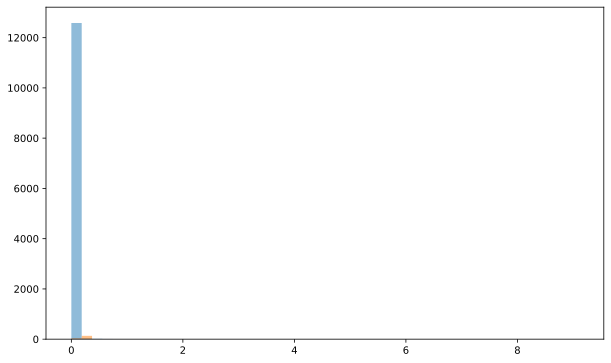

In [5]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data["intensity_exp_err"].tolist()

labels = labels / np.sum(labels) * 60 #Normalize labels

labels_err = []

for label, err in zip(labels, vol_err):
    if label == 0:
        labels_err.append(1000)  # Assign a high error for zero labels
    else:
        labels_err.append(1/(label + 5))  # Inverse error for each label

labels_err = tf.convert_to_tensor(labels_err, dtype=tf.float32)
labels = tf.convert_to_tensor(labels, dtype=tf.float32)

labels = tf.expand_dims(labels, axis=-1)  # Ensure labels are 2D
labels_err = tf.expand_dims(labels_err, axis=-1)  # Ensure labels_err are 2D

print("Max label ERR:", np.max(labels_err))
print("min label ERR:", np.min(labels_err))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print('error shape:', labels_err.shape)
print("Max label:", np.max(labels))
print("min label :", np.min(labels))
#bin from0 to 0.0025 with 50 bins
plt.figure(figsize=(10, 6))

plt.hist(labels.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels')
plt.hist(labels_err.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels Error')


Define a simple model

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The six parameters (a,b,c,d,e,f) correspond to the fractional atomic shifts in the modes w.r.t. unit cell lengths
- Instead of `sigmoid`, `tanh` should be applied to the parameters before passing them to the structure factor calculation function (ensures smoother gradient landscape)
- The `tanh` function can furthermore be limited to a specific range (e.g. if atomic distortions should not exceed +- 0.1)

In [6]:
class FunAsLayer(tf.keras.layers.Layer):
    def __init__(self, matrix , max_mode_amps,**kwargs):
        super().__init__(**kwargs)
        self.max_mode_amps = max_mode_amps
        self.matrix = matrix

    def build(self, input_shape):
        self.param = self.add_weight(name='param', shape=(1290,), initializer=tf.keras.initializers.GlorotNormal(seed=1), trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        # Apply tanh to ensure parameters stay within the [-1, 1] range then multiply by max_mode_amps so each parameter is scaled corresponding to the element in max_mode_amps
        pretransform = tf.tanh(self.param)
        transformed_params = pretransform * self.max_mode_amps  # Scale parameters

        output = fun_tf(inputs, (transformed_params) , self.matrix)
        return tf.reshape(output , [-1])  # Ensure output is 1D




Create optimizer and define loss function

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The learning rate must be determined by experimentation (same holds for the batch size and the number of epochs below)
- As a loss function, one can try either MSE or R-score (MSE seems to be the more "natural choice" in this case)

In [7]:
"""
# R-Score based on intensity
class RFactorLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        return tf.reduce_sum(tf.abs(y_true - y_pred)) / tf.reduce_sum(y_true)
"""
    
# mean squared error
class PerSampleMSE(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        squared_error = tf.square(y_true - y_pred)
        per_sample_mse = tf.reduce_mean(squared_error, axis=-1)
        return per_sample_mse  # shape (batch_size,)

class WeightedMeanSquaredError(tf.keras.losses.Loss):
    def __init__(self,reduction=tf.keras.losses.Reduction.AUTO, name='WeightedMeanSquaredError'):
        super(WeightedMeanSquaredError, self).__init__(reduction=reduction, name=name)

    def call(self, y_true, y_pred):
        return tf.keras.losses.mean_squared_error(y_true, y_pred)

    def num_of_elements(self, sample_weight):
        return tf.size(sample_weight).numpy()
    
    def __call__(self, y_true, y_pred, sample_weight):
        #return super().__call__(y_true, y_pred, 1)
        # 1/n *  sum(weights * mse(y_p - y_t))
        actual_loss = super().__call__(y_true, y_pred, sample_weight)
        num_of_el = tf.py_function(func=self.num_of_elements, inp = [sample_weight], Tout=tf.float32)

        # dividing by sum of all weights in this batch
        # (sum(weights * mse(y_p - y_t))) / sum(weights)
        wmse_loss = actual_loss * (num_of_el / tf.math.reduce_sum(sample_weight))
        return wmse_loss
  


# Define the custom metric function
def r_factor_metric(y_true, y_pred):
    labels = y_true
    return tf.reduce_sum(tf.abs(labels - y_pred)) / tf.reduce_sum(labels)


Train the model for n iterations (to try different initial weights)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The number of iterations defines the "starting position" $w_0$ of the gradient descent algorithm
- Because there are probably many local minima, changing $w_0$ allows the algorithm to find different minima and increases the chances of finding the global minima

Learning rate: 1.0
Shape of pars_tensor: (1290,)
(1290, 1)
(1290, 1)
<class 'tensorflow.python.framework.ops.Tensor'>
(1290, 1)
Shape of atom_shift_list: 1290
hahahahha = <class 'tensorflow.python.framework.ops.Tensor'>
Time taken for shift_atoms: 0.0440 seconds
Type of atom_shift_list after unstack: <class 'list'>
modified_struct type: <class 'list'>
Time taken for atom_position_list: 24.6787 seconds
modified_struct: [['Pr', '59', [<tf.Tensor 'fun_as_layer/add:0' shape=() dtype=float32>, <tf.Tensor 'fun_as_layer/add_2:0' shape=() dtype=float32>, <tf.Tensor 'fun_as_layer/add_1:0' shape=() dtype=float32>]], ['Pr', '59', [<tf.Tensor 'fun_as_layer/add_3:0' shape=() dtype=float32>, <tf.Tensor 'fun_as_layer/add_5:0' shape=() dtype=float32>, <tf.Tensor 'fun_as_layer/add_4:0' shape=() dtype=float32>]], ['Pr', '59', [<tf.Tensor 'fun_as_layer/add_6:0' shape=() dtype=float32>, <tf.Tensor 'fun_as_layer/add_8:0' shape=() dtype=float32>, <tf.Tensor 'fun_as_layer/add_7:0' shape=() dtype=float32>]], 

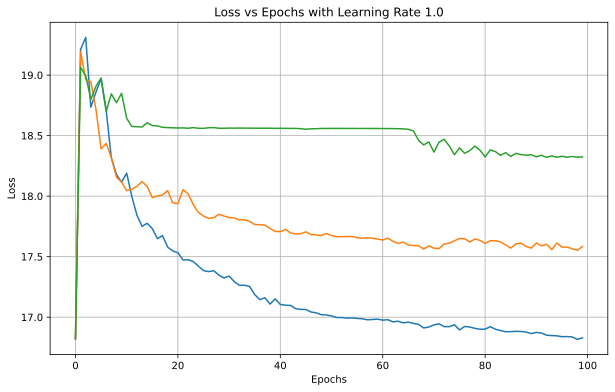

In [ ]:
matrix = np.loadtxt('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/new_PBCO_fit/matrix.txt', dtype=np.float32)
matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)


lr = [8e-1]
best_pars_overall = None
best_rf_overall = np.inf
best_loss_overall = []

for learning_rate in lr:
    time_start = time()
    print(f"Learning rate: {learning_rate}")
    optim = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    max_mode_amps = tf.constant([5.6,6.36,5.6,11.19,11.19,12.73,11.19,12.73,11.19,11.19,12.73,11.19,9.0,7.91,9.0,7.91,9.0,9.0,9.0,7.91,7.91,9.0,7.91,9.0,9.0,9.0,7.91,9.0,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,9.0,7.91,9.0,7.91,9.0,9.0,9.0,7.91,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,6.36,6.36,5.6,6.36,6.36,5.6,6.36,6.36,6.36,6.36,6.36,5.6,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,8.29,7.91,8.04,8.42,8.04,8.42,22.05,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,15.59,18.0,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,11.73,11.19,11.37,11.91,11.73,11.19,11.37,11.91,11.02,12.73,14.7,12.73,11.73,11.19,11.37,11.91,11.73,11.19,11.37,11.91,11.73,11.19,11.37,11.91,11.02,12.73,14.7,12.73,11.73,11.19,11.37,11.91,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,12.73,11.02,11.19,12.73,11.02,12.73,12.73,11.02,11.19,12.73,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,7.79,9.0,9.14,7.91,9.14,7.91,8.29,7.91,9.14,9.58,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,9.14,7.91,9.14,7.91,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,9.14,9.58,8.04,8.42,7.79,9.0,9.14,7.91,9.14,7.91,8.29,7.91,8.04,8.42,9.14,9.58,8.29,7.91,8.04,8.42,9.14,9.58,7.79,9.0,10.39,9.0,10.39,9.0,8.29,7.91,8.04,8.42,9.14,9.58,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,9.14,7.91,9.14,7.91,8.29,7.91,9.14,9.58,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,5.6,6.36,5.6,11.19,11.19,12.73,11.19,12.73,11.19,11.19,12.73,11.19,9.0,7.91,9.0,7.91,9.0,9.0,9.0,7.91,7.91,9.0,7.91,9.0,9.0,9.0,7.91,9.0,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,9.0,7.91,9.0,7.91,9.0,9.0,9.0,7.91,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,6.36,6.36,5.6,6.36,6.36,5.6,6.36,6.36,6.36,6.36,6.36,5.6,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,7.79,9.0,9.14,7.91,9.14,7.91,22.05,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,15.59,18.0,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,14.7,12.73,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,14.7,12.73,11.02,12.73,12.92,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,12.73,11.02,11.19,12.73,11.02,12.73,12.73,11.02,11.19,12.73,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,10.39,9.0,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,10.39,9.0,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,10.39,9.0,10.39,9.0,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,10.39,9.0,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,5.6,6.36,5.6,11.19,11.19,12.73,11.19,12.73,11.19,11.19,12.73,11.19,9.0,7.91,9.0,7.91,9.0,9.0,9.0,7.91,7.91,9.0,7.91,9.0,9.0,9.0,7.91,9.0,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,9.0,7.91,9.0,7.91,9.0,9.0,9.0,7.91,7.91,7.91,7.91,7.91,7.91,9.0,7.91,7.91,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,6.36,6.36,5.6,6.36,6.36,5.6,6.36,6.36,6.36,6.36,6.36,5.6,5.6,6.36,5.6,5.6,6.36,5.6,5.6,6.36,6.36,5.6,6.36,5.6,8.29,7.91,8.04,8.42,8.04,8.42,22.05,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,15.59,18.0,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,14.7,12.73,11.02,12.73,12.92,11.19,11.73,11.19,11.37,11.91,11.73,11.19,11.37,11.91,11.02,12.73,14.7,12.73,11.73,11.19,11.37,11.91,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,12.73,11.02,11.19,12.73,11.02,12.73,12.73,11.02,11.19,12.73,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,9.14,9.58,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,9.14,9.58,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,10.39,9.0,10.39,9.0,7.79,9.0,9.14,7.91,10.39,9.0,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,9.14,9.58,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,22.05,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,15.59,18.0,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,11.73,11.19,11.37,11.91,11.73,11.19,11.37,11.91,11.02,12.73,14.7,12.73,11.73,11.19,11.37,11.91,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,14.7,12.73,11.02,12.73,12.92,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,12.73,11.02,11.19,12.73,11.02,12.73,12.73,11.02,11.19,12.73,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,10.39,9.0,9.14,7.91,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,10.39,9.0,9.14,7.91,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,9.14,9.58,8.29,7.91,8.04,8.42,9.14,9.58,7.79,9.0,10.39,9.0,10.39,9.0,8.29,7.91,8.04,8.42,9.14,9.58,8.29,7.91,8.04,8.42,8.04,8.42,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,10.39,9.0,9.14,7.91,8.29,7.91,8.04,8.42,8.04,8.42,7.79,9.0,9.14,7.91,9.14,7.91,22.05,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,15.59,18.0,15.59,15.83,15.59,15.83,15.59,18.0,15.59,15.83,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,14.7,12.73,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,12.92,11.19,11.02,12.73,14.7,12.73,11.02,12.73,12.92,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,11.02,11.19,12.73,11.02,11.19,12.73,11.02,12.73,12.73,11.02,11.19,12.73,11.02,11.19,11.19,11.02,11.19,11.19,11.02,12.73,11.19,11.02,11.19,11.19,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,10.39,9.0,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,10.39,9.0,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,10.39,9.0,10.39,9.0,7.79,9.0,9.14,7.91,10.39,9.0,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91,7.79,9.0,10.39,9.0,9.14,7.91,7.79,9.0,9.14,7.91,9.14,7.91])
    n_epochs = 100
    histories = []
    n_iter = 3

    min_loss = np.inf
    best_pars = None

    # List to store the loss values for each epoch
    all_losses = []


    for i in range(n_iter):
        # Create the model
        inputs = tf.keras.Input(shape=(n_dim,))
        outputs = FunAsLayer(matrix , max_mode_amps)(inputs)
        model = tf.keras.Model(inputs, outputs)


        # Compile the model with the custom loss function and metric
        model.compile(
            optimizer=optim,
            loss= 'mse', # MSE_weighted() if using errors
            metrics=[r_factor_metric]

        )
        
        history = model.fit(
        x=features,
        y=labels,  # replace with combined_labels if using errors
        batch_size = features.shape[0], # Use a smaller batch size features.shape[0]
        epochs=n_epochs,
        verbose='auto',
        shuffle=True, # not sure whether this matters
        # callbacks=[cb]
        sample_weight=labels_err  # Use sample weights if you have errors
        )

        histories.append(history)
        all_losses.append(history.history['loss'])
        # Check final loss
        final_loss = history.history['loss'][-1]
        print(model.layers[-1].get_weights()[0].shape)
        curren_model_pars = max_mode_amps * tf.tanh(model.layers[-1].get_weights()[0])
        print(f"Final loss: {final_loss:.3e}")
        '''
        print(f"Best parameters for iteration {i+1}:")
        for j, par in enumerate(curren_model_pars):
            print(f"Parameter {j+1}: {par.numpy():.4f}")
        '''

        if final_loss < min_loss:
            # Update best model parameters
            best_model_pars = max_mode_amps * tf.tanh(model.layers[-1].get_weights()[0])
            min_loss = final_loss
            rf = r_factor_metric(labels, fun_tf(features, best_model_pars , matrix))
            print(f"Iteration {i+1} - New best loss: {min_loss:.3e} (R-factor: {rf:.3e})")

    if min_loss < best_rf_overall:
        best_rf_overall = min_loss
        best_pars_overall = best_model_pars
        best_loss_overall = all_losses
    print(f"time elapsed: {time() - time_start:.2f} seconds")
    print(f"With {n_epochs*n_iter /(time() - time_start)} iterations per second")
    # Plotting the loss values
    plt.figure(figsize=(10, 6))

    # Plot the loss values for each iteration
    for i, loss_values in enumerate(all_losses):
        plt.plot(loss_values, label=f'Iteration {i+1}')

    plt.title(f'Loss vs Epochs with Learning Rate {learning_rate}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    # plt.legend()
    plt.grid(True)
    plt.show()


min loss: 16.829389572143555


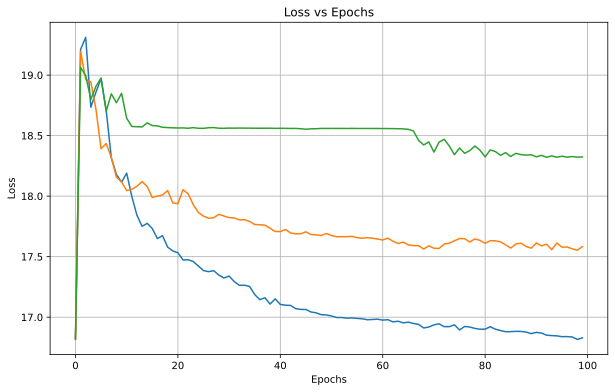

In [ ]:
all_losses = best_loss_overall
best_model_pars = best_pars_overall
min_loss = best_rf_overall

print(f"min loss: {min_loss}")

# Plotting the loss values
plt.figure(figsize=(10, 6))

# Plot the loss values for each iteration
for i, loss_values in enumerate(all_losses):
    plt.plot(loss_values, label=f'Iteration {i+1}')

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.legend()
plt.grid(True)
plt.show()

In [ ]:
mode_names = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/new_PBCO_fit/displacivemode_names.txt' , delim_whitespace=True, header=None)
mode_names = mode_names.values.tolist()
mode_names = pd.DataFrame(mode_names)


# Print the best model parameters
print("Best model parameters:") 
for i, par in enumerate(best_model_pars):
    print(f"mode a{i+1} {mode_names.iloc[i, 1]} : {par.numpy():.8f}")
    

C:\Users\User\AppData\Local\Temp\ipykernel_18740\3495977332.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/new_PBCO_fit/displacivemode_names.txt' , delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/9,1/9,1/3]GP1(a,0;a,0;a,0;a,0)[Pr1:h:dsp]B3u(a) : 5.59997559
mode a2 Pmmm[1/9,1/9,1/3]GP1(a,0;a,0;a,0;a,0)[Pr1:h:dsp]B1u(a) : 6.35997868
mode a3 Pmmm[1/9,1/9,1/3]GP1(a,0;a,0;a,0;a,0)[Pr1:h:dsp]B2u(a) : -5.59735584
mode a4 Pmmm[0,1/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -11.18998146
mode a5 Pmmm[0,2/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -11.18999481
mode a6 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : 12.72999954
mode a7 Pmmm[0,4/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -11.18999958
mode a8 Pmmm[0,0,1/3]LD1(a,0)[Pr1:h:dsp]B1u(a) : 12.72995281
mode a9 Pmmm[1/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -11.18964481
mode a10 Pmmm[2/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -11.18996334
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : 12.72989845
mode a12 Pmmm[4/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -11.18713760
mode a13 Pmmm[0,1/9,1/3]K1(a,0;a,0)[Pr1:h:dsp]B1u(a) : 8.99980354
mode a14 Pmmm[0,1/9,1/3]K1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 7.90999556
mode a15 Pmmm[0,2/9,1/3]K1(a,0;a,0)[Pr1:h:dsp]B1u(a) : -9.

In [ ]:

def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.sum(data['intensity_exp']) * 60
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor


def plot_plane_sim_vs_exp_DIM2(ax, df,r_factor, norm_plane=False):
    #only extract data for h == 0
    exp_data_0 = df.loc[df['k'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1) * 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1) * 500, color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    # #grid on
    # ax.grid(True, linestyle='--', alpha=0.7)
    # #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, 15, 0.11))
    ax.set_xlabel(f"h in (h, 0, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"HL plane for K = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()
    # ax.set_xlim(0 , -5.01)
    # ax.set_ylim(-1.01 , 3)


def plot_plane_sim_vs_exp_DIM1(ax, df, r_factor, norm_plane=False):
    exp_data_0 = df.loc[df['h'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['k'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['k'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    #grid on
    # ax.grid(True, linestyle='--', alpha=0.7)
    # #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, 15, 0.11))
    ax.set_xlabel(f"k in (0, k, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"KL plane for H = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()


def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l,norm_plane=False):
    exp_data_0 = df.loc[df['l'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, -5, 0.11))
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

In [ ]:
def plot_plane_sim_vs_exp_DIM1_CHILD(ax, df, r_factor, norm_plane=False):
    
    exp_data_0 = df.loc[df['h'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['k'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['k'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    #grid on
    # ax.grid(True, linestyle='--', alpha=0.7)
    # #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, 15, 0.11))
    ax.set_xlabel(f"k in (0, k, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"CHILD KL plane for H = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM2_CHILD(ax, df,r_factor, norm_plane=False):
    #only extract data for h == 0
    exp_data_0 = df.loc[df['k'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1) * 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1) * 500, color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    # #grid on
    # ax.grid(True, linestyle='--', alpha=0.7)
    # #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, 15, 0.11))
    ax.set_xlabel(f"h in (h, 0, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"CHILD HL plane for K = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()
    # ax.set_xlim(0 , -5.01)
    # ax.set_ylim(-1.01 , 3)

def plot_plane_sim_vs_exp_DIM3_CHILD(ax, df, r_factor, l,norm_plane=False):
    exp_data_0 = df.loc[df['l'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, -5, 0.11))
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"CHILD HK plane for L = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

In [ ]:
def parent_to_child_transform(hkl_list):
    """
    Transform the parent hkl to child hkl
    """
    h_new = - 9 *hkl_list[:, 0]
    k_new = hkl_list[:, 2]
    l_new = 9 *hkl_list[:, 1]

        # Stack the new h, k, l components into a single tensor
    result = np.stack([h_new, k_new, l_new] , axis=1)

    return result

In [ ]:
exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/raw_data/combined_peaks.csv')
exp_data['intensity_sim'] = fun_tf(features, best_model_pars, matrix).numpy()
r_factor = alris_r_factor(exp_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

normalised_exp_data = exp_data['intensity_exp'] / np.sum(exp_data['intensity_exp']) * 60
exp_data['normalised_intensity_exp'] = normalised_exp_data

# np_hkl_list = np.array(hkl_list, dtype=np.float32)
# child_hkl = parent_to_child_transform(np_hkl_list)
# child_exp_data = exp_data['intensity_exp'].tolist()
# child_sim_data = exp_data['intensity_sim'].tolist()
# child_frame = pd.DataFrame({
#     'h': child_hkl[:,0] , 
#     'k': child_hkl[:,1] , 
#     'l': child_hkl[:,2],
#     'intensity_exp': child_exp_data, 
#     'intensity_sim': child_sim_data })


Shape of pars_tensor: (1290,)
(1290, 1)
(1290, 1)
<class 'tensorflow.python.framework.ops.EagerTensor'>
(1290, 1)
Shape of atom_shift_list: 1290
hahahahha = <class 'tensorflow.python.framework.ops.EagerTensor'>
Time taken for shift_atoms: 0.0020 seconds
time taken for tf.unstack: 0.0050 seconds
Time taken for atom_position_list: 0.7848 seconds
Shape of hkl_list: (12647, 3)
F_hkl: tf.Tensor(
[ -168.5098 +1709.9939j  5117.685  -2863.3408j -1022.8972 +4564.974j  ...
   938.79803+1345.203j    151.43956 -883.2111j   483.14706-1208.9608j], shape=(12647,), dtype=complex64)
Time taken for get_structure_factors: 1.4574 seconds
Shape of sf_hkl: (12647,)
ALRIS R-factor: 1.938


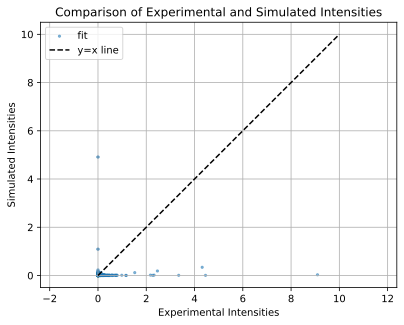

In [ ]:
x = np.linspace(0 ,10, 10000)
y = x
plt.scatter(exp_data['intensity_exp']/np.sum(exp_data['intensity_exp']) * 60, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()

In [ ]:
#save the experiment data with simulated intensities
exp_data.to_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/fitted_data/peaks_with_simulated_intensities.txt', index=False)

#save all the parameters and the modes
with open('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/fitted_data/parameters_and_modes.txt', 'w') as f:
    f.write(f"final loss: {min_loss:.8f}\n")
    f.write(f"Number of iterations: {n_iter}\n")
    f.write(f"r_factor: {r_factor:.8f}\n")
    f.write(f"learning_rate: {lr[0]:.8f}\n")
    f.write(f"n_epochs: {n_epochs}\n")
    f.write(f"Best model parameters:\n")
    for i, par in enumerate(best_model_pars):
        f.write(f"{mode_names.iloc[i, 1]} : {par.numpy():.8f} \n")

abs_params = tf.abs(best_model_pars)
best_model_pars_compare = best_model_pars.numpy()
best_model_pars_compare = best_model_pars_compare / np.max(best_model_pars_compare)

#save all the parameters and the modes
with open('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/fitted_data/parameters_and_modes_normalised.txt', 'w') as f:
    f.write(f"final loss: {min_loss:.8f}\n")
    f.write(f"learning_rate: {lr[0]:.8f}\n")
    f.write(f"n_epochs: {n_epochs}\n")
    f.write(f"Best model parameters:\n")
    for i, par in enumerate(best_model_pars_compare):
        f.write(f"{mode_names.iloc[i, 1]} : {par:.8f} \n")



In [ ]:
best_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/fitted_data/peaks_with_simulated_intensities.txt')

fig, axs = plt.subplots(1, 2, figsize=(24, 12), constrained_layout=True)
plot_plane_sim_vs_exp(axs[0], best_data, 0, norm_plane=True)
plot_plane_sim_vs_exp(axs[1], exp_data, 0, norm_plane=True)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/fitted_data/peaks_with_simulated_intensities.txt'